# Code 1. Raman Code1 Reference (v1.0)

Diagnostic band library, rule C, evidence floor, and the hand-off to Code 2.

- Raman only. Writes one file for Code 2 (`ground_truth_for_code2.csv`) and reads nothing back.
- The label is assigned by the band library (§2) and rule C (§1), not by an analyst. `raman_label_manual` in the worksheet is an optional audit column and is never read by §16.

**Sections**

| § | Content | Output |
|---|---|---|
| 1 | Constants (single source of truth), rule C thresholds, `RULE_C_PROVENANCE` | |
| 2, 2-2 | Diagnostic band library and its literature source ledger | `band_provenance.csv` |
| 3-9 | Parser, loader, QC, pre-treatment, peak extraction, `band_evidence()`, plot | |
| 10-11 | Worksheet build and run over all particles | `worksheet_template.csv`, per-particle PNG |
| 12 | Sensitivity grids (SI tables) | `sens_*.csv` |
| 12-2 | Null-model permutation test for rule C, label design (primary) | `null_A1_*_label.csv` |
| 12-3 | Null-model permutation test, shift design (sensitivity) | `null_A1_*_shift.csv` |
| 12-4 | Per-band performance on the SLoPP / SLoPP-E corpus | `band_performance_corpus.csv` |
| 13 | Wavenumber-axis check (Si, PS); no correction is applied | |
| 14 | Band library and decision chain on PE and PP standards | `std_*_bands.csv` |
| 15 | Cross-method comparison against SLoPP correlation matching | `method_comparison.csv` |
| 15-2 | Specificity-weighted alternative to rule C | `band_specificity.csv`, `rule_matched_compare.csv` |
| 15-3 | Per-band performance on the field particles | `band_performance.csv` |
| 16 | Support level and hand-off | `ground_truth_for_code2.csv`, `handoff_manifest.json` |

**Execution.** Cells are ordered by dependency; run once from top to bottom. §12-3 (shift null) resets `NULL_KIND` to `'label'` for the cells that follow.

**What the reference is.** Each label is the top-ranked class of the band library under rule C, subject to the evidence floor. No human reading, no micrograph and no FT-IR evidence enters it, so Code 2 can measure how far FT-IR naming diverges from it. The assignment is deterministic and reader-independent, but it is not a ground truth: agreement with it is inter-method agreement, not accuracy (§16 prints the wording to use).

**Evidence floor (R3).** A label is emitted only when the rule decided:

- `A_tier != 'unresolved'` (at least two key bands matched), and
- `A_margin >= 1` (a tie broken by sort order is not a decision), and
- not (`fluorescence corr >= 0.98` and `k1 <= 2`) (pure sloping background).

Particles that fail keep their row with `gt_source = 'withheld'`, an empty `gt_label` and `gt_withheld_reason`, so Code 2 can count them.

**Checks behind the assignment.** Band positions and the decision chain are validated on polymer standards (§13, §14); §15 cross-checks every particle against SLoPP / SLoPP-E correlation matching, which never reads this library; §16 turns that into an ordinal `support_level`.

**Thresholds.** `K_MIN` and `GAP_MIN` are set in §1. `GAP_MIN` is FDR-calibrated in §12-2 (every particle called confident passes BH q < 0.05 under both null designs); the record is `RULE_C_PROVENANCE`. §15-2 asks whether a count-based rule is appropriate at all.

**Wavenumber axis.** The instrument applies a Si-referenced (520.7 cm⁻¹) shift to each file at save time; the code applies no further correction (`WN_DELTA = 0`), because recalibrating against the band library would make validation circular. The residual dispersion error is measured in §13 and reported as a limitation.

---
© 2026 Youjin Kim. Licensed under CC BY-NC 4.0.
Part of the archive "field_MPs_codes"; for the licence, citation and DOI see
`LICENSE` and `CITATION.cff` in the repository root (github.com/meemeyjk/field_MPs_codes).

## 0-0. Session setup (Google Drive)

Inputs are copied from Drive into `/content` at the start of a session; folder names are identical on both sides.

```
MyDrive/mp_project/
  raman_spectra/       field Raman .txt         required
  standards/           Si and PS, §13           optional
  standards_polymer/   PE and PP pellets, §14   optional
  corpus/              SLoPP cache, §12-4       optional
  raman_manual_out/    output; Code 2 reads this folder
```

Keep standards out of `raman_spectra/`: `build_worksheet` globs every `*.txt` there.

In [ ]:
# 0-0. Drive mount and session setup. Run first.
from google.colab import drive
drive.mount('/content/drive')

import os, shutil, glob

PROJECT = '/content/drive/MyDrive/mp_project'    # <- point this at your own folder

# Drive folder name == /content folder name, so nothing is renamed on the way in.
#   raman_manual_out is the SHARED handover point: this notebook writes it, Code 2 reads it.
SYNC_IN = [
    ('raman_spectra',     'field Raman .txt                REQUIRED'),
    ('standards',         'Si + PS, section 13             optional'),
    ('standards_polymer', 'PE/PP pellets, section 14       optional'),
    ('corpus',            'SLoPP cache, section 12-4       optional'),
]

for _name, _what in SYNC_IN:
    _src, _dst = os.path.join(PROJECT, _name), f'/content/{_name}'
    os.makedirs(_dst, exist_ok=True)
    _n = 0
    for _p in glob.glob(os.path.join(_src, '**', '*'), recursive=True):
        if os.path.isfile(_p):
            _rel = os.path.relpath(_p, _src)
            _out = os.path.join(_dst, _rel)
            os.makedirs(os.path.dirname(_out) or _dst, exist_ok=True)
            shutil.copy(_p, _out); _n += 1
    print(f'  /content/{_name:<20}{_n:>5} files   {_what}'
          + ('' if _n else '   <- empty, that section is skipped'))

os.makedirs('/content/raman_manual_out', exist_ok=True)

# -- what the run actually needs -------------------------------------------
print('-' * 68)
_raman = glob.glob('/content/raman_spectra/*.txt') + glob.glob('/content/raman_spectra/*.TXT')
print(f'  raman_spectra  : {len(_raman)} .txt   '
      + ('OK' if _raman else '*** MISSING - the notebook cannot run ***'))

_ax = [f for f in ('si_before_cal.txt', 'si_after_cal.txt', 'ps_before.txt', 'ps_after.txt')
       if not os.path.exists(f'/content/standards/{f}')]
print( '  standards (13) : ' + ('all 4 present  OK' if not _ax else f'missing {_ax}'))

_pol = [f for f in ('PE_428043.txt', 'PP_427888.txt')
        if not os.path.exists(f'/content/standards_polymer/{f}')]
print( '  standards (14) : ' + ('both present  OK' if not _pol else f'missing {_pol}')
      + '   (note: .txt here, while Code 2 uses .CSV)')

_cache = all(os.path.exists(f'/content/corpus/{f}')
             for f in ('corpus_meta.csv', 'corpus_spectra.csv'))
_raw = glob.glob('/content/corpus/raw/*.zip') + glob.glob('/content/corpus/raw/*.xlsx')
print( '  corpus (12-4)  : ' + ('parsed CSV cache present - no download needed' if _cache
                                else f'{len(_raw)} archive(s) cached' if _raw
                                else 'nothing cached - section 12-4 will download ~2 files'))

# A standard sitting in raman_spectra would be ingested as a particle. Catch it here.
_stray = [os.path.basename(p) for p in _raman
          if os.path.basename(p) in ('si_before_cal.txt', 'si_after_cal.txt', 'ps_before.txt',
                                     'ps_after.txt', 'PE_428043.txt', 'PP_427888.txt')]
if _stray:
    print(f'\n  ***  {_stray} are standards sitting in raman_spectra/ - REMOVE THEM  ***')
    print( '       build_worksheet would ingest them as particles and every downstream count')
    print( '       (worksheet rows, the reference assignment, Code 2 guard) would be wrong.')


Mounted at /content/drive
  /content/raman_spectra          47 files   field Raman .txt                REQUIRED
  /content/standards               4 files   Si + PS, section 13             optional
  /content/standards_polymer       2 files   PE/PP pellets, section 14       optional
  /content/corpus                  2 files   SLoPP cache, section 12-4       optional
--------------------------------------------------------------------
  raman_spectra  : 47 .txt   OK
  standards (13) : all 4 present  OK
  standards (14) : both present  OK   (note: .txt here, while Code 2 uses .CSV)
  corpus (12-4)  : parsed CSV cache present - no download needed


## 0. Folder check

In [ ]:
import os, glob

RAMAN_DIR = "/content/raman_spectra"
OUT_DIR   = "/content/raman_manual_out"

paths = sorted(glob.glob(os.path.join(RAMAN_DIR, '*.txt')) +
               glob.glob(os.path.join(RAMAN_DIR, '*.TXT')))
print(f"{len(paths)} file(s) found")
for p in paths:
    print(" ", os.path.basename(p))


47 file(s) found
  0517S1-1.txt
  0607S1-12.txt
  0607S1-5.txt
  0607S1-6.txt
  0614S1-1.txt
  0614S1-2.txt
  0614S1-3.txt
  0614S1-5.txt
  0626S1-1.txt
  0626S1-10.txt
  0626S1-11.txt
  0626S1-12.txt
  0626S1-2.txt
  0626S1-3.txt
  0626S1-4.txt
  0626S1-6.txt
  0626S1-7.txt
  0626S1-8.txt
  0626S1-9.txt
  0628S1-1.txt
  0628S1-4.txt
  0628S1-5.txt
  0711S1-1.txt
  0711S1-2.txt
  0711S1-3.txt
  0712S1-1.txt
  0712S1-10.txt
  0712S1-11.txt
  0712S1-12.txt
  0712S1-13.txt
  0712S1-2.txt
  0712S1-3.txt
  0712S1-6.txt
  0725S1-1.txt
  0725S1-10.txt
  0725S1-11.txt
  0725S1-12.txt
  0725S1-13.txt
  0725S1-14.txt
  0725S1-2.txt
  0725S1-3.txt
  0725S1-4.txt
  0725S1-5.txt
  0725S1-6.txt
  0725S1-7.txt
  0725S1-8.txt
  0725S1-9.txt


## 1. Settings and imports

In [ ]:
import re
import numpy as np
import pandas as pd
from scipy import sparse
from scipy.sparse.linalg import spsolve
from scipy.signal import find_peaks
import matplotlib
import matplotlib.pyplot as plt
#

#  Paths are defined only in §0 (avoids shadowing).
assert 'RAMAN_DIR' in dir() and 'OUT_DIR' in dir(), "run §0 first"
os.makedirs(OUT_DIR, exist_ok=True)

# ============ version ============
PIPELINE_VERSION = "v1.0"     # the hand-off label is the RAMAN CODE1 REFERENCE
                              #   (rule output + R3 evidence floor), gt_source in
                              #   {rule, withheld}; no analyst path.

# -- Wavenumber-axis correction (delta): currently not applied ------------
# Convention: delta = observed - reference.  Applied as wn_corrected = wn_observed - delta (§10).
# The library (§2) is on the reference (literature) scale and is never shifted.
# The instrument already applies the correction per file before saving (validated in section 13), so this stays 0.
# A per-date dict can be supplied here if a correction is ever needed.
WN_DELTA      = {'default': 0.0}   # e.g. {'default': -1.0, '05.17': +2.5, '07.11': -1.9}
DELTA_VERSION = "instrument-internal Si shift (per-file); no post-hoc correction"

# -- Measured dispersion error: recorded, not applied ---------------------
# For each measurement the instrument derives a shift from internal Si (520.7) and applies it on save.
# That correction is accurate only near 520.7; being a single-point anchor it cannot capture dispersion.
# Measured on ASTM E1840 polystyrene in two independent sessions (ps_before / ps_after).
# Peak positions are located exactly as in the sample pipeline (find_peaks plus parabolic
# interpolation), and only lines passing the admission criteria (detected, isolated,
# adequately sampled at half maximum, S/N, method spread) are used.

WN_DISPERSION_MEASURED = dict(
    source   = "PS ASTM E1840, raw 2026-07-29, 2 sessions (shift -4.835 / -4.695)",
    method   = "find_peaks + parabolic interpolation (matches sample pipeline)",
    lines    = [620.9, 795.8, 1001.4, 1031.8, 1602.3, 2852.4, 2904.5],   # 7 admitted lines
    excluded = {1155.3: "method spread 1.34 (ps_s2)",
                1450.5: "method spread 1.77/2.53; reference value disputed, ASTM 1450.5 vs NMIJ 1448.4",
                1583.1: "not detected in either session",
                3054.3: "method spread 1.11/1.64 > 1.0"},
    residual = {620.9: -2.74, 795.8: -3.06, 1001.4: -3.24, 1031.8: -2.94,
                1602.3: -3.87, 2852.4: -6.90, 2904.5: -5.99},   # mean of two sessions
    repeat_sd     = 0.20,        # between-session reproducibility SD
    slope         = -0.00168,    # pooled fit over the 7 admitted lines
    span_621_2904 = -3.84,       # slope x (2904.5 - 620.9)
    zone          = {'fingerprint_600_1700': -3.17,   # 5 lines
                     'CH_stretch_2800_3100': -6.44},  # 2 lines
    si_anchor     = {'residual': -0.49, 'method_spread': 0.45, 'repeat_raw_axis': 0.88,
                     'ps_fit_extrapolated_to_520.7': -2.38, 'mismatch': 1.89},
    applied  = False,            # not applied
    reason   = ("(1) Non-monotonic within the admitted set: the residual turns back from "
                "2852.4 (-6.90) to 2904.5 (-5.99), so a single polynomial does not fit "
                "(linear deviation 0.68 = 3.4x the session SD at 2852.4). "
                "(2) No standard lines fall in 1602.3-2852.4 (1250 cm-1) or in "
                "520.7-620.9 (100 cm-1); behaviour there is extrapolated and unverified. "
                "(3) The Si anchor is itself uncertain (raw-axis repeat difference 0.88, "
                "method sensitivity 0.45); the PS fit extrapolated to 520.7 (-2.38) and "
                "the measured Si residual (-0.49) disagree by 1.89, and curvature cannot "
                "be distinguished from Si localisation error. No correction is applied; "
                "the zone-wise errors are reported as a limitation."),
    robustness = ("Leave-one-out: maximum slope change 15% (2852.4), maximum leverage 0.239, "
                  "so the slope can be reported as a measurement rather than an indication."),
    caveat   = ("The delta grid in section 12 (C) spans +/-8 so that it covers the measured "
                "CH-stretch error."),
)

def wn_delta_for(date):
    return float(WN_DELTA.get(date, WN_DELTA['default']))

# -- saturation --
# Measured in §1-1 (n=55): clipping values scatter over 64918-64945, so the lower edge of that
# band is used as the threshold together with a flat-top (consecutive) criterion.
SAT_LEVEL        = 64900
SAT_MIN_RUN      = 3
SAT_LEVEL_SOURCE = "MEASURED 2026-07-15 (n=55, flat-top verified)"

# -- baseline (ALS) --  (lambda = 1e4; sensitivity of the labels to this choice is not part of section 12)
ALS_LAM, ALS_P, ALS_NITER = 1e4, 0.01, 10

# -- analysis window --
# Lower bound 140: 51 of 55 files show artefact peaks at 127-151 (Rayleigh shoulder, mode 130-139),
#           the instrument low-wavenumber cut-off region, indistinguishable from quartz 128 or TiO2 143/144.
# Upper bound 3600: the highest diagnostic band is nylon N-H at 3300; above that lie overtones and background.
ANALYSIS_MIN, ANALYSIS_MAX = 140.0, 3600.0
FINGERPRINT_MIN, FINGERPRINT_MAX = 400.0, 1800.0
FINGERPRINT_MIN_PEAKS = 4          # fewer than 4 fingerprint peaks -> unresolved

PEAK_PROM_K = 4.0
MATCH_TOL   = 8.0                  # provenance: section 2-2 (between-source spread); null behaviour in section 12-2
SHOW_INLINE = True

# -- Rule C thresholds: single source of truth (never hard-code elsewhere) --
# Rule C: confident = (k1 >= K_MIN) AND (k1-k2 >= GAP_MIN) AND cap allows confident
#
# GAP_MIN is FDR-calibrated (section 12-2), not declared: every particle called confident must
#   pass Benjamini-Hochberg q<0.05 across all particles, under both null designs. Uncorrected p
#   alone would admit a smaller gap, but the simultaneous tests require FDR control.
#   The calibration record is RULE_C_PROVENANCE below; the measured values are in the
#   section 12-2 output and must agree with it.
#
# K_MIN is structural (classes with fewer than K_MIN key bands are confident-ineligible);
#   section 12 (B) shows whether it binds on this dataset.
#
# Note on count-based scoring: every band scores 1 although bands differ in specificity.
#   Section 15-2 tests a specificity-weighted alternative at matched null false-alarm rates;
#   the simpler count rule is retained unless that comparison says otherwise.
#
K_MIN   = 3
GAP_MIN = 4

RULE_C_PROVENANCE = dict(
    k_min        = K_MIN,
    k_min_basis  = "structural: classes with fewer than 3 key bands are CONFIDENT_INELIGIBLE",
    gap_min      = GAP_MIN,
    gap_min_basis= ("FDR-calibrated (section 12-2). Criterion: every particle called confident "
                    "must pass Benjamini-Hochberg q<0.05 over all 47 particles. "
                    "gap>=2 -> 21 called, 12-13 pass (57-62%); "
                    "gap>=3 -> 16 called, 12-13 pass (75-81%); "
                    "gap>=4 -> 12 called, 12 pass (100%) under BOTH null designs."),
    null_test    = "permutation, B=10000, seed=20260805, two independent designs",
    P_ruleC_H0   = {"label": 0.0066, "shift": 0.0022},
    P_ruleC_CI95 = {"label": (0.0063, 0.0068), "shift": (0.0021, 0.0023)},
    p_study      = {"label": 0.0003, "shift": 0.0001},
    null_mean_confident = {"label": 0.31, "shift": 0.10},
    library      = "band library v1.0 (shoulder bands excluded from key)",
    boundary_case= ("0626S1-2 (PE, margin 3): passes FDR under shift (q=0.039) but not "
                    "under label (q=0.138); reported as tentative."),
)

print(f"=== Code 1 {PIPELINE_VERSION} ===")
print(f"  delta corr. = {DELTA_VERSION}")
print(f"  dispersion  = measured {WN_DISPERSION_MEASURED['zone']} (not applied; section 13 and limitations)")
print(f"  ALS_LAM   = {ALS_LAM:.0e}")
print(f"  SAT_LEVEL = {SAT_LEVEL} (flat-top run>={SAT_MIN_RUN})  [{SAT_LEVEL_SOURCE}]")
print(f"  window      = {ANALYSIS_MIN:.0f}-{ANALYSIS_MAX:.0f} cm-1 | fingerprint {FINGERPRINT_MIN:.0f}-{FINGERPRINT_MAX:.0f}")
print(f"  MATCH_TOL = ±{MATCH_TOL:.0f} cm-1 | PEAK_PROM_K = {PEAK_PROM_K}")
print(f"  rule C      = k1>={K_MIN} AND gap>={GAP_MIN} AND cap   "
      f"[gap is FDR-calibrated in section 12-2; weighted alternative tested in section 15-2]")

# -- Software environment (recorded in the output for the archived run) --
import sys, platform, json
import scipy, matplotlib
ENV = {
    'python'     : platform.python_version(),
    'numpy'      : np.__version__,
    'scipy'      : scipy.__version__,
    'pandas'     : pd.__version__,
    'matplotlib' : matplotlib.__version__,
    'platform'   : platform.platform(),
    'runtime'    : 'Google Colab' if 'google.colab' in sys.modules else 'local',
}
print("  environment =", ", ".join(f"{k} {v}" for k, v in ENV.items()))
with open(os.path.join(OUT_DIR, 'environment.json'), 'w') as _f:
    json.dump(ENV, _f, indent=2)


=== Code 1 v1.0 ===
  delta corr. = instrument-internal Si shift (per-file); no post-hoc correction
  dispersion  = measured {'fingerprint_600_1700': -3.17, 'CH_stretch_2800_3100': -6.44} (not applied; section 13 and limitations)
  ALS_LAM   = 1e+04
  SAT_LEVEL = 64900 (flat-top run>=3)  [MEASURED 2026-07-15 (n=55, flat-top verified)]
  window      = 140-3600 cm-1 | fingerprint 400-1800
  MATCH_TOL = ±8 cm-1 | PEAK_PROM_K = 4.0
  rule C      = k1>=3 AND gap>=4 AND cap   [gap is FDR-calibrated in section 12-2; weighted alternative tested in section 15-2]
  environment = python 3.13.15, numpy 2.1.3, scipy 1.16.3, pandas 2.2.3, matplotlib 3.10.0, platform Linux-6.6.122+-x86_64-with-glibc2.35, runtime Google Colab


## 1-1. SAT_LEVEL check

Measures the clipping level of this instrument; set `SAT_LEVEL` in §1 from the output.

In [ ]:
# 1-1. Measure SAT_LEVEL and check file integrity (self-contained; own loader and parser).
import numpy as np, glob, os, re, collections

# --- same loader as section 4 (copy) ---
def _load_txt(path):
    wn, inten = [], []
    with open(path, 'r', encoding='utf-8', errors='replace') as f:
        for line in f:
            line = line.replace('\x00', '').strip()
            if not line or line.startswith('#') or re.match(r'^[a-zA-Z]', line):
                continue
            parts = line.split()
            if len(parts) < 2: continue
            try:
                wn.append(float(parts[0])); inten.append(float(parts[1]))
            except ValueError:
                continue
    wn, inten = np.asarray(wn), np.asarray(inten)
    if len(wn) == 0: return wn, inten
    o = np.argsort(wn); return wn[o], inten[o]

# --- same parser as section 3 (copy) ---
def _parse_fn(path):
    base = os.path.splitext(os.path.basename(path))[0]
    for pat, has_year in [
        (r'^(\d{2})(\d{2})(\d{2})[_-]?[Ss](\d+)(?:[_-](\d+))?$', True),
        (r'^(\d{2})(\d{2})[_-]?[Ss](\d+)(?:[_-](\d+))?$',        False),
    ]:
        m = re.match(pat, base)
        if m:
            g = m.groups()
            if has_year: return {'date': f"20{g[0]}.{g[1]}.{g[2]}", 'station': f"S{g[3]}", 'particle': g[4] or ''}
            return {'date': f"{g[0]}.{g[1]}", 'station': f"S{g[2]}", 'particle': g[3] or ''}
    return None

def _read_header(path, nlines=3):
    out = []
    with open(path, 'r', encoding='utf-8', errors='replace') as f:
        for line in f:
            s = line.replace('\x00', '').strip()
            if not s: continue
            if re.match(r'^\s*[-+]?[\d.]', s): break
            out.append(s)
            if len(out) >= nlines: break
    return ' | '.join(out)

_paths = sorted(glob.glob(os.path.join(RAMAN_DIR, '*.txt')) +
                glob.glob(os.path.join(RAMAN_DIR, '*.TXT')))
print(f"{len(_paths)} file(s)\n")

rows, bad = [], []
for p in _paths:
    name = os.path.basename(p); meta = _parse_fn(p)
    wn, inten = _load_txt(p)
    if len(wn) == 0:
        bad.append((name, _read_header(p))); continue
    rows.append(dict(file=name, path=p, parsed=(meta is not None),
                     n=len(wn), imax=float(np.max(inten)), imin=float(np.min(inten))))

# -- (1) filename parse failures (silently dropped from the worksheet) --
print("=== (1) filename parse failures ===")
f1 = [r for r in rows if not r['parsed']]
for r in f1: print(f"  ! {r['file']}  <- needs renaming (currently missing from the worksheet)")
print("  none" if not f1 else "")

# -- (2) measure SAT_LEVEL --
print("\n=== (2) SAT_LEVEL measurement ===")
maxes = np.array([r['imax'] for r in rows])
print(f"  imax: min={maxes.min():.0f}  med={np.median(maxes):.0f}  max={maxes.max():.0f}")
cnt = collections.Counter(np.round(maxes).astype(int))
rep = [(v, c) for v, c in cnt.most_common(10) if c >= 2]
print("\n  --- imax values shared by several files (clipping candidates) ---")
for v, c in rep: print(f"    {v:>9d}  <- {c} file(s)")
print("    none" if not rep else "")
print("\n  --- flat-top check (top 6 by imax) ---")
for r in sorted(rows, key=lambda t: -t['imax'])[:6]:
    _, inten = _load_txt(r['path']); mx = np.max(inten)
    n_at = int(np.sum(inten >= mx - 1e-6))
    print(f"    {r['file']:22s} imax={mx:>9.0f}  pts at imax={n_at:>4d}"
          + ("   <- saturated (flat-top)" if n_at >= 3 else "   (single point = normal peak)"))

print(f"\n  current SAT_LEVEL={SAT_LEVEL} | measured maximum={maxes.max():.0f}")
if maxes.max() < SAT_LEVEL:
    print(f"  !! no file reaches SAT_LEVEL, so every 'saturated x N' flag is spurious.")
    print(f"     Set SAT_LEVEL = {int(maxes.max())+1} in section 1 and update SAT_LEVEL_SOURCE to 'MEASURED'.")
else:
    print(f"  files reaching it: {[r['file'] for r in rows if r['imax'] >= SAT_LEVEL]}")

# -- (3) negative raw intensity --
print("\n=== (3) negative raw intensity ===")
f5 = [r for r in rows if r['imin'] < 0]
for r in f5: print(f"  ⚠ {r['file']:22s} imin={r['imin']:.0f}")
print("  none: negative peaks in the worksheet are artefacts of ALS baseline over-correction (tune lambda)" if not f5 else "")

if bad:
    print("\n=== load failures ===")
    for n, h in bad: print(f"  {n}: '{h[:60]}'")

47 file(s)

=== (1) filename parse failures ===
  none

=== (2) SAT_LEVEL measurement ===
  imax: min=128  med=16231  max=64945

  --- imax values shared by several files (clipping candidates) ---
        64944  <- 2 file(s)


  --- flat-top check (top 6 by imax) ---
    0712S1-10.txt          imax=    64945  pts at imax=   1   (single point = normal peak)
    0712S1-11.txt          imax=    64944  pts at imax= 764   <- saturated (flat-top)
    0712S1-13.txt          imax=    64944  pts at imax= 704   <- saturated (flat-top)
    0607S1-5.txt           imax=    64921  pts at imax=  22   <- saturated (flat-top)
    0626S1-12.txt          imax=    64918  pts at imax=  13   <- saturated (flat-top)
    0725S1-14.txt          imax=    64908  pts at imax= 477   <- saturated (flat-top)

  current SAT_LEVEL=64900 | measured maximum=64945
  files reaching it: ['0607S1-5.txt', '0626S1-12.txt', '0712S1-10.txt', '0712S1-11.txt', '0712S1-13.txt', '0725S1-14.txt']

=== (3) negative raw intensity ===


## 2. Diagnostic Raman band library

Band positions follow the sources in §2-2. Bands flagged key are diagnostic for the class (e.g. PP 809 cm⁻¹, absent in PE).

In [ ]:
# Cross-validation on this instrument (§14): PE (Sigma-Aldrich 428043) and PP (Sigma-Aldrich
#   427888) standards are pushed through the whole decision chain. §14 additionally disqualifies
#   reference-band pairs that resolve to one observed peak within a grid spacing, so its per-band
#   count may be lower than band_evidence's (detection limit, not the material). This validates
#   pristine resin positions only; all other classes rest on literature values (limitation).
# PP key count is 10: _derive_polymer_bands() excludes the Nava shoulder bands 1167 and 1371
#   (corpus support in §12-4).
NAVA2021_TABLE2 = {
    "polyolefin_PP": dict(   # Isotactic polypropylene (iPP), ref 101
        all=[252, 321, 398, 458, 530, 809, 841, 900, 941, 973, 998, 1040, 1102, 1152,
             1167, 1219, 1257, 1296, 1306, 1330, 1360, 1371, 1435, 1458, 2840, 2871,
             2883, 2905, 2920, 2952],
        bold=[398, 809, 841, 1040, 1152, 1330, 1458, 2883],
        sh=[1167, 1371]),
    "polyolefin_PE": dict(   # Polyethylene (PE), ref 107,108
        all=[1062, 1130, 1170, 1295, 1417, 1440, 1460, 2850, 2883],
        bold=[2850, 2883], sh=[]),
    "polystyrene": dict(     # Polystyrene (PS), ref 112,113
        all=[621, 795, 1001, 1031, 1155, 1450, 1583, 1602, 2854, 2904, 3054],
        bold=[1001, 1602, 3054], sh=[]),
    "polyester_PET": dict(   # PET, ref 109
        all=[278, 626, 701, 800, 857, 950, 1000, 1096, 1119, 1192, 1295, 1310, 1418,
             1462, 1615, 1730, 2912, 2968, 3085],
        bold=[1615, 1730], sh=[1310]),
    "PVC": dict(             # PVC, ref 115,116
        all=[310, 345, 363, 420, 496, 544, 571, 599, 615, 638, 682, 694, 752, 838, 930,
             964, 972, 1066, 1101, 1119, 1172, 1187, 1216, 1257, 1316, 1335, 1357, 1379,
             1430, 1437, 1498, 2914, 2935, 2969, 2994],
        bold=[363, 638, 694, 1430, 2914, 2935], sh=[345]),
}
# -- Transcription of Boke2022 Fig. 2 (only the peaks labelled in the figure) --
#   Of the nine materials shown, PC / Silicone / PLA / PMMA have no class here and are unused.
#   nylon and acrylonitrile do not appear in that figure, so rule (2) is undefined for them.
BOKE2022_FIG2 = {
    "polyolefin_PE":  [1063, 1129, 1295, 1441],
    "polyolefin_PP":  [399, 810, 841, 974, 999, 1153, 1168, 1330, 1371, 1460],
    "PVC":            [362, 636, 695, 1040, 1302, 1437, 1602, 1725],
    "polyester_PET":  [632, 857, 1287, 1614, 1725],
    "polystyrene":    [621, 795, 1002, 1032, 1603],
    # unused (no class here): PC 637/706/889/1112/1180/1236/1604/1776
    #                         Silicone 490/789/790/861/1261/1413
    #                         PLA 408/874/1043/1128/1296/1454/1771
    #                         PMMA 600/812/1000/1152/1450/1727
}
# Boke PVC 1040 / 1602 / 1725 are absent from Nava PVC and are therefore dropped by the intersection.

# -- Vibrational assignment per band (labels only). Plays no part in values or key selection. --
_ASSIGN = {
    ("polyolefin_PP", 398): "skeletal deformation (Nava bold = strongest) - collides with weathered LDPE 400 and anatase 399 within 1-2 cm-1",
    ("polyolefin_PP", 809): "C-C / CH2 rock (specific to PP; absent in PE)",
    ("polyolefin_PP", 841): "C-C",
    ("polyolefin_PP", 973): "CH3 rock",
    ("polyolefin_PP", 998): "CH3 rock (helical)",
    ("polyolefin_PP", 1152): "C-C + C-CH3",
    ("polyolefin_PP", 1167): "C-C",
    ("polyolefin_PP", 1330): "CH bend",
    ("polyolefin_PP", 1458): "CH2 / CH3 bend",
    ("polyolefin_PP", 2883): "CH stretch",
    ("polyolefin_PP", 2952): "CH3 asym stretch",
    ("polyolefin_PE", 1062): "C-C asym stretch (crystalline)",
    ("polyolefin_PE", 1130): "C-C sym stretch (crystalline)",
    ("polyolefin_PE", 1170): "CH2 rock",
    ("polyolefin_PE", 1295): "CH2 twist",
    ("polyolefin_PE", 1417): "CH2 bend (crystallinity marker)",
    ("polyolefin_PE", 1440): "CH2 bend",
    ("polyolefin_PE", 2850): "sym CH2",
    ("polyolefin_PE", 2883): "asym CH2",
    ("polystyrene", 621): "ring",
    ("polystyrene", 795): "ring",
    ("polystyrene", 1001): "ring breathing (very strong)",
    ("polystyrene", 1031): "CH in-plane",
    ("polystyrene", 1155): "C-C",
    ("polystyrene", 1450): "CH2",
    ("polystyrene", 1583): "ring",
    ("polystyrene", 1602): "ring C=C",
    ("polystyrene", 3054): "aromatic CH",
    ("polyester_PET", 626): "C-O",
    ("polyester_PET", 857): "ring - within 4 cm-1 of weathered LDPE 853; as PET's exclusive band this risks a spurious exclusive match",
    ("polyester_PET", 1096): "C-O",
    ("polyester_PET", 1119): "ring",
    ("polyester_PET", 1295): "ring",
    ("polyester_PET", 1418): "ring",
    ("polyester_PET", 1615): "aromatic C-C",
    ("polyester_PET", 1730): "C=O ester",
    ("polyester_PET", 3085): "aromatic CH",
    ("PVC", 363): "C-Cl skeletal",
    ("PVC", 638): "C-Cl",
    ("PVC", 694): "C-Cl",
    ("PVC", 1172): "C-C",
    ("PVC", 1430): "CH2 bend",
    ("PVC", 1437): "CH2 bend",
    ("PVC", 2914): "CH stretch",
    ("PVC", 2935): "CH2 asym stretch",
}

def _derive_polymer_bands(cls, tol=8.0, win=(140.0, 3600.0)):
    """key = (Nava bold) union (Nava intersect Boke). Remaining Nava bands are non-key (reference).
       Returns [(wavenumber, label, is_diagnostic), ...] - never written by hand."""
    T = NAVA2021_TABLE2[cls]
    B = BOKE2022_FIG2.get(cls)
    out = []
    for v in T["all"]:
        if not (win[0] <= v <= win[1]):
            continue                                   # outside the analysis window
        bold  = v in T["bold"]
        inter = bool(B) and any(abs(v - x) <= tol for x in B)
        is_sh = v in T["sh"]
        # A shoulder is not a separable peak (Nava Table II footnote: "Shoulder: sh").
        # In a find_peaks-based pipeline it is a structural false negative, so it is excluded from key.
        # Corpus support for this exclusion is measured in §12-4.
        key   = (bold or inter) and not is_sh
        tag   = ("[bold" if bold else "[") + (" and Boke]" if inter else "]")
        sh    = "  [sh] shoulder - risk of a false negative in peak detection" if is_sh else ""
        out.append((v, f"{tag} {_ASSIGN.get((cls, v), '-')}{sh}", key))
    return out

# (wavenumber, label, is_diagnostic) - is_diagnostic=True marks a key band
RAMAN_BANDS = {
    # ================= polymers - derived by rule (_derive_polymer_bands above) =================
    "polyolefin_PP":  _derive_polymer_bands("polyolefin_PP") + [
                      # Added outside the rule - Phan2022 Table 3: 830 = melt-like amorphous phase
                      # (the axis of the three-phase fraction x_a). Non-key.
                      # 11 cm-1 from the nearest PP key band 841, so it is a separate band and the
                      # exclusivity map is unchanged.
                      # Weathered PE also gains intensity at 830 (WEATHERING_INDUCED), so it must
                      # never be used as sole evidence.
                      (830, "C-C stretch + CH3 rock - melt-like amorphous phase [Phan2022 Table 3]", False)],
    "polyolefin_PE":  _derive_polymer_bands("polyolefin_PE") + [
                      # Added outside the rule - Phan2022: 1075 = amorphous phase (numerator of the
                      # amorphous fraction). Used as AMORPHOUS_MARKER.
                      (1080, "C-C amorphous halo [Phan2022: 1075 = amorphous phase]", False)],

    # ================= styrenics =================
    "polystyrene":    _derive_polymer_bands("polystyrene"),

    # ================= acrylonitrile-containing copolymers =================
    ## [Nava2021 Table II; Lenz2015 text (2236/1001/1602)]  Rule not applied (no class in Boke).
    ## key = 1, so confident is structurally impossible. 2240 indicates only that a nitrile group is
    ## present; it is shared by SAN, ABS, NBR and PAN and does not identify the species.
    "acrylonitrile_copolymer": [(2240, "C-N nitrile (indicates the group only; species undetermined)", True),
                                (1001, "ring breathing (promotes to SAN/ABS when styrene is also present)", False),
                                (1602, "ring C=C (confirms accompanying styrene)", False)],

    # ================= engineering polymers =================
    "polyester_PET":  _derive_polymer_bands("polyester_PET"),
    "PVC":            _derive_polymer_bands("PVC"),

    ## [Nava2021 Table II; Lenz2015 text (3306)]  Rule not applied (no class in Boke).
    ## N-H (3300) is the decisive band separating nylon from aliphatic polymers.
    ## Amide III at 1280 is the NY6 value. Nava separates nylon into alphaNY6 / gammaNY6 / NY66,
    ##   but this table is their union and therefore lacks the NY66 amide III at 1298.
    ##   As a result a pure NY66 particle ranks first as polyolefin_PE at 4/6, because it fills
    ##   PE 1063 / 1130 / 1295 / 1440 completely.
    ##   §8 reports this as exclusive=0 together with a rank disagreement against key_frac.
    ##   Separating the polymorphs is the proper fix.
    "nylon_PA":      [(1063, "C-C", False),
                      (1128, "C-C", False),
                      (1280, "amide III", True),
                      (1306, "CH2 twist", False),
                      (1440, "CH2 bend", True),
                      (1635, "amide I (C=O)", True),
                      (2900, "CH stretch", False),
                      (3300, "N-H stretch", True)],

    # ================= minerals (carbonate) =================
    ## [deLaPierre2014 Table II (powder, 300 K, experimental) 5/5; Buzgar2009 Table 3 4/5]
    ## calcite: nu1 1086 (strongest), nu4 712 as a single line, lattice 282.
    ## Relative intensities (deLaPierre Table II, 1086 = 1000): 282 = 851, 156 = 295,
    ##   712 = 133, 1435 = 33. The single nu4 line is what separates calcite from aragonite,
    ##   yet it is a weak band at 13% of the strongest.
    ## 156 rests on deLaPierre alone (outside Buzgar's measurement range, which starts at 200).
    "carbonate_calcite":   [(156,  "lattice", False),
                            (282,  "lattice (calcite)", True),
                            (712,  "nu4 in-plane bend (single line)", True),
                            (1086, "nu1 sym stretch (very strong)", True),
                            (1435, "nu3", False)],

    ## [deLaPierre2014 Table III (powder, 300 K, experimental) 5/5; Buzgar2009 Table 4 3/5]
    ## All three key bands collide with another class inside +/-TOL, so this class cannot be
    ## identified on its own:
    ##      206 vs silicate_quartz 206    (delta 0)
    ##      705 vs carbonate_calcite 712  (delta 7)
    ##     1085 vs carbonate_calcite 1086 (delta 1)
    ##   Rule C (the gap threshold) prevents a wrong verdict but supplies no positive evidence.
    ##   Positive separation would rest on 1462 vs 1435 and on whether 206 appears together
    ##   with 282; neither is used by rule C.
    ## [OPEN DECISION] nu4 = 705 vs 701 - resolution decides, and the choice affects the verdict:
    ##     705 : deLaPierre powder 300 K Ag 706.1 (resolves into 701.8 + 706.1 at 1.3 cm-1).
    ##           Collides with calcite 712 at delta 7.
    ##     701 : Buzgar 701.3 (resolution 3 cm-1/pixel, close to this instrument's 3.10 point
    ##           spacing, so the doublet is smeared). Delta 11 from calcite 712, collision resolved.
    ##   At 3.10 cm-1 spacing this instrument cannot resolve a 4.3 cm-1 doublet separation, so
    ##     "the doublet was observed" is not a valid reading here.
    ##   Do not include both: the 4.3 cm-1 separation is smaller than 2 x TOL, so a single peak
    ##     would fill 701 and 705 at once and inflate key_hit to a spurious 4/4
    ##     (band_evidence does not prevent a peak from being used twice).
    ##   The position of the smeared peak is orientation dependent (deLaPierre Table V: Ag 704.2
    ##     has b^2=104 / c^2=99 / a^2=1, B3g 701.2 has f^2=96, so relative intensity inverts
    ##     with orientation).
    "carbonate_aragonite": [(152,  "lattice", False),
                            (206,  "lattice (aragonite)", True),
                            (705,  "nu4 (a single peak at this instrument's resolution; the 701/706 doublet is unresolved)", True),
                            (1085, "nu1 sym stretch", True),
                            (1462, "nu3", False)],

    # ================= minerals (silicate / iron oxide) =================
    ## [RRUFF2015 - excellent_unoriented spectra, peaks derived with this notebook's pick_peaks;
    ##  see RRUFF_OBS in §2-2]
    ## quartz: 3 samples (King County colourless, Minas Gerais pink, Veracruz amethyst)
    ##   x 532/780 nm = 6 observations.
    ##   key 206/355/464: maximum spread across samples 1.4 (532: 1.4/0.5/0.9; 780: 0.3/0.2/0.3)
    ##   No shift between 532 and 780 nm, in contrast to iron_oxide - direct evidence that
    ##   non-resonant Raman is excitation independent.
    ## The 128 lattice mode falls outside the analysis window (140) and is omitted.
    "silicate_quartz":     [(206,  "lattice - measured 203.8-205.2. Identical to carbonate_aragonite 206 (delta 0), so the two cannot be separated", True),
                            (264,  "Si-O", False),
                            (355,  "Si-O", True),
                            (394,  "Si-O", False),
                            (464,  "Si-O-Si bend (very strong)", True),
                            (696,  "Si-O", False),
                            (808,  "Si-O - the 795/808 A1 doublet is represented here by 808 alone. Which component dominates is "
                                   "sample dependent (795 dominates in amethyst), giving a spread of 12.6 at 532 nm. Same problem as aragonite 705", False),
                            (1085, "Si-O stretch - the tabulated value sits about 3 cm-1 above measurement (1081.2-1082.6). Identical to "
                                   "carbonate_aragonite 1085 on paper, but 3.5 apart in measurement. Inside TOL, so the verdict is unchanged - needs an SI footnote", False),
                            (1160, "Si-O", False)],

    ## [RRUFF2015 - 4 samples (Arizona, Argentina, Brazil), 5 observations]
    ##   key 226/292/412/612: maximum spread across samples 2.2
    ## Measured wavelength dependence - on sample R040024 every band moves to lower wavenumber
    ##   from 532 to 785 nm:
    ##   226 -3.9 / 245 -3.4 / 292 -0.5 / 412 -4.8 / 497 -4.8 / 612 -7.2, i.e. 90% of MATCH_TOL.
    ##   Literature transfer therefore breaks down with wavelength for this class, and applying it
    ##   to 785 nm data introduces systematic error.
    ##   Note also that 612 coincides exactly with pigment_TiO2_rutile 612; that they separate at
    ##   785 nm is coincidence, not identification.
    ## 1320 lies outside the measurement range (about 1305) of all four RRUFF samples and is
    ##   unsupported. It is non-key, so the verdict is unaffected.
    "mineral_iron_oxide":  [(226,  "Fe-O (Eg)", True),
                            (245,  "Fe-O (A1g)", False),
                            (292,  "Fe-O (Eg)", True),
                            (412,  "Fe-O (Eg)", True),
                            (497,  "Fe-O (A1g)", False),
                            (612,  "Fe-O (Eg)", True),
                            (1320, "2-magnon", False)],

    # ================= pigments =================
    ## [Nava2021 Fig. 2a; RRUFF2015; Lenz2015]
    ## 144 (Eg, the strongest band) lies inside the window but overlaps the artefact tail
    ##   (140-152), so it cannot be assigned on its own and is demoted.
    ## 399 sits 1 cm-1 from polyolefin_PP 398 (Nava bold = the strongest PP band).
    ##   Anatase is a PP colorant and therefore coexists in the same particle: this is not an
    ##   accidental overlap.
    ## A third candidate: weathered LDPE also gains intensity at 400 (Phan2022, in all four water
    ##   types), again 1 cm-1 away. A single match at 399 cannot support anatase; 513 and 639
    ##   must be seen as well.
    "pigment_TiO2_anatase": [(144, "Eg (strongest; overlaps the artefact tail - accept only when 399/513/639 accompany it)", False),
                             (197, "Eg", False),
                             (399, "B1g", True),
                             (513, "A1g/B1g", True),
                             (639, "Eg", True)],

    ## [Nava2021 Fig. 2a; RRUFF2015; Lenz2015 text (444/610)]
    ## 143 (B1g, the strongest band) overlaps the artefact tail and cannot be assigned on its own,
    ##   so it is demoted, leaving key = 2 and no possibility of a confident verdict.
    ## 612 coincides exactly with mineral_iron_oxide 612.
    "pigment_TiO2_rutile":  [(143, "B1g (strongest; overlaps the artefact tail - accept only when 447/612 accompany it)", False),
                             (235, "2-phonon", False),
                             (447, "Eg", True),
                             (612, "A1g", True),
                             (826, "B2g", False)],

    ## [Lenz2015 text - 455 nm, field marine black particles measured at 1343 / 1581; Ferrari2000]
    ## Physically only two bands exist, so key = 2 and confident is structurally impossible.
    ##   Both are broad bands and are not picked up by correlation matching.
    ## The D band depends on excitation wavelength: Lenz reports 1343 at 455 nm, 7 cm-1 below the
    ##   1350 tabulated here, while this dataset is 532 nm. Non-detection must not be used as
    ##   evidence of absence (rule E).
    ## Lenz2015 also states that tyre wear particles are not distinguishable from other natural
    ##   carbon-rich sources, so this table cannot identify tyre wear. Report that as a result.
    "pigment_carbon_black": [(1350, "D band (broad) - excitation dependent (1343 at 455 nm)", True),
                             (1580, "G band (broad)", True)],

    ## [Defeyt2012 Table 9 - artists' paints, four alpha-CuPc columns: Blockx 451, Winton 516,
    ##  Griffin 514, Graham 141]  All 14 bands here agree exactly.
    ##  Do not mix with Table 7 (dry pigment): the main band differs, 1520-1522 vs 1526-1530.
    ##    Defeyt attributes the low-wavenumber shift of the dry pigment to peak shifting under
    ##    excessive laser excitation.
    ##
    ## This is the least stable class for literature transfer:
    ##   (1) the main band spreads by 9 across the four alpha-paint samples, exceeding MATCH_TOL 8
    ##       (Blockx 1530, Winton 1528, Griffin 1527, Graham 1521), so against the 1530 value used
    ##       here, Graham 141 fails to match at delta 9. For comparison, RRUFF minerals spread 1.4-2.2.
    ##   (2) peak shifting (reversible, power dependent) and the alpha-to-beta transition
    ##       (irreversible) are different phenomena. Defeyt observed the transition even at 4.22 mW,
    ##       so the CuPc in this dataset may already be beta regardless of its original polymorph.
    ##   -> Non-detection of 1530 must not be used as evidence that CuPc is absent (rule E).
    ##
    ## The species cannot be determined, and the authors' own conclusion supports this: Raman is
    ##   optimal for DETECTING CuPc but XRD or IR is required to determine the crystal structure.
    ##   Only two polymorph markers exist, band f (1182-1195) and band x (114-129); band x lies
    ##   outside this window (140) and band f cannot separate beta from epsilon. The authors state
    ##   explicitly that "these shifts are not sufficient to identify the CuPc crystalline
    ##   structure", so 1185 is demoted.
    ##   Scherrer's usable contribution, the 750:680 intensity ratio, is not used because
    ##   band_evidence looks only at position.
    ##
    ## [COLLISION] 1452 demoted: 1440-1460 is the common CH bend region and collides with PP 1458,
    ##   PE 1440, nylon 1440 and PVC 1435 within +/-8, so any organic material scores a free point.
    ##   In practice CuPc was over-detected: top candidate in 11 of 55 particles and in the top two
    ##   in 20. -> key = 680 / 748 / 1341 / 1530.
    "pigment_phthalocyanine": [(680,  "macrocycle [Defeyt2012 T9 alpha: 680/681] - denominator of Scherrer's 750:680 ratio", True),
                               (748,  "macrocycle [Defeyt2012 T9 alpha: 747/748] - numerator of Scherrer's 750:680 ratio", True),
                               (778,  "macrocycle", False),
                               (832,  "ring", False),
                               (953,  "isoindole", False),
                               (1008, "ring", False),
                               (1107, "ring", False),
                               (1142, "ring", False),
                               (1185, "band f (polymorph marker) - demoted: cannot separate beta from epsilon, and the authors state position alone is insufficient", False),
                               (1215, "ring", False),
                               (1305, "isoindole", False),
                               (1341, "C-N / C-C [Defeyt2012 T9 alpha: 1335-1341]", True),
                               (1452, "ring (1447-1452) - demoted: common CH bend region", False),
                               (1530, "main macrocycle stretch - position unstable (spread of 9 across four alpha-paint samples, exceeding TOL). Non-detection is not evidence of absence", True)],

    # ================= natural / biogenic =================
    ## [Nallasamy2004 Table 4, 'Laser Raman' column] cis-1,4-polyisoprene.
    ##   key = 1 is a physical fact rather than a gap in the literature. By the intensities and
    ##   PED values of Nallasamy Table 4:
    ##     1665 VS  PED 97 nuC=C (almost pure)   -> specific to isoprene; the only diagnostic band
    ##     1001 S   68 nuCC        collides with PS 1001 (delta 1) and PP 998 (delta 2)
    ##     1130 W   78 nuCC        collides with PE 1130 (delta 0)
    ##     1447 S   69 deltaCH2    collides with PP 1458 (delta 8)
    ##     1315 M   61 omegaCH2    no collision, but CH2 wag is common to all polyolefins - non-specific
    ##     1363 M   71 deltaCH3    no collision, but CH3 deformation is also present in PP
    ##                             (if PP 1360 were added it would collide at delta 3)
    ##     2909 VS  64 nuCH3       CH stretch, common to all organics (same logic Nakajima2026
    ##                             section 4 applies to 2900)
    ##   -> No band can be promoted. Keeping this class CONFIDENT_INELIGIBLE is structurally correct.
    ## The "(cis)" qualifier on the 1664 label is unsupported: Nallasamy's cis/trans markers are all
    ##   infrared, and C=C stretching is present in trans as well. Raman alone cannot distinguish
    ##   cis from trans. State this as a limitation.
    "natural_isoprene":  [(1000, "C-C", False),
                          (1130, "C-C", False),
                          (1310, "CH2 wag", False),
                          (1360, "CH3 asym deformation [Nallasamy2004 Raman 1363; sym deformation is 1325]", False),
                          (1450, "CH2 / CH3 bend", False),
                          (1664, "C=C stretch [Nallasamy2004 Raman 1665 VS, 97 nuC=C] - cis/trans cannot be determined by Raman", True),
                          (2910, "CH stretch", False)],

    ## [Nakajima2026 section 3.3: 478/866/940 plus 441/577/719/769; Kizil2002 Table 1, Raman column]
    ## Shifts on loss of crystallinity (measured, Nakajima2026 section 3.3):
    ##     409->407, 478->481, 719->714, 866->853, 940->934
    ##     303/357/525/614/769 nearly vanish, and all bands lose intensity.
    ##   866->853 is a shift of 13, larger than MATCH_TOL 8, so amorphous or weathered starch has
    ##     only 2 of 3 key bands and cannot be confident.
    ##     (478->481 at delta 3 and 940->934 at delta 6 remain inside TOL.)
    ##     Add this to the crystallinity item of the reading protocol in section 8.
    ## 1083/1126/1460/2900 lie outside Nakajima2026's measurement range (100-1000 cm-1).
    ##   From Kizil2002 Table 1, Raman column:
    ##       1083 -> 1087 (delta 4, C-O-H bending), 1126 -> 1122 (delta 4, C-O stretch + C-O-H def),
    ##       1460 -> 1460 (delta 0, CH2 bending)                              -> grade A
    ##   Only 2900 is unsupported: Kizil Table 1 treats it as a range (2800-3000) rather than a band
    ##       value, and the Fig. 2 label of 2911 is 11 away, exceeding MATCH_TOL 8. Nakajima2026
    ##       section 4 also states it is not a useful indicator.
    ##       -> Candidate for removal or an [OPEN] decision (non-key, so the verdict is unaffected;
    ##       only the manuscript text is at stake).
    ##   478 has double support: Nakajima 478 (delta 0) and Kizil 478 (delta 0).
    ##   715 rests on Kizil 710 (delta 5) and Nakajima 719 (delta 4), a between-source spread of 9,
    ##       above TOL 8. This is produced by Kizil's 16 cm-1 resolution rather than a physical
    ##       disagreement (9 falls inside 16). It is non-key and therefore harmless.
    "natural_organic":   [(440,  "pyranose ring skeletal", False),
                          (478,  "ring skeletal (C-C-O, starch marker)", True),
                          (575,  "ring", False),
                          (715,  "ring", False),
                          (763,  "ring", False),
                          (866,  "C1-O-C5 bend (glycosidic)", True),
                          (940,  "C-O-C stretch (glycosidic)", True),
                          (1083, "C-O", False),
                          (1126, "C-O", False),
                          (1460, "CH2 bend", False),
                          (2900, "CH stretch", False)],

    # ---- [GAP] no diagnostic bands defined -> such particles are treated as unresolved ----
    #   coating_alkyd     : no Raman diagnostic bands found in the literature
    #   mineral_vonsenite : no RRUFF reference obtained
}

# Key diagnostic lines to draw in bold on the figures (legibility). Key band positions per class.
KEY_LINES = {cls: [c for (c, _l, k) in bands if k] for cls, bands in RAMAN_BANDS.items()}

# -- Structural constraint: fewer than 3 key bands, or strongest band outside the window,
#    makes a confident verdict impossible --
CONFIDENT_INELIGIBLE = {
    'acrylonitrile_copolymer': 'key=1 (2240). The nitrile group is certain but the species is not - tentative at most',
    'pigment_carbon_black'   : 'key=2 (D/G at 1350/1580). Physically only two bands exist - tentative at most',
    'natural_isoprene'       : 'key=1 (1664). Structural: per Nallasamy2004 Table 4 only 1665 (97 nuC=C) is specific; the other six are general aliphatic modes and cannot be promoted - tentative at most',
    'pigment_TiO2_rutile'    : 'key=2 (447/612). The strongest band at 143 overlaps the artefact tail and cannot be assigned - tentative at most',
}
CONFIDENT_ELIGIBLE = {cls for cls, ks in KEY_LINES.items()
                      if len(ks) >= 3 and cls not in CONFIDENT_INELIGIBLE}

# -- Class families, used when aggregating the confusion matrix --
BAND_FAMILY = {
    'silicate_quartz'         : 'mineral',
    'mineral_iron_oxide'      : 'mineral',
    'carbonate_calcite'       : 'carbonate',
    'carbonate_aragonite'     : 'carbonate',
    'pigment_TiO2_anatase'    : 'pigment_or_dye',
    'pigment_TiO2_rutile'     : 'pigment_or_dye',
    'pigment_carbon_black'    : 'pigment_or_dye',
    'pigment_phthalocyanine'  : 'pigment_or_dye',
    'natural_isoprene'        : 'natural_organic',
    'natural_organic'         : 'natural_organic',
    'acrylonitrile_copolymer' : 'SAN',
}

# -- Pigments are not terminal classes (rule F) --
# When a polymer's key count clears the decision threshold, the polymer becomes the label and the
# pigment is recorded only through colorant_flag.
COLORANT_CLASSES = {'pigment_TiO2_anatase', 'pigment_TiO2_rutile',
                    'pigment_carbon_black', 'pigment_phthalocyanine'}

# -- Crystallinity-dependent bands (used to call polyolefin_unresolved) --
# If all of these vanish, PE and PP cannot be separated physically -> polyolefin_unresolved
CRYSTALLINITY_DEPENDENT = {
    'polyolefin_PE': [1062, 1130, 1417],      # crystalline C-C / orthorhombic marker (Nava values)
    'polyolefin_PP': [809, 841, 973, 998],    # helical / isotactic markers
}
AMORPHOUS_MARKER = {'polyolefin_PE': [1080]}  # amorphous halo

# -- Bands created or intensified by weathering [Phan2022, own measurements] --
#   Not used in the decision. §8 reports them for display only (WEATHERING_MAP).
#   This is not a list of bands in this table; it is a list of peaks that APPEAR when the polymer
#   weathers, which are absent from the table.
#   PE: intensity rises in all four water types (air, DI, artificial seawater, Puget Sound).
#       1763 = C=O ester, an oxidation product.
#   PP: a shoulder on 999. The isotactic 5-10 monomer helix makes it a chain-scission indicator.
WEATHERING_INDUCED = {
    'polyolefin_PE': [382, 400, 830, 853, 988, 1763],
    'polyolefin_PP': [989],
}
CH_STRETCH_REGION = (2800, 3000)

# -- Acquisition-range test (acquisition limits differ between files; measured in section 1-1) --
# The acquisition range differs from file to file, so a band may be 'not recorded' rather than
# 'not present'. This test must be passed before absence can be claimed (rule E).

def band_in_range(band, wn, tol=None):
    """Does the band actually lie inside this file's acquisition range and the analysis window?
       False means 'not observed', never 'absent'."""
    tol = MATCH_TOL if tol is None else tol
    lo = max(float(np.min(wn)), ANALYSIS_MIN)
    hi = min(float(np.max(wn)), ANALYSIS_MAX)
    return (lo <= band - tol) and (band + tol <= hi)

def class_observability(cls, wn):
    """How many of this class's key bands are observable in this file.
       Returns (observable key count, total key count, list of unobserved bands).
       Fewer than 3 observable key bands means the class cannot be confident in this file."""
    ks = KEY_LINES.get(cls, [])
    obs = [b for b in ks if band_in_range(b, wn)]
    miss = [b for b in ks if b not in obs]
    return len(obs), len(ks), miss

def coverage_report(wn):
    """Table of which classes are decidable in this file. Always check before reading."""
    rows = []
    for cls in RAMAN_BANDS:
        n_obs, n_key, miss = class_observability(cls, wn)
        if n_obs == n_key:            verdict = 'full'
        elif n_obs >= 3:              verdict = 'partial (decidable)'
        elif n_obs > 0:               verdict = 'partial (tentative at most)'
        else:                         verdict = 'NOT-OBSERVABLE'
        rows.append({'class': cls, 'key_obs': f"{n_obs}/{n_key}",
                     'unobserved_bands': ', '.join(str(b) for b in miss) or '-',
                     'verdict': verdict})
    df = pd.DataFrame(rows).sort_values('key_obs')
    return df

BAND_LIB_VERSION = "v1.0"
BAND_LIB_RULE = ("polymer key = (Nava2021 Table II bold) union (Nava intersect Boke2022 Fig.2), "
                 "excluding bands marked as shoulders. Not applied to non-polymers, nylon or ABS")

if __name__ == "__main__":
    print(f"Band library {BAND_LIB_VERSION}")
    print(f"{len(RAMAN_BANDS)} classes | confident-eligible {len(CONFIDENT_ELIGIBLE)} / "
          f"capped at tentative {len(CONFIDENT_INELIGIBLE)}\n")
    print("--- confident-eligible (key >= 3) ---")
    for cls, ks in sorted(KEY_LINES.items(), key=lambda kv: -len(kv[1])):
        if cls in CONFIDENT_ELIGIBLE:
            print(f"  {cls:26s} key={len(ks)}  {ks}")
    print("\n--- capped at tentative (confident structurally impossible) ---")
    for cls, why in CONFIDENT_INELIGIBLE.items():
        print(f"  {cls:26s} key={len(KEY_LINES[cls])}  {KEY_LINES[cls]}\n      -> {why}")
    print("\n[GAP] coating_alkyd, mineral_vonsenite -> no bands defined -> treated as unresolved")
    try:
        _win = (ANALYSIS_MIN, ANALYSIS_MAX)
        _out = {c: [b for b in KEY_LINES[c] if not (_win[0] <= b <= _win[1])] for c in KEY_LINES}
        _bad = {c: v for c, v in _out.items() if v}
        print(f"\n[window consistency] key bands outside the analysis window "
              f"{_win[0]:.0f}-{_win[1]:.0f}: {_bad if _bad else 'none'}")
    except NameError:
        print("\n[window consistency] ANALYSIS_MIN/MAX undefined - run §1 first.")
    print("\n[acquisition range] band_in_range() / class_observability() / coverage_report() provided.")
    print("  Rule out 'not observed' with band_in_range() before using 'band absent' as evidence.")

Band library v1.0
17 classes | confident-eligible 13 / capped at tentative 4

--- confident-eligible (key >= 3) ---
  polyolefin_PP              key=10  [398, 809, 841, 973, 998, 1040, 1152, 1330, 1458, 2883]
  PVC                        key=7  [363, 638, 694, 1430, 1437, 2914, 2935]
  polyolefin_PE              key=6  [1062, 1130, 1295, 1440, 2850, 2883]
  polystyrene                key=6  [621, 795, 1001, 1031, 1602, 3054]
  polyester_PET              key=5  [626, 857, 1295, 1615, 1730]
  nylon_PA                   key=4  [1280, 1440, 1635, 3300]
  mineral_iron_oxide         key=4  [226, 292, 412, 612]
  pigment_phthalocyanine     key=4  [680, 748, 1341, 1530]
  carbonate_calcite          key=3  [282, 712, 1086]
  carbonate_aragonite        key=3  [206, 705, 1085]
  silicate_quartz            key=3  [206, 355, 464]
  pigment_TiO2_anatase       key=3  [399, 513, 639]
  natural_organic            key=3  [478, 866, 940]

--- capped at tentative (confident structurally impossible) ---
  

## 2-2. Band provenance

Literature source ledger for every band in §2. Reads §2 only; no effect on any decision. Writes `band_provenance.csv` (ESI).

In [ ]:
# 2-2. BAND_PROVENANCE: per-band literature source ledger.
#   Reads §2 only; the verdict is unaffected. Only values read directly from each paper go into
#   LIT_SOURCES; the ledger is derived by +/-MATCH_TOL matching. The five polymer transcriptions
#   (NAVA2021_TABLE2, BOKE2022_FIG2) live in §2 only.
#   Grade: A = original table/figure checked, B = bibliography confirmed, C = unverified.
#   Whether the source is a primary measurement is recorded separately in SOURCE_TYPE.
import pandas as pd
import numpy as np

PROVENANCE_VERIFIED_ON = "2026-07-16"   # Buzgar / DeLaPierre / Nallasamy / Kizil / Nava Table II / Boke Fig. 2

SOURCE_TYPE = {
    "Nava2021":            "review",     # Table II is a compilation citing refs 100-117; Fig. 2 derives from RRUFF / Fremout
    "Araujo2018":          "review",
    "Boke2022":            "primary",    # Fig. 2 = the authors' own measurements (785 nm)
    "Nakajima2026":        "primary",
    "RRUFF2015":           "primary",    # spectral database; peaks derived here with our own pick_peaks
    "Defeyt2012_T9":       "primary",
    "Defeyt2012_T7":       "primary",
    "DeLaPierre2014_main": "primary",
    "Buzgar2009":          "primary",
    "Nallasamy2004":       "primary",
    "Kizil2002":           "primary",
}


# -- RRUFF raw observations ------------------------------------------------------------
#   Source: bulk excellent_unoriented.zip from rruff.net, Raman Data Processed.
#   Every observation of every sample at every wavelength is listed verbatim; no median or other
#   summary is applied here.
#   Peaks were extracted with this notebook's pick_peaks (PEAK_PROM_K=4.0, distance=3,
#     max_peaks=25), so these are values derived from primary spectra through our own pipeline
#     rather than copied from a published table.
#
#   Absent from the file headers: ORIENTATION, LASER POWER, RESOLUTION, GRATING, EXPOSURE.
#     Orientation rests solely on the zip name (*_unoriented); laser power appears nowhere.
#   RRUFF "unoriented" is not the same as powder. ##DESCRIPTION states 'single crystal fragment',
#     i.e. a single-crystal grain whose orientation was not controlled. This is why several
#     samples are used.
#   ##DIFFRACTION SAMPLE DESCRIPTION=Powder refers to the XRD specimen, not the Raman one.
#   Point spacing 0.482 is 6.4x finer than this dataset (3.10). pick_peaks uses distance=3 in
#     INDEX units, which is 1.45 cm-1 here and 9.3 cm-1 in our data.
#   Every file hit the max_peaks=25 ceiling, so weak bands may have been truncated.
RRUFF_OBS = {
    "silicate_quartz": {
        # R040031 532nm  113-1290 cm-1  |  Colorless hexagonal prism / Spruce Claim, King County,
        "R040031_532": [
            157.5, 203.8, 246.7, 264.1, 355.2, 393.3, 402.4, 410.6, 463.7, 508, 560.6, 586.1,
            594.8, 612.6, 643, 696.1, 719.2, 808.4, 890.8, 920.2, 1054.3, 1081.3, 1159.4,
            1226.9, 1278
        ],
        # R040031 780nm  109-1271 cm-1  |  Colorless hexagonal prism / Spruce Claim, King County,
        "R040031_780": [
            154.8, 158.6, 204, 246.9, 264.2, 293.6, 354.9, 393.4, 402.1, 411.7, 463.8, 508.2,
            569.4, 597.8, 624.4, 638.3, 695.2, 808.5, 830.2, 851.9, 896.8, 923.8, 1081.4, 1160,
            1223.1
        ],
        # R050125 532nm  118-1303 cm-1  |  Pale pink group of single crystals, variety  / Linopolis, Minas Gerais, B
        "R050125_532": [
            143.5, 157.5, 205.2, 264.5, 290, 355.1, 369.6, 393.7, 408.6, 464.6, 531.6, 562,
            598.6, 616.4, 640.5, 695, 780.8, 805.4, 892.2, 919.7, 1070.6, 1081.2, 1161.2,
            1232.6, 1236
        ],
        # R050125 780nm  108-1286 cm-1  |  Pale pink group of single crystals, variety  / Linopolis, Minas Gerais, B
        "R050125_780": [
            157.5, 204.2, 263, 279.9, 293.4, 323.8, 354.6, 393.2, 406.7, 464.1, 515.7, 531.1,
            561.5, 608.2, 695, 795.8, 804.9, 843.5, 856.5, 889.8, 919.7, 1066.3, 1082.2, 1160.7,
            1232.1
        ],
        # R060604 532nm  116-1303 cm-1  |  Purple hexagonal prisms, variety amethyst / Piedras Parada, Veracruz,
        "R060604_532": [
            144, 157.5, 205.2, 264, 319, 355.6, 401.9, 464.1, 533, 564.8, 596.7, 657.9, 696.5,
            795.8, 841.6, 855.6, 877.3, 912.5, 1045, 1065.3, 1082.2, 1128, 1152.1, 1159.8,
            1233.5
        ],
        # R060604 780nm  92-1286 cm-1  |  Purple hexagonal prisms, variety amethyst / Piedras Parada, Veracruz,
        "R060604_780": [
            156, 158.9, 204.2, 263, 273.2, 354.6, 393.2, 400.9, 411.5, 464.1, 527.7, 532.5,
            591.8, 615.5, 695, 795.8, 804.5, 843.5, 912, 968.4, 1043.6, 1064.8, 1082.6, 1159.8,
            1237.4
        ],
    },
    "mineral_iron_oxide": {
        # R040024 532nm  142-1245 cm-1  |  Reddish-black foliatated mass / near Covered Wells, Papago
        "R040024_532": [
            225.7, 245.4, 294.1, 410.3, 499.5, 611.4, 658.6, 817.2, 887.6, 950.3, 1039.5,
            1045.3, 1061.2, 1080.9, 1091.1, 1104.6, 1157.1, 1161, 1168.2, 1175.4, 1192.3,
            1212.1, 1224.1, 1234.7, 1242.9
        ],
        # R040024 785nm  207-1254 cm-1  |  Reddish-black foliatated mass / near Covered Wells, Papago
        "R040024_785": [
            221.8, 242.1, 293.6, 405.5, 447.4, 494.7, 548.2, 564.6, 604.1, 643.7, 657.6, 750.2,
            789.3, 812.9, 833.1, 860.1, 893.4, 907.9, 1030.3, 1041.4, 1057.3, 1128.7, 1170.6,
            1202, 1243.9
        ],
        # R050300 532nm  126-1305 cm-1  |  Pseudomorph after magnetite / Argentina
        "R050300_532": [
            225.9, 245.7, 291.9, 410.6, 499.7, 613, 659.8, 822.8, 862.3, 873.4, 958.2, 1050.3,
            1065.3, 1072, 1081.7, 1090.3, 1108.7, 1165.1, 1195.9, 1209.9, 1264.9, 1268.7,
            1277.4, 1296.2, 1302.5
        ],
        # R060190 785nm  183-1268 cm-1  |  Red tinged, steel-gray fragment of a botryoi / Florence mine, Egremont, C
        "R060190_785": [
            225.8, 245.1, 292.3, 409.9, 496.2, 579.2, 610, 649.1, 661.6, 744, 762.4, 787.4,
            806.7, 812.5, 857.3, 908.9, 935.9, 1024.6, 1041.5, 1049.7, 1067.5, 1093.1, 1126.4,
            1187.1, 1224.7
        ],
        # R110013 532nm  170-1303 cm-1  |  A group of black lustrous euhedral crystals / Itabira, Minas Gerais, Bra
        "R110013_532": [
            181.7, 188.4, 227.5, 246.8, 264.1, 293.5, 412.1, 498.4, 613.2, 660.9, 695.6, 759.7,
            783.4, 820, 914, 951.6, 990.2, 1044.2, 1050, 1102, 1111.2, 1197.5, 1222.6, 1267.9,
            1292
        ],
    },
    "pigment_TiO2_anatase": {
        # R060277 532nm  90-1303 cm-1  |  Dark brown tetragonal tabular crystals / Taftan, near Dalbandi, Bal
        "R060277_532": [
            143, 196.6, 272.7, 309.9, 395.7, 456.9, 514.3, 596.2, 636.7, 698, 735.1, 793.4,
            973.7, 1268.3
        ],
        # R060277 780nm  92-1286 cm-1  |  Dark brown tetragonal tabular crystals / Taftan, near Dalbandi, Bal
        "R060277_780": [
            142.2, 196.2, 220.3, 269.9, 309.4, 394.8, 455.5, 513.4, 592, 636.3, 693.7, 791.6,
            927.5, 946.3, 967.5, 985.4, 1043.2, 1060.6, 1079.9, 1096.3, 1106.9, 1161.8, 1188.8,
            1258.7, 1276.6
        ],
    },
    "pigment_TiO2_rutile": {
        # R050031 532nm  157-1291 cm-1  |  Reddish brown single crystal fragment / Chester City, Pennsylvanni
        "R050031_532": [
            160.3, 231.6, 305.4, 317.4, 331.4, 344.9, 353.1, 366.6, 443.3, 490.5, 500.2, 505.9,
            518.5, 522.8, 607.7, 668.4, 694.5, 700.2, 735, 745.6, 788.9, 796.2, 921, 1035.3,
            1096.5
        ],
        # R050031 785nm  168-1236 cm-1  |  Reddish brown single crystal fragment / Chester City, Pennsylvanni
        "R050031_785": [
            223.7, 269, 330.7, 352.9, 446, 608.9, 698.6, 773.3, 795, 801.8, 811.9, 839.9, 870.2,
            918.9, 946.4, 990.3, 1004.3, 1026, 1066, 1073.2, 1126.2, 1136.8, 1161.9, 1209.2,
            1225.1
        ],
        # R060745 785nm  160-1273 cm-1  |  Group of black prismatic crystals / Zagi Mountain near Hammeda
        "R060745_785": [
            191, 223.3, 234.8, 299.4, 325.5, 332.2, 358.2, 443.1, 614.3, 691.4, 696.2, 706.8,
            716.9, 770, 822, 859.2, 976.3, 1014.4, 1031.8, 1057.3, 1094, 1120.5, 1160.5, 1212.6,
            1233.3
        ],
    },
}

# Bands kept or dropped outside the rule - see section 2:
#     quartz 128  -> dropped (RRUFF clearly shows 128.5, but pick_peaks(lo=140) never scans it)
#     quartz 808  -> the 795/808 A1 doublet; sample dependent (795 dominates in amethyst R060604).
#                    Kept as non-key.
#     quartz 1085 -> measured 1081.2-1082.6; the library value sits 3 cm-1 high. Kept as non-key.
#     iron_oxide 1320 -> all four RRUFF samples end below 1305, so it is out of range and unsupported.

LIT_SOURCES = {
    # ---------------------------------------------------------
    "Phan2022": dict(
        grade="A",
        ref=("Phan S, Padilla-Gamino JL, Luscombe CK (2022) The effect of weathering environments "
             "on microplastic chemical identification with Raman and IR spectroscopy: Part I. "
             "polyethylene and polypropylene. Polym Test 116:107752. "
             "DOI 10.1016/j.polymertesting.2022.107752"),
        what=("Artificial weathering, measured - LDPE and PP exposed in four environments\n"
              "  (air / DI water / artificial seawater / Puget Sound seawater) for 0-26 weeks of\n"
              "  solar-equivalent irradiation. The bands= entry below contains ONLY values the\n"
              "  authors measured themselves and stated in the text (Tables 1 and 3 are secondary\n"
              "  compilations of refs 46, 49-52, 67-71 and are therefore excluded).\n"
              "\n"
              "  1) Closes the source for polyolefin_PE 1080, the last grade-C PE band in this table.\n"
              "     Phan identifies 1075 as the amorphous phase and uses it as the numerator of\n"
              "       a_a = I(1075) / [0.79 (I(1296) + I(1302))]\n"
              "     This is their own deconvolution result, not a citation. It sits 5 cm-1 from our\n"
              "     1080, within TOL.\n"
              "     -> No need to chase Sagitova2016 (not obtained) any further.\n"
              "\n"
              "  2) Justifies adding polyolefin_PP 830. Table 3 identifies 830 as the melt-like\n"
              "     amorphous phase and uses it as one axis of the three-phase fraction:\n"
              "       x_c = I(808)/I   (crystalline)\n"
              "       x_b = I(842)/I   (helix conformational defect, 12-14 monomers)\n"
              "       x_a = I(830)/I   (amorphous)      I = I808 + I830 + I842\n"
              "     Gives PP an AMORPHOUS_MARKER alongside the one PE already has (symmetry).\n"
              "\n"
              "  3) Positions are invariant under weathering, reaching the same conclusion as\n"
              "     Lenz2015 independently: no characteristic polyethylene Raman peak is lost, and\n"
              "     weathering has almost no effect on Raman identification. The same holds for PP.\n"
              "     -> Direct justification for band_evidence() looking only at position.\n"
              "     Note that the conditions do not overlap with Lenz (455 nm, UV, field particles),\n"
              "     so this is an independent confirmation.\n"
              "\n"
              "  4) HOWEVER, bands appear that were not there before (see WEATHERING_INDUCED, §2):\n"
              "     PE - 382 / 400 / 830 / 853 / 988 / 1763 all gain intensity in all four water types\n"
              "          (1763 = C=O ester, an oxidation product).\n"
              "     PP - 989, a shoulder on 999. The isotactic 5-10 monomer helix makes it a\n"
              "          chain-scission indicator.\n"
              "     These new bands can fill the key bands of another class:\n"
              "       weathered PE 400 -> polyolefin_PP 398 (delta 2), pigment_TiO2_anatase 399 (delta 1)\n"
              "       weathered PE 853 -> polyester_PET 857 (delta 4)  <- creates a spurious exclusive match for PET\n"
              "     -> WEATHERING_MAP in §8 reports this for display only; it never enters the verdict.\n"
              "\n"
              "  5) A warning in the opposite direction: crystallinity shows no consistent trend over\n"
              "     the full 26 weeks - 'microplastic aging cannot easily be monitored with Raman\n"
              "     spectroscopy'.\n"
              "     -> This weakens CRYSTALLINITY_DEPENDENT as a basis for calling polyolefin_unresolved.\n"
              "\n"
              "  6) Precedent for the pretreatment: the baseline is fitted with reweighted penalized\n"
              "     least squares (airPLS) [Zhang Z, Chen S, Liang Y (2010) Analyst 135:1138-1146],\n"
              "     the same family as this pipeline's _als_baseline (asymmetric least squares).\n"
              "     The normalisation reference is chosen as a peak that is invariant to degree of\n"
              "     polymerisation and to degradation: PE 1296 (CH2 twist) and PP 1460 (CH3 asym bend).\n"
              "     These lie 1 and 2 cm-1 from our 1295 and 1458, both of which are already key,\n"
              "     which validates the design."),
        cond=("Renishaw inVia, 785 nm, 10x / 50x objective, 5 accumulations, 5% power, "
              "airPLS baseline, MagicPlot Gaussian/Lorentzian deconvolution. "
              "Samples: Sigma-Aldrich LDPE and iPP pellets (4-7 mm), solar-equivalent irradiation "
              "(Solux 4700 K, 85-159 W/m2, 12 h on/off), 25-30 C, 0-26 weeks, 4 environments x 3 replicates. "
              "This is artificial weathering, not field collection - complementary to Lenz2015 (field)."),
        verified="2026-07-17 original PDF checked - only the authors' own measurements stated in the text were transcribed (Tables 1 and 3 excluded as secondary compilations)",
        bands={
            "polyolefin_PE": [1063, 1075, 1129, 1296, 1302, 1418, 1440, 1462, 2850, 2884],
            "polyolefin_PP": [808, 809, 830, 842, 973, 989, 998, 999, 1152, 1167, 1460],
        },
    ),
    "Lenz2015": dict(
        grade="A",
        ref=("Lenz R, Enders K, Stedmon CA, Mackenzie DMA, Nielsen TG (2015) A critical "
             "assessment of visual identification of marine microplastic using Raman "
             "spectroscopy for analysis improvement. Mar Pollut Bull 100(1):82-91. "
             "DOI 10.1016/j.marpolbul.2015.09.026"),
        what=("Field marine microplastics, measured - 1279 particles collected from North Atlantic\n"
              "  and subtropical surface water, read visually and by Raman simultaneously. These are\n"
              "  REAL particles carrying weathering, additives and contamination, not virgin standards.\n"
              "  The bands= entry below contains only values stated in the text (figure labels excluded).\n"
              "  Polymer evidence for MATCH_TOL - against our table, median |delta| 1 and maximum 7\n"
              "  across the 18 bands given in the text:\n"
              "    PE  1063/1130/1296/1418/1441/1463/2849 -> all delta <= 3\n"
              "    PP  398/809/841/998/1153/1330/1459/2883/2905/2953 -> all delta <= 1\n"
              "    PVC 637/693 (delta 1), 2919 (delta 5) | nylon 3306 (delta 6) | PET 1616 (delta 1) | ABS 2236 (delta 4)\n"
              "    carbon 1343 (delta 7) / 1581 (delta 1) | TiO2 rutile 444 (delta 3) / 610 (delta 2)\n"
              "  -> 455 nm appears neither in this dataset (532) nor in any other source here\n"
              "    (514.5 / 532 / 785 / 1064). These values fill the gap left by RRUFF, whose spread\n"
              "    (minerals, 1.4-2.2) cannot be generalised to polymers.\n"
              "\n"
              "  Weathering, measured (UV 1634 h = equivalent to noon sunlight):\n"
              "    PE/PP - only the intensity of characteristic bands falls (reference correlation\n"
              "            PE -5.6% +/- 2.6, PP -8.5% +/- 6.4); 'no significant change in the other\n"
              "            peaks of the fingerprint region', and identification is not impeded.\n"
              "            -> Directly supports band_evidence() looking only at position.\n"
              "    PVC is the exception - weathering removes 637 and 693 and creates new peaks at\n"
              "       1139 and 1540 (C=C polyene), so that identification against a virgin PVC\n"
              "       reference becomes impossible. Our table lacks 1139 and 1540, so weathered PVC\n"
              "       particles will be missed. State this as a limitation.\n"
              "    PET - no traceable change. PA - 3306 decreases slightly.\n"
              "\n"
              "  Pigment interference, which refines rule F:\n"
              "    TiO2 (inorganic): intensity is comparable to the polymer and does not mask the\n"
              "      characteristic peaks, so it does not impede identification.\n"
              "    Organic dyes: in red and yellow ABS they completely overlay the polymer spectrum.\n"
              "    -> 'The pigment masks the polymer' must distinguish inorganic from organic.\n"
              "\n"
              "  carbon_black: black particles give the same spectrum as tyres, tubing and other\n"
              "    rubber sources, so 'particles originating from road wear (tyres) are not\n"
              "    discernible from other natural carbon-rich sources'. Consistent with the limitation\n"
              "    recorded in our table."),
        cond=("Thermo DXR Raman, 455 nm, 1200 lines/mm, resolution 0.96 cm-1, range 100-3500, "
              "3 mW, spot 0.5 um, 10x/50x (NA 0.25/0.50), 2 s integration averaged over 10 scans, "
              "Savitzky-Golay second order with a 28 cm-1 window, normalised to the maximum. "
              "Samples: field microplastics (>= 10 um) from North Atlantic and subtropical surface water, n=1279."),
        verified="2026-07-17 original PDF checked - only values stated in the text were transcribed",
        bands={
            "polyolefin_PE":           [1063, 1130, 1296, 1418, 1441, 1463, 2849],
            "polyolefin_PP":           [398, 809, 841, 998, 1153, 1330, 1459, 2883, 2905, 2953],
            "PVC":                     [637, 693, 2919],
            "nylon_PA":                [3306],
            "polyester_PET":           [1616],
            "acrylonitrile_copolymer": [2236, 1001, 1602],
            "pigment_carbon_black":    [1343, 1581],
            "pigment_TiO2_rutile":     [444, 610],
        },
    ),
    "RRUFF2015": dict(
        grade="A",
        ref=("Lafuente B, Downs RT, Yang H, Stone N (2015) The power of databases: the RRUFF "
             "project. In: Armbruster T, Danisi RM (eds) Highlights in Mineralogical "
             "Crystallography. De Gruyter, Berlin, pp 1-30. DOI 10.1515/9783110417104-003\n"
             "  Samples: quartz R040031/R050125/R060604, hematite R040024/R050300/R060190/R110013, "
             "anatase R060277, rutile R050031/R060745  (excellent_unoriented)"),
        what=("A spectral database, not a band table. The values here are derived from the\n"
              "  observations in RRUFF_OBS above using our own pick_peaks, and bands= is their union\n"
              "  (built by code, never written by hand).\n"
              "  -> Because primary spectra were analysed with our pipeline, SOURCE_TYPE='primary'.\n"
              "  The paper itself (Lafuente 2015) has NOT been obtained. The acquisition conditions\n"
              "     (power, resolution) are presumably given there but could not be checked, and they\n"
              "     are absent from the file headers - so the hematite power dependence question\n"
              "     remains open.\n"
              "  TiO2 was already grade A through Nava2021 Fig. 2a (which itself cites Lafuente/RRUFF).\n"
              "     This entry promotes that secondary citation to primary.\n"
              "  See the RRUFF_OBS comments for the detailed caveats."),
        cond=("532 / 780 / 785 nm, unoriented, Raman Data Processed (RRUFF's own baseline correction), "
              "point spacing 0.482 cm-1, room temperature. Power, resolution and grating unknown. "
              "The RAW files are also available, so a sensitivity check reprocessing them with our "
              "own ALS baseline is possible."),
        verified="2026-07-16 raw spectra checked and peaks derived with our pick_peaks (see RRUFF_OBS)",
        bands={cls: sorted({v for obs in d.values() for v in obs})
               for cls, d in RRUFF_OBS.items()},
    ),
    "Nava2021": dict(
        grade="A",
        ref=("Nava V, Frezzotti ML, Leoni B (2021) Raman Spectroscopy for the Analysis of "
             "Microplastics in Aquatic Systems. Appl Spectrosc 75(11):1341-1357. "
             "DOI 10.1177/00037028211043119"),
        what=("Table II - the single source of the polymer band values. The table footnote reads\n"
              "  'Most intense vibrations are listed in bold characters', so bold defines key rule (1)\n"
              "  in §2.\n"
              "  This is a REVIEW (SOURCE_TYPE='review'). Table II is a secondary compilation citing\n"
              "     refs 100-117 for each polymer; Fig. 2a (TiO2) derives from Lafuente (RRUFF) and\n"
              "     Fig. 2b (CuPc, PB15:0) from Fremout and Saverwyns 2012. Grade A here means only\n"
              "     that WE read the table.\n"
              "  Nava separates nylon into alphaNY6 / gammaNY6 / NY66, and lists ABS and PAN as\n"
              "     separate rows. Our library is their union, which is why §2 blocks the key rule\n"
              "     for those two classes."),
        verified="2026-07-16 original PDF checked (every row of Table II)",
        bands={
            # The five polymers REFERENCE the transcription in section 2; they are not rewritten here
            #   (one copy of each transcription only).
            **{c: list(NAVA2021_TABLE2[c]["all"]) for c in NAVA2021_TABLE2},

            # Below are the classes for which section 2 does not apply the key rule.
            # nylon: union of alphaNY6 / gammaNY6 / NY66 - the library does not separate the
            #   polymorphs (stated as a limitation)
            "nylon_PA": [601, 925, 932, 952, 962, 977, 1060, 1063, 1065, 1080, 1128, 1130,
                         1203, 1234, 1235, 1276, 1283, 1298, 1310, 1382, 1440, 1441, 1444,
                         1470, 1475, 1480, 1550, 1636, 1637, 2732, 2867, 2869, 2900, 2919,
                         2929, 3302, 3304],
            # acrylonitrile: union of ABS and PAN
            "acrylonitrile_copolymer": [264, 531, 621, 745, 780, 822, 902, 994, 1002, 1032,
                                        1077, 1082, 1099, 1104, 1156, 1183, 1200, 1223, 1317,
                                        1330, 1354, 1441, 1453, 1583, 1603, 1640, 1653, 1668,
                                        2237, 2240, 2854, 2906, 2909, 2939, 2940, 2981, 3004, 3060],
            "pigment_TiO2_rutile": [143, 241, 445, 610],          # Fig. 2a (via Lafuente/RRUFF)
            "pigment_TiO2_anatase": [397, 516, 638],              # Fig. 2a (via Lafuente/RRUFF)
            "pigment_phthalocyanine": [257, 482, 678, 746, 951, 1141, 1335, 1446, 1520],  # Fig. 2b PB15:0 = alpha form
        },
    ),
    # ---------------------------------------------------------
    "Boke2022": dict(
        grade="A",
        ref=("Boke JS, Popp J, Krafft C (2022) Optical photothermal infrared spectroscopy "
             "with simultaneously acquired Raman spectroscopy for two-dimensional microplastic "
             "identification. Sci Rep 12:18785. DOI 10.1038/s41598-022-23318-2"),
        what=("Fig. 2 (standalone Raman) - used only to cross-check the polymers. No band values\n"
              "  are tabulated in the paper. This defines key rule (2) in §2: Nava intersect Boke.\n"
              "  Fig. 2 shows nine materials: (a) PE (b) PP (c) PVC (d) PET (e) PC (f) PS\n"
              "  (g) Silicone (h) PLA (i) PMMA.\n"
              "  nylon and acrylonitrile are absent, so rule (2) is undefined for those two classes\n"
              "     and §2 blocks it.\n"
              "  PC / Silicone / PLA / PMMA have no class in this library and are unused.\n"
              "  The range is roughly 300-1800 cm-1, so this paper cannot cross-check anything above\n"
              "     1800 (PS 3054, PET 3085, ABS 3060, nylon 3302 and so on). Those bands rest on\n"
              "     Nava bold alone.\n"
              "  Only peaks labelled in Fig. 2 are transcribed (PE 1418/1460 and PET 1116 are not\n"
              "     labelled there and are not attributed to this source). PVC reads 636/695."),
        cond=("785 nm, resolution 4 cm-1, wavenumber axis calibrated with a Ne lamp, excitation "
              "wavelength calibrated on cyclohexane 801.8. Fig. 2 covers roughly 300-1800 cm-1."),
        verified="2026-07-16 original PDF Fig. 2 checked (labelled peaks only)",
        # References the transcription in §2; not rewritten here.
        bands={c: list(v) for c, v in BOKE2022_FIG2.items()},
    ),
    # ---------------------------------------------------------
    "Nakajima2026": dict(
        grade="A",
        ref=("Nakajima S, Genkawa T (2026) Raman Bands of Malto- and Isomalto-Oligosaccharides "
             "as Models for Starch. J Raman Spectrosc 2026;0:1-8. DOI 10.1002/jrs.70171"),
        what=("Section 3.3 and Fig. 4A: 12 bands of crystalline native starch (100-1000 cm-1, 785 nm, "
              "200 mW, resolution 1 cm-1). The measurement stops at 1000, so 1083 / 1126 / 1460 / 2900 "
              "cannot be supported from here. Section 4 explicitly states that 2900 (C-H stretch) is "
              "not a useful indicator in biological samples."),
        verified="2026-07-16 original PDF checked",
        bands={"natural_organic": [303, 357, 409, 441, 478, 525, 577, 614, 719, 769, 866, 940]},
    ),
    # -- Defeyt2012 splits into two tables; which one the library came from is revealed by delta --
    "Defeyt2012_T9": dict(
        grade="A",
        ref=("Defeyt C, Vandenabeele P, Gilbert B, Van Pevenage J, Cloots R, Strivay D (2012) "
             "Contribution to the identification of alpha-, beta- and epsilon-copper phthalocyanine "
             "blue pigments in modern artists' paints by X-ray powder diffraction, attenuated total "
             "reflectance micro-Fourier transform infrared spectroscopy and micro-Raman spectroscopy. "
             "J Raman Spectrosc 43(11):1772-1780. DOI 10.1002/jrs.4125"),
        what=("Table 9 - all four alpha-CuPc columns for artists' paints (Blockx 451, Winton 516,\n"
              "  Graham 141, Griffin 514). All 14 CuPc bands in our library agree exactly.\n"
              "  Blockx and Winton alone do not represent alpha-CuPc. Adding Graham 141 (main band\n"
              "     1521) and Griffin 514 (1527) exposes the spread across alpha paints.\n"
              "  The main band spreads by 9, exceeding MATCH_TOL 8: 1530 / 1528 / 1527 / 1521.\n"
              "     These are all alpha-CuPc paints, yet Graham sits 9 cm-1 from the 1530 used here\n"
              "     and fails to match. For comparison: RRUFF hematite 2.2, quartz 1.4 - CuPc is\n"
              "     4 to 6 times larger. The position is unstable.\n"
              "  The difference from Table 7 (dry pigment) is laser-induced peak shifting: dry\n"
              "     1520-1522 versus paint 1526-1530. The authors attribute the lower dry values to\n"
              "     excessive laser excitation and report that it is reversible at lower power\n"
              "     (Scherrer). Do not mix the two tables.\n"
              "  Not everything is reversible: the intensity ratio of PB15:0 (alpha) sits closer to\n"
              "     beta, which the authors attribute to a laser-power-induced alpha-to-beta\n"
              "     transition. It occurred even at 4.22 mW.\n"
              "  The authors' conclusion: Raman is optimal for DETECTING CuPc, but determining the\n"
              "     crystal structure requires XRD or IR alongside."),
        cond=("Bruker Senterra, 785 nm diode laser, 10% power = about 4.22 mW at the sample, "
              "50x objective, 80-2660 cm-1, 30 s accumulation, averaged over 5 spots on the pigment "
              "particles, baseline corrected (Grams), room temperature. Note our data uses 23.55 mW, "
              "5.6x higher. Their range starts at 80, so they could observe the polymorph marker "
              "band x (114-129); our window (140) cannot."),
        verified="2026-07-16 original checked / 2026-07-17 re-checked (Table 9, four alpha-CuPc columns)",
        bands={"pigment_phthalocyanine": sorted({
            # Blockx 451 (alpha)
            1530, 1452, 1341, 1305, 1215, 1185, 1160, 1142, 1107, 1008, 953, 778, 748, 716,
            681, 591, 485, 287, 257, 234, 176, 117, 98,
            # Winton 516 (alpha)
            1528, 1450, 1339, 1305, 1212, 1184, 1158, 1142, 1107, 1007, 953, 847, 832, 778,
            747, 716, 680, 592, 484, 285, 256, 234, 174, 115, 98,
            # Graham 141 (alpha)
            1521, 1447, 1335, 1304, 1214, 1183, 1156, 1141, 1105, 1005, 950, 847, 830, 776,
            746, 718, 678, 593, 482, 287, 256, 232, 172, 115, 94,
            # Griffin 514 (alpha)
            1527, 1450, 1339, 1304, 1210, 1183, 1159, 1141, 1106, 1007, 952, 778, 747, 716,
            680, 592, 484, 285, 256, 232, 174, 117, 94,
        })},
    ),
    "Defeyt2012_T7": dict(
        grade="A",
        ref="same paper (DOI 10.1002/jrs.4125)",
        what=("Table 7 - dry pigments, PB15:0 (alpha-CuPc), the same material as PB15:0 in Nava2021 "
              "Fig. 2b. The strongest band is at 1520, 10 cm-1 from the library's 1530 and therefore "
              "outside TOL. Defeyt attributes this difference not to polymorphism but to reversible, "
              "power-dependent peak shifting."),
        verified="2026-07-16 original PDF checked",
        bands={"pigment_phthalocyanine": [96, 125, 173, 233, 257, 287, 482, 594, 678, 718, 746,
                                          775, 829, 846, 951, 1005, 1106, 1141, 1159, 1189,
                                          1215, 1305, 1335, 1446, 1520]},
    ),
    # -- Carbonates: the difference in RESOLUTION between the two papers decides the reading. See what= --
    "DeLaPierre2014_main": dict(
        grade="A",
        ref=("De La Pierre M, Carteret C, Maschio L, Andre E, Orlando R, Dovesi R (2014) "
             "The Raman spectrum of CaCO3 polymorphs calcite and aragonite: A combined "
             "experimental and computational study. J Chem Phys 140:164509. "
             "DOI 10.1063/1.4871900"),
        what=("Only the 300 K experimental columns of Table II (powder calcite) and Table III\n"
              "  (powder aragonite).\n"
              "  The SI values 1089.1 / 1095.3 in this paper are CALCULATED (ab initio) mode\n"
              "    positions used for intensity normalisation, not measured band values, and are\n"
              "    not used here. Measured: calcite A1g 1086.2, aragonite Ag 1085.3, both at 300 K.\n"
              "  Powder polycrystalline matches the randomly oriented particles of this study\n"
              "    (not polarised single crystal).\n"
              "  Calcite has only five Raman-active modes (1 A1g + 4 Eg), so the library's five bands\n"
              "  cover every mode.\n"
              "  Range 90-1600. Calcite 1749.8 (an overtone of the 874.5 IR mode) appears in SI Fig. S3 at 80 K."),
        cond=("514.5 nm Ar+ (Spectra Physics Stabilite 2017), about 40 mW, x16 LWD NA 0.20, "
              "back-scattered confocal, 90-1600 cm-1, 5 min, resolution 1.3 cm-1, "
              "wavenumber axis calibrated against the ASTM E1840 standard (accurate to better than "
              "1 cm-1 against measured values), pseudo-Voigt with polynomial baseline, "
              "powder polycrystalline, 300 K"),
        verified="2026-07-16 original PDF checked (Table II / Table III, 300 K experimental columns)",
        bands={
            "carbonate_calcite":   [154.9, 281.2, 712.4, 1086.2, 1435.8],
            "carbonate_aragonite": [113.5, 125.0, 142.9, 153.0, 162.2, 180.0, 190.7, 206.3,
                                    214.7, 225.5, 248.3, 260.1, 272.0, 283.6, 701.8, 706.1,
                                    717.1, 853.3, 918.2, 1085.3, 1462.2, 1573.9],
        },
    ),
    "Buzgar2009": dict(
        grade="A",
        ref=("Buzgar N, Apopei AI (2009) The Raman study of certain carbonates. "
             "An. St. Univ. 'Al. I. Cuza' Iasi, Geologie 55(2):97-112"),
        what=("Only the 'This study' columns of Tables 3 and 4.\n"
              "  Table 4 gives a single aragonite nu4 at 701. The values 705/707/716 belong to the\n"
              "     Urmos (1991) column and 702/707/716 to the Krishnamurti (1960) column. This agrees\n"
              "     with the text ('693, 700, 701' = one each for witherite / strontianite / aragonite)\n"
              "     and with Fig. 4 (aragonite labelled 701.3 only).\n"
              "  De La Pierre (resolution 1.3) resolves 701.8 (B3g) + 706.1 (Ag), while Buzgar\n"
              "     (resolution 3 cm-1/pixel) smears them into a single 701.3.\n"
              "     Our data's median point spacing of 3.10 puts us on the Buzgar side: this\n"
              "     instrument cannot see the doublet.\n"
              "     -> Buzgar 701 registers as 'support' for the library's 705 (delta 4 <= TOL), but the\n"
              "        two are different physical quantities (a resolved Ag versus a smeared doublet).\n"
              "        705 versus 701 remains an open decision.\n"
              "  The text truncates while the tables round (Fig. 3 calcite 714.9 becomes 714 in the\n"
              "     text and 715 in the table). The table is used here.\n"
              "  The measurement starts at 200, so everything below 200 comes from cited columns\n"
              "     (Gunasekaran / Beny / Krishnamurti). The text states that values below 200 are\n"
              "     absent because the Raman shift range is 200-3400.\n"
              "     -> calcite 156 and aragonite 152 cannot be supported by this paper.\n"
              "  For aragonite only 5 of 30 predicted modes were observed (250/701/1083/1461/1573).\n"
              "     206 was not seen, so aragonite 206 rests on the DeLaPierre text alone."),
        cond=("532 nm Nd:YAG (Horiba JY RPA-HE 532), 100 mW nominal, resolution 3 cm-1/pixel, "
              "range 200-3400, 50x LWD NA 0.50 non-contact, room temperature, baseline plus Lorentz fit. "
              "Samples were natural mineral specimens (aragonite: Spania Dolina, Slovakia), not randomly "
              "oriented powder. Since the Ag/B3g intensity ratio is orientation dependent, the position "
              "of the smeared peak is orientation dependent too."),
        verified="2026-07-16 original PDF checked (Tables 3 and 4, 'This study' columns)",
        bands={
            "carbonate_calcite":   [285, 715, 1087, 1437, 1749],
            "carbonate_aragonite": [250, 701, 1083, 1461, 1573],
        },
    ),
    # ---------------------------------------------------------
    "Nallasamy2004": dict(
        grade="A",
        ref=("Nallasamy P, Mohan S (2004) Vibrational spectra of cis-1,4-polyisoprene. "
             "Arab J Sci Eng 29(1A):17-26"),
        what=("Only column (2), 'Laser Raman', of Table 4. Column (3) is Infrared and is excluded.\n"
              "  The point group is Cs, so every vibration is active in both IR and Raman. Because the\n"
              "     table lists them side by side, the column position is everything.\n"
              "  Error in the text: it states that CH2 wagging appears as 'medium IR bands at 1311 /\n"
              "     1201', but in Table 4 those two are CALCULATED values while 1315 M sits in the\n"
              "     Laser Raman column and the IR column is blank. Reading the text alone would wrongly\n"
              "     discard 1315 as infrared. The table is correct.\n"
              "  All cis/trans discrimination rests on infrared: trans 965 (IR), cis 833 (IR),\n"
              "     cis 1131 / trans 1150 ('absorbance bands' = IR), cis 893 (IR).\n"
              "     This paper contains no Raman cis marker. 1665 is the C=C stretch (97 nuC=C) and\n"
              "     C=C exists in trans as well, so the '(cis-isoprene)' qualifier in the library label\n"
              "     has no source. State it as a limitation.\n"
              "  key = 1 is a physical fact rather than a gap in the literature: only 1665\n"
              "     (97 nuC=C, VS) separates isoprene from other polymers. The remaining six are all\n"
              "     general aliphatic modes and would collide if promoted\n"
              "     (1001 vs PS 1001 / PP 998, 1130 vs PE 1130 at delta 0, 1447 vs PP 1458,\n"
              "      2909 = CH stretch common to all organics; 1315 = CH2 wag and 1363 = CH3 def do\n"
              "      not collide but are non-specific).\n"
              "  It cannot be asserted that the library values came from the Raman column:\n"
              "     1310 is 1 from the calculated 1311, 1360 is 0 from the IR 1360, and 1450 is 1 from\n"
              "     the IR 1451 - each closer than the Raman column. All are within TOL of the Raman\n"
              "     column too, so grade A holds, but the source column is unknown.\n"
              "  'Nd:YAG laser source operating at 10.6 um' appears to be a typographical error\n"
              "     (10.6 um is a CO2 laser; FT-Raman with Nd:YAG is 1.064 um = 1064 nm)."),
        cond=("FT-Raman (Bruker IFS 66V with FRA 106 module), Nd:YAG, Raman 100-4000 cm-1, "
              "scanning 30 cm-1/min, spectral width 20 cm-1, sharp bands accurate to +/-2 cm-1, "
              "sample: Aldrich spectroscopically pure cis-1,4-polyisoprene, solid phase"),
        verified="2026-07-16 original PDF checked (Table 4, Laser Raman column; column positions fixed with pdftotext -layout)",
        bands={"natural_isoprene": [223, 390, 421, 445, 498, 568, 728, 772, 824, 890, 925, 943,
                                    1001, 1045, 1082, 1130, 1204, 1246, 1289, 1315, 1325, 1363,
                                    1375, 1434, 1447, 1665, 2880, 2909, 2925, 2954, 2970, 3030]},
    ),
    # ---------------------------------------------------------
    "Kizil2002": dict(
        grade="A",
        ref=("Kizil R, Irudayaraj J, Seetharaman K (2002) Characterization of Irradiated Starches "
             "by Using FT-Raman and FTIR Spectroscopy. J Agric Food Chem 50:3912-3918. "
             "DOI 10.1021/jf011652p"),
        what=("Only single values from the 'Raman (cm-1)' column of Table 1. Range entries are not\n"
              "  band values and are excluded:\n"
              "    1260-1280 (CH2OH side chain), 2800-3000 (C-H stretch), 3100-3600 (O-H stretch).\n"
              "  -> The library's natural_organic 2900 is covered only as a range here, so it is\n"
              "    unsupported. The Fig. 2 label reads 2911 (delta 11 > TOL 8), and Nakajima2026\n"
              "    section 4 also states it is not a useful indicator.\n"
              "    -> 2900 is a candidate for removal or an [OPEN] decision (decided separately).\n"
              "  Resolution 16 cm-1 is twice MATCH_TOL (8), so every match at delta <= 8 falls inside\n"
              "     the resolution. Usable as supporting evidence, but weak as a sole anchor.\n"
              "  Range 400-4000, so anything below 400 (Nakajima 303 / 357) cannot be supported.\n"
              "  Table 1 assigns bands for native starch BEFORE irradiation, across six varieties\n"
              "     (maize, potato, wheat, waxy maize and others)."),
        cond=("FT-Raman (Nicolet 870 with Raman module 32B), Nd:YAG 1064 nm, 0.77 W, "
              "InGaAs detector, resolution 16 cm-1, 256 scans, range 400-4000 cm-1, duplicate"),
        verified="2026-07-16 original PDF checked (Table 1, Raman column)",
        bands={"natural_organic": [440, 478, 576, 673, 710, 763, 860, 936,
                                   1087, 1122, 1339, 1382, 1460]},
    ),
    "Araujo2018": dict(
        grade="A",
        ref=("Araujo CF, Nolasco MM, Ribeiro AMP, Ribeiro-Claro PJA (2018) Identification of "
             "microplastics using Raman spectroscopy: Latest developments and future prospects. "
             "Water Res 142:426-440. DOI 10.1016/j.watres.2018.05.060"),
        what=("Section 5, Spectral libraries - the PVC C-Cl doublet at 693/637, its loss on UV "
              "weathering, and the appearance of 1139/1540 assigned to C=C (citing Lenz et al. 2015)."),
        verified="2026-07-16 original PDF checked",
        bands={"PVC": [637, 693]},
    ),
}

# -- Literature assignment for the key bands. Shows that not only the VALUE but the REASON
#    for choosing that band came from the literature. --
LIT_ASSIGNMENT = {
    ("polyolefin_PE", 1062): "nu_as(C-C) asymmetric stretch [Nava2021 p.1348]",
    ("polyolefin_PE", 1130): "nu_s(C-C) symmetric stretch [Nava2021 p.1348]",
    ("polyolefin_PE", 1295): "tau(CH2) twisting [Nava2021 p.1348]; CH2 deformation [Boke2022 Fig.2a]",
    ("polyolefin_PE", 1440): "delta(CH2) bending [Nava2021 Table II; Boke2022 1441]",
    ("polyolefin_PP", 809):  "rho(CH2) + nu(C-C, C-CH3) [Nava2021 p.1349]; CH/CH2 deformation [Boke2022]",
    ("polyolefin_PP", 841):  "rho(CH2, CH3) + nu(C-C, C-CH3) [Nava2021 p.1349]",
    ("polyolefin_PP", 998):  "CH3 deformation [Boke2022 Fig.2b 999]; listed in Table II [Nava2021]",
    ("polyolefin_PP", 1152): "nu(C-C, C-CH3) + CH bend + CH3 rock [Nava2021 p.1349]; CC stretch [Boke2022 1153]",
    ("polyolefin_PP", 1458): "CH3 asymmetric bend + CH2 bend [Nava2021 p.1349]; methyl related [Boke2022 1460]",
    ("polystyrene", 1001):   "aromatic ring breathing [Nava2021 p.1349; Boke2022 1002 symmetric ring breathing]",
    ("polystyrene", 1031):   "CH in-plane deformation [Nava2021; Boke2022 1032]",
    ("polystyrene", 1602):   "ring skeletal stretch [Nava2021; Boke2022 1603]",
    ("polyester_PET", 857):  "Ag mode, ring CC + C(O)-O stretch [Nava2021 p.1349-50, 857]",
    ("polyester_PET", 1295): ("ester C(O)-O vibration [Nava2021 1295; Boke2022 Fig.2d 1287, delta 8 borderline]. "
                              "Value taken from Nava throughout, which puts it at delta 0 from PE 1295"),
    ("polyester_PET", 1615): "aromatic ring vibration - present in Raman but not IR [Boke2022 Fig.2d 1614]",
    ("polyester_PET", 1730): "C=O carbonyl stretch [Nava2021 1730; Boke2022 1725]",
    ("PVC", 638):            "C-Cl stretch [Nava2021 p.1351; Boke2022 636; Araujo2018 637]",
    ("PVC", 694):            "C-Cl stretch [Nava2021 694; Boke2022 695/696; Araujo2018 693]",
    ("PVC", 1437):           "methylene group [Boke2022 1437; Nava2021 1437]",
    ("nylon_PA", 1280):      "amide III (C-N stretch + N-H bend), specific to NY6 - the main difference from nylon66 [Nava2021 p.1351, 1283]",
    ("nylon_PA", 1635):      "amide I (mainly C=O stretch) [Nava2021 p.1350, 1636]",
    ("nylon_PA", 3300):      "N-H stretch [Nava2021 p.1350, 3302]",
    ("acrylonitrile_copolymer", 2240): "nitrile C-N [Nava2021 Table II, ABS 2240 (strongest), PAN 2237]",
    # -- natural_organic [Nakajima2026 sections 3.3 and 4] --
    ("natural_organic", 478): ("alpha(1->4) glycosidic chain vibration (DP >= 2); the key starch indicator "
                               "below the fingerprint region. Absent in the isomalto(1->6) series [Nakajima2026 section 4]"),
    ("natural_organic", 866): "C1-O-C5 bending, glycosidic linkage [Nakajima2026 section 3.3]",
    ("natural_organic", 940): "C-O-C stretching, glycosidic linkage [Nakajima2026 section 3.3]",
    # -- carbonates [DeLaPierre2014 Tables II/III, powder 300 K exp; Buzgar2009 Tables 3/4, This study] --
    ("carbonate_calcite", 282):    "Eg lattice, T(Ca,CO3) [DeLaPierre2014 powder 300K 281.2; Buzgar2009 285]",
    ("carbonate_calcite", 712):    ("Eg, nu4 in-plane bend as a single line - in contrast to the 701.8/706.1 "
                                    "doublet of aragonite. [DeLaPierre2014 powder 300K 712.4; Buzgar2009 715]"),
    ("carbonate_calcite", 1086):   ("A1g, nu1 CO3 symmetric stretch (strongest) [DeLaPierre2014 powder 300K 1086.2; "
                                    "Buzgar2009 1087]. Only 0.9 from aragonite 1085.3, so nu1 alone cannot "
                                    "distinguish the polymorphs"),
    ("carbonate_aragonite", 206):  ("B2g lattice [DeLaPierre2014 powder 300K 206.3]. "
                                    "Buzgar2009 did not observe this band (only five were seen), so it rests on "
                                    "a single source. It also collides exactly with quartz 206"),
    ("carbonate_aragonite", 705):  ("nu4. DeLaPierre resolves 701.8 (B3g) + 706.1 (Ag) at resolution 1.3; "
                                    "Buzgar smears them into a single 701.3 at resolution 3. Our point spacing "
                                    "of 3.10 puts us with the latter. 705 versus 701 is an open decision: "
                                    "705 collides with calcite 712 (delta 7), 701 with PVC 696 (delta 5)"),
    ("carbonate_aragonite", 1085): ("Ag, nu1 CO3 symmetric stretch (strongest) [DeLaPierre2014 powder 300K 1085.3; "
                                    "Buzgar2009 1083]. Note that 1095.3 is a calculated value, not a measurement"),
    # -- natural_isoprene [Nallasamy2004 Table 4, Laser Raman column] --
    ("natural_isoprene", 1664):    ("C=C stretch, PED 97 nuC=C (almost pure), VS [Nallasamy2004 Raman 1665]. "
                                    "The '(cis-isoprene)' label has no source: Nallasamy's cis/trans markers are "
                                    "all infrared (833/893/1131 versus trans 965/1150) and C=C exists in trans too"),
    # -- pigment_phthalocyanine [Defeyt2012] --
    ("pigment_phthalocyanine", 680):  "macrocycle; denominator of Scherrer's 750:680 intensity ratio [Defeyt2012 T9 alpha 680/681]",
    ("pigment_phthalocyanine", 748):  "macrocycle; numerator of Scherrer's 750:680 intensity ratio [Defeyt2012 T9 alpha 747/748]",
    ("pigment_phthalocyanine", 1341): "C-N / C-C [Defeyt2012 T9 alpha 1335-1341]",
    ("pigment_phthalocyanine", 1530): ("main macrocycle stretching [Defeyt2012 T9 alpha paints 1521-1530]. "
                                       "Not a polymorph effect but reversible, laser-power-dependent peak shifting: "
                                       "dry pigment 1520-1522 versus paint 1526-1530"),
}

# -- Band shifts on loss of crystallinity or weathering (measured in the literature).
#    Basis for the 'crystallinity' item of the reading protocol. --
AMORPH_SHIFT = {
    "natural_organic": {          # Nakajima2026 section 3.3 - native starch to non-crystalline
        409: 407, 478: 481, 719: 714, 866: 853, 940: 934,
        # 303/357/525/614/769 nearly vanish, and all bands lose intensity.
    },
}

def amorph_warning(tol=None):
    """Warns about key bands that move outside MATCH_TOL on loss of crystallinity."""
    tol = MATCH_TOL if tol is None else tol
    print(f"=== band shifts on loss of crystallinity vs MATCH_TOL +/-{tol:.0f} ===")
    for cls, sh in AMORPH_SHIFT.items():
        keys = [c for (c, _l, k) in RAMAN_BANDS[cls] if k]
        lost = []
        for c in keys:
            if c in sh:
                d = abs(sh[c] - c)
                mark = "MISSED" if d > tol else "OK"
                print(f"  {cls:<18s} {c:>5d} -> {sh[c]:<5d} d{d:<3g} {mark}")
                if d > tol:
                    lost.append(c)
        n = len(keys) - len(lost)
        print(f"  -> observable key bands in the amorphous state: {n}/{len(keys)}"
              f"{'  confident impossible' if n < 3 else ''}")

# -- Sources not yet obtained (grades B/C). Classes listed here come out empty in the ledger. --
PENDING_SOURCES = {
    "silicate_quartz":        "RRUFF must be queried directly; only literature cross-checks so far (206/355/464) -> grade C",
    "mineral_iron_oxide":     "RRUFF R060190 / R040024 must be queried directly -> grade C",
    "carbonate_calcite":      "Resolved 2026-07-16: DeLaPierre2014 Table II (powder 300 K exp) 5/5, maximum delta 1.1, "
                              "plus Buzgar2009 Table 3 'This study' 4/5 (156 lies outside their 200 cm-1 lower limit). "
                              "1089.1 was a calculated value, so grade B was a misjudgement. Calcite has only five "
                              "Raman-active modes, so all modes are covered",
    "carbonate_aragonite":    "Resolved 2026-07-16: DeLaPierre2014 Table III (powder 300 K exp) 5/5, maximum delta 1.1. "
                              "1095.3 was a calculated value and simultaneously the mode label used for intensity "
                              "normalisation, so the delta of -10.3 was a misjudgement. "
                              "Two decisions remain: (1) nu4 705 versus 701, decided by resolution (DeLaPierre 1.3 "
                              "resolves the doublet, Buzgar 3 gives a single 701.3; our spacing of 3.10 matches Buzgar). "
                              "(2) 206 rests on DeLaPierre alone and collides exactly with quartz 206, so it has no "
                              "discriminating power",
    "pigment_carbon_black":   "Ferrari & Robertson 2000 confirmed bibliographically, but D/G depend on excitation "
                              "wavelength and degree of disorder, so no fixed value is possible",
    "natural_isoprene":       "Resolved 2026-07-16: Nallasamy2004 Table 4 Laser Raman column 7/7, maximum delta 5. "
                              "However key = 1 is a physical fact rather than a gap in the literature - only "
                              "1665 (97 nuC=C) is specific and the other six are general aliphatic modes. "
                              "Change the CONFIDENT_INELIGIBLE reason from 'pending further literature' to "
                              "'structural' in §2",
    "natural_organic":        "Partly resolved 2026-07-16: the Raman column of Kizil2002 Table 1 closes "
                              "1083->1087 (delta 4), 1126->1122 (delta 4) and 1460->1460 (delta 0). Only 2900 remains: "
                              "Kizil's table treats it as a range (2800-3000) rather than a band value "
                              "(the Fig. 2 label reads 2911, delta 11 > TOL), and Nakajima section 4 also calls it "
                              "not a useful indicator. -> Decide between removal and [GAP]. "
                              "Note that Kizil's 16 cm-1 resolution is twice TOL, so it is weak as a sole anchor",
    "pigment_TiO2_anatase":   "144 and 197 are not labelled in Nava Fig. 2a; RRUFF R060277 must be queried directly",
    "pigment_TiO2_rutile":    "826 is not labelled in Nava Fig. 2a; RRUFF must be queried directly",
    "pigment_phthalocyanine": "Resolved 2026-07-16: 14/14 at delta 0 against Defeyt2012 Table 9 (artists' paints, "
                              "alpha-CuPc), so the source is confirmed. 1530 is not an error; it is the paint value. "
                              "However 1520 versus 1530 is not polymorphism but reversible, laser-power-dependent "
                              "peak shifting - our 23.55 mW is 5.6x Defeyt's 4.22 mW. Non-detection of 1530 must not "
                              "be used as evidence that CuPc is absent (rule E)",
}

def _match(cls, band, tol=None):
    """Finds the sources supporting this band. A literature value within +/-tol counts as support."""
    tol = MATCH_TOL if tol is None else tol
    out = []
    for name, S in LIT_SOURCES.items():
        if cls not in S["bands"]:
            continue
        near = min(S["bands"][cls], key=lambda x: abs(x - band))
        if abs(near - band) <= tol:
            out.append((name, near, band - near))
    return out

def build_provenance(tol=None):
    """Builds the ledger of every band in the §2 library against its sources."""
    rows = []
    for cls, bands in RAMAN_BANDS.items():
        for (c, lab, k) in bands:
            hits = _match(cls, c, tol)
            # Band grade = the highest grade among its supporting sources ('A' < 'B' < 'C').
            grades = [LIT_SOURCES[n]["grade"] for n, _v, _d in hits]
            band_grade = min(grades) if grades else "C"      # 'A' < 'B' < 'C'
            rows.append({
                "class": cls,
                "band_cm1": c,
                "key": "Y" if k else "",
                "library_assignment": lab,
                "n_sources": len(hits),
                "sources": "; ".join(f"{n}({v}, {d:+g})" for n, v, d in hits),   # literature values may be decimal (1089.1)
                "max_delta": max((abs(d) for _n, _v, d in hits), default=None),
                "lit_assignment": LIT_ASSIGNMENT.get((cls, c), ""),
                "grade": band_grade,
                "pending": "" if hits else PENDING_SOURCES.get(cls, "source not recorded"),
            })
    return pd.DataFrame(rows)

def provenance_report(save_csv=True, out_dir=None):
    """Prints the ledger, warns about unsourced bands, and saves the CSV (manuscript SI table)."""
    df = build_provenance()
    n_key = (df["key"] == "Y").sum()
    ok = df[df["n_sources"] > 0]
    bad = df[df["n_sources"] == 0]
    bad_key = bad[bad["key"] == "Y"]
    nA = (df["grade"] == "A").sum()
    nB = (df["grade"] == "B").sum()

    print(f"=== BAND_PROVENANCE (verified {PROVENANCE_VERIFIED_ON}) ===")
    print(f"  {len(df)} bands / {df['class'].nunique()} classes / {n_key} key bands")
    print(f"  grade A (original checked) : {nA:3d}  ({nA/len(df)*100:.0f}%)")
    print(f"  grade B (original not seen): {nB:3d}  <- must be promoted before use in the manuscript")
    print(f"  no source (grade C)        : {len(bad):3d}  <- of which {len(bad_key)} are key bands")

    print("\n--- summary by class ---")
    g = df.groupby("class").agg(bands=("band_cm1", "size"),
                                sourced=("n_sources", lambda s: (s > 0).sum()),
                                key=("key", lambda s: (s == "Y").sum()))
    g["key_sourced"] = df[df["key"] == "Y"].groupby("class")["n_sources"].apply(lambda s: (s > 0).sum())
    g["key_sourced"] = g["key_sourced"].fillna(0).astype(int)
    for cls, r in g.iterrows():
        mark = "OK " if r.sourced == r.bands else ("KEY MISSING" if r.key_sourced < r.key else "partial")
        print(f"  {cls:<24s} {r.sourced:2d}/{r.bands:<2d} bands | key {r.key_sourced}/{r.key}  {mark}")

    rv = df[df["sources"].str.contains("|".join(k for k, v in SOURCE_TYPE.items() if v == "review"), na=False)]
    rv_only = rv[~rv["sources"].str.contains("|".join(k for k, v in SOURCE_TYPE.items() if v == "primary"), na=False)]
    print(f"\n[!] bands supported ONLY by a review: {len(rv_only)} "
          f"(grade A but not a primary measurement - note in the manuscript limitations)")
    if len(rv_only):
        for cls, g2 in rv_only.groupby("class"):
            print(f"   {cls:<24s} {len(g2):2d} (key {(g2['key']=='Y').sum()})")

    nk_no = df[(df["key"] == "Y") & (df["lit_assignment"] == "")]
    print(f"\n[!] key bands without a lit_assignment (vibrational assignment): {len(nk_no)}/{n_key}")
    for cls, g2 in nk_no.groupby("class"):
        print(f"   {cls:<24s} {sorted(int(x) for x in g2['band_cm1'])}")

    if len(bad_key):
        print("\n[!!] KEY bands with no source - must be resolved before use in the manuscript:")
        for _, r in bad_key.iterrows():
            print(f"   {r['class']:<24s} {int(r['band_cm1']):>5d}   {r['pending']}")

    print("\n[!] support bands with no source (no effect on the verdict; recorded only):")
    for _, r in bad[bad["key"] != "Y"].iterrows():
        print(f"   {r['class']:<24s} {int(r['band_cm1']):>5d}")

    if save_csv:
        import os
        d = out_dir or (OUT_DIR if "OUT_DIR" in globals() else ".")
        os.makedirs(d, exist_ok=True)
        p = os.path.join(d, "band_provenance.csv")
        df.to_csv(p, index=False, encoding="utf-8-sig")
        print(f"\n[saved] manuscript Supplementary Table -> {p}")
    return df

def _spread_rruff(win=12.0):
    """Non-circular estimate [2] - spread across RRUFF samples AT A SINGLE WAVELENGTH.

    Wavelengths must not be mixed. For hematite, 612 moves -7.2 from 532 to 785 nm, so mixing
      them would produce a fictitious 'sample spread of 9.1' that is a wavelength effect rather
      than a difference between samples.
      -> Wavelength shift is measured separately as its own error term by _shift_rruff().
    The search window is win=12, deliberately NOT +/-tol, to avoid circularity. Doublets remain a
      contaminant even so: near quartz 795/808 and rutile 826 a different component dominates in
      each sample, inflating the spread.
      -> Only is_diagnostic (key) bands are counted; all of those doublets are non-key.
    Returns [(cls, nm, band, n_samples, spread, [values...]), ...]"""
    out = []
    for cls, obs in RRUFF_OBS.items():
        by_nm = {}
        for tag, pk in obs.items():
            by_nm.setdefault(tag.split('_')[-1], []).append(pk)
        for nm, pks in by_nm.items():
            if len(pks) < 2:
                continue
            for (c, _lab, k) in RAMAN_BANDS.get(cls, []):
                if not k:
                    continue                      # key only - excludes doublet contamination from non-key bands
                vals = []
                for pk in pks:
                    near = [v for v in pk if abs(v - c) <= win]
                    if near:
                        vals.append(min(near, key=lambda v: abs(v - c)))
                if len(vals) >= 2:
                    out.append((cls, nm, c, len(vals), round(max(vals) - min(vals), 1), sorted(vals)))
    return out


def _shift_rruff(win=12.0):
    """A separate error term - how far a band moves when the SAME sample is measured at a
       different wavelength. Kept apart from the between-sample spread so the two are not mixed.
       Returns [(cls, rruff_id, band, nm1, nm2, shift), ...]"""
    out = []
    for cls, obs in RRUFF_OBS.items():
        by_id = {}
        for tag, pk in obs.items():
            rid, nm = tag.rsplit('_', 1)
            by_id.setdefault(rid, {})[nm] = pk
        for rid, d in by_id.items():
            if len(d) < 2:
                continue
            nms = sorted(d)
            for (c, _lab, k) in RAMAN_BANDS.get(cls, []):
                if not k:
                    continue
                got = {}
                for nm in nms:
                    near = [v for v in d[nm] if abs(v - c) <= win]
                    if near:
                        got[nm] = min(near, key=lambda v: abs(v - c))
                if len(got) >= 2:
                    a, b = nms[0], nms[-1]
                    if a in got and b in got:
                        out.append((cls, rid, c, a, b, round(got[b] - got[a], 1)))
    return out


def _spread_lenz(tol=None):
    """Non-circular estimate [3] - the difference between Lenz2015 (455 nm, field marine MP)
       and our table.
       455 nm appears neither in this dataset (532) nor in any other source used here
       (514.5 / 532 / 785 / 1064), and the samples are genuinely weathered rather than virgin,
       so this is an independent estimate of literature-transfer error.
       Search window +/-20. bands= holds only values stated in the text (figure labels excluded)."""
    out = []
    for cls, vals in LIT_SOURCES["Lenz2015"]["bands"].items():
        for v in vals:
            cand = [(abs(v - c), c, k) for (c, _l, k) in RAMAN_BANDS.get(cls, []) if abs(v - c) <= 20.0]
            if cand:
                d, c, k = min(cand)
                out.append((cls, c, k, v, round(v - c, 1)))
    return out


def tol_justification(tol=None):
    """Computes the justification for MATCH_TOL along three independent lines.

    [1] Between-paper spread - CIRCULAR. These values were already filtered by _match() at
                               +/-tol, so the spread is structurally trapped near tol.
                               Printed for reference only.
    [2] RRUFF between-sample spread - non-circular. The same mineral from different localities
                               and colours, with peaks derived by our own pick_peaks.
    [3] Lenz2015 comparison  - non-circular. 455 nm, field marine MP, polymers.
                               Fills the gap left by [2], which covers minerals and cannot be
                               generalised to polymers.

    Note on the order of decisions: MATCH_TOL = 8 was fixed before this calculation was made;
       the spread analysis is a post-hoc check, not the derivation. State this in the manuscript.
    """
    tol = MATCH_TOL if tol is None else tol

    # -- [1] between-paper spread (circular; reference only) --
    rows = []
    for cls, bands in RAMAN_BANDS.items():
        for (c, lab, k) in bands:
            hits = _match(cls, c, tol)
            if len(hits) < 2:
                continue
            vals = [v for _n, v, _d in hits]
            rows.append((max(vals) - min(vals), cls, c, k,
                         ", ".join(f"{n} {v}" for n, v, _d in hits)))
    rows.sort(reverse=True)
    sp = [r[0] for r in rows]

    print(f"=== justification for MATCH_TOL = +/-{tol:.0f} ===\n")
    print(f"[1] between-paper spread   CIRCULAR - filtered at +/-{tol:.0f}, so structurally below tol. Reference only")
    print(f"    n={len(rows)} | median {np.median(sp):.1f} | max {max(sp):g}")
    print(f"    (the maximum can exceed tol because it is the largest distance BETWEEN sources, up to 2 x tol)")
    for d, cls, c, k, s in rows[:3]:
        print(f"      d{d:<4g} {cls:<20s} {c:>5d}{'*' if k else ' '} [{s}]")

    # -- [2] RRUFF between-sample spread (non-circular, wavelength fixed, key bands only) --
    R = _spread_rruff()
    print(f"\n[2] NON-CIRCULAR: RRUFF between-sample spread at a single wavelength")
    print(f"    Same mineral, different localities and colours. Peaks derived with our pick_peaks.")
    print(f"    Search window +/-12 so that tol does not manufacture the answer. Key bands only")
    for cls in sorted({r[0] for r in R}):
        for nm in sorted({r[1] for r in R if r[0] == cls}):
            g = [r for r in R if r[0] == cls and r[1] == nm]
            s2 = " | ".join(f"{r[2]}->{r[4]:g}" for r in sorted(g, key=lambda x: x[2]))
            print(f"      {cls:<20s} {nm:>3s}nm  {max(r[3] for r in g)} samples   {s2}")
    rmax = max((r[4] for r in R), default=float('nan'))
    print(f"    -> maximum {rmax:g} = {rmax/tol*100:.0f}% of tol")

    # -- [2b] between-wavelength shift - a separate error term --
    S = _shift_rruff()
    print(f"\n[2b] between-wavelength shift - the SAME sample at a different wavelength. "
          f"A separate error term from the sample spread")
    for cls in sorted({x[0] for x in S}):
        for rid in sorted({x[1] for x in S if x[0] == cls}):
            g = [x for x in S if x[0] == cls and x[1] == rid]
            a, b = g[0][3], g[0][4]
            s3 = " | ".join(f"{x[2]}->{x[5]:+g}" for x in sorted(g, key=lambda x: x[2]))
            print(f"      {cls:<20s} {rid} {a}->{b}nm   {s3}")
    smax = max((abs(x[5]) for x in S), default=0.0)
    print(f"    -> maximum |shift| {smax:g} = {smax/tol*100:.0f}% of tol  "
          f"{'- class dependent; mixing wavelengths introduces systematic error for that class' if smax > 3 else ''}")

    # -- [3] Lenz2015 comparison (non-circular, polymers) --
    L = _spread_lenz(tol)
    print(f"\n[3] NON-CIRCULAR: Lenz2015 - 455 nm, field marine MP (text values only, figure labels excluded)")
    print(f"    455 nm appears in neither this dataset (532) nor any other source, and the samples are not virgin")
    for cls in sorted({l[0] for l in L}):
        g = [l for l in L if l[0] == cls]
        detail = ' '.join(f"{l[3]:g}->{l[1]}{'*' if l[2] else ''}({l[4]:+g})"
                          for l in sorted(g, key=lambda x: x[1]))
        print(f"      {cls:<24s} n={len(g):2d}  max |d| {max(abs(l[4]) for l in g):>4.1f}  ({detail})")
    lmax = max((abs(l[4]) for l in L), default=float('nan'))
    print(f"    -> maximum {lmax:g} = {lmax/tol*100:.0f}% of tol")

    # -- overall --
    nc = max(rmax, lmax)
    print(f"\n-> non-circular measured maximum of sample and literature transfer error = {nc:g} "
          f"(minerals {rmax:g} / polymers {lmax:g})")
    print(f"  MATCH_TOL = {tol:.0f}  ->  "
          f"{'tol sits above the measured maximum - the justification holds' if nc < tol else 'tol is at or below the measured maximum'}")
    print(f"  The maximum of {max(sp):g} in [1] is an artefact of the +/-{tol:.0f} filter and is not used as evidence.")
    print(f"\n  Note that the maximum wavelength shift of {smax:g} in [2b] is a SEPARATE error term "
          f"not included in the budget above.")
    print(f"     Restricting this dataset to a single wavelength (532) removes that term.")
    print(f"\n  Limitations: [2] covers only {len({r[0] for r in R})} minerals and counts key bands only")
    print(f"     (non-key bands include doublets such as quartz 795/808 and rutile 826, which inflate the spread).")
    print(f"     [3] uses only the values cited in the Lenz text - the PE 2862 of their Fig. 9 sits 12 cm-1")
    print(f"     from our 2850 and was judged to be a band absent from our table, so it was excluded.")
    print(f"     Weathering, particle heterogeneity and axis correction (delta) are separate error terms "
          f"and are not measured here.")
    return dict(lit=rows, rruff=R, shift=S, lenz=L, noncircular_max=nc, wl_shift_max=smax)


if __name__ == "__main__":
    _df = provenance_report()
    print()
    _ = tol_justification()

=== BAND_PROVENANCE (verified 2026-07-16) ===
  187 bands / 17 classes / 67 key bands
  grade A (original checked) : 185  (99%)
  grade B (original not seen):   0  <- must be promoted before use in the manuscript
  no source (grade C)        :   2  <- of which 0 are key bands

--- summary by class ---
  PVC                      35/35 bands | key 7/7  OK 
  acrylonitrile_copolymer   3/3  bands | key 1/1  OK 
  carbonate_aragonite       5/5  bands | key 3/3  OK 
  carbonate_calcite         5/5  bands | key 3/3  OK 
  mineral_iron_oxide        6/7  bands | key 4/4  partial
  natural_isoprene          7/7  bands | key 1/1  OK 
  natural_organic          10/11 bands | key 3/3  partial
  nylon_PA                  8/8  bands | key 4/4  OK 
  pigment_TiO2_anatase      5/5  bands | key 3/3  OK 
  pigment_TiO2_rutile       5/5  bands | key 2/2  OK 
  pigment_carbon_black      2/2  bands | key 2/2  OK 
  pigment_phthalocyanine   14/14 bands | key 4/4  OK 
  polyester_PET            19/19 bands | 

## 3. Filename parser

In [ ]:
# 3. Filename parser: YYMMDD / MMDD + S<station>[-<particle>]
def parse_raman_filename(path):
    base = os.path.splitext(os.path.basename(path))[0]
    for pat, has_year in [
        (r'^(\d{2})(\d{2})(\d{2})[_-]?[Ss](\d+)(?:[_-](\d+))?$', True),    # YYMMDD
        (r'^(\d{2})(\d{2})[_-]?[Ss](\d+)(?:[_-](\d+))?$',        False),   # MMDD
    ]:
        m = re.match(pat, base)
        if m:
            g = m.groups()
            if has_year:
                return {'date': f"20{g[0]}.{g[1]}.{g[2]}", 'station': f"S{g[3]}", 'particle': g[4] or ''}
            return {'date': f"{g[0]}.{g[1]}", 'station': f"S{g[2]}", 'particle': g[3] or ''}
    return None

# Quick check: confirm that every uploaded file parses
_paths = sorted(glob.glob(os.path.join(RAMAN_DIR, '*.txt')) +
                glob.glob(os.path.join(RAMAN_DIR, '*.TXT')))   # no dependence on §0 globals
_fail = []
for p in _paths:
    meta = parse_raman_filename(p)
    if meta is None:
        _fail.append(os.path.basename(p))
print(f"parsed: {len(_paths) - len(_fail)} / {len(_paths)}")
if _fail:
    print("failed to parse:", _fail)


parsed: 47 / 47


## 4. `.txt` loader

In [ ]:
# 4. .txt loader. Parses the header (# lines) for acquisition metadata.
_HDR_PAT = {
    'excitation_nm' : r'Excitation\s*Wavelength\s*:\s*([\d.]+)',
    'laser_current' : r'Laser\s*Current\s*:\s*([\d.]+)',
    'excitation_mW' : r'Excitation\s*Power\s*:\s*([\d.]+)\s*mW',
    'power_density' : r'Excitation\s*Power\s*Density\s*:\s*([\d.eE+-]+)',
    'nd_filter'     : r'ND\s*Filter\s*:\s*([\d.]+)',
    'center_cm1'    : r'Spectrograph\s*Center\s*Wavelength\s*:\s*([-\d.]+)',
    'grating'       : r'Grating\s*:\s*(.+)',
    'slit_um'       : r'Slit\s*width\s*:\s*([\d.]+)',
    'exposure_s'    : r'Exposure\s*Time\s*:\s*([\d.]+)',
    'averaging'     : r'Averaging\s*:\s*(\d+)',
    'objective'     : r'Objective\s*Lens\s*:\s*(.+)',
    'wn_calibrated' : r'X\s*axis\s*\(wavenumber\)\s*:\s*(.+)',
    'wn_shift_comp' : r'Wavenumber\s*Shift\s*compensation.*?:\s*([-\d.]+)',
    'meas_time'     : r'Measurement\s*Time\s*:\s*(.+)',
}
_HDR_NUM = ('excitation_nm', 'laser_current', 'excitation_mW', 'nd_filter',
            'center_cm1', 'slit_um', 'exposure_s', 'wn_shift_comp')


def load_raman_txt(path, return_meta=False):
    """Spectrum plus optional header metadata. With return_meta=False returns (wn, inten)."""
    meta = {k: None for k in _HDR_PAT}
    meta['n_header'] = 0
    wn, inten = [], []

    with open(path, 'rb') as fb:
        text = fb.read().replace(b'\x00', b'').decode('utf-8', errors='replace')

    for line in text.splitlines():
        line = line.strip()
        if not line:
            continue
        if line.startswith('#'):
            meta['n_header'] += 1
            for k, pat in _HDR_PAT.items():
                if meta[k] is None:
                    m = re.search(pat, line, re.IGNORECASE)
                    if m:
                        meta[k] = m.group(1).strip()
            continue
        if re.match(r'^[a-zA-Z]', line):
            continue
        parts = line.split()
        if len(parts) < 2:
            continue
        try:
            wn.append(float(parts[0])); inten.append(float(parts[1]))
        except ValueError:
            continue

    wn, inten = np.asarray(wn), np.asarray(inten)
    if wn.size == 0:
        raise ValueError(f'no data rows parsed: {path}')
    order = np.argsort(wn)               # guarantee ascending wavenumber
    wn, inten = wn[order], inten[order]

    if not return_meta:
        return wn, inten

    for k in _HDR_NUM:
        if meta[k] is not None:
            try:
                meta[k] = float(meta[k])
            except ValueError:
                pass
    meta['n_points']    = int(wn.size)
    meta['spacing_med'] = round(float(np.median(np.diff(wn))), 3) if wn.size > 1 else None
    return wn, inten, meta


## 5. QC

Information only; QC flags do not decide labels (except floor condition (c) in §16).

In [ ]:
# 5. QC check
def qc_flags(wn, inten):
    """QC gate. Applied before any decision, with no exceptions.
       Design principles:
         - Saturation means a flat top (consecutive clipping). A single point touching the
           ceiling is a real peak and is not grounds for rejection.
         - The Center=0 artefact distorts only the baseline; peak positions survive, so it is flagged only.
         - Fluorescence dominance hides the diagnostic bands themselves, so it is grounds for rejection.
    """
    flags = []
    if len(wn) == 0:
        return ['empty'], {}

    # --- saturation (flat-top test) ---
    over = (inten >= SAT_LEVEL).astype(int)
    n_sat = int(over.sum())
    runs, cur, maxrun = 0, 0, 0
    for v in over:
        if v:
            cur += 1; maxrun = max(maxrun, cur)
        else:
            if cur >= SAT_MIN_RUN: runs += 1
            cur = 0
    if cur >= SAT_MIN_RUN: runs += 1
    if runs > 0:
        flags.append(f'saturated(flat-top {maxrun}pt x {runs})')     # -> reject
    elif n_sat > 0:
        flags.append(f'at-ceiling({n_sat}pt)')                        # -> flag only

    # --- fluorescence dominance ---
    m = (wn >= 1000) & (wn <= 2000); fl = np.nan
    if m.sum() > 20:
        seg = inten[m]
        if np.ptp(seg) > 0:                                   # constant segment -> undefined, not 'no fluorescence'
            fl = float(np.corrcoef(np.arange(len(seg)), seg)[0, 1])
            if fl > 0.92: flags.append(f'fluorescence(corr={fl:.2f})')     # -> reject
        else:
            flags.append('flat-segment(1000-2000)')          # -> flag only; fluor_corr stays NaN

    # --- Center=0 artifact ---
    m2 = (wn >= 300) & (wn <= 1000); dec = np.nan
    if m2.sum() > 20:
        seg2 = inten[m2]
        if np.ptp(seg2) > 0:
            dec = float(np.corrcoef(np.arange(len(seg2)), seg2)[0, 1])
            if dec < -0.90: flags.append(f'Center=0 artifact(corr={dec:.2f})')  # -> flag only
        else:
            flags.append('flat-segment(300-1000)')           # -> flag only

    # --- analysis-window coverage ---
    cov = float(((wn >= ANALYSIS_MIN) & (wn <= ANALYSIS_MAX)).sum()) / len(wn)
    if cov < 0.30: flags.append(f'window-coverage-low({cov:.2f})')

    return (flags or ['ok']), {'n_sat': n_sat, 'sat_runs': runs, 'max_run': maxrun,
                               'fluor_corr': fl, 'center0_corr': dec, 'win_cov': cov}


# -- rejection test: fixes unresolved before the spectrum is read --
QC_REJECT_PATTERNS = ('saturated(flat-top', 'fluorescence(', 'empty', 'window-coverage-low')

def qc_is_reject(flags):
    """True means unresolved without reading. at-ceiling and Center=0 artifact are not rejections."""
    return any(f.startswith(QC_REJECT_PATTERNS) for f in flags)

## 6. Pre-treatment

Despike, Savitzky-Golay, ALS baseline, normalisation.

In [ ]:
# 6. Pre-treatment
import numpy as np
from scipy import sparse
from scipy.sparse.linalg import spsolve
from scipy.signal import savgol_filter

# ============================================================
# Spectrum pretreatment (reading aid only; does not decide the final label)
#
# -- Literature basis for the pretreatment steps -------------------------
#   [despike]   MAD-based local replacement of cosmic-ray spikes (window, k stated in
#               the parameters). Removes instrument artefacts only; not a smoothing step.
#   [baseline]  Asymmetric least squares (ALS). Eilers P.H.C., Boelens H.F.M. (2005)
#               "Baseline correction with asymmetric least squares smoothing", technical
#               report. Used for fluorescence baseline correction of microplastic Raman
#               spectra by Nava et al. 2021 (Appl. Spectrosc. 75, 1341).
#   [smoothing] Savitzky-Golay (Anal. Chem. 1964, 36, 1627), applied after despiking so
#               that narrow spikes are not smeared. Nava et al. 2021 and Boke et al. 2022
#               (Sci. Rep. 12, 18785) both use SG.
#   [normalize] 99th-percentile robust scaling, insensitive to residual spikes.
#               Dataset-specific; its sensitivity is reported as a limitation.
# Parameters are tuned to this dataset; their sensitivity is reported as a limitation.
# ============================================================

# --- parameters ---
#  ALS_LAM / ALS_P / ALS_NITER are defined only in §1; do not redefine them here (avoids shadowing).
SG_WIN    = 9        # Savitzky-Golay window (odd). Watch for over-smoothing relative to band width.
SG_POLY   = 3        # polynomial order (< SG_WIN)
DESPIKE_WIN = 5
DESPIKE_K   = 6.0    # threshold in multiples of the MAD


def _als_baseline(y, lam=None, p=None, niter=None):
    """ALS baseline [Eilers and Boelens 2005; microplastics use: Nava et al. 2021].
       lam/p/niter=None reads the §1 values at call time."""
    lam   = ALS_LAM   if lam   is None else lam
    p     = ALS_P     if p     is None else p
    niter = ALS_NITER if niter is None else niter
    L = len(y)
    D = sparse.diags([1., -2., 1.], [0, -1, -2], shape=(L, L - 2)).tocsc()
    D = lam * D.dot(D.T)
    w = np.ones(L)
    for _ in range(niter):
        W = sparse.spdiags(w, 0, L, L)
        z = spsolve((W + D).tocsc(), w * y)
        w = p * (y > z) + (1 - p) * (y < z)
    return z


def _despike(y, win=DESPIKE_WIN, k=DESPIKE_K):
    """Replaces only large positive spikes (cosmic rays) against a moving median.
    Not a smoothing step: only points above threshold are replaced, preserving signal."""
    if len(y) < win + 2:
        return y.copy()
    ys = y.copy()
    half = win // 2
    med = np.array([np.median(y[max(0, i - half):i + half + 1]) for i in range(len(y))])
    mad = np.median(np.abs(y - med)) + 1e-9
    spikes = (y - med) > k * mad
    ys[spikes] = med[spikes]
    return ys


def _sg_smooth(y, win=SG_WIN, poly=SG_POLY):
    """Savitzky-Golay smoothing [Nava et al. 2021; Boke et al. 2022].
    Must be applied after despiking, otherwise SG smears the spikes
    into the surrounding channels."""
    n = len(y)
    if n < 5:
        return y.copy()
    w = min(win, n if n % 2 == 1 else n - 1)  # window must be odd and no longer than the trace
    if w % 2 == 0:
        w -= 1
    if w <= poly:                              # guarantee poly < window
        w = poly + 1 + (poly % 2 == 0)
        w = min(w, n if n % 2 == 1 else n - 1)
    if w < 3:
        return y.copy()
    return savgol_filter(y, window_length=w, polyorder=min(poly, w - 1))


def preprocess_for_view(wn, inten):
    """despike -> SG smoothing -> ALS baseline -> clip negatives -> 99th-percentile scaling.
    The returned dict also carries corr_raw (before clipping) for the negative-peak QC test."""
    raw  = inten.astype(float)
    desp = _despike(raw)              # 1) cosmic-ray removal (median, spikes only)
    sm   = _sg_smooth(desp)           # 2) Savitzky-Golay smoothing (literature-based)
    base = _als_baseline(sm)          # 3) ALS baseline
    corr_raw = sm - base             # before clipping (negatives preserved for QC)
    corr = np.clip(corr_raw, 0, None) # 4) clip negatives for display
    ref  = np.percentile(corr, 99) + 1e-9
    norm = corr / ref                 # 5) 99-percentile robust scaling
    return {'raw': raw, 'despiked': desp, 'smoothed': sm,
            'baseline': base, 'corr_raw': corr_raw, 'corr': corr,
            'norm': norm, 'ref': ref}


if __name__ == "__main__":
    # quick self-test on a synthetic spectrum: two bands, a sloping baseline and a spike
    wn = np.linspace(200, 1800, 1601)
    peaks = (np.exp(-0.5*((wn-1001)/6)**2) * 1.0 +
             np.exp(-0.5*((wn-1600)/8)**2) * 0.6)
    baseline = 0.3 + 0.0004*(wn-200)
    noise = np.random.default_rng(0).normal(0, 0.01, wn.size)
    y = peaks + baseline + noise
    y[800] += 5.0  # cosmic spike
    out = preprocess_for_view(wn, y)
    print("input maximum (spike included):", round(y.max(), 2))
    print("maximum after despike:", round(out['despiked'].max(), 2), "(spike removed)")
    print("normalised value near 1001:", round(out['norm'][np.argmin(abs(wn-1001))], 3))
    print("corr_raw minimum (negatives preserved):", round(out['corr_raw'].min(), 4))
    print("keys:", list(out.keys()))

input maximum (spike included): 6.6
maximum after despike: 1.63 (spike removed)
normalised value near 1001: 1.781
corr_raw minimum (negatives preserved): -0.0165
keys: ['raw', 'despiked', 'smoothed', 'baseline', 'corr_raw', 'corr', 'norm', 'ref']


## 7. Peak extraction

In [ ]:
def pick_peaks(wn, norm, prom_k=PEAK_PROM_K, max_peaks=25,
               lo=ANALYSIS_MIN, hi=ANALYSIS_MAX):
    """Detect only inside the analysis window; the Rayleigh tail and high-wavenumber
       residuals outside it are not used for identification."""
    m = (wn >= lo) & (wn <= hi)
    if m.sum() < 5: return []
    w, y = wn[m], norm[m]
    noise = np.median(np.abs(np.diff(y))) + 1e-9
    idx, props = find_peaks(y, prominence=prom_k * noise, distance=3)
    if len(idx) == 0: return []
    order = np.argsort(props['prominences'])[::-1][:max_peaks]
    idx = idx[order]
    return sorted([(float(w[i]), float(y[i])) for i in idx], key=lambda t: t[0])


def fingerprint_count(peaks, lo=FINGERPRINT_MIN, hi=FINGERPRINT_MAX):
    """QC gate D: number of peaks in the fingerprint region. < FINGERPRINT_MIN_PEAKS -> unresolved."""
    return sum(1 for p in peaks if lo <= p[0] <= hi)

## 8. Candidate classes: `band_evidence()`

In [ ]:
# 8. band_evidence(): ranks candidate classes and assigns a confidence tier.
#   The reference label is the rule's own top candidate (§16); raman_label_manual is not consumed.
#   Rule F: pigments are not terminal classes; they go to a colorant block.
#   shared_with: key matches whose +/-TOL windows overlap are not independent evidence
#     (PP 998 / PS 1001; PE 1440 / nylon 1440; quartz 206 / aragonite 206; hematite 612 / rutile 612;
#     PET 1295 / PE 1295).
#   Tier strings below are compared in §12, §12-2 and §13; change them together.

# -- Tier / cap constants (single source of truth for the strings) --
CAP_CONFIDENT_OK   = 'confident-eligible'
CAP_TENT_STRUCT    = 'tentative (structural)'
CAP_TENT_OBSERVED  = 'tentative (observed {n}/{m})'

# -- terminal (label candidate) vs colorant (supplementary) --
COLORANT_ROLE = COLORANT_CLASSES            # defined in §2
TERMINAL_CLASSES = set(RAMAN_BANDS) - COLORANT_ROLE


def _build_collision_map(tol=None):
    """Pre-computes pairs of key bands whose +/-tol windows overlap.
       If delta <= 2*tol, a single peak can match both at once."""
    tol = MATCH_TOL if tol is None else tol
    coll = {}
    items = list(KEY_LINES.items())
    for i, (ca, ka) in enumerate(items):
        for (cb, kb) in items[i + 1:]:
            for x in ka:
                for y in kb:
                    if abs(x - y) <= 2 * tol:
                        coll.setdefault((ca, x), []).append((cb, y, abs(x - y)))
                        coll.setdefault((cb, y), []).append((ca, x, abs(x - y)))
    return coll


BAND_COLLISIONS = _build_collision_map()


def _build_exclusive_map(tol=None):
    """Is this key band exclusive to this class?
       Unlike the collision map (key vs key), this compares against ALL bands of the other
       terminal classes, including non-key ones, because a non-key overlap
       (e.g. PE 1063 vs nylon 1063) is not independent evidence either.
       Worked example: on a pure nylon66 particle, PE ranks first with 4/4 key hits, because
       nylon66's 1063/1128/1298/1441 fill every PE key band. This is reported as exclusive=0.
       Returns (cls, band) -> [overlapping terminal classes, ...]; an empty list means exclusive.
       Not used by rule C. §15-2 builds the specificity weights from this map."""
    tol = MATCH_TOL if tol is None else tol
    allb = {c: [b for (b, _l, _k) in RAMAN_BANDS[c]] for c in RAMAN_BANDS}
    ex = {}
    for c in TERMINAL_CLASSES:
        for b in KEY_LINES.get(c, []):
            ex[(c, b)] = sorted({c2 for c2 in TERMINAL_CLASSES
                                 if c2 != c and any(abs(b - x) <= tol for x in allb[c2])})
    return ex


EXCLUSIVE_MAP = _build_exclusive_map()


def _build_weathering_map(tol=None):
    """Does this key band overlap a band that weathering CREATES in another polymer?

    [Phan2022] Weathered LDPE gains intensity at 382/400/830/853/988/1763 in all four water
      types - bands absent from this table, produced by oxidation and chain scission.
      Weathered PP gains 989.
    If such a peak fills the key band of another class, the result is a false positive:
      weathered PE 400 -> polyolefin_PP 398, pigment_TiO2_anatase 399
      weathered PE 853 -> polyester_PET 857
    Every particle in this study is field-weathered, so the risk is real.

    Not used by rule C (§15-2 handles specificity through weighting instead).
      The meaning is not "this band is invalid" but "do not claim the class on this band alone".
    Returns (cls, band) -> ['PE400', ...], i.e. which polymer's weathering could create that peak.
    """
    tol = MATCH_TOL if tol is None else tol
    W = globals().get('WEATHERING_INDUCED', {})
    out = {}
    for cls in (TERMINAL_CLASSES | COLORANT_CLASSES):
        for b in KEY_LINES.get(cls, []):
            src = sorted({f"{c2.split('_')[-1]}{int(v)}"
                          for c2, vs in W.items() if c2 != cls
                          for v in vs if abs(b - v) <= tol})
            if src:
                out[(cls, b)] = src
    return out


WEATHERING_MAP = _build_weathering_map()


def _lib_bands_of(tag_str):
    """'1063(1062), 1130(1131)' -> [1063, 1130]  (library band values only)"""
    if not tag_str or tag_str == '-':
        return []
    out = []
    for x in tag_str.split(', '):
        try:
            out.append(int(x.split('(')[0]))
        except ValueError:
            pass
    return out


def band_evidence(peaks, tol=None, wn=None):
    """Compares peaks against the diagnostic band library and proposes candidates.

    Returned columns
      role              : terminal (label candidate) / colorant (supplementary, rule F)
      candidate_class
      key_hit           : 'n/total key'
      cap               : the highest confidence this class can reach
                          (structural constraints plus acquisition-range constraints)
      key_bands_matched : matched key bands, as library(measured)
      shared_with       : flags matches that collide with another class's key band
      all_bands_matched

    Ordering: terminal block first (rule F), then key_hit descending within each block.
    Passing wn adjusts the cap for the acquisition range.
    """
    tol = MATCH_TOL if tol is None else tol
    pk = np.array([p[0] for p in peaks]) if peaks else np.array([])
    rows = []

    for cls, bands in RAMAN_BANDS.items():
        n_key = sum(1 for (_c, _l, k) in bands if k)
        matched_key, matched_any, shared = [], [], []
        exclusive, unmatched_key = [], []            # display only

        for (c, _l, k) in bands:
            if not pk.size:
                if k:
                    unmatched_key.append(int(c))
                continue
            j = int(np.argmin(np.abs(pk - c)))
            if abs(pk[j] - c) > tol:
                if k:
                    unmatched_key.append(int(c))     # unfilled key - records why it ranked lower
                continue
            tag = f"{int(c)}({int(round(pk[j]))})"
            matched_any.append(tag)
            if not k:
                continue
            matched_key.append(tag)
            if EXCLUSIVE_MAP.get((cls, c)) == []:    # present in no other terminal class
                exclusive.append(int(c))
            # does this key band collide with another class's key, and does the peak fit that one too?
            for (oc, oy, d) in BAND_COLLISIONS.get((cls, c), []):
                if abs(pk[j] - oy) <= tol:
                    shared.append(f"{int(c)}<->{oc.split('_')[-1]}{int(oy)}(d{d})")

        if not matched_any:
            continue

        # cap: structural constraint (§2) plus acquisition range, when available
        if cls in CONFIDENT_INELIGIBLE:
            cap = CAP_TENT_STRUCT
        elif wn is not None and class_observability(cls, wn)[0] < 3:
            n_obs, n_tot, _m = class_observability(cls, wn)
            cap = CAP_TENT_OBSERVED.format(n=n_obs, m=n_tot)
        else:
            cap = CAP_CONFIDENT_OK

        rows.append({
            'role': 'colorant' if cls in COLORANT_ROLE else 'terminal',
            'candidate_class': cls,
            'key_hit': f"{len(matched_key)}/{n_key}",
            'key_frac': round(len(matched_key) / n_key, 3) if n_key else 0.0,
            'exclusive': len(exclusive),
            'cap': cap,
            'key_bands_matched': ', '.join(matched_key) or '-',
            'exclusive_bands': ', '.join(str(x) for x in exclusive) or '-',
            'unmatched_key': ', '.join(str(x) for x in unmatched_key) or '-',
            'shared_with': ', '.join(sorted(set(shared))) or '-',
            'all_bands_matched': ', '.join(matched_any),
        })

    if not rows:
        return pd.DataFrame(columns=['role', 'candidate_class', 'key_hit', 'key_frac',
                                     'exclusive', 'cap', 'key_bands_matched', 'exclusive_bands',
                                     'unmatched_key', 'shared_with', 'all_bands_matched'])

    df = pd.DataFrame(rows)
    df['_k'] = df['key_hit'].str.split('/').str[0].astype(int)
    df['_r'] = (df['role'] == 'colorant').astype(int)      # rule F: colorants always sort last
    df = (df.sort_values(['_r', '_k', 'all_bands_matched'],
                         ascending=[True, False, False])
            .drop(columns=['_k', '_r'])
            .reset_index(drop=True))
    return df


def _verdict(k, k_other, cap, kmin=None, gapmin=None):
    """Rule C - the same expression is used whichever candidate is considered.
       Thresholds come from K_MIN / GAP_MIN in §1 as the single source of truth
       (never hard-code them elsewhere)."""
    kmin   = K_MIN   if kmin   is None else kmin
    gapmin = GAP_MIN if gapmin is None else gapmin
    gap = k - k_other
    if k >= kmin and gap >= gapmin and cap == CAP_CONFIDENT_OK:
        return 'confident (rule C satisfied)', gap
    if k >= 2:
        return f'tentative (gap {gap})', gap
    return 'unresolved (key<=1)', gap


def evidence_summary(df, show_n=3):
    """Text summary of the evidence table (audit trail; not read by §16). The decision rests on the terminal block alone.
       Both the absolute-count reading (k1) and the fraction reading (key_frac) are shown, and a
       disagreement between their top candidates is flagged: absolute counts favour classes with
       many key bands (PP has 10) while fractions favour classes with few (carbonates have 3), so
       neither is complete on its own. Rule C uses the absolute count.
       This function only presents the two readings; the reference label is settled in 16."""
    if df.empty:
        return "no evidence"
    t = df[df.role == 'terminal'].reset_index(drop=True)
    c = df[df.role == 'colorant']
    if t.empty:
        return "no terminal candidate (only pigment evidence; rule F forbids a label)"

    ks = [int(r['key_hit'].split('/')[0]) for _, r in t.iterrows()]
    top = t.iloc[0]
    k1 = ks[0]
    k2 = ks[1] if len(ks) > 1 else 0
    verdict, gap = _verdict(k1, k2, top['cap'])
    s = f"[top terminal] {top['candidate_class']} {top['key_hit']} | {verdict} | cap={top['cap']}"

    # -- verdict for each candidate; both readings are shown for the audit trail --
    n = min(show_n, len(t))
    if n > 1:
        s += "\n\n  [per-candidate verdict] both readings are shown; rule C uses the count (§16)"
        s += f"\n   {'#':<3}{'class':<26}{'key_hit':>8}{'frac':>7}{'excl':>5}  {'if read as this class':<30}"
        for i2 in range(n):
            r = t.iloc[i2]
            other = max([ks[j] for j in range(len(ks)) if j != i2], default=0)
            v, g = _verdict(ks[i2], other, r['cap'])
            s += (f"\n   {i2+1:<3}{r['candidate_class']:<26}{r['key_hit']:>8}"
                  f"{r['key_frac']*100:>6.0f}%{r['exclusive']:>5}  {v:<30}")
            if r['exclusive'] > 0:
                s += f"\n        - exclusive {r['exclusive']}: {r['exclusive_bands']}  (found in no other class)"
            elif ks[i2] >= 2:
                s += "\n        - exclusive 0 - every match also occurs in another class"
            if r['unmatched_key'] != '-':
                s += f"\n        - unfilled key: {r['unmatched_key']}"
            wk = [(b, WEATHERING_MAP[(r['candidate_class'], b)])
                  for b in _lib_bands_of(r['key_bands_matched'])
                  if (r['candidate_class'], b) in WEATHERING_MAP]
            if wk:
                ex = set(_lib_bands_of(r['exclusive_bands']))
                for b, src in wk:
                    mark = "  and it is an exclusive band - risk of a spurious exclusive match" if b in ex else ""
                    s += (f"\n        - weathering {b}: overlaps a band created by weathering in "
                          f"another polymer ({', '.join(src)}) [Phan2022]{mark}")

        # -- top by absolute count vs top by fraction --
        fr = t['key_frac'].astype(float)
        top_fr = t.iloc[int(fr.idxmax())]
        if top_fr['candidate_class'] != top['candidate_class']:
            s += (f"\n\n  [!] top by count ({top['candidate_class']}, {k1}) differs from "
                  f"top by fraction ({top_fr['candidate_class']}, {top_fr['key_frac']*100:.0f}%). "
                  f"Rule C uses the count; the disagreement is recorded here")
        # -- top candidate has no exclusive band while a lower one does --
        if top['exclusive'] == 0 and (t.iloc[1:]['exclusive'] > 0).any():
            better = t.iloc[1:][t.iloc[1:]['exclusive'] > 0].iloc[0]
            s += (f"\n  [!] the top candidate {top['candidate_class']} has no exclusive evidence, "
                  f"while {better['candidate_class']} has {better['exclusive']} ({better['exclusive_bands']})")

    if top['shared_with'] != '-':
        s += (f"\n\n  [!] collision: {top['shared_with']}  - not independent evidence. "
              f"Check the other class's remaining key bands")
    if not c.empty and int(c.iloc[0]['key_hit'].split('/')[0]) >= 2:
        s += (f"\n  [colorant] {c.iloc[0]['candidate_class']} {c.iloc[0]['key_hit']} "
              f"-> recorded only as colorant_flag (rule F)")
    return s

## 9. Plot: `plot_spectrum()`

In [ ]:
def plot_spectrum(wn, pp, peaks, meta, qc, evidence_df, save_path=None, show=SHOW_INLINE):
    fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

    # --- top panel: raw + despiked + baseline ---
    ax0.plot(wn, pp['raw'], lw=0.7, color='0.6', label='raw')
    ax0.plot(wn, pp['despiked'], lw=0.8, color='tab:blue', label='despiked')
    ax0.plot(wn, pp['baseline'], lw=1.0, color='tab:orange', ls='--', label='ALS baseline')
    if np.any(pp['raw'] >= SAT_LEVEL):
        sat = pp['raw'] >= SAT_LEVEL
        ax0.scatter(wn[sat], pp['raw'][sat], s=10, color='red', zorder=5, label='saturated')
    ax0.set_ylabel('raw intensity')
    ax0.legend(fontsize=8, loc='upper right')
    ax0.set_title(f"{meta['file']}  |  {meta['date']} {meta['station']}_{meta['particle']}  "
                  f"|  QC: {', '.join(qc)}", fontsize=10)

    # --- bottom panel: corrected/normalised trace + diagnostic lines + peak markers ---
    ax1.plot(wn, pp['norm'], lw=1.0, color='black', label='baseline-corrected (norm)')
    # show key diagnostic lines for the top candidate classes only (top 3, for legibility)
    top = list(evidence_df['candidate_class'])[:3] if len(evidence_df) else []
    palette = ['tab:green', 'tab:purple', 'tab:red', 'tab:brown']
    for cls, col in zip(top, palette):
        for c in KEY_LINES.get(cls, []):
            if wn.min() <= c <= wn.max():
                ax1.axvline(c, color=col, ls=':', lw=1.0, alpha=0.7)
        ax1.plot([], [], color=col, ls=':', label=f"{cls} key bands")
    if peaks:
        px = [p[0] for p in peaks]; py = [p[1] for p in peaks]
        ax1.scatter(px, py, s=18, color='tab:blue', zorder=5)
        for x, y in peaks:
            ax1.annotate(f"{int(x)}", (x, y), fontsize=7, rotation=90,
                         textcoords='offset points', xytext=(0, 3), ha='center')
    ax1.set_xlabel('Raman shift (cm$^{-1}$)')
    ax1.set_ylabel('norm intensity')
    ax1.legend(fontsize=8, loc='upper right')
    ax1.set_xlim(wn.min(), wn.max())
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=130, bbox_inches='tight')
    if show:
        plt.show()
    else:
        plt.close(fig)


## 10. Worksheet build

In [ ]:
PEAKS_REGISTRY = {}   # file -> [(cm-1, norm), ...] after delta. Read by section 12 (sensitivity).


def build_worksheet(raman_dir=RAMAN_DIR, out_dir=OUT_DIR, show=SHOW_INLINE, only_dates=None):
    """
    only_dates: e.g. ['06.14','06.21'] to process selected dates only; None processes all.
    Returns the template DataFrame (also written to worksheet_template.csv).
    delta: applies WN_DELTA from §1 to the axis (wn - delta). Currently 0, because the
    instrument already applies the correction before saving (see section 13).
    """
    os.makedirs(out_dir, exist_ok=True)
    if not show:
        matplotlib.use('Agg')

    file_paths = sorted(glob.glob(os.path.join(raman_dir, '*.txt')) +
                        glob.glob(os.path.join(raman_dir, '*.TXT')))
    print(f"Raman .txt files: {len(file_paths)}  |  delta = {DELTA_VERSION}")

    rows = []
    for p in file_paths:
        meta = parse_raman_filename(p)
        if meta is None:
            print(f"  ! filename parse failed: {os.path.basename(p)}")
            continue
        if only_dates and meta['date'] not in only_dates:
            continue
        meta['file'] = os.path.basename(p)
        try:
            wn, inten, hdr = load_raman_txt(p, return_meta=True)
            delta = wn_delta_for(meta['date'])          # convention: reference = observed - delta; currently 0
            if delta:
                wn = wn - delta
            qc, qcd = qc_flags(wn, inten)
            pp = preprocess_for_view(wn, inten)
            peaks = pick_peaks(wn, pp['norm'])
            ev = band_evidence(peaks, wn=wn)            # acquisition-range cap (rule E)
        except Exception as e:
            print(f"  ! processing error {meta['file']}: {e}")
            continue

        PEAKS_REGISTRY[meta['file']] = peaks

        png = os.path.join(out_dir, f"{meta['date']}_{meta['station']}_{meta['particle']}.png")
        plot_spectrum(wn, pp, peaks, meta, qc, ev, save_path=png, show=show)

        # print the candidate evidence table alongside the figure (audit trail)
        print("\n" + "=" * 78)
        print(f"{meta['file']}  |  {meta['date']} {meta['station']}_{meta['particle']}  |  QC: {', '.join(qc)}")
        print(f"  detected peaks (cm-1): {', '.join(f'{x:.1f}' for x, _ in peaks) if peaks else '(none)'}")
        if len(ev):
            print("  candidate-class evidence (the reference label is assigned from this table by rule C in §16):")
            print(ev.to_string(index=False))
        else:
            print("  no diagnostic band matched: possibly fluorescence, saturation, or a material outside the scheme.")

        rows.append({
            'date': meta['date'], 'station': meta['station'], 'particle': meta['particle'],
            'file': meta['file'], 'qc': '; '.join(qc),
            # one decimal place, so that Code 2 downstream can reproduce the decision (never round to integer)
            'top_peaks_cm1': ', '.join(f"{x:.1f}" for x, _ in peaks),
            'candidate_classes(by evidence)': ' > '.join(ev['candidate_class'].tolist()[:4]) if len(ev) else '',
            'png': os.path.relpath(png, out_dir),

            # -- record delta (reproducibility) --
            'wn_delta_applied': delta,
            'delta_version': DELTA_VERSION,

            # -- record acquisition range (does not affect the decision) --
            #    unobservable_classes: classes whose key bands fall outside this file's acquisition range
            'wn_lo': round(float(wn.min()), 1),
            'wn_hi': round(float(wn.max()), 1),
            'unobservable_classes': ', '.join(
                f'{c}({class_observability(c, wn)[0]}/{class_observability(c, wn)[1]})'
                for c in sorted(TERMINAL_CLASSES | COLORANT_CLASSES)
                if KEY_LINES.get(c) and
                   class_observability(c, wn)[0] < class_observability(c, wn)[1]),

            # -- header metadata (does not affect the decision) --
            'excitation_nm': hdr.get('excitation_nm'),
            'grating': hdr.get('grating'),
            'spacing_med': hdr.get('spacing_med'),
            'excitation_mW': hdr.get('excitation_mW'),
            'laser_current': hdr.get('laser_current'),
            'nd_filter': hdr.get('nd_filter'),
            'center_cm1': hdr.get('center_cm1'),
            'slit_um': hdr.get('slit_um'),
            'wn_calibrated': hdr.get('wn_calibrated'),
            'wn_shift_comp': hdr.get('wn_shift_comp'),
            'meas_time': hdr.get('meas_time'),

            # vvv optional audit columns (never read by §16) vvv
            'raman_label_manual': '',
            'raman_confidence_manual': '',   # confident / tentative / unresolved
            'diagnostic_bands_used': '',     # e.g. "809,841,998 -> PP"
            'notes': '',
        })

    df = pd.DataFrame(rows)
    csv = os.path.join(out_dir, 'worksheet_template.csv')
    df.to_csv(csv, index=False, encoding='utf-8-sig')
    print(f"\n[saved] {len(df)} figure(s) -> {out_dir}/  |  template -> {csv}")
    print("Worksheet written as an AUDIT TRAIL: peaks, QC, plots and the candidate table per particle.")
    print("  raman_label_manual / raman_confidence_manual / diagnostic_bands_used are optional")
    print("  annotation columns. Section 16 does NOT read them - the Raman Code1 Reference is")
    print("  the rule output alone. Fill them only if you want a human cross-read on record.")
    return df


## 11. Worksheet run

Runs the pipeline over every file in `raman_spectra/` and writes the worksheet with the per-particle evidence.

Raman .txt files: 47  |  delta = instrument-internal Si shift (per-file); no post-hoc correction


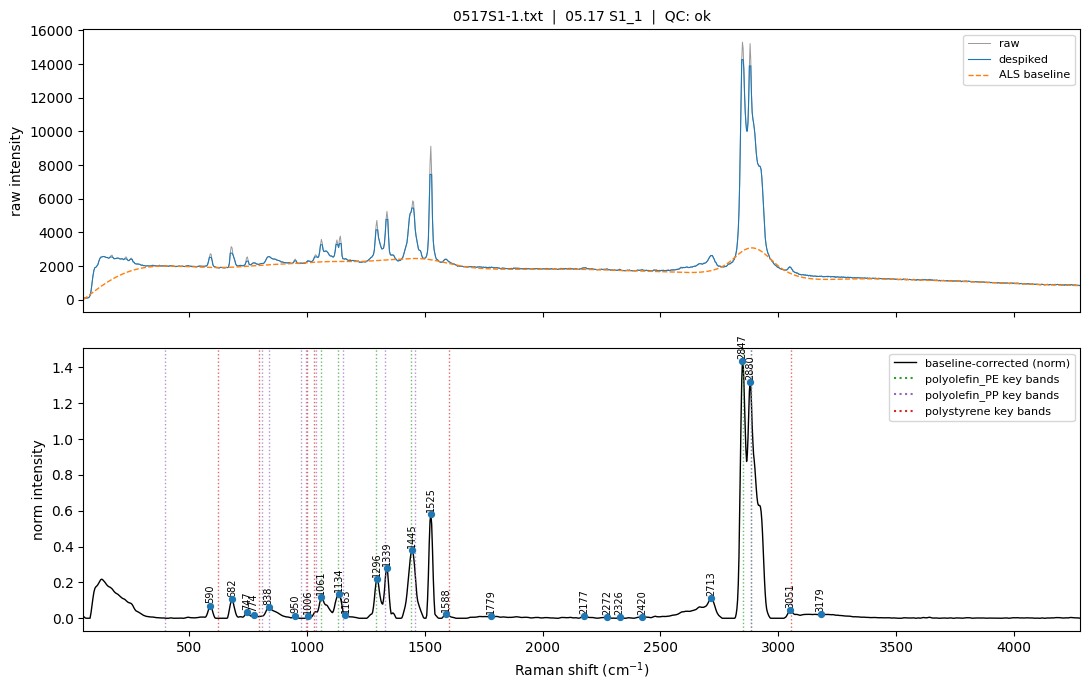


0517S1-1.txt  |  05.17 S1_1  |  QC: ok
  detected peaks (cm-1): 590.3, 682.7, 747.7, 774.3, 838.5, 950.7, 1006.3, 1061.5, 1134.6, 1163.7, 1296.8, 1339.6, 1445.5, 1525.8, 1588.1, 1779.1, 2177.1, 2272.8, 2326.5, 2420.5, 2713.9, 2847.6, 2880.0, 3051.2, 3179.3
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role         candidate_class key_hit  key_frac  exclusive                    cap                                                      key_bands_matched exclusive_bands                              unmatched_key                                              shared_with                                                                                            all_bands_matched
terminal           polyolefin_PE     6/6     1.000          0     confident-eligible 1062(1062), 1130(1135), 1295(1297), 1440(1445), 2850(2848), 2883(2880)               -                                          - 1295<->PET1295(d0), 1440<->PA1440(d0), 2883<->PP288

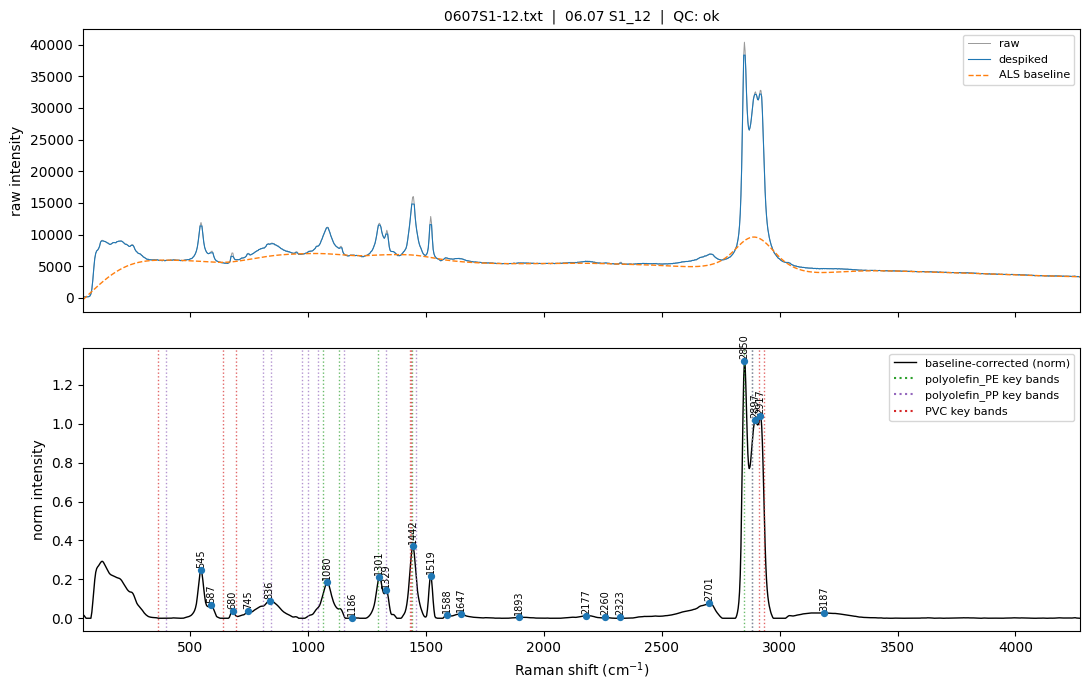


0607S1-12.txt  |  06.07 S1_12  |  QC: ok
  detected peaks (cm-1): 545.2, 587.9, 680.3, 745.2, 836.0, 1081.0, 1186.4, 1301.3, 1329.8, 1442.8, 1519.6, 1588.8, 1647.2, 1893.3, 2177.3, 2260.2, 2323.5, 2701.6, 2850.2, 2897.2, 2917.7, 3187.1
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role        candidate_class key_hit  key_frac  exclusive                    cap                  key_bands_matched exclusive_bands                              unmatched_key                                               shared_with                                                                          all_bands_matched
terminal          polyolefin_PE     3/6     0.500          0     confident-eligible 1295(1301), 1440(1443), 2850(2850)               -                           1062, 1130, 2883 1295<->PET1295(d0), 1440<->PA1440(d0), 1440<->PVC1437(d3)                                             1295(1301), 1440(1443), 2850(2850), 1080(1081)
terminal      

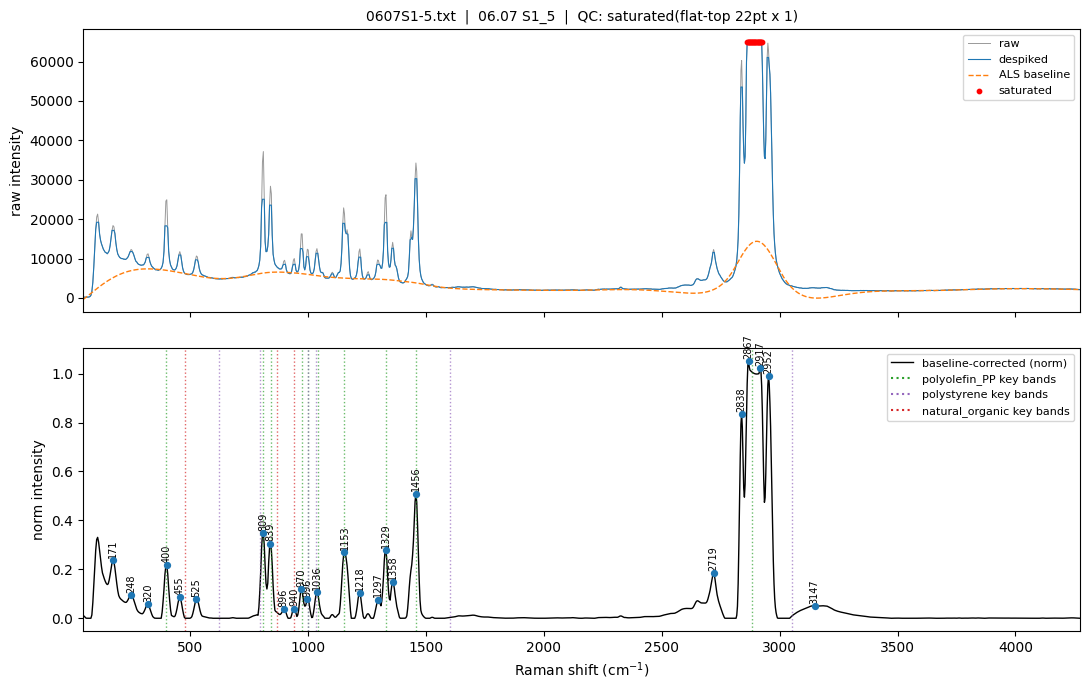


0607S1-5.txt  |  06.07 S1_5  |  QC: saturated(flat-top 22pt x 1)
  detected peaks (cm-1): 171.9, 248.6, 320.7, 400.1, 455.3, 525.7, 809.6, 839.8, 896.0, 940.8, 970.5, 996.4, 1036.9, 1153.8, 1218.9, 1297.7, 1329.8, 1358.2, 1456.8, 2719.6, 2838.5, 2867.9, 2917.7, 2952.6, 3147.6
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role         candidate_class key_hit  key_frac  exclusive                    cap                                                                                key_bands_matched exclusive_bands                   unmatched_key                                                                 shared_with                                                                                                                                                                                                                                all_bands_matched
terminal           polyolefin_PP    9/10     0.900          1     confident-elig

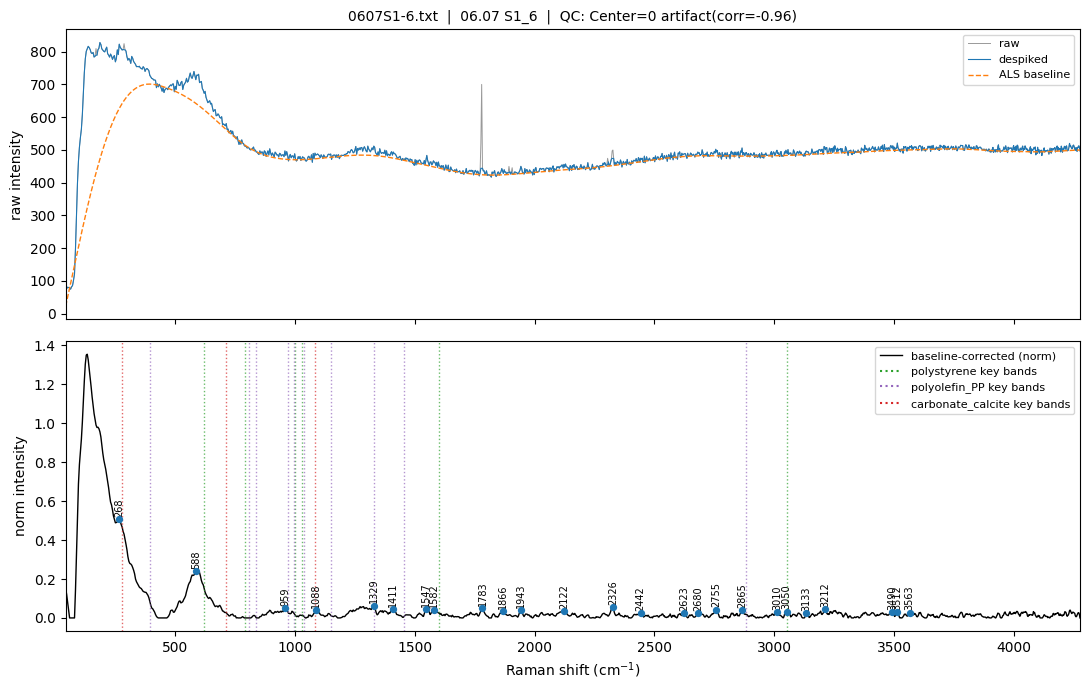


0607S1-6.txt  |  06.07 S1_6  |  QC: Center=0 artifact(corr=-0.96)
  detected peaks (cm-1): 268.9, 588.1, 959.5, 1088.5, 1330.0, 1411.3, 1547.5, 1582.1, 1783.1, 1866.8, 1943.1, 2122.7, 2326.8, 2442.4, 2623.4, 2680.8, 2755.6, 2865.1, 3010.7, 3050.9, 3133.6, 3212.6, 3490.9, 3512.5, 3563.5
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role        candidate_class key_hit  key_frac  exclusive                    cap key_bands_matched exclusive_bands                                   unmatched_key              shared_with      all_bands_matched
terminal            polystyrene     1/6     0.167          1     confident-eligible        3054(3051)            3054                      621, 795, 1001, 1031, 1602                        - 1583(1582), 3054(3051)
terminal          polyolefin_PP    1/10     0.100          0     confident-eligible        1330(1330)               - 398, 809, 841, 973, 998, 1040, 1152, 1458, 2883                        

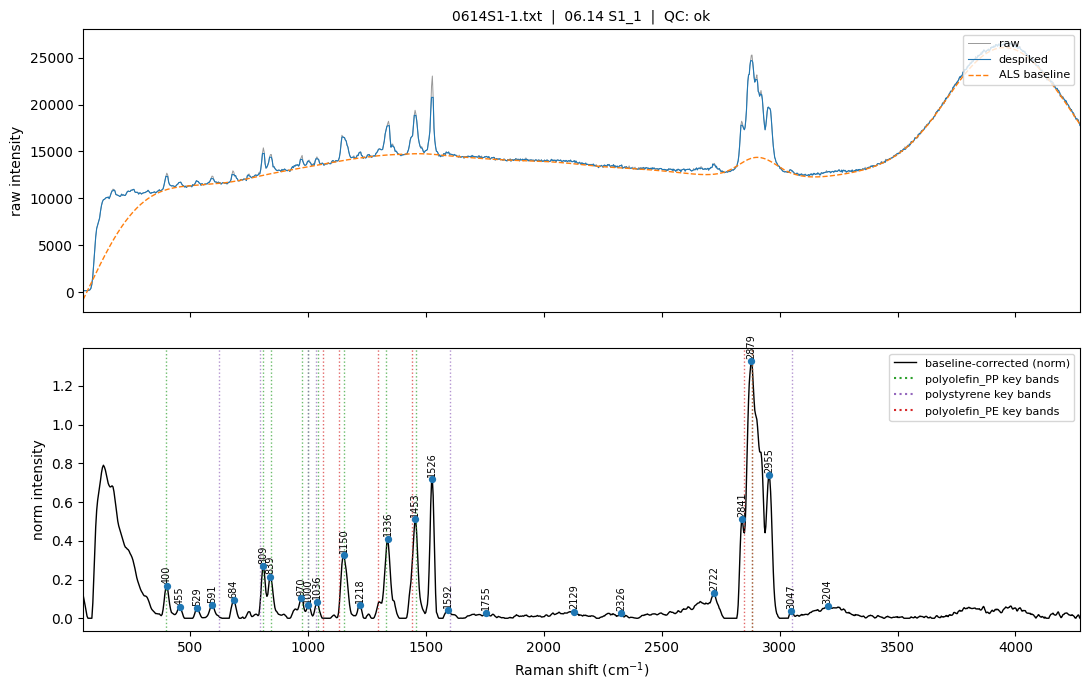


0614S1-1.txt  |  06.14 S1_1  |  QC: ok
  detected peaks (cm-1): 400.1, 455.3, 529.6, 591.8, 684.2, 809.6, 839.8, 970.5, 1000.1, 1036.9, 1150.2, 1218.9, 1336.9, 1453.3, 1526.5, 1592.2, 1756.0, 2129.0, 2326.6, 2722.6, 2841.4, 2879.6, 2955.5, 3047.9, 3204.0
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role         candidate_class key_hit  key_frac  exclusive                    cap                                                                                             key_bands_matched exclusive_bands                         unmatched_key                                                                                                                    shared_with                                                                                                                                                     all_bands_matched
terminal           polyolefin_PP   10/10     1.000          1     confident-eligible 398(400), 809(810), 84

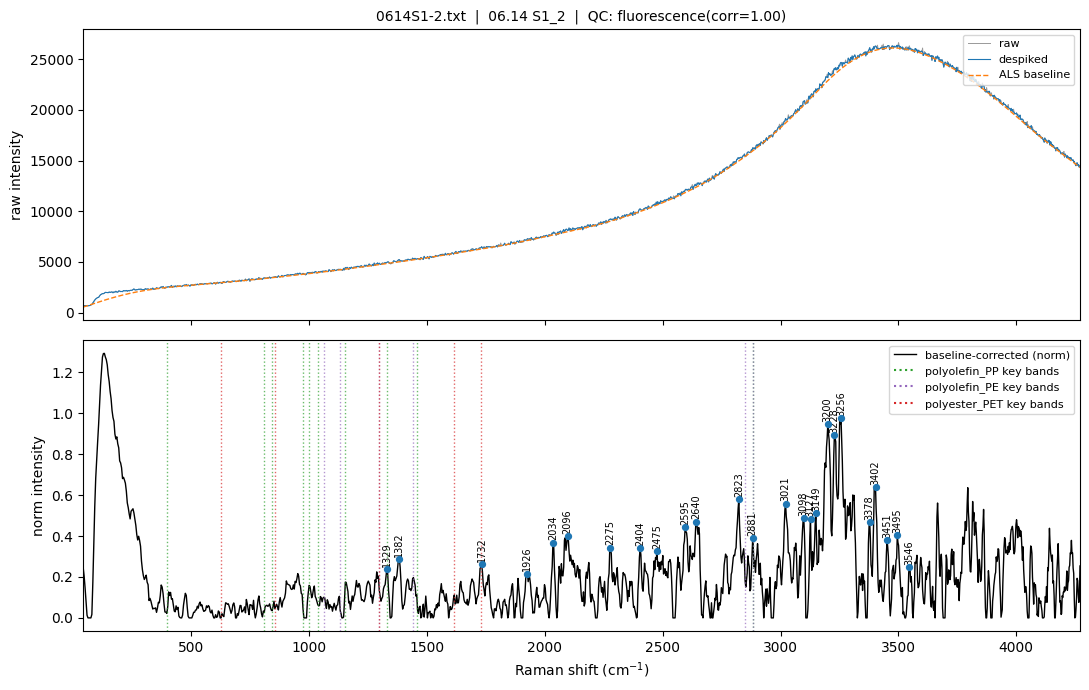


0614S1-2.txt  |  06.14 S1_2  |  QC: fluorescence(corr=1.00)
  detected peaks (cm-1): 1329.8, 1382.9, 1732.1, 1926.2, 2034.6, 2096.4, 2275.7, 2404.5, 2475.9, 2595.4, 2640.9, 2823.1, 2882.0, 3021.4, 3098.7, 3127.1, 3149.8, 3200.5, 3228.6, 3256.5, 3378.2, 3402.9, 3451.9, 3495.3, 3546.4
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role candidate_class key_hit  key_frac  exclusive                cap      key_bands_matched exclusive_bands                             unmatched_key       shared_with      all_bands_matched
terminal   polyolefin_PP    2/10     0.200          0 confident-eligible 1330(1330), 2883(2882)               - 398, 809, 841, 973, 998, 1040, 1152, 1458 2883<->PE2883(d0) 1330(1330), 2883(2882)
terminal   polyolefin_PE     1/6     0.167          0 confident-eligible             2883(2882)               -              1062, 1130, 1295, 1440, 2850 2883<->PP2883(d0)             2883(2882)
terminal   polyester_PET     1/5   

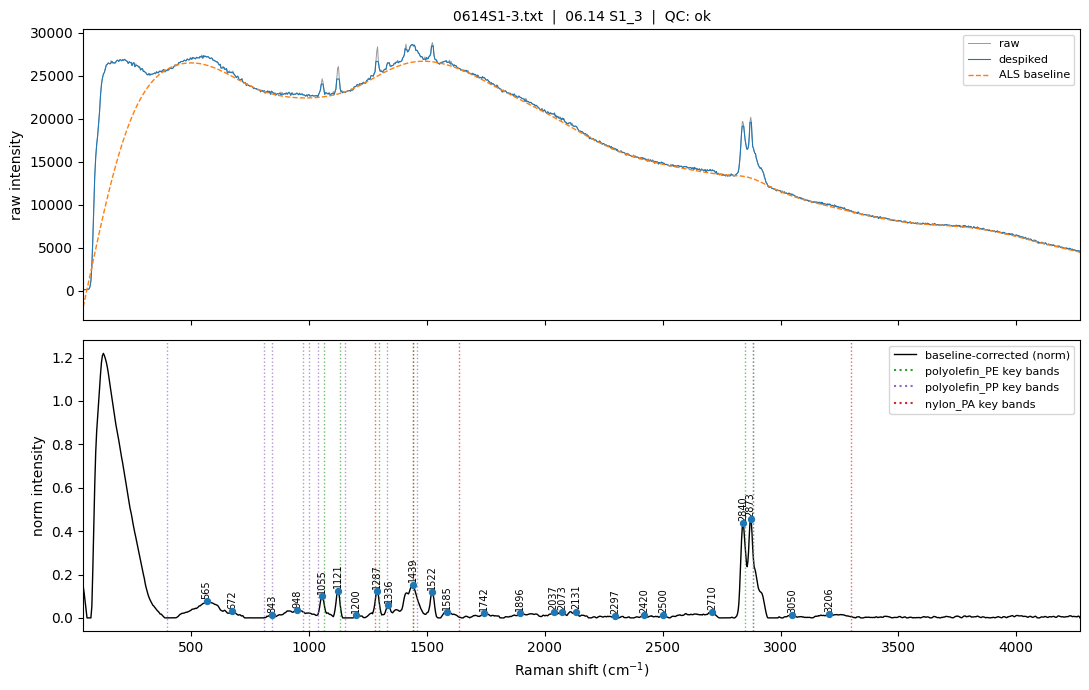


0614S1-3.txt  |  06.14 S1_3  |  QC: ok
  detected peaks (cm-1): 565.0, 673.0, 843.8, 948.4, 1055.5, 1121.2, 1201.0, 1287.1, 1336.9, 1439.2, 1523.0, 1585.3, 1742.3, 1896.4, 2037.9, 2073.7, 2131.9, 2297.9, 2420.1, 2500.5, 2710.1, 2840.8, 2873.2, 3050.1, 3206.1
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role        candidate_class key_hit  key_frac  exclusive                    cap                  key_bands_matched exclusive_bands                              unmatched_key                                                                    shared_with                                                  all_bands_matched
terminal          polyolefin_PE     3/6     0.500          0     confident-eligible 1062(1055), 1295(1287), 1440(1439)               -                           1130, 2850, 2883  1295<->PA1280(d15), 1295<->PET1295(d0), 1440<->PA1440(d0), 1440<->PVC1437(d3)                                 1062(1055), 1295(1287), 1440(143

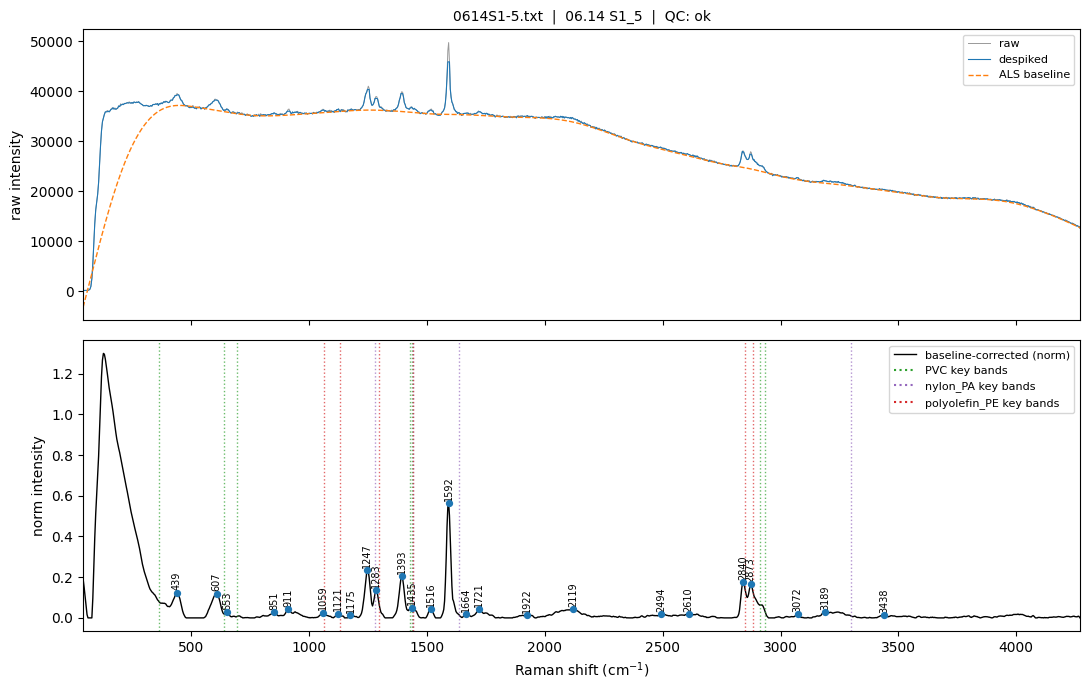


0614S1-5.txt  |  06.14 S1_5  |  QC: ok
  detected peaks (cm-1): 440.0, 607.6, 653.8, 851.3, 911.2, 1059.1, 1121.2, 1175.7, 1247.7, 1283.5, 1393.5, 1435.7, 1516.0, 1592.1, 1664.1, 1722.0, 1922.9, 2119.0, 2494.4, 2610.6, 2840.8, 2873.2, 3073.0, 3189.3, 3438.3
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role     candidate_class key_hit  key_frac  exclusive                    cap      key_bands_matched exclusive_bands                                         unmatched_key                                                                  shared_with                                                    all_bands_matched
terminal                 PVC     2/7     0.286          0     confident-eligible 1430(1436), 1437(1436)               -                             363, 638, 694, 2914, 2935 1430<->PA1440(d10), 1430<->PE1440(d10), 1437<->PA1440(d3), 1437<->PE1440(d3) 615(608), 1066(1059), 1119(1121), 1172(1176), 1430(1436), 1437(1436)
termin

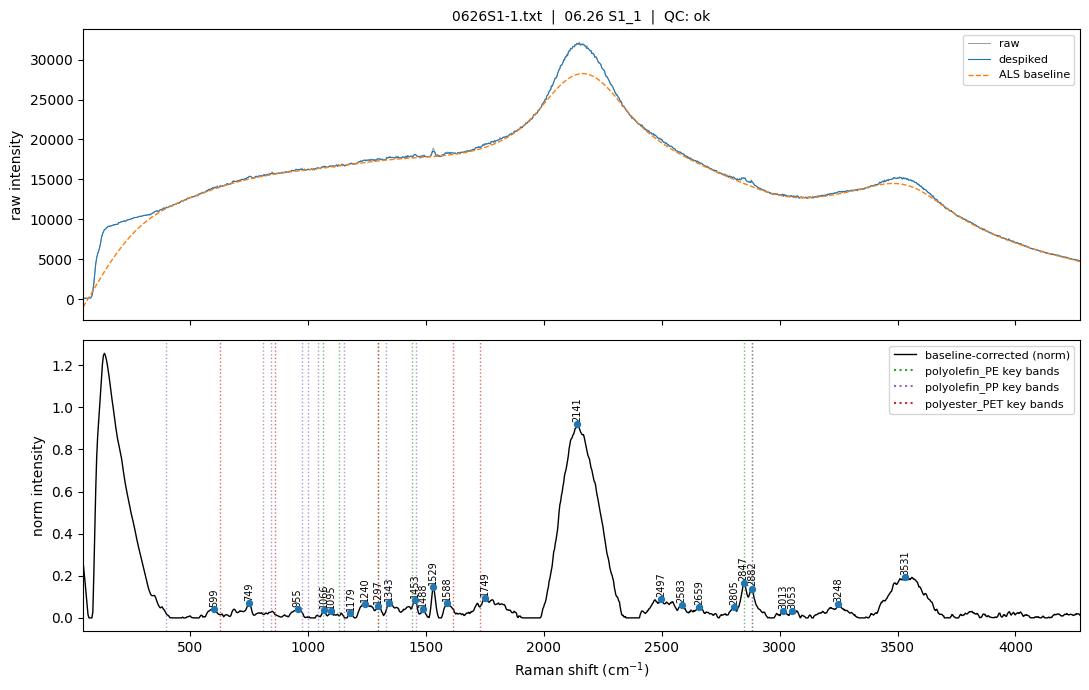


0626S1-1.txt  |  06.26 S1_1  |  QC: ok
  detected peaks (cm-1): 599.5, 749.0, 955.6, 1066.3, 1095.6, 1179.2, 1240.5, 1297.7, 1344.0, 1453.3, 1488.2, 1530.0, 1588.8, 1749.2, 2141.9, 2497.9, 2583.7, 2659.5, 2806.0, 2847.3, 2882.6, 3013.4, 3053.6, 3248.9, 3531.1
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role        candidate_class key_hit  key_frac  exclusive                    cap                              key_bands_matched exclusive_bands                             unmatched_key                           shared_with                                                              all_bands_matched
terminal          polyolefin_PE     4/6     0.667          0     confident-eligible 1062(1066), 1295(1298), 2850(2847), 2883(2883)               -                                1130, 1440 1295<->PET1295(d0), 2883<->PP2883(d0)                     1062(1066), 1295(1298), 1460(1453), 2850(2847), 2883(2883)
terminal          polyolefin_PP 

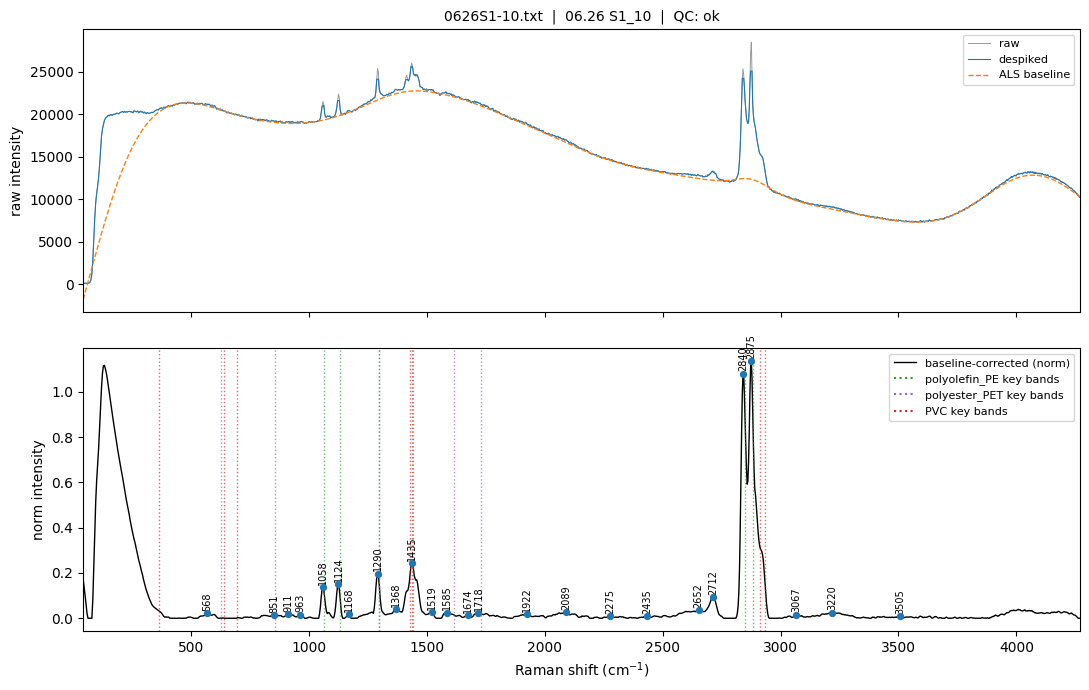


0626S1-10.txt  |  06.26 S1_10  |  QC: ok
  detected peaks (cm-1): 568.7, 851.2, 911.0, 963.1, 1059.0, 1124.7, 1168.3, 1290.5, 1368.7, 1435.6, 1519.4, 1585.1, 1674.2, 1718.4, 1922.8, 2089.8, 2275.6, 2435.5, 2652.8, 2712.9, 2840.7, 2876.0, 3067.1, 3220.0, 3505.9
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role      candidate_class key_hit  key_frac  exclusive                    cap                                          key_bands_matched exclusive_bands                                   unmatched_key                                                                                       shared_with                                                                  all_bands_matched
terminal        polyolefin_PE     5/6     0.833          0     confident-eligible 1062(1059), 1130(1125), 1295(1291), 1440(1436), 2883(2876)               -                                            2850 1295<->PET1295(d0), 1440<->PA1440(d0), 1440<->PVC143

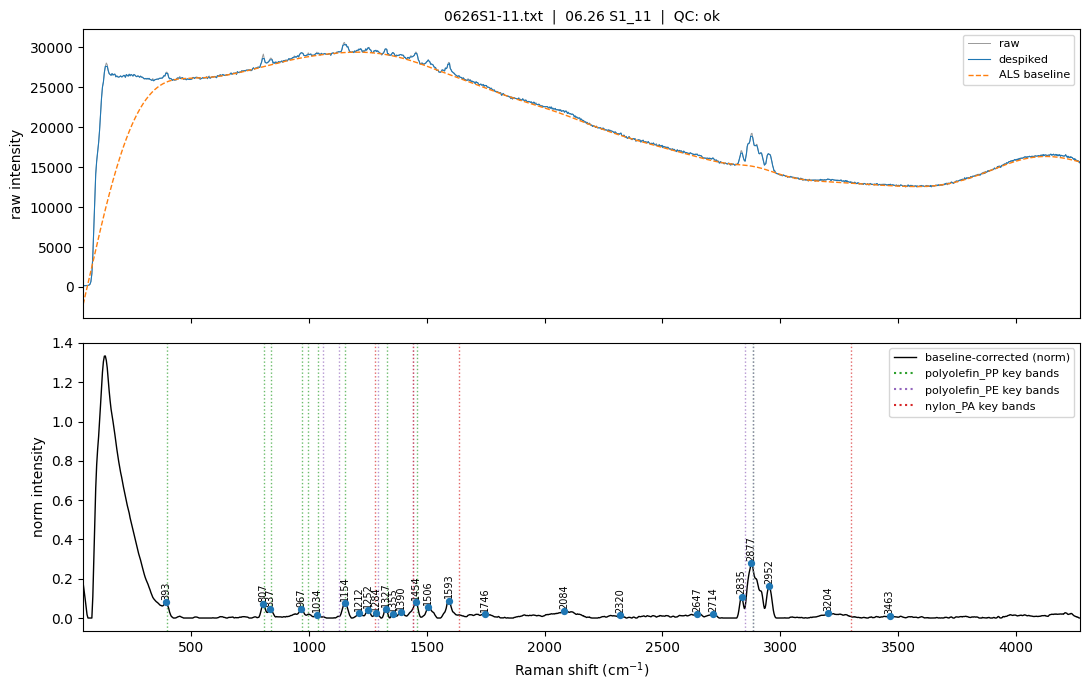


0626S1-11.txt  |  06.26 S1_11  |  QC: ok
  detected peaks (cm-1): 393.6, 807.1, 837.2, 967.9, 1034.4, 1154.9, 1212.7, 1252.2, 1284.5, 1327.2, 1355.6, 1390.9, 1454.2, 1506.6, 1593.1, 1746.6, 2084.4, 2320.9, 2647.8, 2714.0, 2835.9, 2877.0, 2952.9, 3204.3, 3463.7
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role        candidate_class key_hit  key_frac  exclusive                    cap                                                                                  key_bands_matched exclusive_bands                         unmatched_key                                                         shared_with                                                                                                                                                                    all_bands_matched
terminal          polyolefin_PP    9/10     0.900          1     confident-eligible 398(394), 809(807), 841(837), 973(968), 1040(1034), 1152(1155), 1330(1327

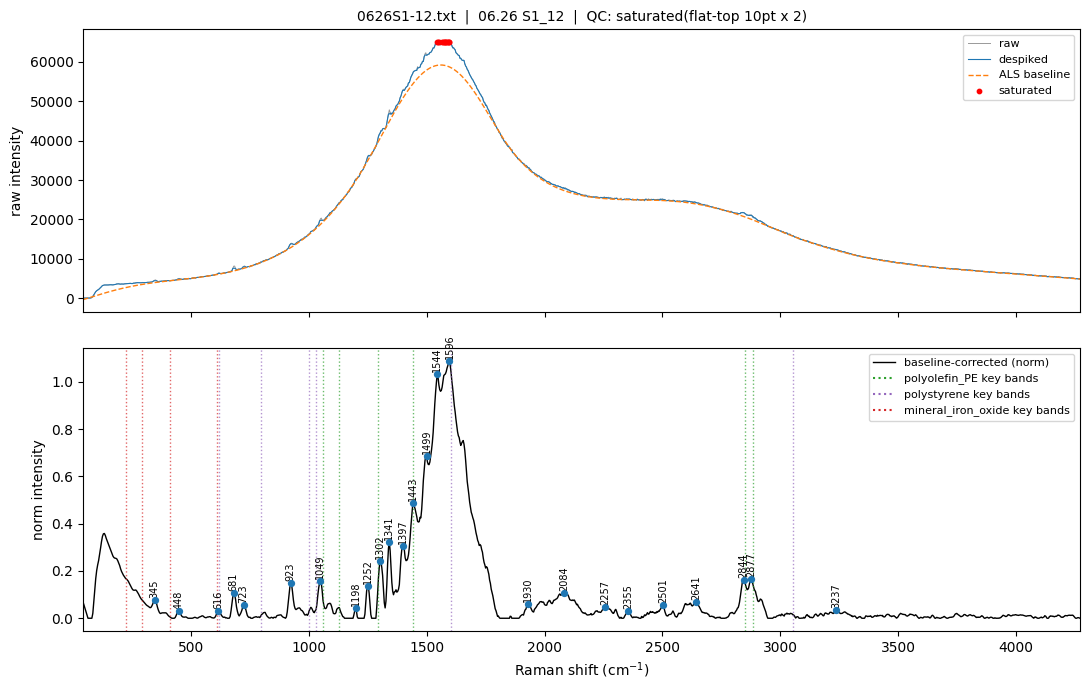


0626S1-12.txt  |  06.26 S1_12  |  QC: saturated(flat-top 10pt x 2)
  detected peaks (cm-1): 346.0, 448.8, 616.2, 681.6, 723.6, 923.3, 1049.1, 1198.3, 1252.2, 1302.3, 1341.4, 1398.0, 1443.7, 1499.6, 1544.7, 1596.5, 1930.5, 2084.4, 2257.6, 2355.4, 2501.5, 2641.8, 2844.7, 2877.0, 3237.9
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role         candidate_class key_hit  key_frac  exclusive                    cap                              key_bands_matched exclusive_bands                                   unmatched_key                                                                  shared_with                                                                      all_bands_matched
terminal           polyolefin_PE     4/6     0.667          0     confident-eligible 1295(1302), 1440(1444), 2850(2845), 2883(2877)               -                                      1062, 1130 1295<->PET1295(d0), 1440<->PA1440(d0), 1440<->PVC1437(d3), 2883

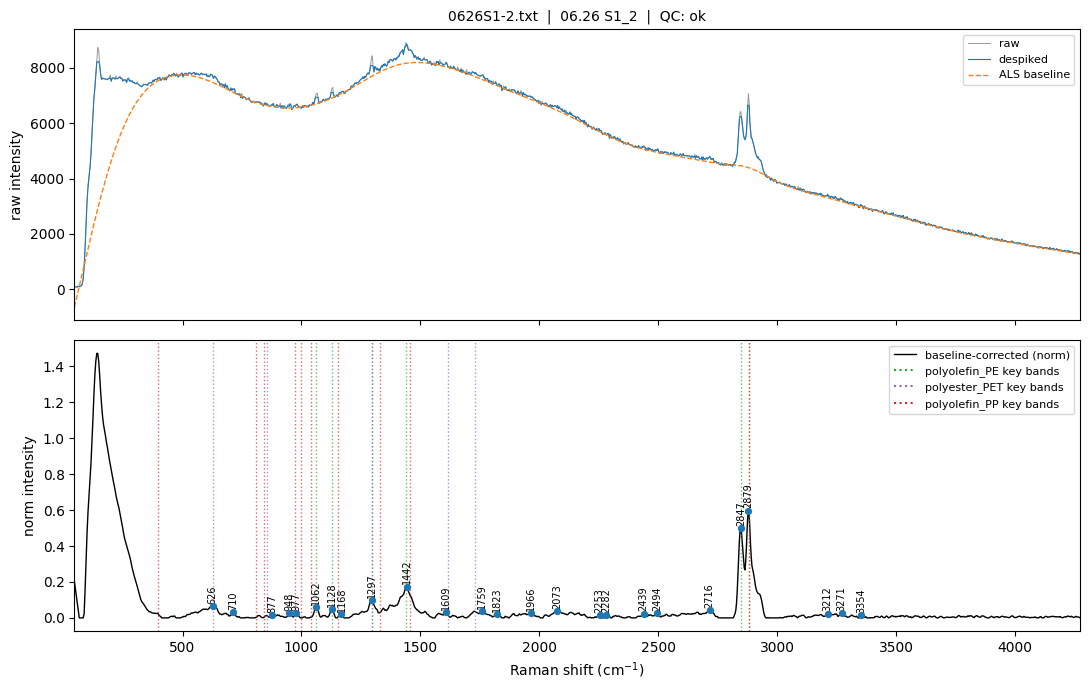


0626S1-2.txt  |  06.26 S1_2  |  QC: ok
  detected peaks (cm-1): 626.5, 710.9, 877.3, 948.2, 977.9, 1062.6, 1128.4, 1168.3, 1297.7, 1442.8, 1609.4, 1759.3, 1823.2, 1966.0, 2074.0, 2253.9, 2282.4, 2439.1, 2494.8, 2716.6, 2847.3, 2879.6, 3212.5, 3271.2, 3354.2
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role         candidate_class key_hit  key_frac  exclusive                    cap                                                      key_bands_matched exclusive_bands                              unmatched_key                                                                  shared_with                                                                  all_bands_matched
terminal           polyolefin_PE     6/6     1.000          0     confident-eligible 1062(1063), 1130(1128), 1295(1298), 1440(1443), 2850(2847), 2883(2880)               -                                          - 1295<->PET1295(d0), 1440<->PA1440(d0), 1440<->PVC1437(d3

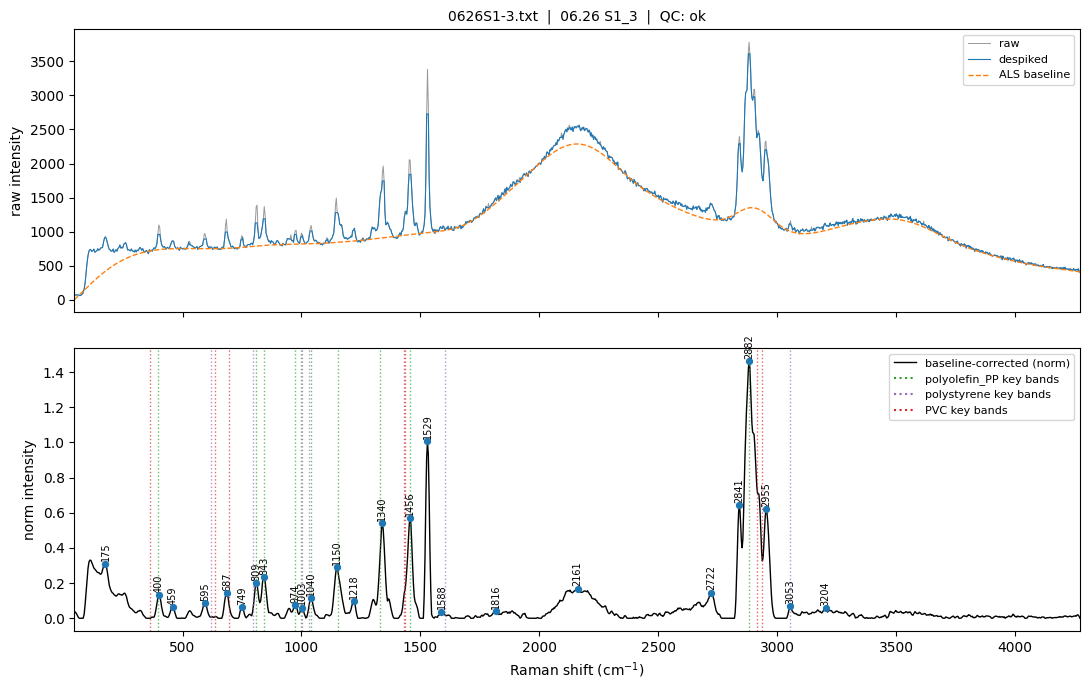


0626S1-3.txt  |  06.26 S1_3  |  QC: ok
  detected peaks (cm-1): 175.9, 400.1, 459.2, 595.6, 688.0, 749.0, 809.6, 843.6, 974.2, 1003.8, 1040.6, 1150.2, 1218.9, 1340.4, 1456.8, 1530.0, 1588.8, 1816.5, 2161.2, 2722.6, 2841.4, 2882.6, 2955.5, 3053.6, 3204.0
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role         candidate_class key_hit  key_frac  exclusive                    cap                                                                                 key_bands_matched exclusive_bands                    unmatched_key                                                        shared_with                                                                                                                               all_bands_matched
terminal           polyolefin_PP    9/10     0.900          1     confident-eligible 398(400), 809(810), 841(844), 973(974), 998(1004), 1040(1041), 1152(1150), 1458(1457), 2883(2883)            1040         

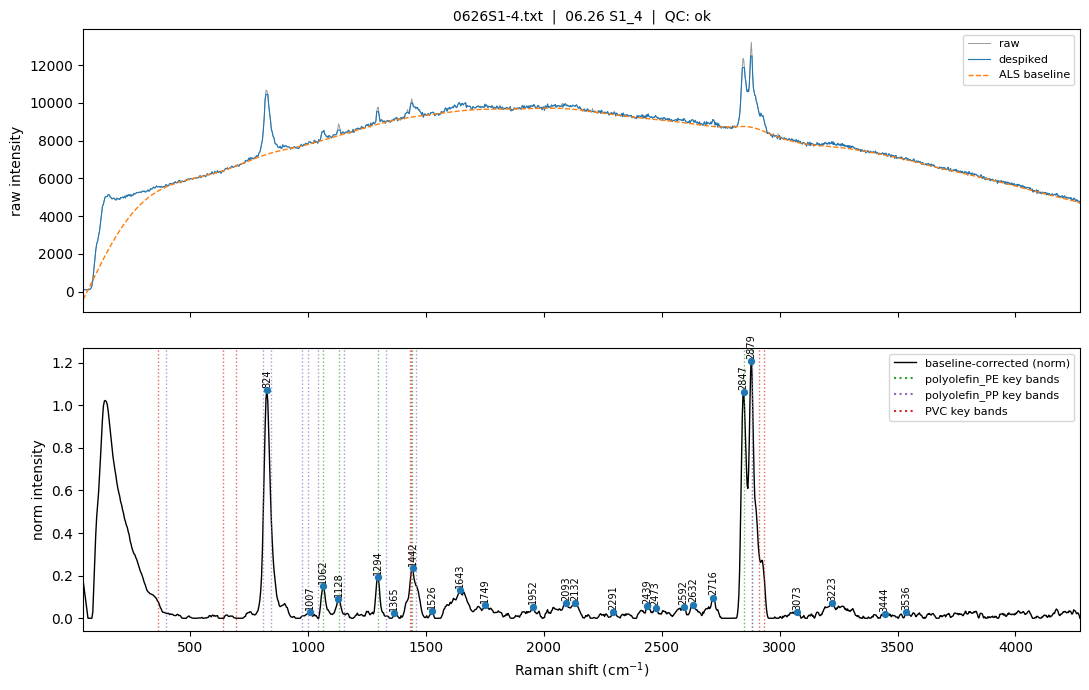


0626S1-4.txt  |  06.26 S1_4  |  QC: ok
  detected peaks (cm-1): 824.7, 1007.5, 1062.6, 1128.4, 1294.2, 1365.3, 1442.8, 1526.5, 1643.7, 1749.2, 1952.9, 2093.4, 2132.2, 2291.9, 2439.1, 2473.2, 2592.8, 2632.3, 2716.6, 2847.3, 2879.6, 3073.6, 3223.7, 3444.6, 3536.5
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role         candidate_class key_hit  key_frac  exclusive                    cap                                                      key_bands_matched exclusive_bands                                   unmatched_key                                                                  shared_with                                                                all_bands_matched
terminal           polyolefin_PE     6/6     1.000          0     confident-eligible 1062(1063), 1130(1128), 1295(1294), 1440(1443), 2850(2847), 2883(2880)               -                                               - 1295<->PET1295(d0), 1440<->PA1440(d0), 1440<

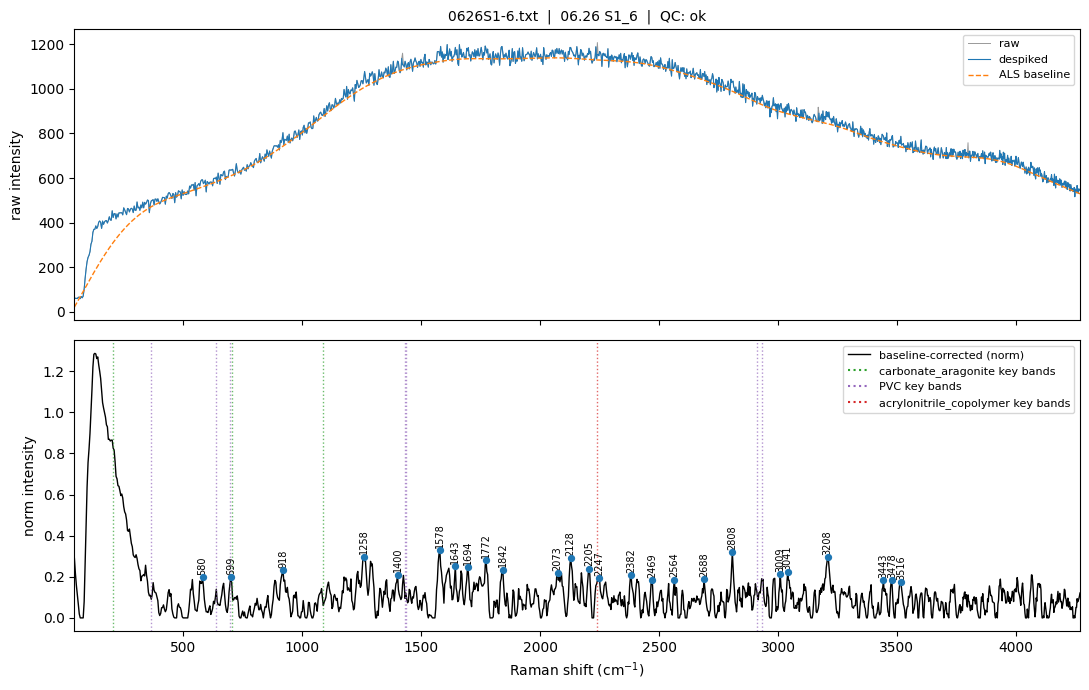


0626S1-6.txt  |  06.26 S1_6  |  QC: ok
  detected peaks (cm-1): 580.4, 699.6, 918.5, 1258.3, 1400.4, 1578.2, 1643.5, 1694.7, 1772.5, 1843.0, 2073.5, 2128.6, 2205.6, 2247.0, 2382.5, 2469.5, 2564.7, 2688.9, 2808.2, 3009.7, 3041.3, 3208.8, 3443.6, 3478.9, 3516.7
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role         candidate_class key_hit  key_frac  exclusive                    cap key_bands_matched exclusive_bands                                         unmatched_key             shared_with    all_bands_matched
terminal     carbonate_aragonite     1/3     0.333          0     confident-eligible          705(700)               -                                             206, 1085       705<->PVC694(d11)             705(700)
terminal                     PVC     1/7     0.143          0     confident-eligible          694(700)               -                      363, 638, 1430, 1437, 2914, 2935 694<->aragonite705(d11) 694(700), 1

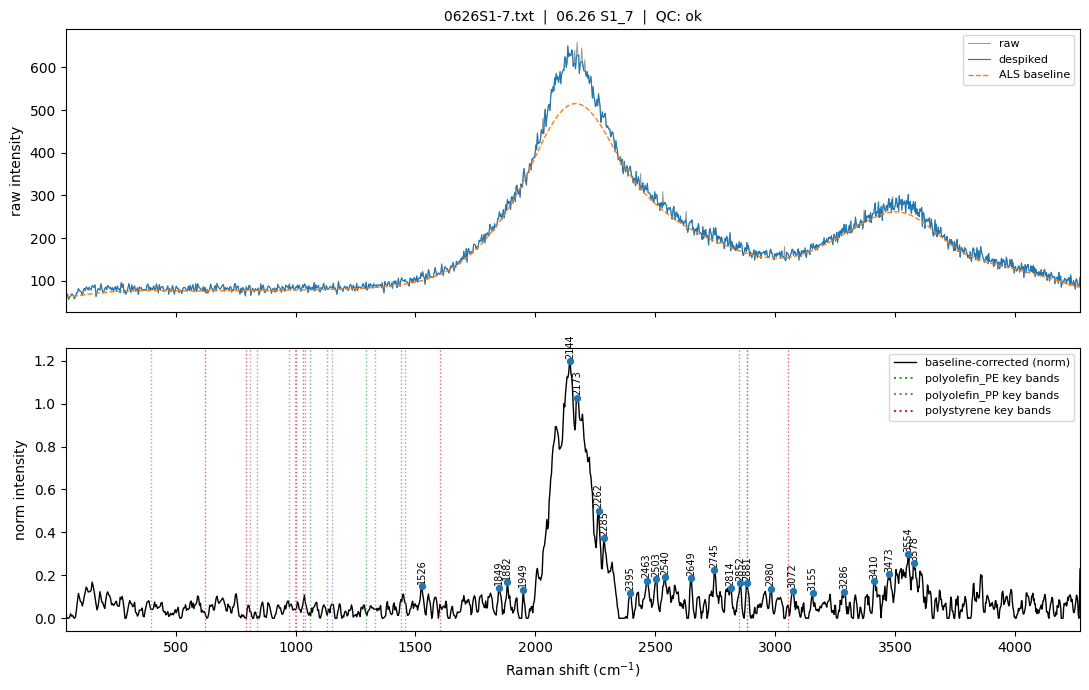


0626S1-7.txt  |  06.26 S1_7  |  QC: ok
  detected peaks (cm-1): 1526.3, 1849.7, 1883.0, 1949.2, 2144.7, 2173.6, 2262.9, 2285.1, 2395.0, 2463.3, 2503.4, 2540.3, 2649.8, 2745.8, 2814.1, 2852.5, 2881.8, 2980.8, 3072.8, 3155.3, 3287.0, 3410.9, 3473.5, 3554.3, 3578.4
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role        candidate_class key_hit  key_frac  exclusive                cap      key_bands_matched exclusive_bands                                   unmatched_key       shared_with      all_bands_matched
terminal          polyolefin_PE     2/6     0.333          0 confident-eligible 2850(2852), 2883(2882)               -                          1062, 1130, 1295, 1440 2883<->PP2883(d0) 2850(2852), 2883(2882)
terminal          polyolefin_PP    1/10     0.100          0 confident-eligible             2883(2882)               - 398, 809, 841, 973, 998, 1040, 1152, 1330, 1458 2883<->PE2883(d0)             2883(2882)
terminal         

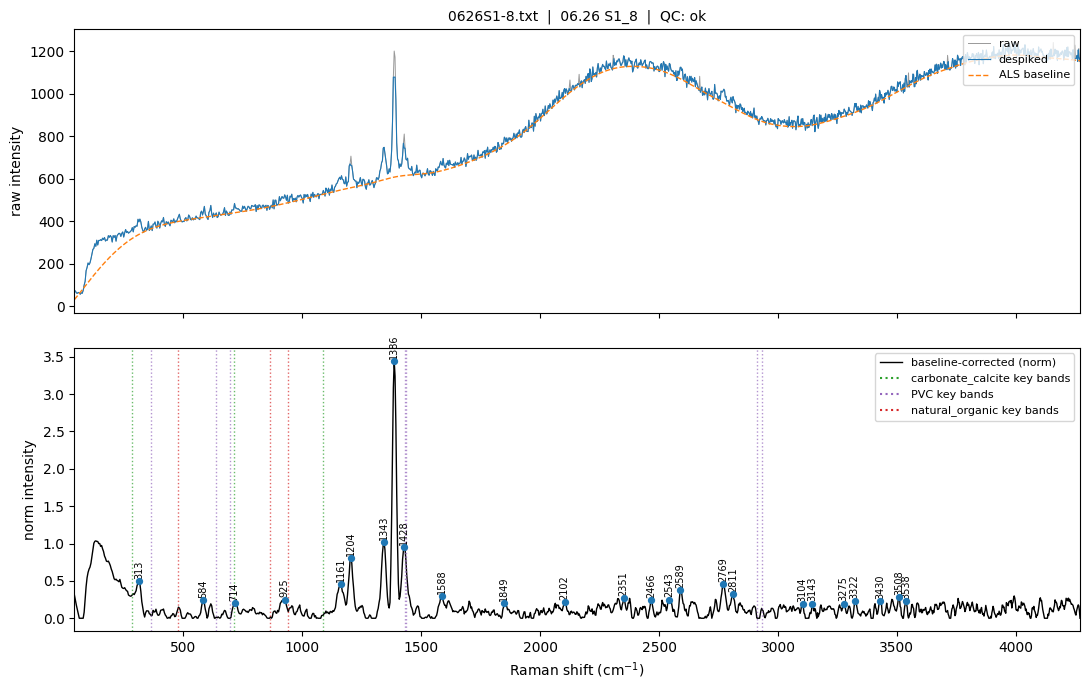


0626S1-8.txt  |  06.26 S1_8  |  QC: ok
  detected peaks (cm-1): 313.0, 584.2, 714.9, 925.9, 1161.0, 1204.4, 1343.9, 1386.3, 1428.6, 1588.6, 1849.7, 2102.7, 2351.2, 2466.4, 2543.3, 2589.1, 2769.6, 2811.2, 3104.2, 3143.9, 3275.8, 3323.0, 3430.0, 3508.6, 3538.2
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role        candidate_class key_hit  key_frac  exclusive                    cap key_bands_matched exclusive_bands                                         unmatched_key                   shared_with                          all_bands_matched
terminal      carbonate_calcite     1/3     0.333          0     confident-eligible          712(715)               -                                             282, 1086                             -                       712(715), 1435(1429)
terminal                    PVC     1/7     0.143          0     confident-eligible        1430(1429)               -                       363, 638, 694, 

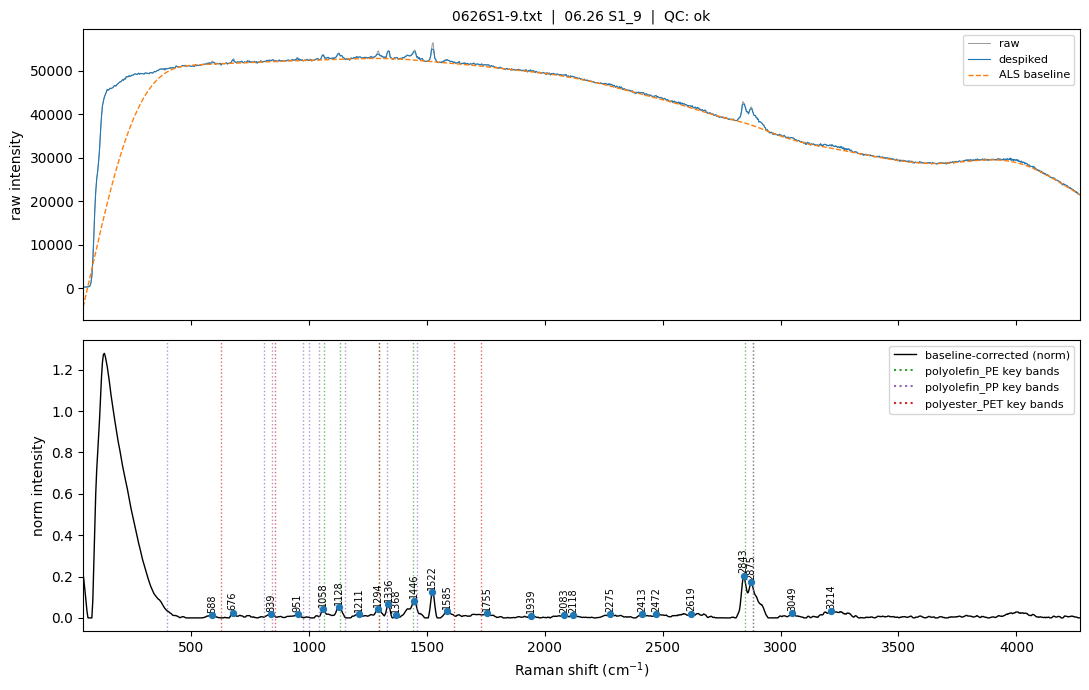


0626S1-9.txt  |  06.26 S1_9  |  QC: ok
  detected peaks (cm-1): 588.1, 676.7, 839.9, 952.0, 1059.0, 1128.4, 1211.6, 1294.1, 1336.8, 1368.7, 1446.1, 1522.8, 1585.1, 1755.7, 1939.3, 2083.3, 2118.9, 2275.6, 2413.7, 2472.6, 2619.5, 2843.6, 2876.0, 3049.9, 3214.4
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role        candidate_class key_hit  key_frac  exclusive                    cap                                                      key_bands_matched exclusive_bands                         unmatched_key                                              shared_with                                                                            all_bands_matched
terminal          polyolefin_PE     6/6     1.000          0     confident-eligible 1062(1059), 1130(1128), 1295(1294), 1440(1446), 2850(2844), 2883(2876)               -                                     - 1295<->PET1295(d0), 1440<->PA1440(d0), 2883<->PP2883(d0)                     

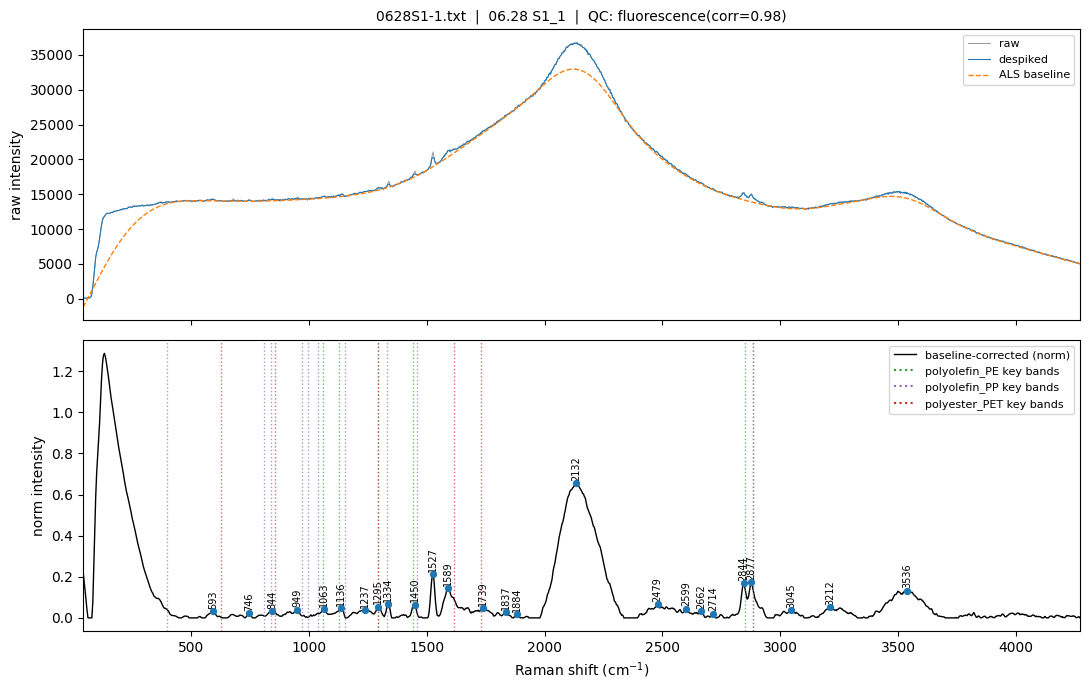


0628S1-1.txt  |  06.28 S1_1  |  QC: fluorescence(corr=0.98)
  detected peaks (cm-1): 593.1, 746.4, 844.7, 949.4, 1063.7, 1136.7, 1237.9, 1295.2, 1334.3, 1450.7, 1527.4, 1589.6, 1739.9, 1837.4, 1884.1, 2132.9, 2479.9, 2599.4, 2662.9, 2714.0, 2844.7, 2877.0, 3045.3, 3212.7, 3536.6
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role        candidate_class key_hit  key_frac  exclusive                    cap                                          key_bands_matched exclusive_bands                         unmatched_key                                       shared_with                                                                all_bands_matched
terminal          polyolefin_PE     5/6     0.833          0     confident-eligible 1062(1064), 1130(1137), 1295(1295), 2850(2845), 2883(2877)               -                                  1440             1295<->PET1295(d0), 2883<->PP2883(d0)                       1062(1064), 1130(1137), 129

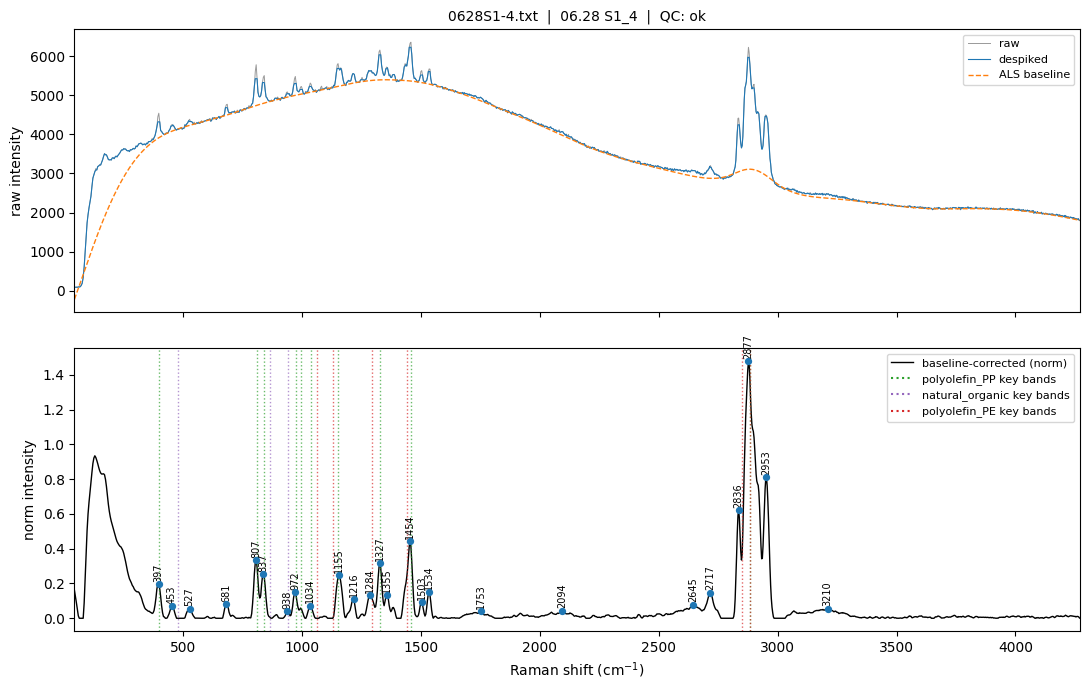


0628S1-4.txt  |  06.28 S1_4  |  QC: ok
  detected peaks (cm-1): 397.9, 453.1, 527.5, 682.0, 807.5, 837.6, 938.6, 972.0, 1034.8, 1155.3, 1216.7, 1284.8, 1327.6, 1356.0, 1454.6, 1503.5, 1534.7, 1753.8, 2094.5, 2645.2, 2717.4, 2836.3, 2877.4, 2953.3, 3210.3
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role        candidate_class key_hit  key_frac  exclusive                    cap                                                                                  key_bands_matched exclusive_bands                         unmatched_key                                                         shared_with                                                                                                                                                                                      all_bands_matched
terminal          polyolefin_PP    9/10     0.900          1     confident-eligible 398(398), 809(807), 841(838), 973(972), 1040(1035), 1152(1155

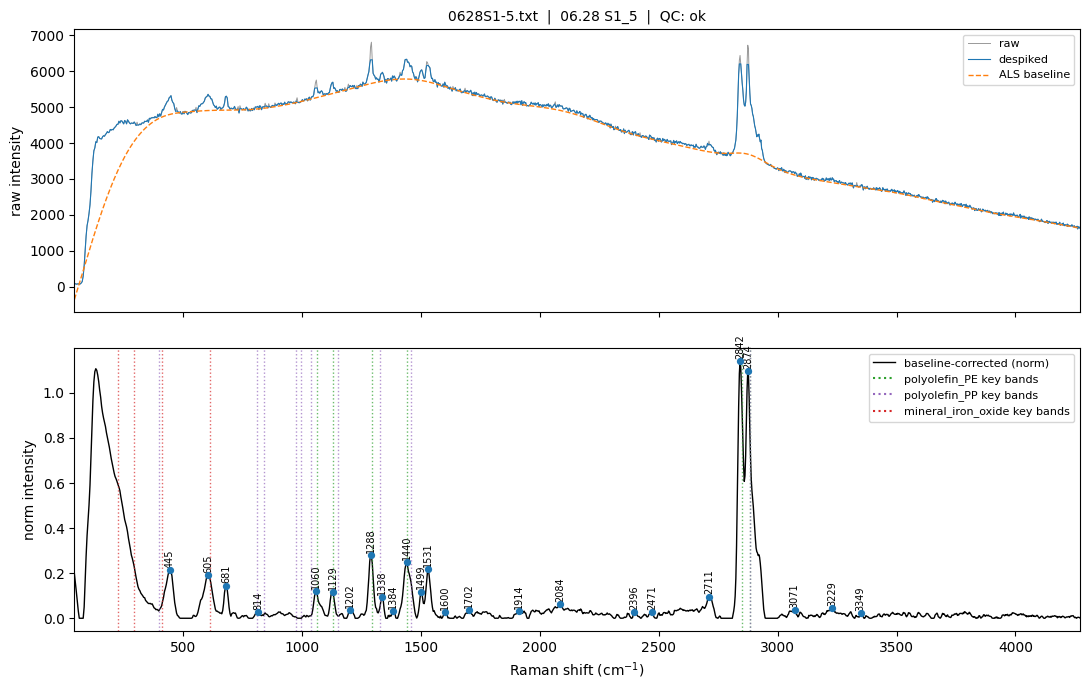


0628S1-5.txt  |  06.28 S1_5  |  QC: ok
  detected peaks (cm-1): 445.2, 605.1, 682.0, 815.0, 1060.5, 1129.8, 1202.3, 1288.4, 1338.3, 1384.3, 1440.6, 1500.0, 1531.3, 1600.4, 1702.9, 1914.3, 2084.8, 2396.5, 2471.0, 2711.4, 2842.2, 2874.5, 3071.5, 3229.9, 3349.3
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role         candidate_class key_hit  key_frac  exclusive                    cap                                          key_bands_matched exclusive_bands                                    unmatched_key                                               shared_with                                                              all_bands_matched
terminal           polyolefin_PE     5/6     0.833          0     confident-eligible 1062(1060), 1130(1130), 1295(1288), 1440(1441), 2850(2842)               -                                             2883 1295<->PET1295(d0), 1440<->PA1440(d0), 1440<->PVC1437(d3)                     1062(1060), 

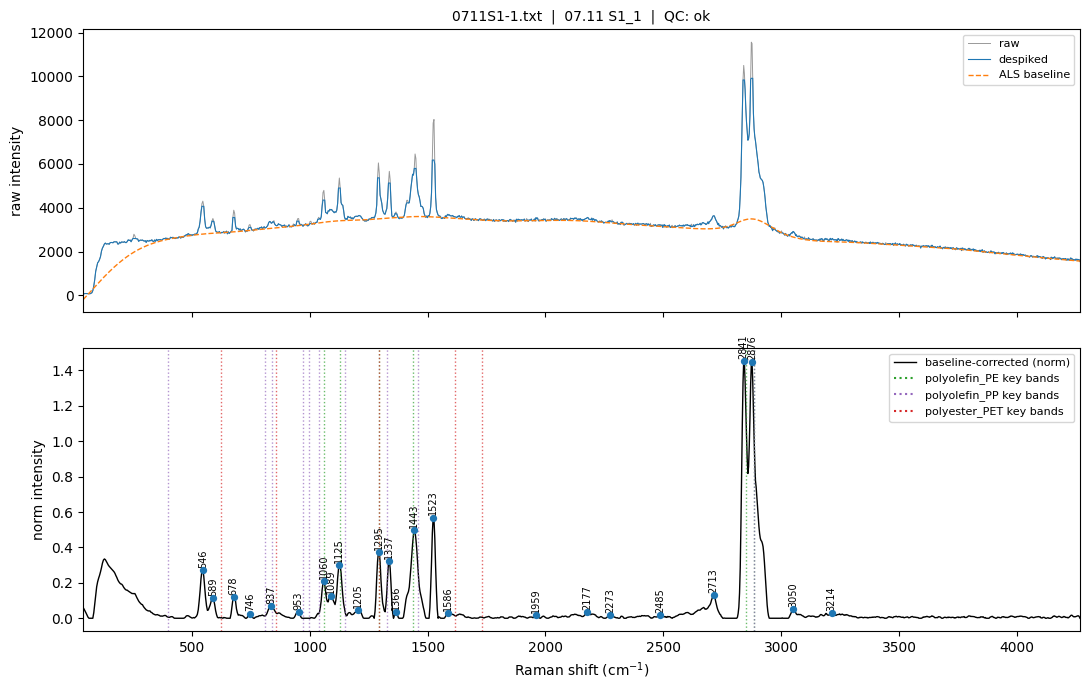


0711S1-1.txt  |  07.11 S1_1  |  QC: ok
  detected peaks (cm-1): 546.9, 589.6, 678.1, 746.7, 837.5, 953.3, 1060.2, 1089.5, 1126.0, 1205.6, 1295.2, 1337.9, 1366.3, 1443.7, 1523.9, 1586.1, 1960.0, 2177.6, 2273.2, 2485.6, 2713.5, 2841.2, 2876.5, 3050.4, 3214.8
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role        candidate_class key_hit  key_frac  exclusive                    cap                                          key_bands_matched exclusive_bands                        unmatched_key                                                                  shared_with                                                                                      all_bands_matched
terminal          polyolefin_PE     5/6     0.833          0     confident-eligible 1062(1060), 1130(1126), 1295(1295), 1440(1444), 2883(2876)               -                                 2850 1295<->PET1295(d0), 1440<->PA1440(d0), 1440<->PVC1437(d3), 2883<->PP2883(d0

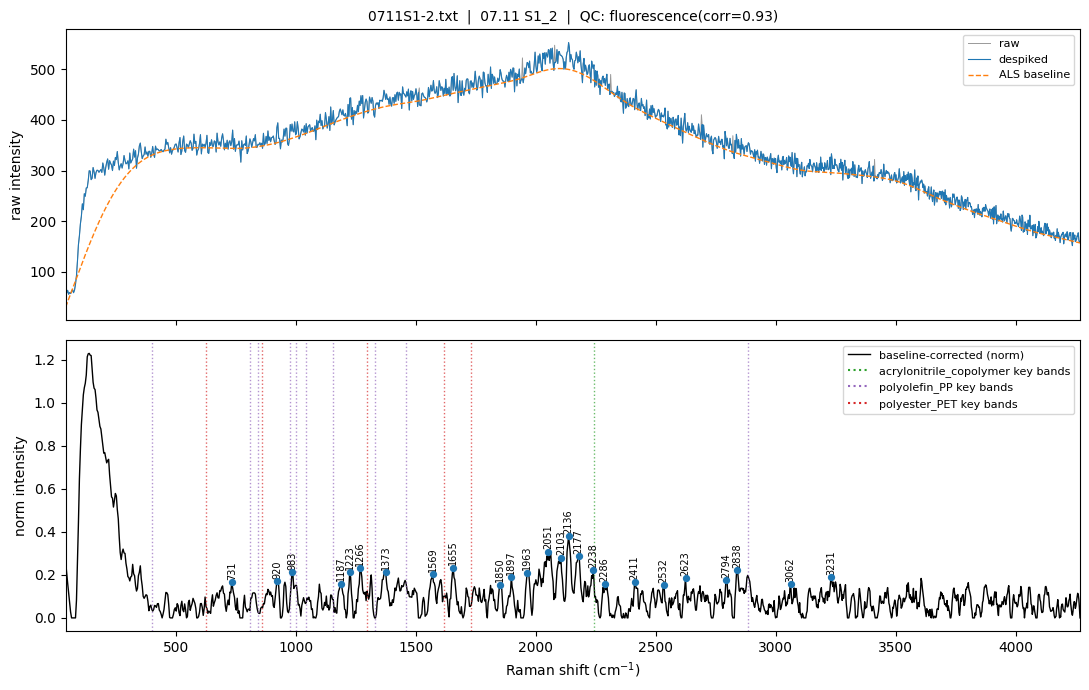


0711S1-2.txt  |  07.11 S1_2  |  QC: fluorescence(corr=0.93)
  detected peaks (cm-1): 731.8, 920.1, 983.2, 1187.9, 1223.9, 1267.0, 1373.6, 1569.2, 1655.1, 1850.9, 1897.5, 1963.6, 2051.9, 2103.9, 2136.1, 2177.9, 2238.6, 2286.1, 2411.6, 2532.1, 2623.5, 2794.3, 2838.6, 3062.2, 3231.9
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role         candidate_class key_hit  key_frac  exclusive                    cap key_bands_matched exclusive_bands                                         unmatched_key shared_with                  all_bands_matched
terminal acrylonitrile_copolymer     1/1       1.0          1 tentative (structural)        2240(2239)            2240                                                     -           -                         2240(2239)
terminal           polyolefin_PP    0/10       0.0          0     confident-eligible                 -               - 398, 809, 841, 973, 998, 1040, 1152, 1330, 1458, 2883           

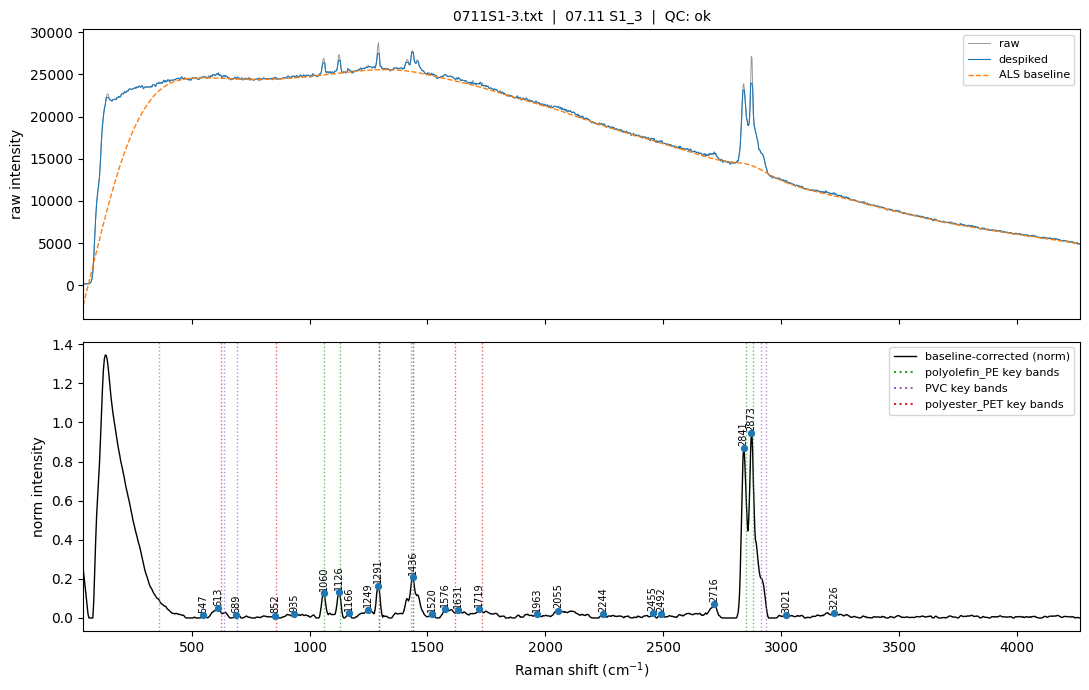


0711S1-3.txt  |  07.11 S1_3  |  QC: ok
  detected peaks (cm-1): 547.2, 613.1, 689.9, 852.8, 935.0, 1060.5, 1126.3, 1166.2, 1249.1, 1292.0, 1437.0, 1520.7, 1576.1, 1631.1, 1719.7, 1963.6, 2055.2, 2244.9, 2455.1, 2492.1, 2716.8, 2841.5, 2873.9, 3022.0, 3226.3
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role         candidate_class key_hit  key_frac  exclusive                    cap                              key_bands_matched exclusive_bands                                         unmatched_key                                                                    shared_with                                                                                                        all_bands_matched
terminal           polyolefin_PE     4/6     0.667          0     confident-eligible 1062(1061), 1130(1126), 1295(1292), 1440(1437)               -                                            2850, 2883 1295<->PET1295(d0), 1440<->PA1440(d0), 144

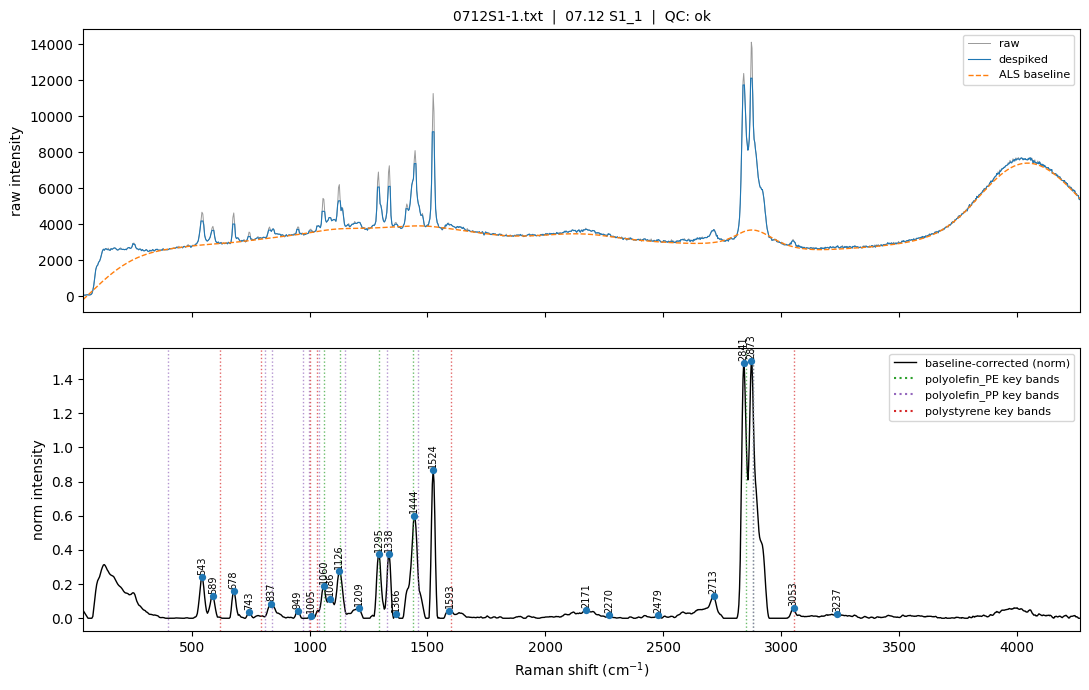


0712S1-1.txt  |  07.12 S1_1  |  QC: ok
  detected peaks (cm-1): 543.3, 589.9, 678.4, 743.3, 837.8, 949.9, 1005.4, 1060.5, 1086.2, 1126.3, 1209.5, 1295.5, 1338.2, 1366.6, 1444.0, 1524.2, 1593.3, 2171.5, 2270.3, 2479.8, 2713.8, 2841.5, 2873.9, 3053.6, 3237.5
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role         candidate_class key_hit  key_frac  exclusive                    cap                              key_bands_matched exclusive_bands                               unmatched_key                                               shared_with                                                                                  all_bands_matched
terminal           polyolefin_PE     4/6     0.667          0     confident-eligible 1062(1061), 1130(1126), 1295(1296), 1440(1444)               -                                  2850, 2883 1295<->PET1295(d0), 1440<->PA1440(d0), 1440<->PVC1437(d3)                                         1062(106

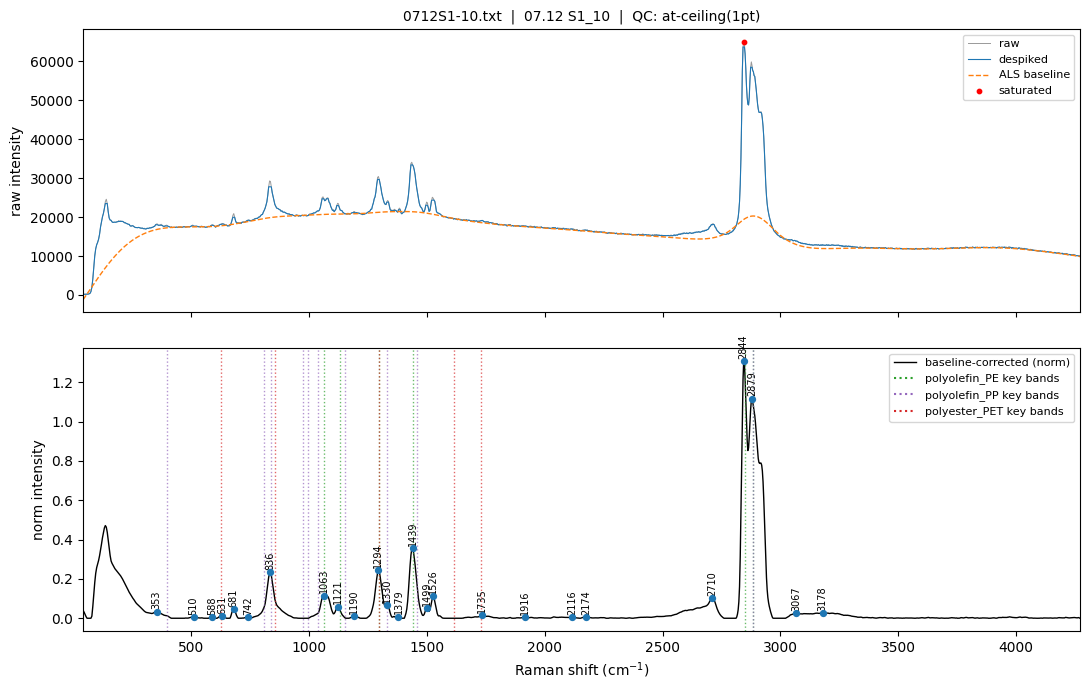


0712S1-10.txt  |  07.12 S1_10  |  QC: at-ceiling(1pt)
  detected peaks (cm-1): 353.4, 510.9, 588.6, 631.1, 681.0, 742.1, 836.7, 1063.2, 1121.6, 1190.5, 1294.6, 1330.2, 1379.8, 1439.6, 1499.0, 1526.9, 1735.9, 1916.7, 2116.2, 2174.1, 2710.5, 2844.2, 2879.4, 3067.7, 3178.4
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role        candidate_class key_hit  key_frac  exclusive                cap                                          key_bands_matched exclusive_bands                        unmatched_key                                                                   shared_with                                                                                                all_bands_matched
terminal          polyolefin_PE     5/6     0.833          0 confident-eligible 1062(1063), 1295(1295), 1440(1440), 2850(2844), 2883(2879)               -                                 1130  1295<->PET1295(d0), 1440<->PA1440(d0), 1440<->PVC1437(d3)

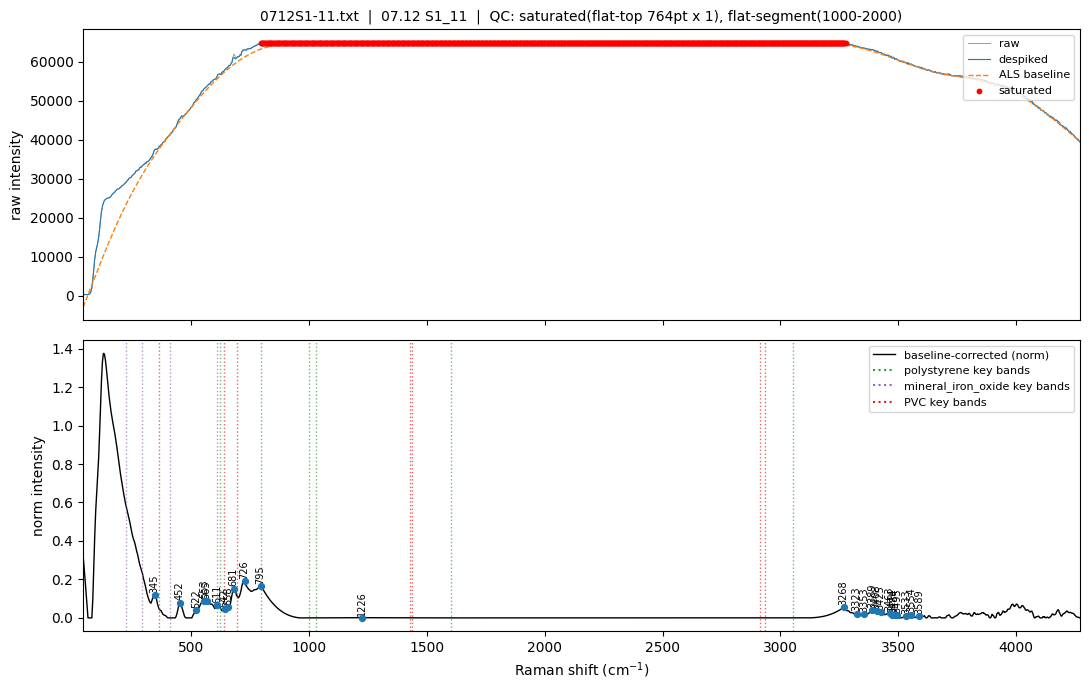


0712S1-11.txt  |  07.12 S1_11  |  QC: saturated(flat-top 764pt x 1), flat-segment(1000-2000)
  detected peaks (cm-1): 345.4, 452.2, 522.6, 553.8, 565.4, 611.8, 642.7, 658.0, 681.0, 726.9, 795.2, 1226.6, 3268.0, 3323.5, 3353.9, 3389.6, 3408.7, 3425.1, 3463.2, 3474.0, 3484.9, 3495.7, 3533.4, 3554.8, 3589.6
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role        candidate_class key_hit  key_frac  exclusive                    cap  key_bands_matched exclusive_bands                                         unmatched_key          shared_with                                all_bands_matched
terminal            polystyrene     1/6     0.167          0     confident-eligible           795(795)               -                           621, 1001, 1031, 1602, 3054                    -                                         795(795)
terminal     mineral_iron_oxide     1/4     0.250          0     confident-eligible           612(612)          

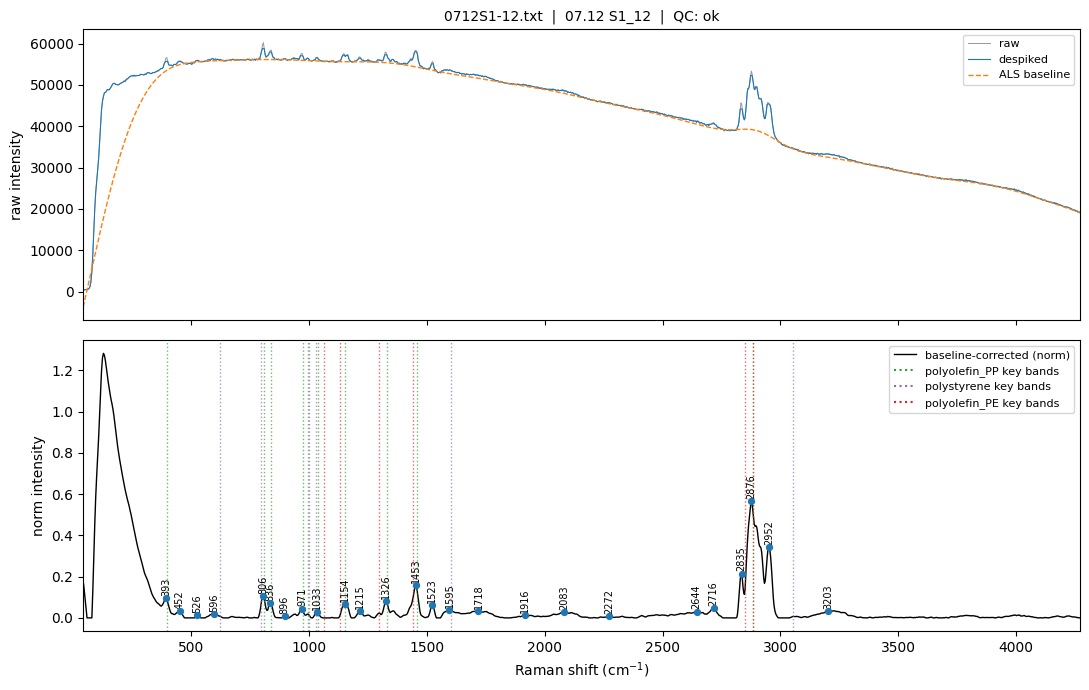


0712S1-12.txt  |  07.12 S1_12  |  QC: ok
  detected peaks (cm-1): 393.0, 452.2, 526.5, 596.4, 806.5, 836.7, 896.7, 971.1, 1033.8, 1154.3, 1215.8, 1326.7, 1453.7, 1523.4, 1596.0, 1719.0, 1916.7, 2083.8, 2273.0, 2644.3, 2716.5, 2835.3, 2876.5, 2952.4, 3203.7
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role         candidate_class key_hit  key_frac  exclusive                    cap                                                                                  key_bands_matched exclusive_bands                         unmatched_key                                                         shared_with                                                                                                                                                                          all_bands_matched
terminal           polyolefin_PP    9/10     0.900          1     confident-eligible 398(393), 809(807), 841(837), 973(971), 1040(1034), 1152(1154), 1330(

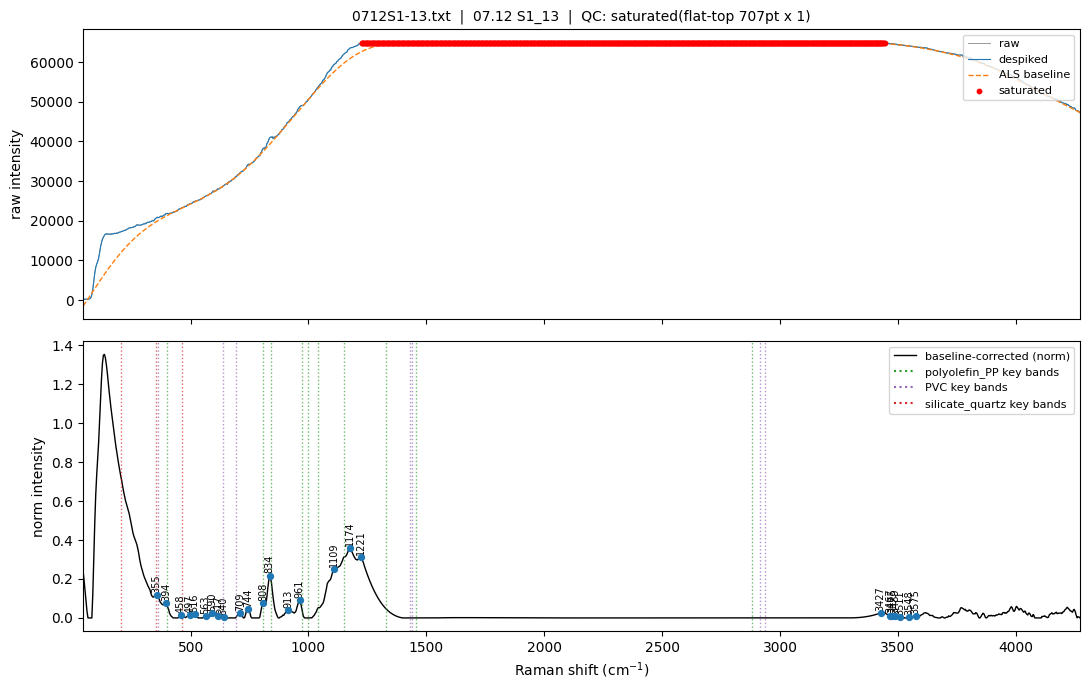


0712S1-13.txt  |  07.12 S1_13  |  QC: saturated(flat-top 707pt x 1)
  detected peaks (cm-1): 355.4, 395.0, 458.1, 497.3, 516.8, 563.5, 590.6, 617.7, 640.8, 709.8, 744.1, 808.5, 834.9, 913.6, 961.9, 1109.0, 1174.4, 1221.3, 3427.1, 3467.9, 3476.0, 3489.5, 3511.1, 3548.8, 3575.5
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role        candidate_class key_hit  key_frac  exclusive                    cap            key_bands_matched exclusive_bands                          unmatched_key                                   shared_with                                                                                      all_bands_matched
terminal          polyolefin_PP    3/10     0.300          0     confident-eligible 398(395), 809(808), 841(835)               - 973, 998, 1040, 1152, 1330, 1458, 2883                          398<->anatase399(d1)                   398(395), 458(458), 809(808), 841(835), 1102(1109), 1167(1174), 1219(1221), 83

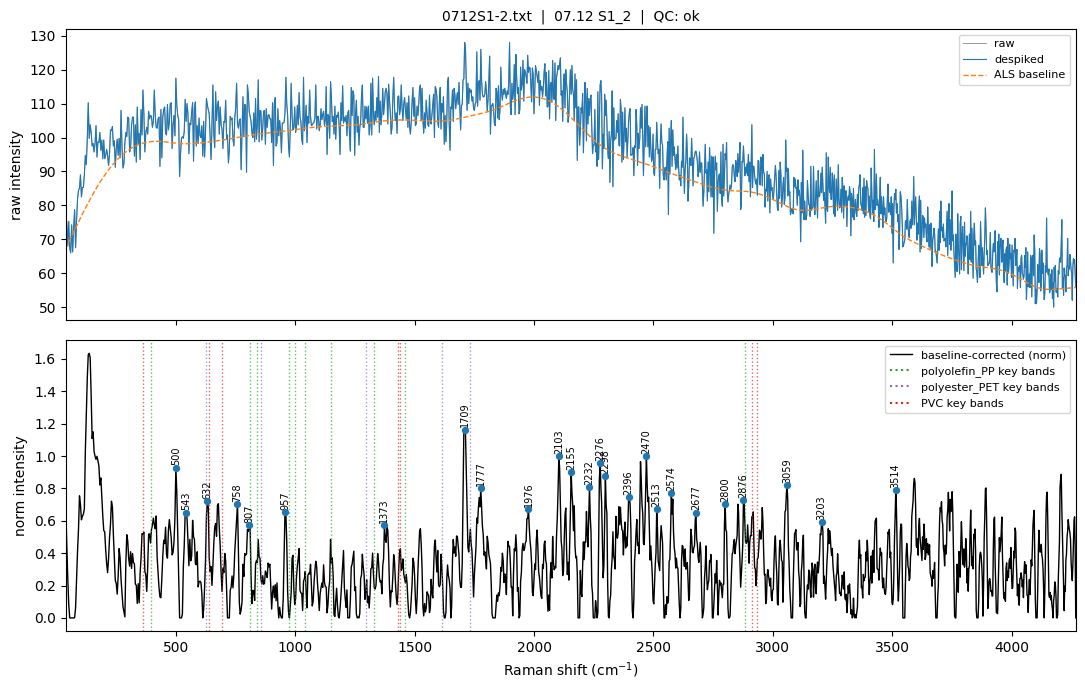


0712S1-2.txt  |  07.12 S1_2  |  QC: ok
  detected peaks (cm-1): 500.5, 543.3, 632.3, 758.5, 807.6, 957.3, 1373.6, 1709.6, 1777.2, 1976.7, 2103.9, 2155.4, 2232.2, 2276.6, 2298.8, 2396.0, 2470.5, 2513.7, 2574.9, 2677.8, 2800.2, 2876.8, 3059.3, 3203.9, 3514.6
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role         candidate_class key_hit  key_frac  exclusive                    cap    key_bands_matched exclusive_bands                              unmatched_key                              shared_with                                            all_bands_matched
terminal           polyolefin_PP    2/10     0.200          0     confident-eligible 809(808), 2883(2877)               - 398, 841, 973, 998, 1040, 1152, 1330, 1458                        2883<->PE2883(d0)                 809(808), 1371(1374), 2871(2877), 2883(2877)
terminal           polyester_PET     1/5     0.200          0     confident-eligible             626(632)        

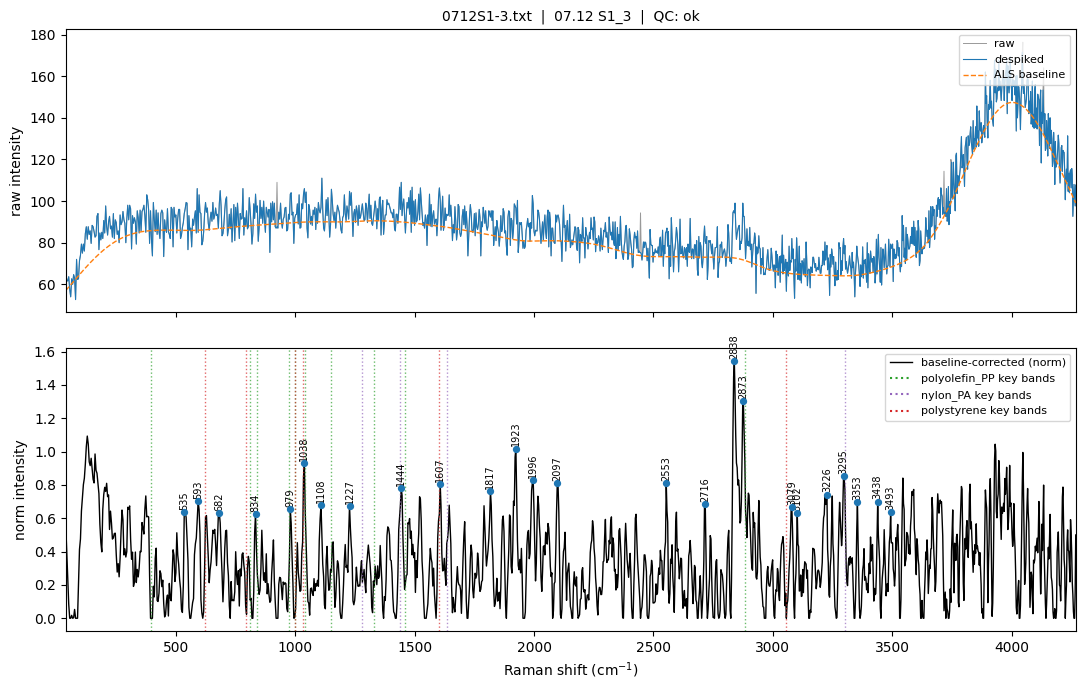


0712S1-3.txt  |  07.12 S1_3  |  QC: ok
  detected peaks (cm-1): 535.6, 593.7, 682.2, 834.0, 979.5, 1038.5, 1108.1, 1227.5, 1444.0, 1607.1, 1817.5, 1924.0, 1996.4, 2097.4, 2553.5, 2716.8, 2838.6, 2873.9, 3079.3, 3102.1, 3226.3, 3296.0, 3354.0, 3438.8, 3493.0
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role         candidate_class key_hit  key_frac  exclusive                    cap              key_bands_matched exclusive_bands                         unmatched_key                            shared_with                                                                      all_bands_matched
terminal           polyolefin_PP    3/10     0.300          1     confident-eligible 841(834), 973(980), 1040(1039)            1040 398, 809, 998, 1152, 1330, 1458, 2883             1040<->polystyrene1031(d9) 530(536), 841(834), 973(980), 1040(1039), 1102(1108), 2840(2839), 2871(2874), 830(834)
terminal                nylon_PA     2/4     0.500    

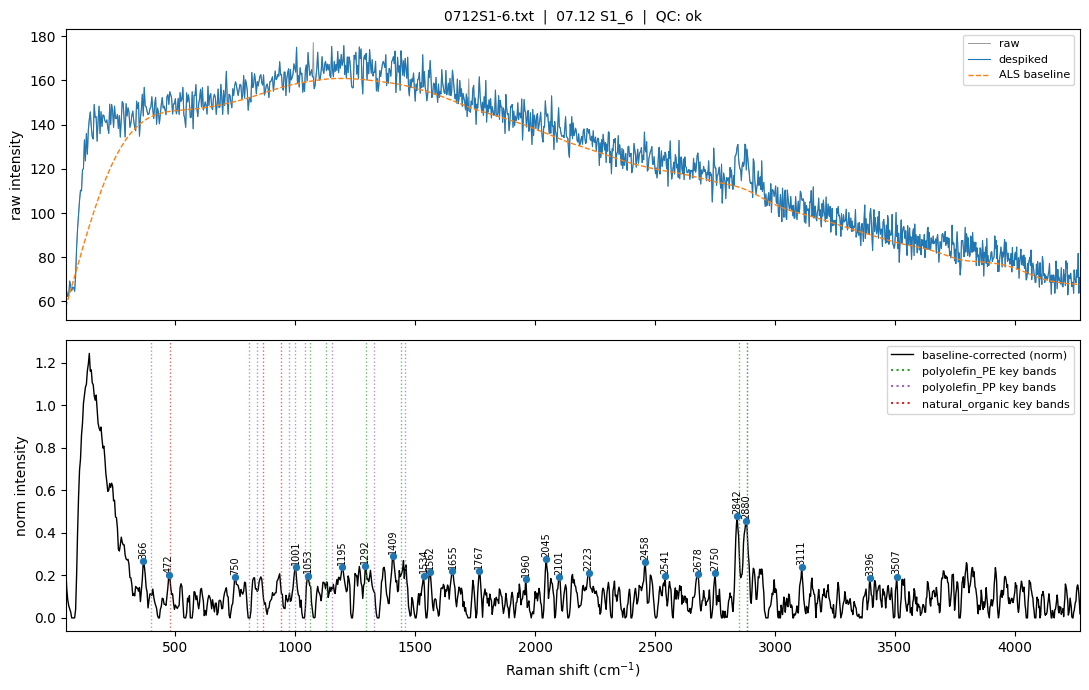


0712S1-6.txt  |  07.12 S1_6  |  QC: ok
  detected peaks (cm-1): 366.4, 472.9, 750.8, 1001.7, 1053.3, 1195.2, 1292.1, 1409.1, 1534.9, 1562.6, 1655.4, 1767.4, 1960.7, 2045.9, 2101.1, 2223.2, 2458.8, 2541.9, 2678.5, 2750.4, 2842.3, 2880.5, 3111.5, 3396.1, 3507.5
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role         candidate_class key_hit  key_frac  exclusive                    cap                  key_bands_matched exclusive_bands                              unmatched_key                                  shared_with                              all_bands_matched
terminal           polyolefin_PE     3/6     0.500          0     confident-eligible 1295(1292), 2850(2842), 2883(2881)               -                           1062, 1130, 1440        1295<->PET1295(d0), 2883<->PP2883(d0) 1295(1292), 1417(1409), 2850(2842), 2883(2881)
terminal           polyolefin_PP    2/10     0.200          0     confident-eligible              998(

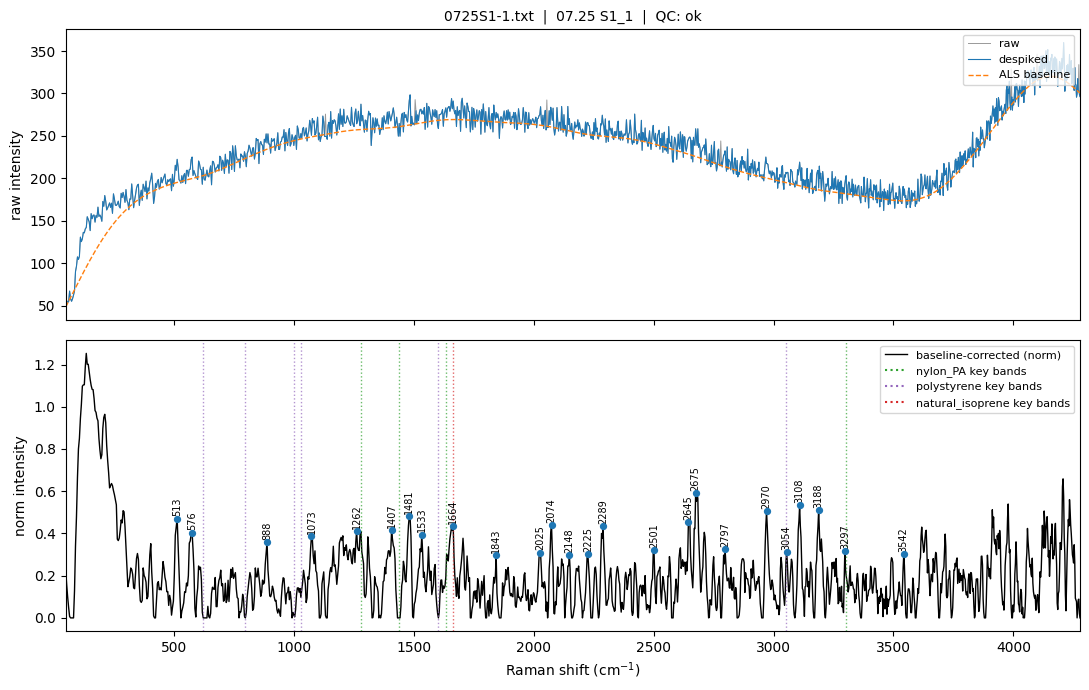


0725S1-1.txt  |  07.25 S1_1  |  QC: ok
  detected peaks (cm-1): 513.9, 576.2, 888.6, 1073.7, 1262.2, 1407.9, 1481.5, 1533.7, 1664.6, 1843.7, 2025.6, 2074.5, 2148.9, 2225.8, 2289.3, 2501.7, 2645.1, 2675.3, 2797.9, 2970.9, 3054.5, 3108.8, 3188.1, 3297.2, 3543.0
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role        candidate_class key_hit  key_frac  exclusive                    cap key_bands_matched exclusive_bands                                         unmatched_key shared_with                            all_bands_matched
terminal               nylon_PA     1/4     0.250          1     confident-eligible        3300(3297)            3300                                      1280, 1440, 1635           -                                   3300(3297)
terminal            polystyrene     1/6     0.167          1     confident-eligible        3054(3055)            3054                            621, 795, 1001, 1031, 1602           -   

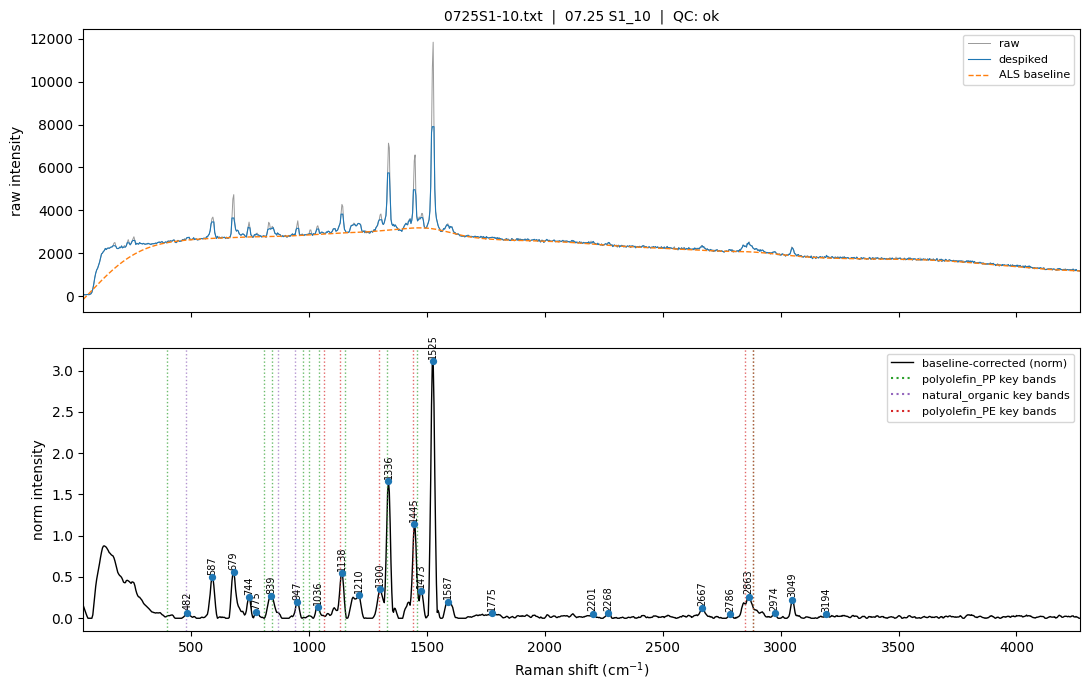


0725S1-10.txt  |  07.25 S1_10  |  QC: ok
  detected peaks (cm-1): 482.3, 587.4, 679.8, 744.7, 775.1, 839.2, 947.6, 1036.3, 1138.6, 1211.0, 1300.5, 1336.1, 1445.4, 1473.4, 1525.7, 1587.9, 1775.2, 2201.7, 2268.6, 2667.2, 2786.8, 2863.6, 2974.4, 3049.3, 3194.1
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role        candidate_class key_hit  key_frac  exclusive                    cap                          key_bands_matched exclusive_bands                         unmatched_key                                                shared_with                                                                                                        all_bands_matched
terminal          polyolefin_PP    3/10     0.300          1     confident-eligible           841(839), 1040(1036), 1330(1336)            1040  398, 809, 973, 998, 1152, 1458, 2883 1040<->polystyrene1031(d9), 1330<->phthalocyanine1341(d11)                                           841

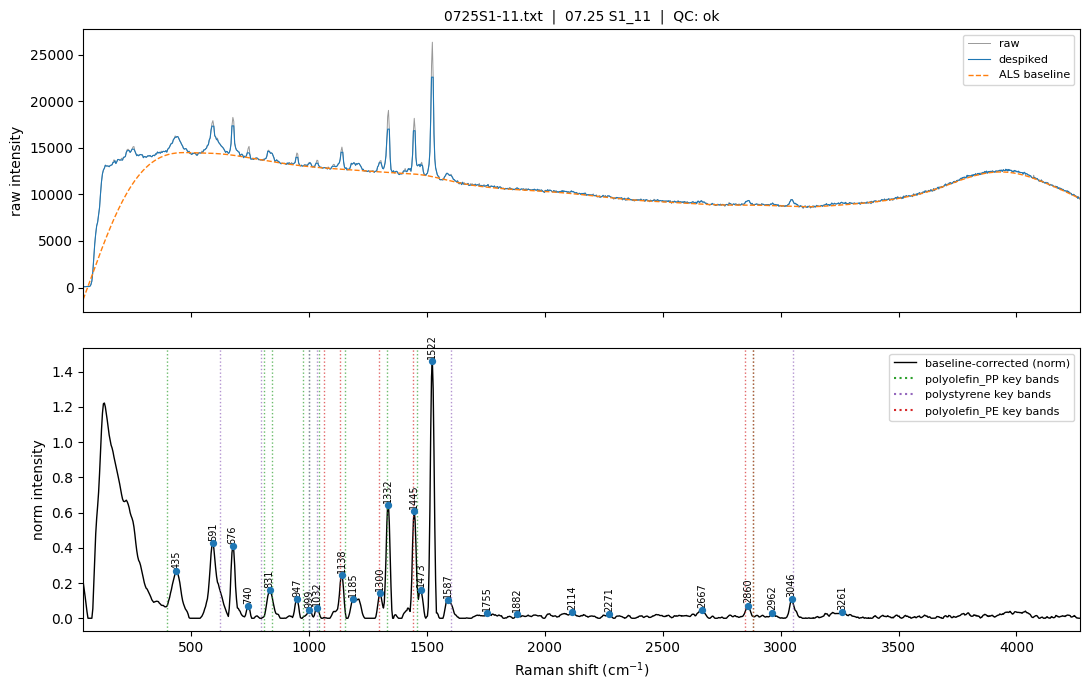


0725S1-11.txt  |  07.25 S1_11  |  QC: ok
  detected peaks (cm-1): 435.2, 591.3, 676.0, 740.9, 831.7, 947.6, 999.5, 1032.6, 1138.6, 1185.7, 1300.5, 1332.6, 1445.4, 1473.4, 1522.2, 1587.9, 1755.0, 1882.3, 2115.0, 2271.7, 2667.2, 2860.6, 2962.8, 3046.4, 3261.3
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role         candidate_class key_hit  key_frac  exclusive                    cap                 key_bands_matched exclusive_bands                         unmatched_key                                           shared_with                                                                                  all_bands_matched
terminal           polyolefin_PP    3/10     0.300          1     confident-eligible  998(999), 1040(1033), 1330(1333)            1040  398, 809, 841, 973, 1152, 1458, 2883 1040<->polystyrene1031(d9), 998<->polystyrene1001(d3)                       941(948), 998(999), 1040(1033), 1296(1301), 1306(1301), 1330(1333), 830

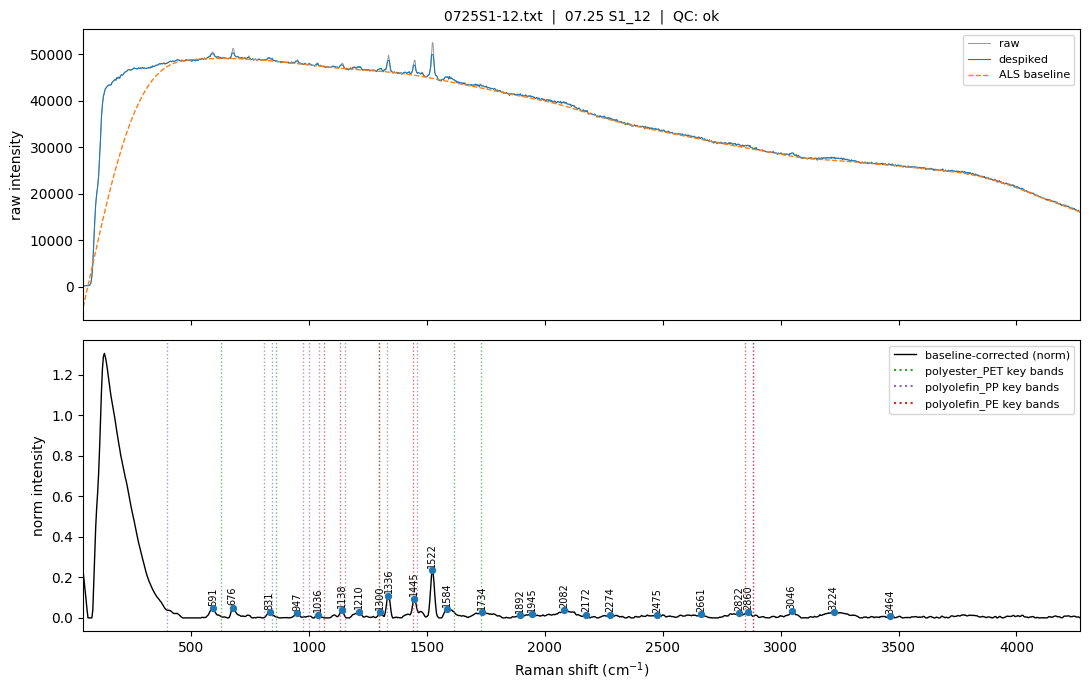


0725S1-12.txt  |  07.25 S1_12  |  QC: ok
  detected peaks (cm-1): 591.3, 676.0, 831.7, 947.6, 1036.3, 1138.6, 1211.0, 1300.5, 1336.1, 1445.4, 1522.2, 1584.4, 1734.7, 1892.3, 1945.2, 2082.6, 2172.9, 2274.9, 2475.1, 2661.2, 2822.3, 2860.6, 3046.4, 3225.0, 3464.7
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role        candidate_class key_hit  key_frac  exclusive                    cap                key_bands_matched exclusive_bands                             unmatched_key                                                shared_with                                                                                    all_bands_matched
terminal          polyester_PET     2/5     0.400          1     confident-eligible           1295(1301), 1730(1735)            1730                            626, 857, 1615                                          1295<->PE1295(d0)                                                                     950(94

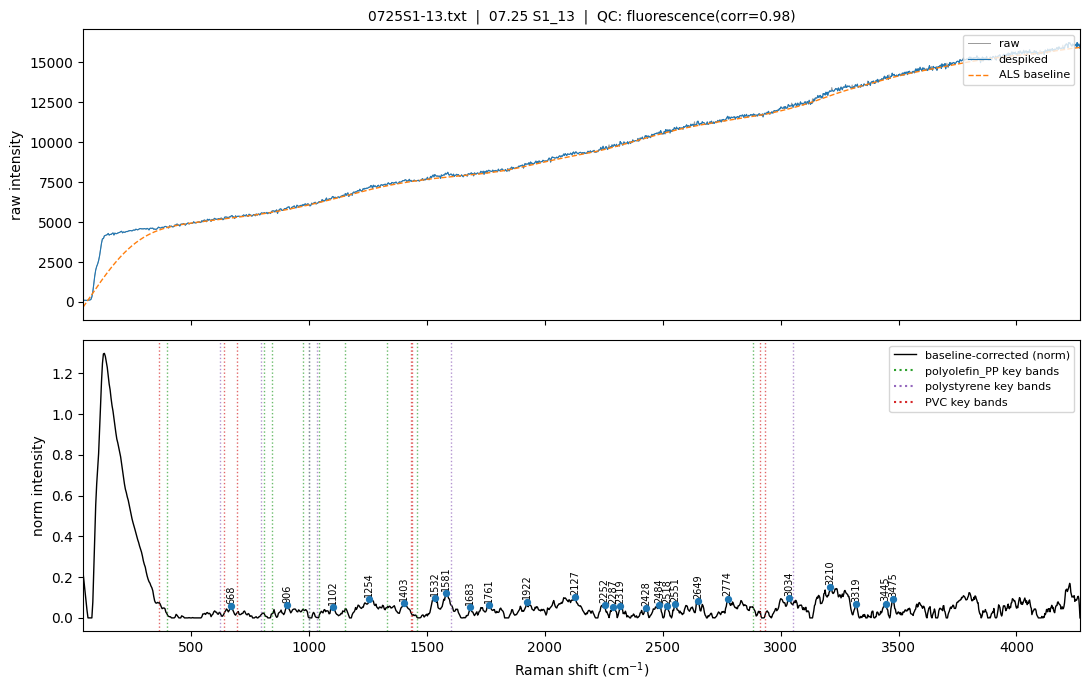


0725S1-13.txt  |  07.25 S1_13  |  QC: fluorescence(corr=0.98)
  detected peaks (cm-1): 668.3, 906.7, 1102.2, 1254.1, 1403.3, 1532.6, 1581.0, 1683.8, 1761.8, 1922.1, 2127.9, 2252.7, 2287.6, 2319.1, 2428.6, 2484.3, 2518.2, 2551.9, 2649.1, 2774.9, 3034.9, 3210.9, 3319.6, 3445.7, 3475.5
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role        candidate_class key_hit  key_frac  exclusive                    cap key_bands_matched exclusive_bands                                         unmatched_key shared_with                all_bands_matched
terminal          polyolefin_PP    0/10      0.00          0     confident-eligible                 -               - 398, 809, 841, 973, 998, 1040, 1152, 1330, 1458, 2883           - 900(907), 1102(1102), 1257(1254)
terminal            polystyrene     0/6      0.00          0     confident-eligible                 -               -                      621, 795, 1001, 1031, 1602, 3054           -   

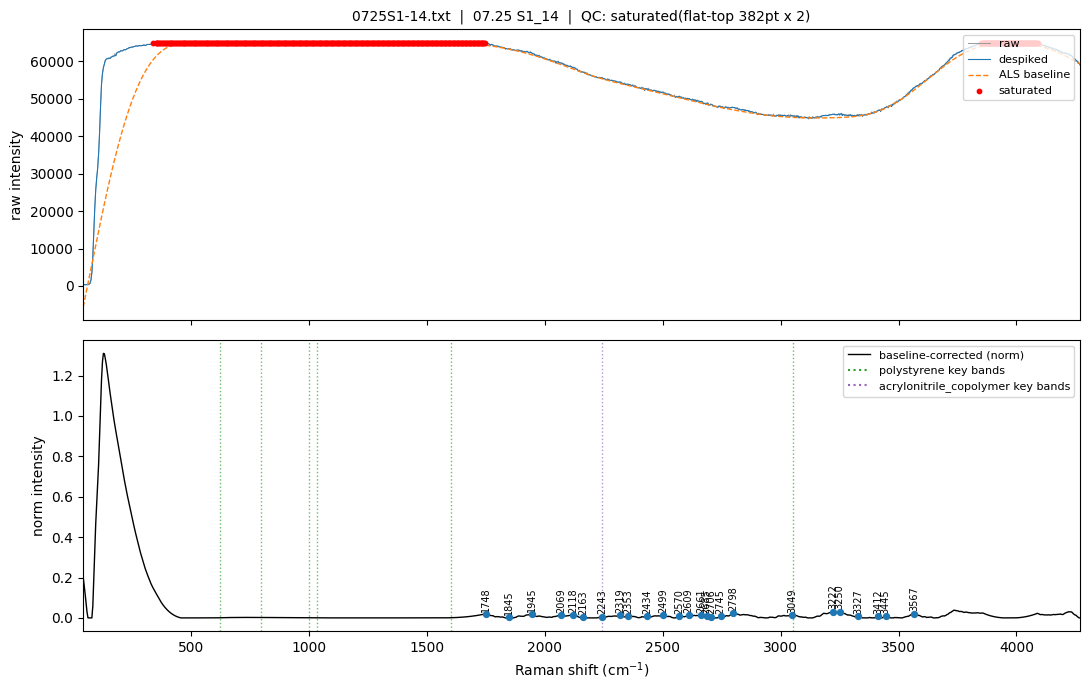


0725S1-14.txt  |  07.25 S1_14  |  QC: saturated(flat-top 382pt x 2)
  detected peaks (cm-1): 1748.2, 1845.7, 1945.2, 2069.6, 2118.2, 2163.3, 2243.2, 2319.1, 2353.7, 2434.8, 2499.7, 2570.2, 2609.8, 2661.2, 2685.3, 2706.3, 2745.2, 2798.7, 3049.3, 3222.2, 3250.1, 3327.9, 3413.0, 3445.7, 3567.0
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role         candidate_class key_hit  key_frac  exclusive                    cap key_bands_matched exclusive_bands              unmatched_key shared_with all_bands_matched
terminal             polystyrene     1/6     0.167          1     confident-eligible        3054(3049)            3054 621, 795, 1001, 1031, 1602           -        3054(3049)
terminal acrylonitrile_copolymer     1/1     1.000          1 tentative (structural)        2240(2243)            2240                          -           -        2240(2243)


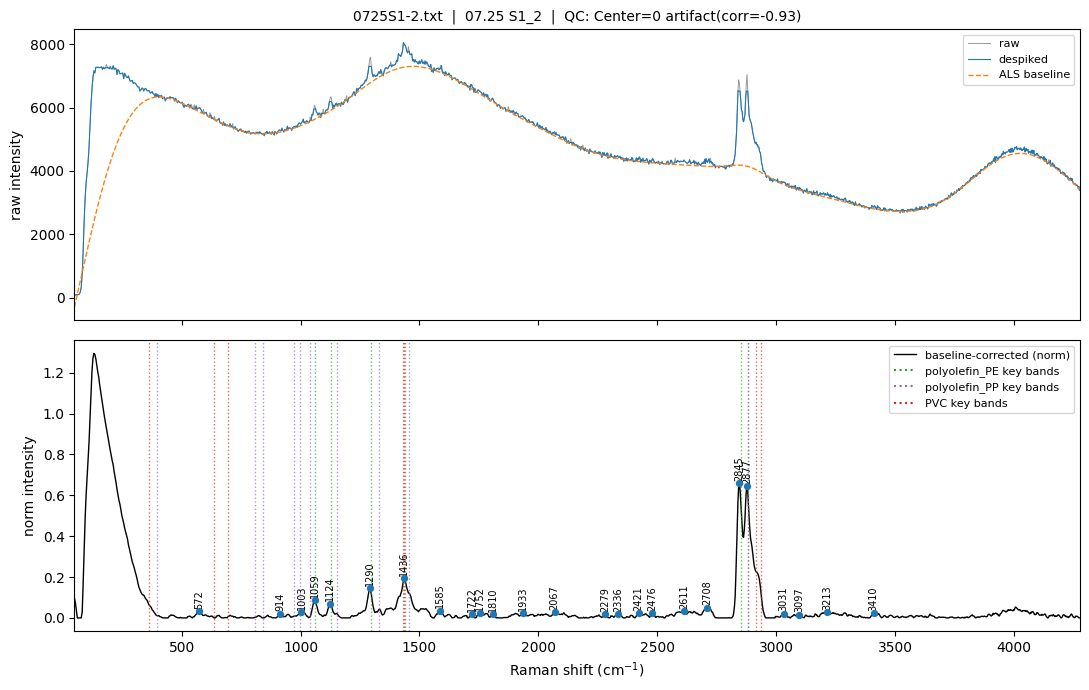


0725S1-2.txt  |  07.25 S1_2  |  QC: Center=0 artifact(corr=-0.93)
  detected peaks (cm-1): 572.3, 914.8, 1003.9, 1059.1, 1124.9, 1290.8, 1436.0, 1585.6, 1722.5, 1753.0, 1810.2, 1933.5, 2068.0, 2279.8, 2336.7, 2421.1, 2477.0, 2611.8, 2708.4, 2845.2, 2877.5, 3031.5, 3097.4, 3213.4, 3410.2
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role         candidate_class key_hit  key_frac  exclusive                    cap                                                      key_bands_matched exclusive_bands                              unmatched_key                                                                                       shared_with                                                      all_bands_matched
terminal           polyolefin_PE     6/6     1.000          0     confident-eligible 1062(1059), 1130(1125), 1295(1291), 1440(1436), 2850(2845), 2883(2878)               -                                          - 1295<->PET1295(d0

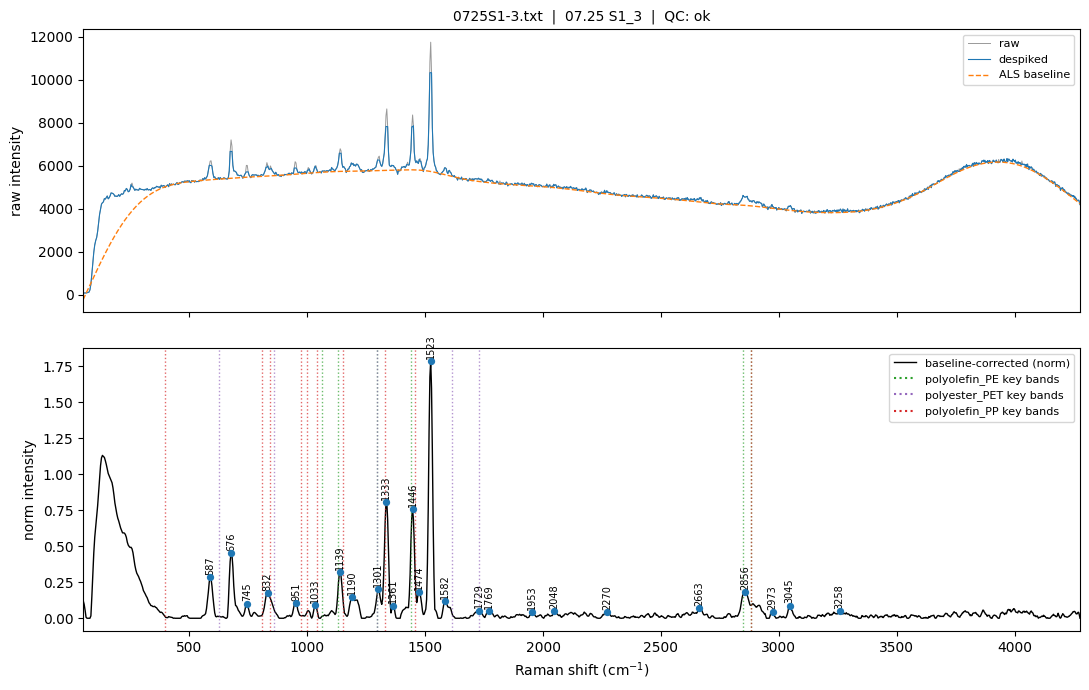


0725S1-3.txt  |  07.25 S1_3  |  QC: ok
  detected peaks (cm-1): 587.8, 676.4, 745.2, 832.3, 952.0, 1033.3, 1139.4, 1190.2, 1301.5, 1333.6, 1361.9, 1446.5, 1474.5, 1523.3, 1582.2, 1729.3, 1769.8, 1953.3, 2048.4, 2270.3, 2663.3, 2857.0, 2973.8, 3045.9, 3258.2
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role        candidate_class key_hit  key_frac  exclusive                    cap                          key_bands_matched exclusive_bands                             unmatched_key                                                shared_with                                                                                              all_bands_matched
terminal          polyolefin_PE     3/6     0.500          0     confident-eligible         1295(1302), 1440(1447), 2850(2857)               -                          1062, 1130, 2883                      1295<->PET1295(d0), 1440<->PA1440(d0)                                                

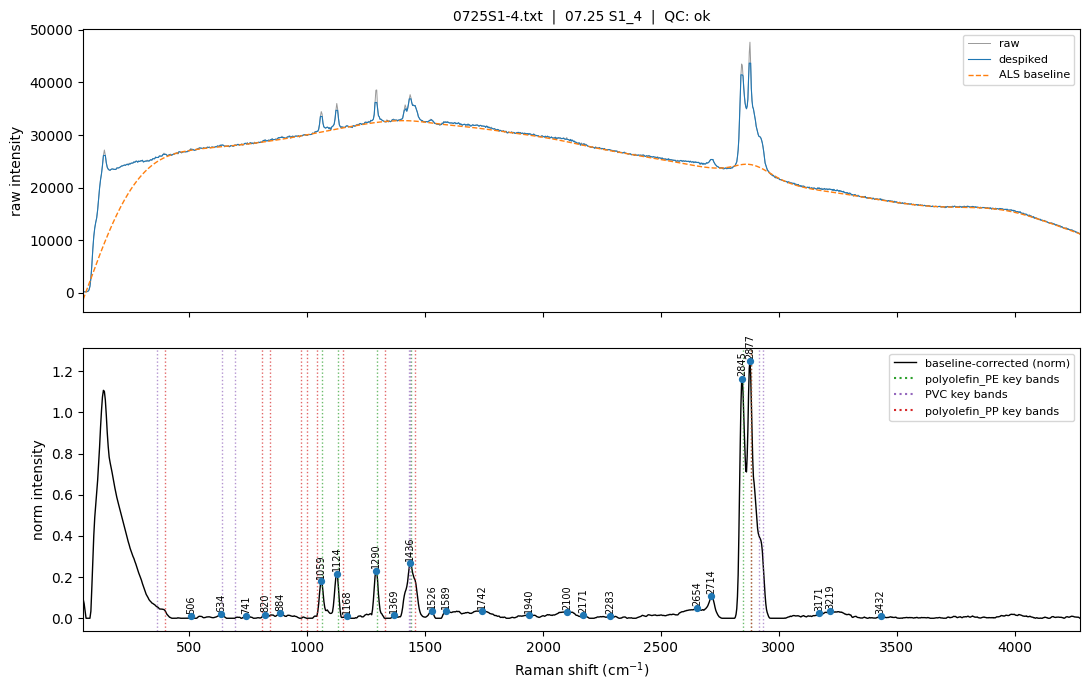


0725S1-4.txt  |  07.25 S1_4  |  QC: ok
  detected peaks (cm-1): 506.1, 634.2, 741.4, 821.0, 884.8, 1059.1, 1124.9, 1168.5, 1290.8, 1369.0, 1436.0, 1526.8, 1589.1, 1742.8, 1940.1, 2100.4, 2171.4, 2283.0, 2654.2, 2714.4, 2845.2, 2877.5, 3171.2, 3219.0, 3432.0
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role        candidate_class key_hit  key_frac  exclusive                    cap                                                      key_bands_matched exclusive_bands                                   unmatched_key                                                                                        shared_with                                                                  all_bands_matched
terminal          polyolefin_PE     6/6     1.000          0     confident-eligible 1062(1059), 1130(1125), 1295(1291), 1440(1436), 2850(2845), 2883(2878)               -                                               -  1295<->PET1295(d0), 1440<

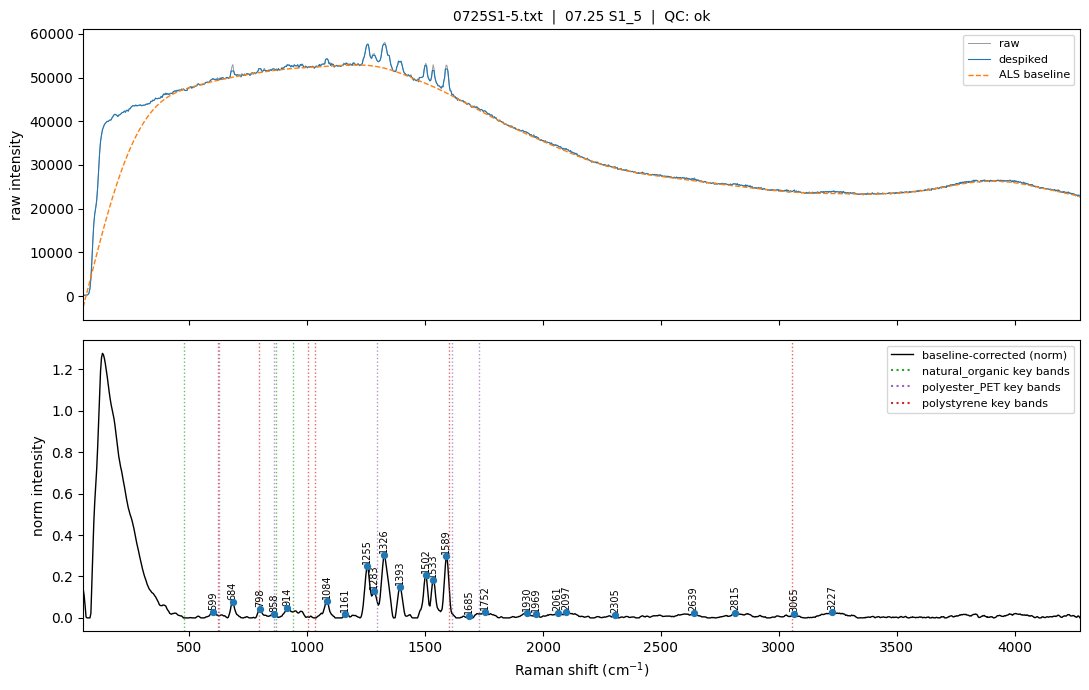


0725S1-5.txt  |  07.25 S1_5  |  QC: ok
  detected peaks (cm-1): 599.4, 684.1, 798.3, 858.6, 914.8, 1084.7, 1161.2, 1255.0, 1283.7, 1326.4, 1393.8, 1502.5, 1533.7, 1589.1, 1685.1, 1753.0, 1930.2, 1969.8, 2061.5, 2097.2, 2305.1, 2639.1, 2815.6, 3066.0, 3227.4
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role        candidate_class key_hit  key_frac  exclusive                cap    key_bands_matched exclusive_bands                                   unmatched_key              shared_with                          all_bands_matched
terminal        natural_organic     1/3     0.333          1 confident-eligible             866(859)             866                                        478, 940         866<->PET857(d9)                       866(859), 1083(1085)
terminal          polyester_PET     1/5     0.200          1 confident-eligible             857(859)             857                           626, 1295, 1615, 1730     857<->organ

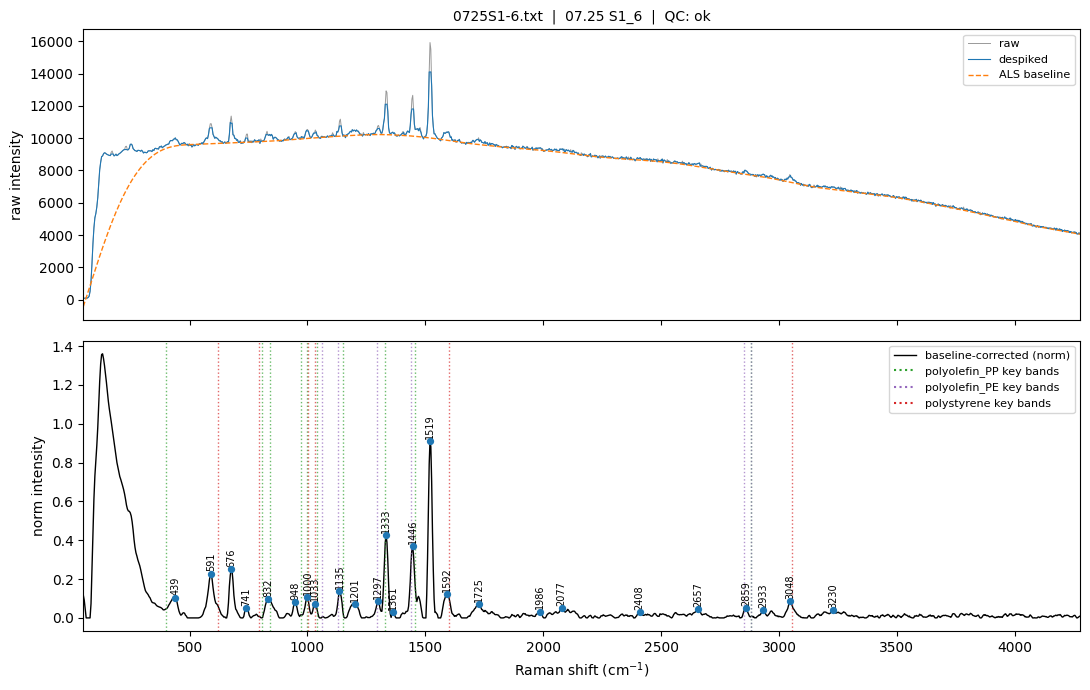


0725S1-6.txt  |  07.25 S1_6  |  QC: ok
  detected peaks (cm-1): 439.4, 591.7, 676.4, 741.4, 832.3, 948.3, 1000.2, 1033.3, 1135.8, 1201.0, 1297.9, 1333.6, 1361.9, 1446.5, 1519.9, 1592.5, 1725.9, 1986.3, 2077.7, 2408.7, 2657.2, 2859.9, 2933.1, 3048.8, 3230.2
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role         candidate_class key_hit  key_frac  exclusive                    cap                  key_bands_matched exclusive_bands                        unmatched_key                                                                           shared_with                                                                                  all_bands_matched
terminal           polyolefin_PP    3/10     0.300          1     confident-eligible  998(1000), 1040(1033), 1330(1334)            1040 398, 809, 841, 973, 1152, 1458, 2883 1040<->polystyrene1031(d9), 1330<->phthalocyanine1341(d11), 998<->polystyrene1001(d3)                      941(948),

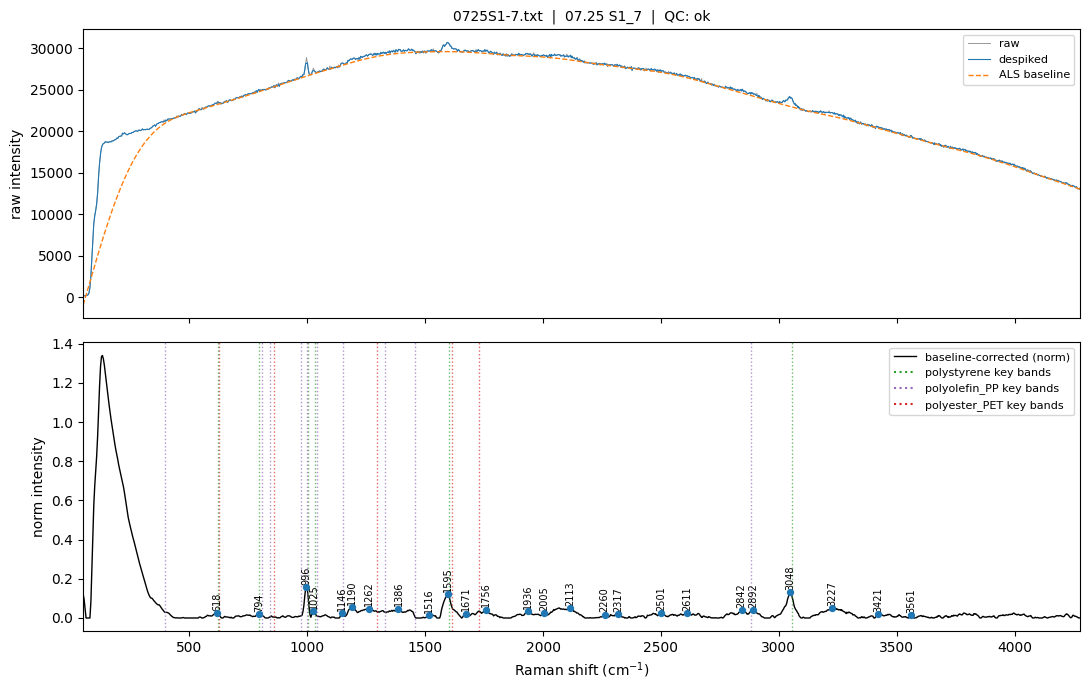


0725S1-7.txt  |  07.25 S1_7  |  QC: ok
  detected peaks (cm-1): 618.7, 794.5, 996.5, 1026.0, 1146.7, 1190.2, 1262.2, 1386.7, 1516.4, 1596.0, 1671.4, 1756.3, 1936.8, 2005.9, 2113.4, 2260.8, 2317.8, 2501.7, 2611.8, 2842.2, 2892.2, 3048.8, 3227.4, 3421.1, 3561.7
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role         candidate_class key_hit  key_frac  exclusive                    cap                                                 key_bands_matched exclusive_bands                              unmatched_key                                                                 shared_with                                                 all_bands_matched
terminal             polystyrene     6/6     1.000          2     confident-eligible 621(619), 795(795), 1001(996), 1031(1026), 1602(1596), 3054(3049)      1031, 3054                                          - 1001<->PP998(d3), 621<->PET626(d5), 621<->oxide612(d9), 621<->rutile612(d9) 621(61

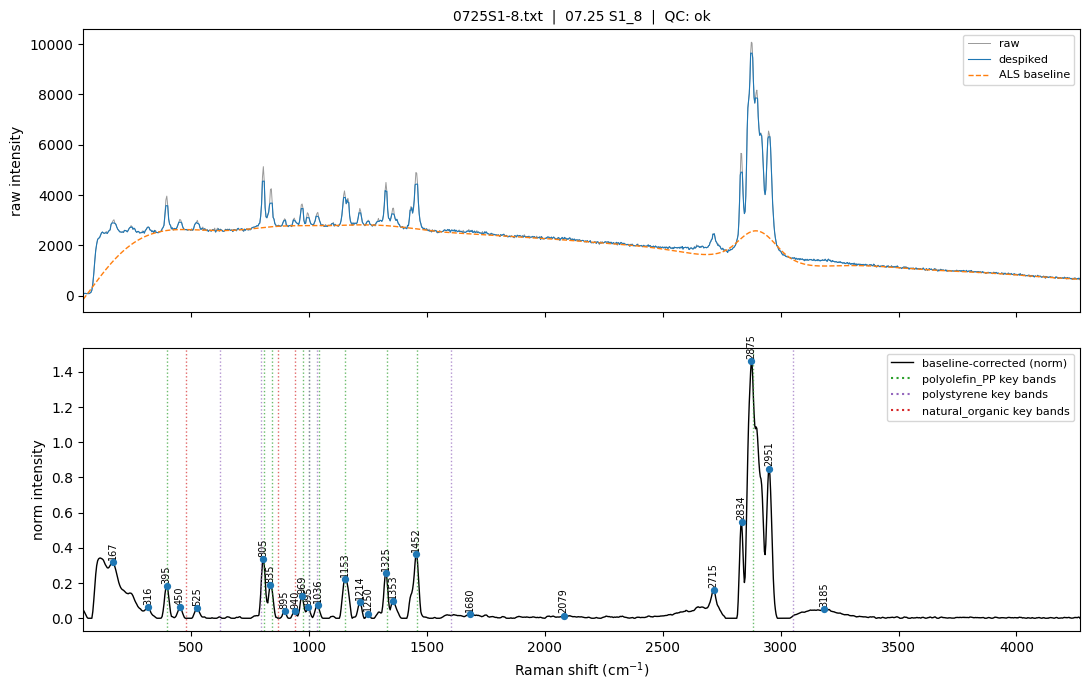


0725S1-8.txt  |  07.25 S1_8  |  QC: ok
  detected peaks (cm-1): 167.5, 316.4, 395.8, 451.0, 525.3, 805.3, 835.5, 895.5, 940.2, 969.9, 995.8, 1036.3, 1153.1, 1214.6, 1250.5, 1325.5, 1353.8, 1452.5, 1680.4, 2079.4, 2715.3, 2834.1, 2875.3, 2951.2, 3185.6
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role         candidate_class key_hit  key_frac  exclusive                    cap                                                                                            key_bands_matched exclusive_bands                         unmatched_key                                                                                    shared_with                                                                                                                                                                                                                                all_bands_matched
terminal           polyolefin_PP   10/10     1.000          1     co

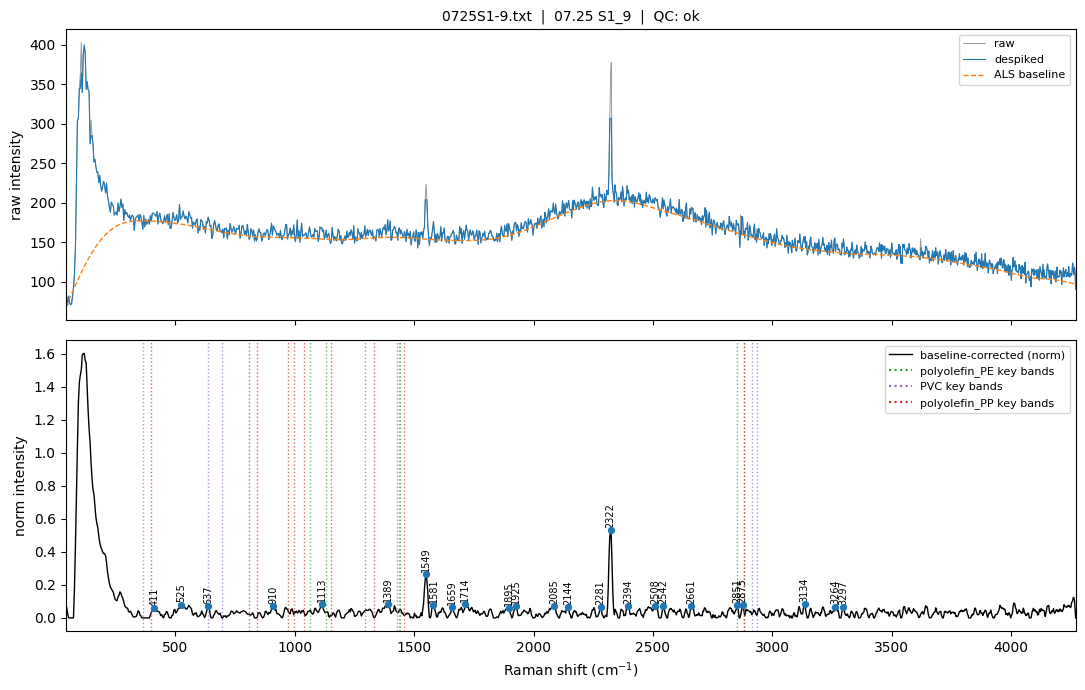


0725S1-9.txt  |  07.25 S1_9  |  QC: ok
  detected peaks (cm-1): 411.6, 525.3, 637.6, 910.4, 1113.1, 1389.2, 1549.9, 1581.0, 1659.9, 1714.4, 1895.6, 1925.4, 2085.9, 2144.0, 2281.2, 2322.3, 2394.4, 2508.9, 2542.7, 2661.2, 2851.8, 2875.3, 3134.8, 3264.1, 3297.4
  candidate-class evidence (the reference label is assigned from this table by rule C in §16):
    role        candidate_class key_hit  key_frac  exclusive                    cap      key_bands_matched exclusive_bands                                   unmatched_key          shared_with                all_bands_matched
terminal          polyolefin_PE     2/6     0.333          0     confident-eligible 2850(2852), 2883(2875)               -                          1062, 1130, 1295, 1440    2883<->PP2883(d0)           2850(2852), 2883(2875)
terminal                    PVC     1/7     0.143          1     confident-eligible               638(638)             638                363, 694, 1430, 1437, 2914, 2935 638<->anatase639(d1)    

,date,station,particle,file,qc,top_peaks_cm1,candidate_classes(by evidence),png,wn_delta_applied,delta_version,...,nd_filter,center_cm1,slit_um,wn_calibrated,wn_shift_comp,meas_time,raman_label_manual,raman_confidence_manual,diagnostic_bands_used,notes
0,05.17,S1,1,0517S1-1.txt,ok,"590.3, 682.7, 747.7, 774.3, 838.5, 950.7, 1006...",polyolefin_PE > polyolefin_PP > polystyrene > ...,05.17_S1_1.png,0.0,instrument-internal Si shift (per-file); no po...,...,22.43,2450.0,50.0,Not Calibrated,6.241074,5/18/2026 2:50:28 PM,,,,
1,06.07,S1,12,0607S1-12.txt,ok,"545.2, 587.9, 680.3, 745.2, 836.0, 1081.0, 118...",polyolefin_PE > polyolefin_PP > PVC > nylon_PA,06.07_S1_12.png,0.0,instrument-internal Si shift (per-file); no po...,...,67.56,2450.0,50.0,Not Calibrated,0.000000,6/8/2026 3:53:16 PM,,,,
2,06.07,S1,5,0607S1-5.txt,saturated(flat-top 22pt x 1),"171.9, 248.6, 320.7, 400.1, 455.3, 525.7, 809....",polyolefin_PP > polystyrene > natural_organic ...,06.07_S1_5.png,0.0,instrument-internal Si shift (per-file); no po...,...,94.43,2450.0,50.0,Not Calibrated,0.000000,6/8/2026 3:42:30 PM,,,,
3,06.07,S1,6,0607S1-6.txt,Center=0 artifact(corr=-0.96),"268.9, 588.1, 959.5, 1088.5, 1330.0, 1411.3, 1...",polystyrene > polyolefin_PP > carbonate_calcit...,06.07_S1_6.png,0.0,instrument-internal Si shift (per-file); no po...,...,8.11,2450.0,50.0,Not Calibrated,0.180879,6/8/2026 4:29:13 PM,,,,
4,06.14,S1,1,0614S1-1.txt,ok,"400.1, 455.3, 529.6, 591.8, 684.2, 809.6, 839....",polyolefin_PP > polystyrene > polyolefin_PE > PVC,06.14_S1_1.png,0.0,instrument-internal Si shift (per-file); no po...,...,20.25,2450.0,50.0,Not Calibrated,0.000000,6/15/2026 10:01:04 AM,,,,


In [ ]:
df = build_worksheet(only_dates=['05.17','06.07','06.14', '06.21', '06.26', '06.28','07.11','07.12','07.25'])  # add or edit dates as needed
df.head()


## 12. Sensitivity analysis (SI tables)

In [ ]:
# 12. Sensitivity analysis (SI tables). Calls band_evidence() of §8.
#   (A) MATCH_TOL grid  (B) k_min x gap_min grid  (C) delta offset  (D) label stability by tier
# Output: sens_A_tol.csv, sens_B_kgap.csv, sens_C_delta.csv, sens_D_tier.csv
import itertools
from collections import Counter


def _replay(peaks, tol=None, kmin=None, gapmin=None, wn=None):
    """Reproduces rule C with the same expression as _verdict in §8.
       Thresholds default to K_MIN / GAP_MIN in §1.
       Passing wn also reproduces rule E (acquisition-range cap), matching _score in §12-2."""
    kmin   = K_MIN   if kmin   is None else kmin
    gapmin = GAP_MIN if gapmin is None else gapmin
    ev = band_evidence(peaks, tol=tol, wn=wn)
    t = ev[ev.role == 'terminal'] if len(ev) else ev
    if len(t) == 0:
        return '(no evidence)', 'unresolved'
    ks = [int(s.split('/')[0]) for s in t['key_hit']]
    k1, k2 = ks[0], (ks[1] if len(ks) > 1 else 0)
    if k1 >= kmin and (k1 - k2) >= gapmin and t.iloc[0]['cap'] == CAP_CONFIDENT_OK:
        v = 'confident'
    elif k1 >= 2:
        v = 'tentative'
    else:
        v = 'unresolved'
    return t.iloc[0]['candidate_class'], v


assert PEAKS_REGISTRY, "run §11 (build_worksheet) first"
_files = sorted(PEAKS_REGISTRY)

# Reproduce rule E (acquisition range) under the same conditions as §12-2
_WNR30 = {}
try:
    _w30 = df[['file', 'wn_lo', 'wn_hi']].dropna()
    _WNR30 = {r.file: np.array([float(r.wn_lo), float(r.wn_hi)]) for r in _w30.itertuples()}
    print(f"  acquisition range applied to {len(_WNR30)} file(s) (rule E)")
except Exception as e:
    print(f"  ! wn range unavailable ({e}); the cap reflects structural constraints only")
_wn30 = lambda f: _WNR30.get(f)

BASE = {f: _replay(PEAKS_REGISTRY[f], wn=_wn30(f)) for f in _files}
print(f"baseline (tol={MATCH_TOL:.0f}, k>={K_MIN}, gap>={GAP_MIN}, delta={DELTA_VERSION}) - {len(_files)} particles")
print("  labels:", dict(Counter(v[0] for v in BASE.values())))
print("  tiers:", dict(Counter(v[1] for v in BASE.values())))

TOL_GRID = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16, 20]

# (A) MATCH_TOL
A = []
for tol in TOL_GRID:
    r = {f: _replay(PEAKS_REGISTRY[f], tol=tol, wn=_wn30(f)) for f in _files}
    A.append({'tol': tol,
              'label_changed':   sum(r[f][0] != BASE[f][0] for f in _files),
              'verdict_changed': sum(r[f][1] != BASE[f][1] for f in _files)})
dfA = pd.DataFrame(A)
print("\n(A) MATCH_TOL sensitivity (changes relative to baseline)")
print(dfA.to_string(index=False))

# (B) k_min × gap_min
B = []
for kmin, gapmin in itertools.product([2, 3, 4, 5], [1, 2, 3, 4, 5]):
    r = {f: _replay(PEAKS_REGISTRY[f], kmin=kmin, gapmin=gapmin, wn=_wn30(f)) for f in _files}
    c = Counter(v[1] for v in r.values())
    B.append({'k_min': kmin, 'gap_min': gapmin,
              'confident': c['confident'], 'tentative': c['tentative'],
              'unresolved': c['unresolved'],
              'label_changed':   sum(r[f][0] != BASE[f][0] for f in _files),
              'verdict_changed': sum(r[f][1] != BASE[f][1] for f in _files)})
dfB = pd.DataFrame(B)
print("\n(B) k_min x gap_min (labels follow the ranking, so label_changed=0 is expected)")
print(dfB.to_string(index=False))

# (C) delta offset tolerance (rigid shift of every peak)
C = []
# Grid +/-8: the measured zone error reaches -6.9 cm-1 in the CH-stretch region, which +/-4 does not cover
for d in [-8, -7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]:
    r = {f: _replay([(x + d, y) for x, y in PEAKS_REGISTRY[f]], wn=_wn30(f)) for f in _files}
    C.append({'delta_cm1': d,
              'label_changed':   sum(r[f][0] != BASE[f][0] for f in _files),
              'verdict_changed': sum(r[f][1] != BASE[f][1] for f in _files),
              'confident_label_changed':
                  sum(r[f][0] != BASE[f][0] for f in _files if BASE[f][1] == 'confident')})
dfC = pd.DataFrame(C)
print("\n(C) wavenumber offset tolerance (against delta-correction uncertainty)")
print(dfC.to_string(index=False))

# (D) label stability by tier
tiers = {t: [f for f in _files if BASE[f][1] == t]
         for t in ('confident', 'tentative', 'unresolved')}
D = []
for tol in TOL_GRID:
    r = {f: _replay(PEAKS_REGISTRY[f], tol=tol, wn=_wn30(f)) for f in _files}
    D.append({'tol': tol,
              **{t: sum(r[f][0] != BASE[f][0] for f in fs) for t, fs in tiers.items()}})
dfD = pd.DataFrame(D)
print("\n(D) label changes by tier (a zero confident column shows the provisional flag works)")
print(dfD.to_string(index=False))

for name, df_ in [('sens_A_tol', dfA), ('sens_B_kgap', dfB),
                  ('sens_C_delta', dfC), ('sens_D_tier', dfD)]:
    df_.to_csv(os.path.join(OUT_DIR, f"{name}.csv"), index=False)
print(f"\n[saved] 4 SI tables -> {OUT_DIR}/sens_*.csv")


  acquisition range applied to 47 file(s) (rule E)
baseline (tol=8, k>=3, gap>=4, delta=instrument-internal Si shift (per-file); no post-hoc correction) - 47 particles
  labels: {'polyolefin_PE': 21, 'polyolefin_PP': 15, 'polystyrene': 4, 'PVC': 1, 'carbonate_aragonite': 1, 'carbonate_calcite': 1, 'acrylonitrile_copolymer': 1, 'nylon_PA': 1, 'polyester_PET': 1, 'natural_organic': 1}
  tiers: {'confident': 12, 'tentative': 26, 'unresolved': 9}

(A) MATCH_TOL sensitivity (changes relative to baseline)
 tol  label_changed  verdict_changed
   3             16               21
   4             12               15
   5             12               11
   6              9                7
   7              4                2
   8              0                0
   9              5                3
  10              5                7
  11              6                6
  12              7                6
  14             14                7
  16             14                9
  20          

## 12-2. Null-model permutation test: can rule C arise by chance?

In [ ]:
# 12-2. A1 null-model permutation test: can rule C (k1>=K_MIN and margin>=GAP_MIN) arise by chance?
#   Randomised: the band-to-class assignment only. Fixed: measured peaks (PEAKS_REGISTRY),
#   MATCH_TOL, window, per-class band and key counts, rule F roles, CONFIDENT_INELIGIBLE,
#   the rule C expression, rule E.
#   H0: the library carries no class-specific information.
# Output: null distributions of k1 and margin, P(rule C | H0), per-particle p and BH q, study-level p.
#   Files: null_A1_perparticle_{kind}.csv, null_A1_summary_{kind}.csv, null_A1_dist_{kind}.csv,
#   null_A1_hist_{kind}.png
import numpy as np, pandas as pd, os, contextlib

N_PERM    = 10000        # measured: 30 particles x 10000 permutations is about 4 min with FAST=True
SEED      = 20260805     # fixed; report in Methods
NULL_KIND = 'label'      # 'label' = primary analysis | 'shift' = sensitivity analysis
FAST      = True         # use the lightweight re-implementation; identity is verified below before use
USE_WN_RANGE = True      # reproduce rule E (cap) from wn_lo / wn_hi in the §11 worksheet

assert PEAKS_REGISTRY, "run §11 (build_worksheet) first"
_files = sorted(PEAKS_REGISTRY)

# -- Per-file acquisition range (rule E). band_in_range uses only min/max, so two points suffice --
_WNR = {}
if USE_WN_RANGE:
    try:
        _w = df[['file', 'wn_lo', 'wn_hi']].dropna()          # df returned by §11
        _WNR = {r.file: np.array([float(r.wn_lo), float(r.wn_hi)]) for r in _w.itertuples()}
        print(f"  acquisition range applied to {len(_WNR)} file(s) (rule E)")
    except Exception as e:
        print(f"  ! wn range unavailable ({e}); the cap reflects only the structural constraint (CONFIDENT_INELIGIBLE)")
_wn_of = lambda f: _WNR.get(f)


# -- (a) Decision reproduced by calling the original band_evidence() of §8 --------
def _score(peaks, wn=None, kmin=None, gapmin=None):
    kmin   = K_MIN   if kmin   is None else kmin
    gapmin = GAP_MIN if gapmin is None else gapmin
    ev = band_evidence(peaks, wn=wn)
    t = ev[ev.role == 'terminal'] if len(ev) else ev
    if len(t) == 0:
        return dict(top='(no evidence)', k1=0, k2=0, margin=0, verdict='unresolved')
    ks = [int(s.split('/')[0]) for s in t['key_hit']]
    k1, k2 = ks[0], (ks[1] if len(ks) > 1 else 0)
    if k1 >= kmin and (k1 - k2) >= gapmin and t.iloc[0]['cap'] == CAP_CONFIDENT_OK:
        v = 'confident'
    elif k1 >= 2:
        v = 'tentative'
    else:
        v = 'unresolved'
    return dict(top=t.iloc[0]['candidate_class'], k1=k1, k2=k2, margin=k1 - k2, verdict=v)


# -- (b) Identical result, lightweight implementation (no DataFrame). About 8x faster ----
def _score_fast(peaks, wn=None, kmin=None, gapmin=None):
    kmin   = K_MIN   if kmin   is None else kmin
    gapmin = GAP_MIN if gapmin is None else gapmin
    tol = MATCH_TOL
    pk = np.array([p[0] for p in peaks]) if peaks else np.array([])
    rows = []
    for cls, bands in RAMAN_BANDS.items():
        mk, ma = 0, []
        for (c, _l, k) in bands:
            if not pk.size:
                continue
            j = int(np.argmin(np.abs(pk - c)))
            if abs(pk[j] - c) > tol:
                continue
            ma.append(f"{int(c)}({int(round(pk[j]))})")
            if k:
                mk += 1
        if not ma:
            continue
        cap = not (cls in CONFIDENT_INELIGIBLE or
                   (wn is not None and class_observability(cls, wn)[0] < 3))
        rows.append((1 if cls in COLORANT_ROLE else 0, mk, ', '.join(ma), cls, cap))
    if not rows:
        return dict(top='(no evidence)', k1=0, k2=0, margin=0, verdict='unresolved')
    rows.sort(key=lambda r: r[2], reverse=True)     # same ordering as §8
    rows.sort(key=lambda r: (r[0], -r[1]))          # (stable) role asc, k desc
    t = [r for r in rows if r[0] == 0]
    if not t:
        return dict(top='(no evidence)', k1=0, k2=0, margin=0, verdict='unresolved')
    k1 = t[0][1]; k2 = t[1][1] if len(t) > 1 else 0
    v = ('confident' if (k1 >= kmin and k1 - k2 >= gapmin and t[0][4])
         else 'tentative' if k1 >= 2 else 'unresolved')
    return dict(top=t[0][3], k1=k1, k2=k2, margin=k1 - k2, verdict=v)


# -- Null library ------------------------------------------------------------------
def _permute_library(rng, kind='label'):
    """A null library with the same structure as RAMAN_BANDS (per-class band and key counts preserved).

    label : band positions from every class are pooled by key / non-key stratum and reassigned at random.
            This also preserves the marginal wavenumber distribution (bands cluster in the
            fingerprint region), making it the conservative, primary design.
    shift : each class receives a single random offset, wrapping inside the analysis window.
            Within-class spacing is preserved and only absolute position is destroyed; sensitivity design.
    """
    if kind == 'shift':
        span = ANALYSIS_MAX - ANALYSIS_MIN
        out = {}
        for cls, bands in RAMAN_BANDS.items():
            d = rng.uniform(60, span - 60)          # exclude offsets near 0 (identical to the original)
            out[cls] = [(ANALYSIS_MIN + ((b + d - ANALYSIS_MIN) % span), l, k)
                        for (b, l, k) in bands]
        return out

    key_pool = list(rng.permutation([b for bs in RAMAN_BANDS.values() for (b, _l, k) in bs if k]))
    non_pool = list(rng.permutation([b for bs in RAMAN_BANDS.values() for (b, _l, k) in bs if not k]))
    out, i, j = {}, 0, 0
    for cls, bands in RAMAN_BANDS.items():
        nk = sum(1 for (_b, _l, k) in bands if k); nn = len(bands) - nk
        out[cls] = ([(float(key_pool[i + t]), 'null', True) for t in range(nk)] +
                    [(float(non_pool[j + t]), 'null', False) for t in range(nn)])
        i += nk; j += nn
    return out


@contextlib.contextmanager
def _swap_library(newbands):
    """Temporarily swap the global library so that the original §8 code can be used unchanged.
       Only RAMAN_BANDS and KEY_LINES actually take part in the decision.
       EXCLUSIVE_MAP / BAND_COLLISIONS / WEATHERING_MAP are display and warning only
       (see the §8 comments), so they are left empty for speed. The verdict is unaffected."""
    g = globals()
    keep = {k: g[k] for k in ('RAMAN_BANDS', 'KEY_LINES', 'EXCLUSIVE_MAP',
                              'BAND_COLLISIONS', 'WEATHERING_MAP')}
    try:
        g['RAMAN_BANDS'] = newbands
        g['KEY_LINES'] = {c: [b for (b, _l, k) in bs if k] for c, bs in newbands.items()}
        g['EXCLUSIVE_MAP'] = {}; g['BAND_COLLISIONS'] = {}; g['WEATHERING_MAP'] = {}
        yield
    finally:
        g.update(keep)


# -- Vectorised null engine: scores every file for one library in a few numpy operations ----
#    Identical verdicts to band_evidence (checked below); about 100x faster than the per-file
#    loop, so B = 10,000 runs in well under a minute.
_CLS   = list(RAMAN_BANDS)                                   # class order is fixed
_CIDX  = {c: i for i, c in enumerate(_CLS)}
_TERM  = np.array([c not in COLORANT_ROLE for c in _CLS])    # terminal classes
_INEL  = np.array([c in CONFIDENT_INELIGIBLE for c in _CLS])
_PMAX  = max(1, max(len(PEAKS_REGISTRY[f]) for f in _files))
_PK    = np.full((len(_files), _PMAX), np.inf)               # padded peak positions
for _i, _f in enumerate(_files):
    for _j, (_c, _n) in enumerate(PEAKS_REGISTRY[_f]):
        _PK[_i, _j] = _c
_HASWN = np.array([_wn_of(f) is not None for f in _files])
_LO = np.array([max(float(np.min(_wn_of(f))), ANALYSIS_MIN) if _wn_of(f) is not None else -np.inf for f in _files])
_HI = np.array([min(float(np.max(_wn_of(f))), ANALYSIS_MAX) if _wn_of(f) is not None else  np.inf for f in _files])

def _lib_arrays(lib):
    pos, key, ci = [], [], []
    for c, bands in lib.items():
        for (b, _l, k) in bands:
            pos.append(float(b)); key.append(bool(k)); ci.append(_CIDX[c])
    pos = np.array(pos); key = np.array(key); ci = np.array(ci)
    onehot = np.zeros((len(pos), len(_CLS))); onehot[np.arange(len(pos)), ci] = 1.0
    return pos, key, onehot

def _score_all(lib, kmin=None, gapmin=None):
    """k1, margin, confident for every file under library `lib` (same rule as band_evidence)."""
    kmin   = K_MIN   if kmin   is None else kmin
    gapmin = GAP_MIN if gapmin is None else gapmin
    pos, key, onehot = _lib_arrays(lib)
    hit  = (np.abs(_PK[:, :, None] - pos[None, None, :]).min(axis=1) <= MATCH_TOL)   # (F, B)
    K    = (hit & key[None, :]).astype(float) @ onehot                                # (F, C) key hits
    K[:, ~_TERM] = -1                                                                 # colorants never rank
    top  = K.argmax(axis=1)
    k1   = np.maximum(K.max(axis=1), 0)
    K2   = K.copy(); K2[np.arange(len(_files)), top] = -1
    k2   = np.maximum(K2.max(axis=1), 0)
    # rule E cap: at least 3 key bands of the top class observable in the file's range
    inr  = (pos[None, :] - MATCH_TOL >= _LO[:, None]) & (pos[None, :] + MATCH_TOL <= _HI[:, None])
    obs  = (inr & key[None, :]).astype(float) @ onehot
    cap  = ~_INEL[top] & (~_HASWN | (obs[np.arange(len(_files)), top] >= 3))
    conf = (k1 >= kmin) & (k1 - k2 >= gapmin) & cap
    return k1.astype(int), (k1 - k2).astype(int), conf

# -- Identity check: observed library plus 5 random permutations, all files, k1 / margin / verdict --
_chk = np.random.default_rng(SEED + 1)
_n = _bad = 0
for _t in range(6):
    _lib = RAMAN_BANDS if _t == 0 else _permute_library(_chk, NULL_KIND)
    _k1v, _mgv, _cfv = _score_all(_lib)
    with _swap_library(_lib):
        for _i, f in enumerate(_files):
            _n += 1
            r = _score(PEAKS_REGISTRY[f], wn=_wn_of(f))
            if (r['k1'], r['margin'], r['verdict'] == 'confident') != (int(_k1v[_i]), int(_mgv[_i]), bool(_cfv[_i])):
                _bad += 1
assert _bad == 0, f"vectorised engine disagrees with band_evidence on {_bad}/{_n} checks"
print(f"  [identity] vectorised engine matches the original band_evidence on all {_n} checks")

# -- Observed values (reference implementation, so the top label is available) ------------
OBS = {f: _score(PEAKS_REGISTRY[f], wn=_wn_of(f)) for f in _files}
n_conf_obs = sum(v['verdict'] == 'confident' for v in OBS.values())
print(f"[observed] {len(_files)} particles | confident {n_conf_obs} | "
      f"margin>={GAP_MIN} {sum(v['margin'] >= GAP_MIN for v in OBS.values())} | "
      f"median margin {np.median([v['margin'] for v in OBS.values()]):.1f}")

# -- Permutations ------------------------------------------------------------------
rng = np.random.default_rng(SEED)
K1 = np.zeros((N_PERM, len(_files)), int)
MG = np.zeros((N_PERM, len(_files)), int)
CF = np.zeros((N_PERM, len(_files)), bool)
for b in range(N_PERM):
    K1[b], MG[b], CF[b] = _score_all(_permute_library(rng, NULL_KIND))
    if (b + 1) % max(1, N_PERM // 10) == 0:
        print(f"  ... {b+1}/{N_PERM}")


def _wilson(x, n, z=1.96):
    if n == 0: return (np.nan, np.nan)
    p = x / n; d = 1 + z*z/n
    c = (p + z*z/(2*n)) / d
    h = z * np.sqrt(p*(1-p)/n + z*z/(4*n*n)) / d
    return (max(0., c - h), min(1., c + h))


# -- (1) Per-particle permutation p values -----------------------------------------
rows = []
for i, f in enumerate(_files):
    o = OBS[f]
    rows.append({
        'file': f, 'top_class': o['top'], 'k1': o['k1'], 'k2': o['k2'],
        'margin': o['margin'], 'verdict': o['verdict'],
        'null_k1_mean':      round(float(K1[:, i].mean()), 2),
        'null_margin_mean':  round(float(MG[:, i].mean()), 2),
        'null_P_k1_gekmin':  round(float((K1[:, i] >= K_MIN).mean()), 4),
        'null_P_margin_geG': round(float((MG[:, i] >= GAP_MIN).mean()), 4),
        'null_P_ruleC':      round(float(CF[:, i].mean()), 4),
        'p_perm_margin': round((1 + int((MG[:, i] >= max(o['margin'], 1)).sum())) / (N_PERM + 1), 4),
        'p_perm_ruleC':  round((1 + int(CF[:, i].sum())) / (N_PERM + 1), 4)})
dfP = pd.DataFrame(rows)

_ord = dfP['p_perm_margin'].values.argsort(); m = len(dfP)      # Benjamini-Hochberg
q = np.empty(m); run = 1.0
for r in range(m - 1, -1, -1):
    run = min(run, dfP['p_perm_margin'].values[_ord[r]] * m / (r + 1))
    q[_ord[r]] = run
dfP['q_BH'] = q.round(4)

# -- (2) Summary -------------------------------------------------------------------
tot = N_PERM * len(_files)
x_k3, x_m2, x_rc = int((K1 >= K_MIN).sum()), int((MG >= GAP_MIN).sum()), int(CF.sum())
lo_m, hi_m = _wilson(x_m2, tot); lo_c, hi_c = _wilson(x_rc, tot)
n_conf_null = CF.sum(axis=1)
p_study = (1 + int((n_conf_null >= n_conf_obs).sum())) / (N_PERM + 1)

dfS = pd.DataFrame([
    {'statistic': f'P(k1>={K_MIN} | H0)',      'value': x_k3 / tot, 'n': tot},
    {'statistic': f'P(margin>={GAP_MIN} | H0)','value': x_m2 / tot, 'n': tot,
     'ci95_lo': lo_m, 'ci95_hi': hi_m},
    {'statistic': 'P(rule C | H0)',        'value': x_rc / tot, 'n': tot,
     'ci95_lo': lo_c, 'ci95_hi': hi_c},
    {'statistic': 'observed n_confident',  'value': n_conf_obs, 'n': len(_files)},
    {'statistic': 'null n_confident mean', 'value': float(n_conf_null.mean())},
    {'statistic': 'null n_confident p95',  'value': float(np.percentile(n_conf_null, 95))},
    {'statistic': 'p_study (n_confident)', 'value': p_study, 'n': N_PERM},
    {'statistic': 'null_kind',             'value': NULL_KIND},
    {'statistic': 'seed',                  'value': SEED},
    {'statistic': 'k_min',                 'value': K_MIN},
    {'statistic': 'gap_min',               'value': GAP_MIN},
])

print(f"\n[A1 · null={NULL_KIND} · B={N_PERM} · seed={SEED}]")
print(f"  P(k1>={K_MIN}      | H0) = {x_k3/tot:.4f}   <- k alone is often exceeded by chance, i.e. it is a reporting threshold")
print(f"  P(margin>={GAP_MIN}  | H0) = {x_m2/tot:.4f}   95%CI [{lo_m:.4f}, {hi_m:.4f}]")
print(f"  P(rule C     | H0) = {x_rc/tot:.4f}   95% CI [{lo_c:.4f}, {hi_c:.4f}]")
print(f"  confident count: observed {n_conf_obs} vs null mean {n_conf_null.mean():.2f} "
      f"(null p95={np.percentile(n_conf_null,95):.0f}) -> p_study = {p_study:.4f}")
print(f"  particles with BH q<0.05: {int((dfP.q_BH < 0.05).sum())}/{len(dfP)}")

# -- (3) Null-distribution table (SI) ----------------------------------------------
dfD = (pd.Series(MG.ravel()).value_counts().rename_axis('margin').rename('n')
       .reset_index().sort_values('margin'))
dfD['prop'] = (dfD['n'] / tot).round(5)
dfD['cum_ge'] = dfD['prop'][::-1].cumsum()[::-1].round(5)

for name, d in [('null_A1_perparticle', dfP), ('null_A1_summary', dfS), ('null_A1_dist', dfD)]:
    d.to_csv(os.path.join(OUT_DIR, f"{name}_{NULL_KIND}.csv"), index=False)

# -- (4) Figure --------------------------------------------------------------------
try:
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
    mx = int(max(MG.max(), max(v['margin'] for v in OBS.values()))) + 1
    ax[0].hist(MG.ravel(), bins=np.arange(-0.5, mx + 1), density=True,
               color='0.75', edgecolor='k', lw=.4, label='null')
    for v in OBS.values():
        ax[0].axvline(v['margin'], color='crimson', alpha=.22, lw=1)
    ax[0].axvline(GAP_MIN, color='navy', ls='--', lw=1.5, label=f'rule C: margin = {GAP_MIN}')
    ax[0].set_xlabel('margin = $k_1-k_2$'); ax[0].set_ylabel('density')
    ax[0].set_title(f'Null distribution of margin (null = {NULL_KIND})'); ax[0].legend(fontsize=8)
    ax[1].hist(n_conf_null, bins=np.arange(-0.5, len(_files) + 1),
               color='0.75', edgecolor='k', lw=.4)
    ax[1].axvline(n_conf_obs, color='crimson', lw=2, label=f'observed = {n_conf_obs}')
    ax[1].set_xlabel('# confident particles per permutation')
    ax[1].set_title(f'permutation p = {p_study:.4f}'); ax[1].legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, f"null_A1_hist_{NULL_KIND}.png"), dpi=200)
    plt.close(fig)
except Exception as e:
    print("  ! figure skipped:", e)

print(f"\n[saved] {OUT_DIR}/null_A1_*_{NULL_KIND}.csv (+ png)")
print(dfP.to_string(index=False))

# -- Snapshot, so the two NULL_KIND runs can be compared inside the notebook --------
SNAP = globals().get('SNAP', {})
SNAP[NULL_KIND] = dict(n_conf_obs=n_conf_obs, P_k1=x_k3/tot, P_margin=x_m2/tot,
                       P_ruleC=x_rc/tot, null_mean=float(n_conf_null.mean()),
                       null_p95=float(np.percentile(n_conf_null, 95)), p_study=p_study,
                       n_q05=int((dfP.q_BH < 0.05).sum()))
print(f"\n[snapshot] SNAP['{NULL_KIND}'] - change NULL_KIND and rerun to compare below")
print(pd.DataFrame(SNAP).T.round(4).to_string())


  acquisition range applied to 47 file(s) (rule E)
  [identity] vectorised engine matches the original band_evidence on all 282 checks
[observed] 47 particles | confident 12 | margin>=4 12 | median margin 1.0
  ... 1000/10000
  ... 2000/10000
  ... 3000/10000
  ... 4000/10000
  ... 5000/10000
  ... 6000/10000
  ... 7000/10000
  ... 8000/10000
  ... 9000/10000
  ... 10000/10000

[A1 · null=label · B=10000 · seed=20260805]
  P(k1>=3      | H0) = 0.5480   <- k alone is often exceeded by chance, i.e. it is a reporting threshold
  P(margin>=4  | H0) = 0.0066   95%CI [0.0063, 0.0068]
  P(rule C     | H0) = 0.0066   95% CI [0.0063, 0.0068]
  confident count: observed 12 vs null mean 0.31 (null p95=2) -> p_study = 0.0003
  particles with BH q<0.05: 12/47

[saved] /content/raman_manual_out/null_A1_*_label.csv (+ png)
         file               top_class  k1  k2  margin    verdict  null_k1_mean  null_margin_mean  null_P_k1_gekmin  null_P_margin_geG  null_P_ruleC  p_perm_margin  p_perm_ruleC   q

## 12-3. Null-model permutation test, shift design (sensitivity)

Same test as §12-2 with a different null library: each class receives one random circular offset. Prints both designs side by side and resets `NULL_KIND` to `'label'`.

In [ ]:
# 12-3. A1 null model, shift design (sensitivity). Run after §12-2.
#   Same particles, seed and B as §12-2; only the null library differs: each class receives
#   one random offset (within-class spacing kept, absolute position destroyed).
#   Reuses the functions defined in §12-2, including the vectorised engine _score_all.
#   Writes null_A1_*_shift.csv and resets NULL_KIND to 'label' at the end so that later cells
#   use the primary design.
import numpy as np, pandas as pd, os

assert 'SNAP' in globals() and 'label' in SNAP, "run §12-2 (label design) first"
for _fn in ('_score', '_score_fast', '_score_all', '_permute_library', '_swap_library', '_wilson'):
    assert callable(globals().get(_fn)), f"{_fn} is not the §12-2 function; run §12-2 again, then this cell"
NULL_KIND = 'shift'

# Rebuild the short-lived names locally: later cells reuse _S, _files and _wn_of for other things.
S_fn    = _score_fast if FAST else _score
files_s = sorted(PEAKS_REGISTRY)
assert files_s == list(_files), "file order differs from §12-2; run §12-2 again, then this cell"
WNR_s = {}
if USE_WN_RANGE:
    try:
        _w = df[['file', 'wn_lo', 'wn_hi']].dropna()
        WNR_s = {r.file: np.array([float(r.wn_lo), float(r.wn_hi)]) for r in _w.itertuples()}
    except Exception as e:
        print(f"  ! wn range unavailable ({e}); cap reflects only CONFIDENT_INELIGIBLE")
wn_of_s = lambda f: WNR_s.get(f)

# -- observed (unchanged by the null design) --
OBS_s = {f: S_fn(PEAKS_REGISTRY[f], wn=wn_of_s(f)) for f in files_s}
n_conf_obs_s = sum(v['verdict'] == 'confident' for v in OBS_s.values())
print(f"[observed] {len(files_s)} particles | confident {n_conf_obs_s}")

# -- permutations (vectorised engine from §12-2) --
rng_s = np.random.default_rng(SEED)
K1s = np.zeros((N_PERM, len(files_s)), int)
MGs = np.zeros((N_PERM, len(files_s)), int)
CFs = np.zeros((N_PERM, len(files_s)), bool)
for b in range(N_PERM):
    K1s[b], MGs[b], CFs[b] = _score_all(_permute_library(rng_s, 'shift'))
    if (b + 1) % max(1, N_PERM // 10) == 0:
        print(f"  ... {b+1}/{N_PERM}")

# -- (1) per-particle p and BH q --
rows_s = []
for i, f in enumerate(files_s):
    o = OBS_s[f]
    rows_s.append({
        'file': f, 'top_class': o['top'], 'k1': o['k1'], 'k2': o['k2'],
        'margin': o['margin'], 'verdict': o['verdict'],
        'null_k1_mean':      round(float(K1s[:, i].mean()), 2),
        'null_margin_mean':  round(float(MGs[:, i].mean()), 2),
        'null_P_k1_gekmin':  round(float((K1s[:, i] >= K_MIN).mean()), 4),
        'null_P_margin_geG': round(float((MGs[:, i] >= GAP_MIN).mean()), 4),
        'null_P_ruleC':      round(float(CFs[:, i].mean()), 4),
        'p_perm_margin': round((1 + int((MGs[:, i] >= max(o['margin'], 1)).sum())) / (N_PERM + 1), 4),
        'p_perm_ruleC':  round((1 + int(CFs[:, i].sum())) / (N_PERM + 1), 4)})
dfP_s = pd.DataFrame(rows_s)
_ord_s = dfP_s['p_perm_margin'].values.argsort(); m_s = len(dfP_s)
q_s = np.empty(m_s); run_s = 1.0
for r in range(m_s - 1, -1, -1):
    run_s = min(run_s, dfP_s['p_perm_margin'].values[_ord_s[r]] * m_s / (r + 1))
    q_s[_ord_s[r]] = run_s
dfP_s['q_BH'] = q_s.round(4)

# -- (2) summary --
tot_s = N_PERM * len(files_s)
x_k3_s, x_m2_s, x_rc_s = int((K1s >= K_MIN).sum()), int((MGs >= GAP_MIN).sum()), int(CFs.sum())
lo_m_s, hi_m_s = _wilson(x_m2_s, tot_s); lo_c_s, hi_c_s = _wilson(x_rc_s, tot_s)
n_conf_null_s = CFs.sum(axis=1)
p_study_s = (1 + int((n_conf_null_s >= n_conf_obs_s).sum())) / (N_PERM + 1)

dfS_s = pd.DataFrame([
    {'statistic': f'P(k1>={K_MIN} | H0)',       'value': x_k3_s / tot_s, 'n': tot_s},
    {'statistic': f'P(margin>={GAP_MIN} | H0)', 'value': x_m2_s / tot_s, 'n': tot_s, 'ci95_lo': lo_m_s, 'ci95_hi': hi_m_s},
    {'statistic': 'P(rule C | H0)',             'value': x_rc_s / tot_s, 'n': tot_s, 'ci95_lo': lo_c_s, 'ci95_hi': hi_c_s},
    {'statistic': 'observed n_confident',       'value': n_conf_obs_s, 'n': len(files_s)},
    {'statistic': 'null n_confident mean',      'value': float(n_conf_null_s.mean())},
    {'statistic': 'null n_confident p95',       'value': float(np.percentile(n_conf_null_s, 95))},
    {'statistic': 'p_study (n_confident)',      'value': p_study_s, 'n': N_PERM},
    {'statistic': 'null_kind',                  'value': 'shift'},
    {'statistic': 'seed',                       'value': SEED},
    {'statistic': 'k_min',                      'value': K_MIN},
    {'statistic': 'gap_min',                    'value': GAP_MIN},
])

print(f"\n[A1 · null=shift · B={N_PERM} · seed={SEED}]")
print(f"  P(k1>={K_MIN}      | H0) = {x_k3_s/tot_s:.4f}")
print(f"  P(margin>={GAP_MIN}  | H0) = {x_m2_s/tot_s:.4f}   95% CI [{lo_m_s:.4f}, {hi_m_s:.4f}]")
print(f"  P(rule C     | H0) = {x_rc_s/tot_s:.4f}   95% CI [{lo_c_s:.4f}, {hi_c_s:.4f}]")
print(f"  confident count: observed {n_conf_obs_s} vs null mean {n_conf_null_s.mean():.2f} "
      f"(null p95={np.percentile(n_conf_null_s,95):.0f}) -> p_study = {p_study_s:.4f}")
print(f"  particles with BH q<0.05: {int((dfP_s.q_BH < 0.05).sum())}/{len(dfP_s)}")

# -- (3) null-distribution table --
dfD_s = (pd.Series(MGs.ravel()).value_counts().rename_axis('margin').rename('n')
         .reset_index().sort_values('margin'))
dfD_s['prop'] = (dfD_s['n'] / tot_s).round(5)
dfD_s['cum_ge'] = dfD_s['prop'][::-1].cumsum()[::-1].round(5)

for name, d in [('null_A1_perparticle', dfP_s), ('null_A1_summary', dfS_s), ('null_A1_dist', dfD_s)]:
    d.to_csv(os.path.join(OUT_DIR, f"{name}_shift.csv"), index=False)

# -- (4) figure --
try:
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
    mx = int(max(MGs.max(), max(v['margin'] for v in OBS_s.values()))) + 1
    ax[0].hist(MGs.ravel(), bins=np.arange(-0.5, mx + 1), density=True,
               color='0.75', edgecolor='k', lw=.4, label='null')
    for v in OBS_s.values():
        ax[0].axvline(v['margin'], color='crimson', alpha=.22, lw=1)
    ax[0].axvline(GAP_MIN, color='navy', ls='--', lw=1.5, label=f'rule C: margin = {GAP_MIN}')
    ax[0].set_xlabel('margin = $k_1-k_2$'); ax[0].set_ylabel('density')
    ax[0].set_title('Null distribution of margin (null = shift)'); ax[0].legend(fontsize=8)
    ax[1].hist(n_conf_null_s, bins=np.arange(-0.5, len(files_s) + 1), color='0.75', edgecolor='k', lw=.4)
    ax[1].axvline(n_conf_obs_s, color='crimson', lw=2, label=f'observed = {n_conf_obs_s}')
    ax[1].set_xlabel('# confident particles per permutation')
    ax[1].set_title(f'permutation p = {p_study_s:.4f}'); ax[1].legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, "null_A1_hist_shift.png"), dpi=200)
    plt.close(fig)
except Exception as e:
    print("  ! figure skipped:", e)

print(f"\n[saved] {OUT_DIR}/null_A1_*_shift.csv (+ png)")

# -- (5) side by side with the label design --
SNAP['shift'] = dict(n_conf_obs=n_conf_obs_s, P_k1=x_k3_s/tot_s, P_margin=x_m2_s/tot_s,
                     P_ruleC=x_rc_s/tot_s, null_mean=float(n_conf_null_s.mean()),
                     null_p95=float(np.percentile(n_conf_null_s, 95)), p_study=p_study_s,
                     n_q05=int((dfP_s.q_BH < 0.05).sum()))
print("\n[both null designs]")
print(pd.DataFrame(SNAP).T.round(4).to_string())

# -- restore the primary design for every later cell --
NULL_KIND = 'label'
print("\n  NULL_KIND reset to 'label' (primary design) for the cells that follow.")

[observed] 47 particles | confident 12
  ... 1000/10000
  ... 2000/10000
  ... 3000/10000
  ... 4000/10000
  ... 5000/10000
  ... 6000/10000
  ... 7000/10000
  ... 8000/10000
  ... 9000/10000
  ... 10000/10000

[A1 · null=shift · B=10000 · seed=20260805]
  P(k1>=3      | H0) = 0.2171
  P(margin>=4  | H0) = 0.0022   95% CI [0.0021, 0.0023]
  P(rule C     | H0) = 0.0022   95% CI [0.0021, 0.0023]
  confident count: observed 12 vs null mean 0.10 (null p95=1) -> p_study = 0.0001
  particles with BH q<0.05: 13/47

[saved] /content/raman_manual_out/null_A1_*_shift.csv (+ png)

[both null designs]
       n_conf_obs    P_k1  P_margin  P_ruleC  null_mean  null_p95  p_study  n_q05
label        12.0  0.5480    0.0066   0.0066     0.3084       2.0   0.0003   12.0
shift        12.0  0.2171    0.0022   0.0022     0.1027       1.0   0.0001   13.0

  NULL_KIND reset to 'label' (primary design) for the cells that follow.


## 12-4. Per-band performance on the SLoPP / SLoPP-E corpus

Labels come from the library depositors, so there is no circularity. The reference-vs-weathered difference in detection rate measures weathering loss directly.

In [ ]:
# 12-4. Per-band performance on the external corpus (SLoPP / SLoPP-E). Run after §11.
#   Labels are the depositors', so the table is independent of RAMAN_BANDS. Open Specy's matching
#   algorithm is not used; only spectra and labels are taken. Preprocessing is this notebook's
#   own (§6, §7): the table measures whether OUR pipeline catches the band.
#   reference - weathered detection rate = weathering loss.
#   Input: long CSV (spec_id, wavenumber, intensity) or one file per spectrum, plus a meta CSV
#   (spec_id, material, group in {reference, weathered}).
# Output: band_performance_corpus.csv
import numpy as np, pandas as pd, os, glob
from collections import Counter

# -- settings ------------------------------------------------
CORPUS_DIR      = "/content/corpus"
RAW_DIR         = os.path.join(CORPUS_DIR, "raw")   # where the distribution is unpacked
CORPUS_SPECTRA  = "corpus_spectra.csv"
CORPUS_META     = "corpus_meta.csv"
MIN_N_CORPUS    = 5                # fewer positives than this in a group -> no figure reported

# -- automatic source fetch (Rochman Lab, Munno et al. 2020) --
#   SLoPP    148 - reference spectra of known plastics       -> group = reference
#   SLoPP-E  113 - environmentally weathered particles       -> group = weathered
#   Openly available for non-commercial use. NOT redistributed - fetched from the original source.
#   Cite: Munno K., De Frond H., O'Donnell B., Rochman C.M.
#         Anal. Chem. 2020, 92, 2443-2451. doi:10.1021/acs.analchem.9b03626
AUTO_FETCH   = True                # False -> use only a CSV that already exists
FORCE_REBUILD = False              # True -> rebuild from source even if the CSV exists
SLOPP_ZIP  = ("https://rochmanlab.wordpress.com/wp-content/uploads/"
              "2020/02/slopp-and-slopp-e.zip")
SLOPP_XLSX = ("https://rochmanlab.wordpress.com/wp-content/uploads/"
              "2020/09/copy-of-slopp-and-slopp-e-spectra-itemized_public.xlsx")
LASER_FILTER = None                # e.g. 532 -> keep only that excitation (this study: 532.08 nm)
                                   # None keeps all. Report the result with it on and off.

# material name -> class key of this notebook. Compared after lowercasing and removing spaces/hyphens.
# Every unmapped name is printed below, so fill them in from that listing.
CLASS_MAP = {
    'polypropylene': 'polyolefin_PP',                'pp': 'polyolefin_PP',
    'polyethylene': 'polyolefin_PE',                 'pe': 'polyolefin_PE',
    'polyethyleneterephthalate': 'polyester_PET',    'pet': 'polyester_PET',
    'polyester': 'polyester_PET',
    'polystyrene': 'polystyrene',                    'ps': 'polystyrene',
    'polyvinylchloride': 'PVC',                      'pvc': 'PVC',
    'nylon': 'nylon_PA', 'polyamide': 'nylon_PA',
    'nylon6': 'nylon_PA', 'nylon66': 'nylon_PA',     'pa': 'nylon_PA',
    'calcite': 'carbonate_calcite',
    'aragonite': 'carbonate_aragonite',
    'quartz': 'silicate_quartz',
    'cellulose': 'natural_organic', 'cotton': 'natural_organic',
}
_norm = lambda s: ''.join(str(s).lower().split()).replace('-', '').replace('_', '')


# -- provisioning: source -> corpus_meta.csv + corpus_spectra.csv --
def _read_2col(path):
    """Two-column (wavenumber, intensity) text. Robust to separators, headers and null bytes."""
    with open(path, 'rb') as fb:
        txt = fb.read().replace(b'\x00', b'').decode('utf-8', errors='replace')
    wn, it = [], []
    for line in txt.splitlines():
        line = line.strip()
        if not line or line[0] not in '0123456789-+.':
            continue
        parts = re.split(r'[,\t; ]+', line)
        if len(parts) < 2:
            continue
        try:
            a, b = float(parts[0]), float(parts[1])
        except ValueError:
            continue
        wn.append(a); it.append(b)
    if len(wn) < 20:
        return None
    o = np.argsort(wn)
    return np.asarray(wn)[o], np.asarray(it)[o]


def _which_lib(path):
    """Identify SLoPP / SLoPP-E from the path components.
       A wrapper folder such as 'SLoPP and SLoPP-E' holds both names and is skipped."""
    parts = [_norm(x) for x in os.path.normpath(path).split(os.sep)]
    for n in parts:                       # 1) exact match (-E first)
        if n == 'sloppe':
            return 'SLoPP-E', 'weathered'
    for n in parts:
        if n == 'slopp':
            return 'SLoPP', 'reference'
    for n in parts:                       # 2) partial match (wrapper folders excluded)
        if 'sloppe' in n and 'and' not in n:
            return 'SLoPP-E', 'weathered'
    for n in parts:
        if 'slopp' in n and 'and' not in n:
            return 'SLoPP', 'reference'
    return None, None


def _provision():
    """Build the CSVs from source when absent. Returns a status string."""
    meta_p = os.path.join(CORPUS_DIR, CORPUS_META)
    _setf  = os.path.join(CORPUS_DIR, 'corpus_build_settings.json')
    _now   = {'LASER_FILTER': LASER_FILTER, 'n_class_map': len(CLASS_MAP),
              'class_map_keys': sorted(CLASS_MAP)}
    if os.path.exists(meta_p) and not FORCE_REBUILD:
        # The cache is reused silently by design (it saves a download and a re-parse), but it
        # was built under a particular LASER_FILTER / CLASS_MAP. If those changed, the numbers
        # below would be stale without any visible sign - so compare and say so.
        try:
            _was = json.load(open(_setf, encoding='utf-8'))
            _diff = [k for k in ('LASER_FILTER', 'n_class_map') if _was.get(k) != _now[k]]
            _newk = sorted(set(_now['class_map_keys']) - set(_was.get('class_map_keys', [])))
            if _diff or _newk:
                print("  🔴 the cached corpus was built under DIFFERENT settings:")
                for _k in _diff:
                    print(f"       {_k}: cached {_was.get(_k)!r} vs now {_now[_k]!r}")
                if _newk:
                    print(f"       CLASS_MAP gained {len(_newk)} key(s): {_newk[:6]}")
                print("     Set FORCE_REBUILD = True and re-run, or the table below is stale.")
            else:
                print("  cache settings match (LASER_FILTER, CLASS_MAP)  ok")
        except Exception:
            print("  ! corpus_build_settings.json missing - cannot verify the cache was built")
            print("    under the current LASER_FILTER / CLASS_MAP. Set FORCE_REBUILD = True once")
            print("    to regenerate it, or accept the cache as is.")
        return "existing CSV reused"
    if not AUTO_FETCH:
        raise FileNotFoundError(f"{meta_p} missing. Leave AUTO_FETCH=True or supply the CSV yourself.")

    import urllib.request, zipfile
    os.makedirs(RAW_DIR, exist_ok=True)
    zip_p  = os.path.join(RAW_DIR, 'slopp-and-slopp-e.zip')
    xlsx_p = os.path.join(RAW_DIR, 'SLoPP_itemized.xlsx')
    for url, dst in ((SLOPP_ZIP, zip_p), (SLOPP_XLSX, xlsx_p)):
        if not os.path.exists(dst):
            print(f"  downloading: {os.path.basename(dst)}")
            urllib.request.urlretrieve(url, dst)
        print(f"    {os.path.basename(dst)}  {os.path.getsize(dst)/1e6:.1f} MB")
    with zipfile.ZipFile(zip_p) as z:
        z.extractall(RAW_DIR)

    # collect spectra
    files = sorted(glob.glob(os.path.join(RAW_DIR, '**', '*.txt'), recursive=True))
    rows, meta, unk = [], [], 0
    for p in files:
        lib, grp = _which_lib(p)
        if lib is None:
            unk += 1; continue
        d = _read_2col(p)
        if d is None:
            continue
        lid = os.path.splitext(os.path.basename(p))[0].strip()   # Library ID (xlsx join key)
        sid = f"{lib}::{lid}"            # no collision when both libraries hold the same file name
        for w, i in zip(*d):
            rows.append((sid, w, i))
        meta.append(dict(spec_id=sid, library_id=lid, group=grp, source_lib=lib,
                         folder=os.path.basename(os.path.dirname(p))))
    if not meta:
        raise FileNotFoundError(
            f"no spectra found under {RAW_DIR}. Check the archive layout:\n"
            + '\n'.join('    ' + d for d in sorted(
                {os.path.dirname(f).replace(RAW_DIR, '') for f in files})[:15]))
    M = pd.DataFrame(meta)
    _dup = int(M.spec_id.duplicated().sum())
    M = M.drop_duplicates('spec_id')
    print(f"  collected {len(M)} of {len(files)} .txt files"
          + (f" | library not identified for {unk}" if unk else "")
          + (f" | {_dup} duplicate(s) removed within a library" if _dup else ""))
    _x = M.groupby('source_lib').size().to_dict()
    print(f"  by library: {_x}   (expected: SLoPP 148 · SLoPP-E 113)")
    _cross = int(M.library_id.duplicated().sum())
    if _cross:
        print(f"  note: {_cross} Library ID(s) occur in both libraries - spec_id carries the library name")

    # Join the itemized xlsx (column names are detected and printed)
    xls = [xlsx_p] + glob.glob(os.path.join(RAW_DIR, '**', '*Itemized*.xls*'), recursive=True)
    cand = []
    for xp in [x for x in xls if os.path.exists(x)][:2]:
        try:
            sheets = pd.read_excel(xp, sheet_name=None)
        except Exception as e:
            print(f"  ! xlsx read failed {os.path.basename(xp)}: {e}"); continue
        for sname, sh in sheets.items():
            sh.columns = [str(c).strip() for c in sh.columns]
            idc = next((c for c in sh.columns if re.search(r'librar.*id|^id$|spectr.*name|file', c, re.I)), None)
            pmc = next((c for c in sh.columns if re.search(r'polymer|material|type', c, re.I)), None)
            lsc = next((c for c in sh.columns if re.search(r'laser|excitat|wavelength', c, re.I)), None)
            print(f"    sheet '{sname}' ({len(sh)} rows) -> id={idc} | polymer={pmc} | laser={lsc}")
            if idc and pmc:
                t = sh[[idc, pmc] + ([lsc] if lsc else [])].copy()
                t.columns = ['library_id', 'material'] + (['laser_nm'] if lsc else [])
                cand.append(t)
    if cand:
        X = pd.concat(cand, ignore_index=True)
        X['library_id'] = X.library_id.astype(str).str.strip()
        M = M.merge(X.drop_duplicates('library_id'), on='library_id', how='left')
    for c in ('material', 'laser_nm'):
        if c not in M.columns:
            M[c] = np.nan

    _na = M.material.isna()
    if _na.any():                       # unjoined rows fall back to the polymer group folder name
        print(f"  ! xlsx join failed for {int(_na.sum())} - using the folder name as material")
        M.loc[_na, 'material'] = M.loc[_na, 'folder']
    _mis = M[M.apply(lambda r: _norm(r.material)[:6] != _norm(r.folder)[:6], axis=1)]
    print(f"  folder name vs xlsx polymer mismatch: {len(_mis)}"
          + ("  <- needs checking" if len(_mis) else "  ✓"))

    if LASER_FILTER is not None and M.laser_nm.notna().any():
        keep = (pd.to_numeric(M.laser_nm, errors='coerce') - LASER_FILTER).abs() <= 5
        print(f"  excitation filter {LASER_FILTER} nm: {int(keep.sum())} / {len(M)} kept")
        M = M[keep]

    S = pd.DataFrame(rows, columns=['spec_id', 'wavenumber', 'intensity'])
    S = S[S.spec_id.isin(M.spec_id)]
    os.makedirs(CORPUS_DIR, exist_ok=True)
    M[['spec_id', 'library_id', 'material', 'group', 'laser_nm',
       'source_lib', 'folder']].to_csv(
        os.path.join(CORPUS_DIR, CORPUS_META), index=False)
    S.to_csv(os.path.join(CORPUS_DIR, CORPUS_SPECTRA), index=False)
    with open(_setf, 'w', encoding='utf-8') as _fh:      # so a later reuse can be verified
        json.dump(_now, _fh, ensure_ascii=False, indent=2)
    return f"built from source (meta {len(M)} rows · spectra {len(S):,} rows)"


# -- load ----------------------------------------------------
def _load_corpus():
    """Returns (spec_id -> (wn, inten)) and the meta DataFrame."""
    meta = pd.read_csv(os.path.join(CORPUS_DIR, CORPUS_META))
    need = {'spec_id', 'material', 'group'}
    assert need <= set(meta.columns), f"meta CSV is missing columns: {need - set(meta.columns)}"
    d = pd.read_csv(os.path.join(CORPUS_DIR, CORPUS_SPECTRA))
    cols = {c.lower(): c for c in d.columns}
    sid, wcol, icol = cols.get('spec_id'), cols.get('wavenumber'), cols.get('intensity')
    assert sid and wcol and icol, f"need spec_id, wavenumber, intensity | found {list(d.columns)}"
    spec = {}
    for k, g in d.groupby(sid):
        g = g.sort_values(wcol)
        spec[str(k)] = (g[wcol].to_numpy(float), g[icol].to_numpy(float))
    return spec, meta


print("=" * 78); print("(0) source acquisition")
try:
    _st = _provision()
    print(f"  {_st}")
    SPEC, META = _load_corpus()
except Exception as e:
    print(f"  🔴 corpus not available - skipping this cell\n     {type(e).__name__}: {e}")
    print("     If the network is blocked, download the following into RAW_DIR and re-run:")
    print(f"       {SLOPP_ZIP}")
    print(f"       {SLOPP_XLSX}")
    SPEC, META = {}, pd.DataFrame(columns=['spec_id', 'material', 'group'])

    print("=" * 78); print("corpus not available - skipping this cell"); print(f"  {e}")
    SPEC, META = {}, pd.DataFrame(columns=['spec_id', 'material', 'group'])

if SPEC:
    print("=" * 78); print(f"(1) corpus loaded - {len(SPEC)} spectra · {len(META)} meta rows")

    # Compare with the size of the distribution (a shortfall skews the false-hit denominator)
    if 'source_lib' in META.columns:
        _lib = META.groupby('source_lib').size().to_dict()
        _exp = {'SLoPP': 148, 'SLoPP-E': 113}
        _ok = all(_lib.get(k) == v for k, v in _exp.items())
        print(f"  by library {_lib}  expected {_exp}  {'✓' if _ok else '🔴 short - rebuild with FORCE_REBUILD=True'}")

    META['cls'] = META['material'].map(lambda m: CLASS_MAP.get(_norm(m)))
    # Unmapped materials are NOT discarded.
    #   They can never become positives, since our library has no class for them, but they are
    #   essential as the negative denominator. Dropping them would understate the false-hit rate.
    #   The 'other::' prefix never equals a RAMAN_BANDS key, so they stay negative automatically.
    _un = META.loc[META.cls.isna(), 'material'].astype(str)
    if len(_un):
        print(f"  unmapped materials: {_un.nunique()} name(s), {len(_un)} spectra - kept as negative controls:")
        for m, n in _un.value_counts().head(20).items():
            print(f"     {m}  ({n})")
        print("     note: if any of these are alternative spellings of PP/PE, add only those to CLASS_MAP")
    META['cls'] = META.cls.fillna('other::' + META.material.astype(str))
    META = META[META.spec_id.astype(str).isin(SPEC)].copy()
    META['spec_id'] = META.spec_id.astype(str)
    META['group'] = META.group.str.lower().str.strip()
    assert set(META.group) <= {'reference', 'weathered'}, \
        f"group must be reference / weathered only: {sorted(set(META.group))}"

    _real = META[~META.cls.str.startswith('other::')]
    print(f"\n  labelled candidates {len(_real)} | negative-control only {len(META)-len(_real)} "
          f"| total {len(META)}")
    print(f"  {'class':<24}{'reference':>11}{'weathered':>11}")
    _piv = _real.pivot_table(index='cls', columns='group', values='spec_id',
                             aggfunc='count', fill_value=0)
    for c in ('reference', 'weathered'):
        if c not in _piv:
            _piv[c] = 0
    for cls, r in _piv.sort_values('reference', ascending=False).iterrows():
        thin = '  <- too few' if min(r['reference'], r['weathered']) < MIN_N_CORPUS else ''
        print(f"  {cls:<24}{int(r['reference']):>11}{int(r['weathered']):>11}{thin}")

    # -- (2) run through this notebook's pipeline ----------
    print("\n" + "=" * 78); print("(2) preprocessing and peak extraction (same path as §6/7)")
    #   QC: SAT_LEVEL is specific to this instrument and cannot be applied to the corpus.
    #   Fluorescence dominance is instrument-independent, so it is applied exactly as in §5.
    #   (Skipping it would reject field particles only - an asymmetry.)
    CPEAKS, CRANGE, _skip, _fl_skip = {}, {}, [], []
    for sid in META.spec_id:
        wn, it = SPEC[sid]
        m = (wn >= ANALYSIS_MIN - 50) & (wn <= ANALYSIS_MAX + 50)
        if m.sum() < 50:
            _skip.append(sid); continue
        _fl = float(np.corrcoef(wn[m], it[m])[0, 1])          # same metric as §5
        if _fl == _fl and _fl > 0.92:
            _fl_skip.append(sid); continue
        try:
            pp = preprocess_for_view(wn[m], it[m])
            CPEAKS[sid] = pick_peaks(wn[m], pp['norm'])
            CRANGE[sid] = (float(wn[m].min()), float(wn[m].max()))
        except Exception:
            _skip.append(sid)
    META = META[META.spec_id.isin(CPEAKS)].copy()
    print(f"  processed {len(CPEAKS)} | skipped {len(_skip)} (too few points or preprocessing failure) "
          f"| fluorescence-dominated rejected {len(_fl_skip)} (corr>0.92, same rule as the field)")
    if _fl_skip:
        print(f"    -> rejection rate {len(_fl_skip)/(len(CPEAKS)+len(_fl_skip)):.1%}. "
              f"If it differs greatly from the field rate, report it as a spectrum-quality difference")
    _np = [len(v) for v in CPEAKS.values()]
    print(f"  median number of peaks {np.median(_np):.0f} (if very different from the 47 field "
          f"particles, a PEAK_PROM_K sensitivity check is needed)")
    print(f"  median acquired range {np.median([r[0] for r in CRANGE.values()]):.0f}"
          f"–{np.median([r[1] for r in CRANGE.values()]):.0f} cm-1")

    # -- performance (same definition as 15-3, rule E included) --
    def _wil(x, n, z=1.96):
        if n == 0:
            return (np.nan, np.nan)
        p = x / n; d = 1 + z*z/n
        c = (p + z*z/(2*n)) / d
        h = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n)) / d
        return (max(0., c-h), min(1., c+h))

    def _obs(rng, band):
        lo, hi = max(rng[0], ANALYSIS_MIN), min(rng[1], ANALYSIS_MAX)
        return (lo <= band - MATCH_TOL) and (band + MATCH_TOL <= hi)

    def _hit(peaks, band):
        pk = np.array([p[0] for p in peaks]) if peaks else np.array([])
        return bool(pk.size) and float(np.min(np.abs(pk - band))) <= MATCH_TOL

    # -- consistency: does _hit() catch the same bands as band_evidence()? --
    #   The table matches band by band and never calls band_evidence().
    #   A sample check confirms both paths return the same band set (same device as in 12-2).
    import re as _re
    _chk_n, _chk_bad = 0, 0
    for sid in list(CPEAKS)[:40]:
        ev = band_evidence(CPEAKS[sid])
        if not len(ev):
            continue
        for row in ev.itertuples():
            cls = row.candidate_class
            got = {float(x) for x in _re.findall(r'(\d+)\(', str(row.all_bands_matched))}
            exp = {float(b) for (b, _l, _k) in RAMAN_BANDS[cls] if _hit(CPEAKS[sid], b)}
            _chk_n += 1
            if {int(v) for v in got} != {int(v) for v in exp}:
                _chk_bad += 1
    print(f"  [consistency] _hit() vs band_evidence() - {_chk_n - _chk_bad}/{_chk_n} agree"
          + ("  ✓" if _chk_bad == 0 else f"  🔴 {_chk_bad} disagree - re-check the matching definition"))

    def band_performance(peaks_reg, labels, ranges, tag, min_n):
        """labels: id -> class | ranges: id -> (lo, hi) | returns: per-band performance DataFrame"""
        rows = []
        for cls, bands in RAMAN_BANDS.items():
            if cls in COLORANT_ROLE:
                continue
            # an 'other::' label equals no RAMAN_BANDS key, so it lands in neg automatically
            pos = [k for k in labels if labels[k] == cls]
            neg = [k for k in labels if labels[k] != cls]
            if not pos:
                continue
            for (b, _lab, is_key) in bands:
                P = [k for k in pos if _obs(ranges[k], b)]
                N = [k for k in neg if _obs(ranges[k], b)]
                hp = sum(_hit(peaks_reg[k], b) for k in P)
                hn = sum(_hit(peaks_reg[k], b) for k in N)
                ok = len(P) >= min_n
                dlo, dhi = _wil(hp, len(P))
                rows.append(dict(
                    group=tag, candidate_class=cls, band_cm1=b, is_key=bool(is_key),
                    n_pos=len(P), detected=hp,
                    detection_rate=(round(hp/len(P), 3) if ok else np.nan),
                    det_lo=(round(dlo, 3) if ok else np.nan),
                    det_hi=(round(dhi, 3) if ok else np.nan),
                    n_neg=len(N), false_hits=hn,
                    false_hit_rate=(round(hn/len(N), 3) if len(N) else np.nan),
                    discrimination=(round(hp/len(P) - hn/max(len(N), 1), 3) if ok else np.nan),
                    status=('ok' if ok else f'insufficient (n={len(P)})')))
        return pd.DataFrame(rows)

    # -- (3) the three groups ------------------------------
    print("\n" + "=" * 78); print("(3) performance by group")
    PARTS = []
    for grp in ('reference', 'weathered'):
        sub = META[META.group == grp]
        if not len(sub):
            continue
        lab = dict(zip(sub.spec_id, sub.cls))
        PARTS.append(band_performance(CPEAKS, lab, CRANGE, grp, MIN_N_CORPUS))

    # The 47 field particles - same definition, independent label source.
    #   Labels come from SLoPP correlation matching (confident tier), NOT from the Raman Code1
    #   Reference: the reference IS this band library's output, so it would self-grade.
    _fl, _fr = {}, {}
    try:
        _bmap = {}
        _dfM_ = globals().get('dfM')
        if _dfM_ is not None and len(_dfM_) and {'file', 'B_label', 'B_tier'} <= set(_dfM_.columns):
            _bmap = {r.file: r.B_label for r in _dfM_.itertuples() if r.B_tier == 'confident'}
        _m = df[['file', 'wn_lo', 'wn_hi']].dropna(subset=['file']).copy()
        _m['raman_label_manual'] = _m.file.map(_bmap)
        for r in _m.itertuples():
            lab = str(getattr(r, 'raman_label_manual', '') or '').strip()
            if lab and r.file in PEAKS_REGISTRY:
                _fl[r.file] = lab
                _fr[r.file] = (float(r.wn_lo), float(r.wn_hi))
        if _fl:
            PARTS.append(band_performance(PEAKS_REGISTRY, _fl, _fr, 'field', MIN_N_CORPUS))
            print(f"  field: {len(_fl)} particle(s) labelled by SLoPP confident matching (independent)")
        else:
            print("  field: skipped here - the field table is produced by §15-3 after §15")
    except Exception as e:
        print(f"  field skipped ({e})")

    dfC = pd.concat(PARTS, ignore_index=True)
    for g, d in dfC.groupby('group'):
        print(f"  {g:<11} computable bands {int((d.status=='ok').sum()):>3} / {len(d)}")

    # -- (4) weathering loss = reference - weathered -------
    print("\n" + "=" * 78); print("(4) weathering loss  (reference detection - weathered detection)")
    piv = dfC[dfC.status == 'ok'].pivot_table(
        index=['candidate_class', 'band_cm1', 'is_key'], columns='group',
        values=['detection_rate', 'det_lo', 'det_hi', 'n_pos'])
    have = [g for g in ('reference', 'weathered') if ('detection_rate', g) in piv.columns]
    if len(have) == 2:
        W = pd.DataFrame({
            'det_ref':  piv[('detection_rate', 'reference')],
            'det_wea':  piv[('detection_rate', 'weathered')],
            'n_ref':    piv[('n_pos', 'reference')],
            'n_wea':    piv[('n_pos', 'weathered')]}).dropna()
        W['loss'] = (W.det_ref - W.det_wea).round(3)
        # Newcombe interval for the difference
        l1 = piv[('det_lo', 'reference')]; u1 = piv[('det_hi', 'reference')]
        l2 = piv[('det_lo', 'weathered')]; u2 = piv[('det_hi', 'weathered')]
        W['loss_lo'] = (W.det_ref - W.det_wea - np.sqrt((W.det_ref-l1)**2 + (u2-W.det_wea)**2)).round(3)
        W['loss_hi'] = (W.det_ref - W.det_wea + np.sqrt((u1-W.det_ref)**2 + (W.det_wea-l2)**2)).round(3)
        W['significant'] = W.loss_lo > 0
        if ('detection_rate', 'field') in piv.columns:
            W['det_field'] = piv[('detection_rate', 'field')]
        W = W.reset_index().sort_values('loss', ascending=False)
        print(W.to_string(index=False))
        _sig = W[W.significant & W.is_key]
        print(f"\n  key bands significantly lost to weathering: {len(_sig)} "
              f"(lower bound of the 95% CI for the difference > 0):")
        for r in _sig.itertuples():
            fld = f" | field {r.det_field:.2f}" if 'det_field' in W.columns and r.det_field == r.det_field else ""
            print(f"    {r.candidate_class:<22} {r.band_cm1:>7.1f}  "
                  f"reference {r.det_ref:.2f} -> weathered {r.det_wea:.2f}  "
                  f"loss {r.loss:+.2f} [{r.loss_lo:+.2f}, {r.loss_hi:+.2f}]{fld}")
        if 'det_field' in W.columns:
            print("\n  note: a field detection rate below the weathered baseline means this station is "
                  "harsher than the environmental samples in the literature.")
    else:
        print("  both reference and weathered groups are required - check the group column of the meta CSV")

    dfC.to_csv(os.path.join(OUT_DIR, 'band_performance_corpus.csv'), index=False)
    print(f"\n[saved] {OUT_DIR}/band_performance_corpus.csv")
    print("[note] the labels come from the depositors and are independent of RAMAN_BANDS - no circularity.")
    print("       But instrument, laser and resolution differ, so detection rates are sensitive to PEAK_PROM_K.")

(0) source acquisition
  ! corpus_build_settings.json missing - cannot verify the cache was built
    under the current LASER_FILTER / CLASS_MAP. Set FORCE_REBUILD = True once
    to regenerate it, or accept the cache as is.
  existing CSV reused
(1) corpus loaded - 261 spectra · 261 meta rows
  by library {'SLoPP': 148, 'SLoPP-E': 113}  expected {'SLoPP': 148, 'SLoPP-E': 113}  ✓
  unmapped materials: 23 name(s), 75 spectra - kept as negative controls:
     Polyacrylonitrile  (13)
     Acrylonitrile butadiene styrene   (10)
     Polycarbonate  (7)
     Polyurethane  (6)
     PU  (6)
     Polyethylene-vinyl acetate  (5)
     Cellulose Acetate  (4)
     PMMA  (3)
     Cellulose acetate  (3)
     PE-co-PP  (3)
     Styrene/isoprene copolymer  (2)
     PC  (2)
     Polyamide Resin  (1)
     Modal  (1)
     ABS  (1)
     PBT  (1)
     Styrene/isoprene  (1)
     PS-PVC  (1)
     Oxidized PE  (1)
     PET:PC copolymer  (1)
     note: if any of these are alternative spellings of PP/PE, add onl

## 13. Validation: wavenumber axis (Si and PS)

A check of the axis, not a correction.

In [ ]:
# 13. Wavenumber-axis check on Si and PS (two sessions). A check, not a correction. Run after §11.
#   The instrument's one-point Si correction cannot catch axis stretch; the residual error per
#   zone is measured on ASTM E1840 polystyrene and compared with WN_DISPERSION_MEASURED in §1.
import numpy as np, pandas as pd, os
from scipy.signal import find_peaks

# -- reference lines (ASTM E1840-96(R2022) Table 1) -----------
#   Si 520.7 and 11 PS lines. The NMIJ RM8158-a and NIM GBW13664 certificates differ at
#   1450, 2904 and 3054 (1448.4 / 2906.2 / 3055.1) - relevant when reading exclusion reasons.
REF_LINES = {'silicon': [520.7],
             'polystyrene': [620.9, 795.8, 1001.4, 1031.8, 1155.3, 1450.5,
                             1583.1, 1602.3, 2852.4, 2904.5, 3054.3]}

# These paths belong in the §0 CONFIG; redefinition is tolerated here.
STD_DIR   = globals().get('STANDARDS_DIR', "/content/standards")
STD_FILES = {'si_before': 'si_before_cal.txt',   # Si before correction (shift=0)
             'si_after':  'si_after_cal.txt',    # Si after correction
             'ps_s1':     'ps_before.txt',       # PS session 1  ! before/after here means
             'ps_s2':     'ps_after.txt'}        # PS session 2    SESSION, not 'before/after correction'
STD_MATERIAL = {'si_before': 'silicon', 'si_after': 'silicon',
                'ps_s1': 'polystyrene', 'ps_s2': 'polystyrene'}
PS_SESSIONS = ['ps_s1', 'ps_s2']

SNR_MIN, PEAK_WIN = 10.0, 12.0     # line admission: S/N floor · search radius around a reference line
METHOD_SPREAD_MAX = 1.0            # max position difference with/without SG (method uncertainty)
ISOLATION_K, HALFMAX_MIN = 3.0, 3  # isolation (multiples of spacing) · min points above half maximum
ALT_MISMATCH_MAX = 3.0             # beyond this the two paths differ by MIS-MATCH, not precision
ALT_MISMATCH_POLICY = 'main_path'  # 'main_path' = judge on the main path (recommended) | 'exclude' = drop all
ZONES = {'fingerprint_600_1700': (600, 1700), 'CH_stretch_2800_3100': (2800, 3100)}


# -- preflight: settle file availability before starting ------
if not os.path.isdir(STD_DIR):
    raise FileNotFoundError(f"standards folder missing: {STD_DIR}  (Colab /content is wiped every session "
                            f"- move them to a persistent path such as Drive and point STANDARDS_DIR at it)")
_have = {f.lower(): f for f in os.listdir(STD_DIR)}
_miss = {t: f for t, f in STD_FILES.items() if f.lower() not in _have}
if _miss:
    print(f"🔴 {len(_miss)} standard file(s) missing")
    for t, f in _miss.items():
        print(f"     {t:<10s} → {f}")
    print(f"     {STD_DIR} actually holds: {sorted(_have.values())}")
STD_FILES   = {t: _have[f.lower()] for t, f in STD_FILES.items() if f.lower() in _have}
PS_SESSIONS = [t for t in PS_SESSIONS if t in STD_FILES]
if len(PS_SESSIONS) < 2:
    raise FileNotFoundError(
        f"PS sessions: {len(PS_SESSIONS)} - two-session reproducibility is not computable. "
        f"Stopping here rather than reporting half a result. "
        f"Upload the PS standards or align the file names in STD_FILES with the listing above.")


# -- peak position and quality --------------------------------
def _parab(w, v, i):
    """Sub-pixel interpolation - parabola through the apex and its two neighbours."""
    if not (0 < i < len(v) - 1):
        return float(w[i])
    y0, y1, y2 = float(v[i-1]), float(v[i]), float(v[i+1])
    d = y0 - 2*y1 + y2
    off = 0.0 if d == 0 else max(-1., min(1., 0.5*(y0-y2)/d))
    return float(w[i] + off*(w[i+1]-w[i]))


def _halfwidth_pts(v, k, half):
    """Points above half maximum, cut at a local minimum so it cannot leak into a neighbour.
       (Without the cut, adjacent bands produce unphysical values such as FWHM 76 cm-1.)"""
    n = 1                                    # the apex itself
    for st in (1, -1):
        q = k + st
        while 0 <= q < len(v) and v[q] >= half:
            if v[q] > v[q - st]:             # rising again = past the valley -> neighbouring band
                break
            n += 1
            q += st
    return n


def _locate(wn, y, ref, win):
    """Not argmax - peaks are found with find_peaks exactly as in the sample pipeline, then matched."""
    m = (wn >= ANALYSIS_MIN) & (wn <= ANALYSIS_MAX)
    w, v = wn[m], y[m]
    noise = float(np.median(np.abs(np.diff(v)))) + 1e-9
    idx, _ = find_peaks(v, prominence=PEAK_PROM_K*noise, distance=3)
    if len(idx) == 0:
        return None
    pos = np.array([_parab(w, v, i) for i in idx])
    c = np.where(np.abs(pos - ref) <= win)[0]
    if len(c) == 0:
        return None
    j = idx[c[np.argmax(v[idx[c]])]]
    p = float(pos[c[np.argmax(v[idx[c]])]])
    amp = float(v[j])
    bg = (w >= ref-150) & (w <= ref+150) & (np.abs(w - ref) > win)
    nz = float(np.median(np.abs(np.diff(v[bg]))))/1.41 + 1e-9 if bg.sum() >= 10 else np.nan
    half = amp/2.0
    k = int(np.argmin(np.abs(w - p)))
    sp = float(np.median(np.diff(w[(w > ref-60) & (w < ref+60)])))
    return dict(pos=p, snr=amp/nz if nz == nz else 0.0,
                n_half=_halfwidth_pts(v, k, half), spacing=sp)


def measure_standard(tag):
    mat = STD_MATERIAL[tag]
    wn, inten, h = load_raman_txt(os.path.join(STD_DIR, STD_FILES[tag]), return_meta=True)
    shift = float(h.get('wn_shift_comp') or 0.0)
    y_pipe = preprocess_for_view(wn, inten)['corr']                    # same path as the samples
    y_alt  = inten.astype(float) - _als_baseline(inten.astype(float))  # no SG (method sensitivity)
    rows, _ref = [], REF_LINES[mat]
    for r in _ref:
        if not (wn.min() + 20 <= r <= wn.max() - 20):
            rows.append(dict(ref_cm1=r, detected=False, why='outside acquired range'))
            continue
        near = min([abs(r - x) for x in _ref if x != r], default=1e9)
        a = _locate(wn, y_pipe, r, min(PEAK_WIN, near/2))
        if a is None:
            rows.append(dict(ref_cm1=r, detected=False, why='not detected'))
            continue
        b = _locate(wn, y_alt, r, min(PEAK_WIN, near/2))
        # -- alternate path verdict: not detected / mis-matched / ok ---
        if b is None:
            _sp, _alt, _st = np.nan, np.nan, 'not detected'
        else:
            _d = abs(a['pos'] - b['pos'])
            if _d > ALT_MISMATCH_MAX:
                _sp, _alt, _st = np.nan, round(b['pos'], 2), 'mis-matched'   # not a precision figure
            else:
                _sp, _alt, _st = round(_d, 2), round(b['pos'], 2), 'ok'
        rows.append(dict(
            ref_cm1=r, detected=True, obs_cm1=round(a['pos'], 2),
            residual=round(a['pos'] - r, 2), raw_err=round(a['pos'] - shift - r, 2),
            snr=round(a['snr'], 1), pts_half=a['n_half'],
            spacing=round(a['spacing'], 2),
            method_spread=_sp, alt_pos=_alt, alt_status=_st,
            isolated=near >= ISOLATION_K*a['spacing'],
            sampled=a['n_half'] >= HALFMAX_MIN,
            snr_ok=a['snr'] >= SNR_MIN, why=''))
    return pd.DataFrame(rows), shift, h, wn


# ═══════════════════════════════════════════════════════════
print("=" * 78); print("(1) measurement conditions and raw axis start")
meta = {}
for t, f in STD_FILES.items():
    wn, _, h = load_raman_txt(os.path.join(STD_DIR, f), return_meta=True)
    sh = float(h.get('wn_shift_comp') or 0.0)
    meta[t] = (h, sh, float(wn.min()))
    print(f"  {t:<10s} grating={h.get('grating')} center={h.get('center_cm1')} "
          f"λ={h.get('excitation_nm')} | X axis={h.get('wn_calibrated')} | shift={sh:+.4f} | "
          f"raw axis start {float(wn.min())-sh:.4f} | {h.get('meas_time')}")
_org = [v[2] - v[1] for v in meta.values()]
print(f"  -> common axis start before correction {np.mean(_org):.4f} cm-1 (SD {np.std(_org, ddof=1):.4f}) "
      f"| raw start SD {np.std([v[2] for v in meta.values()], ddof=1):.4f}")
print("  ✓ the shift is already applied at save time - do not subtract it again through WN_DELTA"
      if np.std(_org, ddof=1) < 0.5 else "  🔴 re-check how the shift is applied")

_ps_sh = [meta[t][1] for t in PS_SESSIONS]
print(f"  instrument shift difference between PS sessions {abs(_ps_sh[1]-_ps_sh[0]):.4f} cm-1 "
      f"- variation of the instrument's own Si recalibration (distinct from line-position reproducibility)")

# -- (1a) all-file audit - is the shift applied on save for every field spectrum? ----
#   (1) proves this on 4 standards; this repeats it across every field .txt.
import glob
_rows = []
for _p in sorted(glob.glob(os.path.join(RAMAN_DIR, '*.txt')) +
                 glob.glob(os.path.join(RAMAN_DIR, '*.TXT'))):
    _wn, _, _m = load_raman_txt(_p, return_meta=True)
    _sh = float(_m.get('wn_shift_comp') or 0.0)
    _rows.append((os.path.basename(_p), float(_wn.min()), _sh, float(_wn.min()) - _sh))
_aud = pd.DataFrame(_rows, columns=['file', 'axis_start', 'shift', 'start_minus_shift'])
print("\n" + "=" * 78); print("(1a) all-file axis audit")
print(f"  audited {len(_aud)} field spectra | recorded shift: "
      f"{(_aud['shift'] != 0).sum()} non-zero, {(_aud['shift'] == 0).sum()} zero")
print(f"  SD of axis start          {_aud['axis_start'].std(ddof=1):.3f} cm-1")
print(f"  SD of (axis start-shift)  {_aud['start_minus_shift'].std(ddof=1):.3f} cm-1"
      "   <- collapse proves the shift is already applied at save time")

# -- (1b) standards vs samples: measurement conditions --------
#   If conditions differ, this validation does not transfer to the samples. Compare all of both.
print("\n" + "=" * 78); print("(1b) standards vs samples - measurement conditions")
_KEYS = ('excitation_nm', 'grating', 'center_cm1')
_std_cond = {t: tuple(str(meta[t][0].get(k)) for k in _KEYS) for t in STD_FILES}
if len(set(_std_cond.values())) > 1:
    print(f"  🔴 standards disagree among themselves - session comparison is not valid")
    for t, c in _std_cond.items():
        print(f"     {t:<10s} {c}")
else:
    print(f"  ✓ all {len(STD_FILES)} standards share conditions: {next(iter(_std_cond.values()))}")
try:
    _smp = {tuple(str(r[k]) for k in _KEYS) for _, r in df[list(_KEYS)].iterrows()}
    _bad = _smp - set(_std_cond.values())
    if _bad:
        print(f"  🔴 {len(_bad)} sample condition(s) differ from the standards - validation does not transfer")
        for c in sorted(_bad):
            print(f"     {c}")
    else:
        print(f"  ✓ all {len(df)} samples match the standards - the validation transfers")
except (NameError, KeyError) as e:
    print(f"  ! sample comparison skipped ({e}) - re-check after running §11")


# -- (1c) why WN_DELTA stays at 0 -----------------------------
print("\n" + "=" * 78); print("(1c) correction policy")
print("  WN_DELTA = 0 is kept. Two reasons:")
print("   (1) The instrument already applied the correction per file - the collapse of spread in (1) proves it.")
print("   (2) Recalibrating the axis against the library would make label validation circular -")
print("       the axis would be moved onto the band positions and then used to judge band matching.")
print("  -> The residual error is not corrected. Section 12 (C) shows it does not propagate to the")
print("     conclusions, and it is reported per zone in the limitations. ! The (C) grid must be at")
print("     least +/-8 to cover the measured error in the CH stretch region; +/-4 does not verify it.")


# ═══════════════════════════════════════════════════════════
print("\n" + "=" * 78)
print("(2) admission - only lines passing detection, isolation, sampling, S/N and method spread in EVERY session")
M = {t: measure_standard(t) for t in STD_FILES}
for t in STD_FILES:
    print(f"\n[{t}] {STD_FILES[t]}")
    print(M[t][0].to_string(index=False))

ps = [M[t][0] for t in PS_SESSIONS]

def _admit(policy):
    """policy='exclude'  : any alternate-path failure (not detected / mis-matched) drops the line
       policy='main_path': an alternate-path failure only suspends the precision check; judge on the main path"""
    a = None
    for d in ps:
        base = (d.get('detected') == True) & d['snr_ok'] & d['isolated'] & d['sampled']
        ms = (d['method_spread'] <= METHOD_SPREAD_MAX)
        gate = ms if policy == 'exclude' else (ms | (d['alt_status'] != 'ok'))
        ok = set(d[base & gate]['ref_cm1'])
        a = ok if a is None else (a & ok)
    return sorted(a)

_adm_strict, _adm_main = _admit('exclude'), _admit('main_path')
adm = _adm_main if ALT_MISMATCH_POLICY == 'main_path' else _adm_strict

# Exclusion reasons per session (a missing method_spread is reported as 'alternate path not detected')
_why = {}
for r in REF_LINES['polystyrene']:
    if r in adm:
        continue
    tags = []
    for t, d in zip(PS_SESSIONS, ps):
        row = d[d.ref_cm1 == r]
        if not len(row) or not bool(row.iloc[0].get('detected', False)):
            tags.append(f"{t}:not detected"); continue
        x = row.iloc[0]
        if not x['snr_ok']:            tags.append(f"{t}:S/N {x['snr']:.0f}")
        elif not x['isolated']:        tags.append(f"{t}:isolation failed")
        elif not x['sampled']:         tags.append(f"{t}:{x['pts_half']} points above half max")
        elif x['alt_status'] == 'not detected':
            tags.append(f"{t}:alternate path not detected")
        elif x['alt_status'] == 'mis-matched':
            tags.append(f"{t}:alternate path mis-matched (main {x['obs_cm1']:.1f} vs alt {x['alt_pos']:.1f})")
        elif not (x['method_spread'] <= METHOD_SPREAD_MAX):
            tags.append(f"{t}:method spread {x['method_spread']:.2f}")
    _why[r] = ' | '.join(tags)

# -- policy sensitivity: both verdicts are reported -----------
def _fit_summary(lines):
    if len(lines) < 4:
        return None
    f = pd.concat([d[d['ref_cm1'].isin(lines)] for d in ps])
    c = np.polyfit(f['ref_cm1'], f['residual'], 1)
    out = {'n_line': len(lines), 'slope': float(c[0])}
    for zn, (lo, hi) in ZONES.items():
        v = f[(f['ref_cm1'] >= lo) & (f['ref_cm1'] <= hi)]
        out[zn] = (float(v['residual'].mean()) if len(v) else np.nan,
                   int(v['ref_cm1'].nunique()))
    return out

_A, _B = _fit_summary(_adm_strict), _fit_summary(_adm_main)
_diff = sorted(set(_adm_main) - set(_adm_strict))
print(f"\n  [policy comparison]  ALT_MISMATCH_POLICY = '{ALT_MISMATCH_POLICY}' in force")
print(f"    exclude   (alternate-path failure = drop)         : {len(_adm_strict)} lines {_adm_strict}")
print(f"    main_path (alternate-path failure = judge on main) : {len(_adm_main)} lines {_adm_main}")
if _diff:
    print(f"    -> lines recovered: {_diff}")
    for k, s in (('exclude', _A), ('main_path', _B)):
        if s is None:
            continue
        z = ' | '.join(f"{n.split('_')[0]} {s[n][0]:+.2f}(n={s[n][1]})" for n in ZONES)
        print(f"      {k:<10} slope {s['slope']:+.5f} | {z}")
    for b in _diff:
        for t, d in zip(PS_SESSIONS, ps):
            r = d[d.ref_cm1 == b]
            if len(r) and r.iloc[0]['alt_status'] != 'ok':
                x = r.iloc[0]
                print(f"      basis {b:.1f} @{t}: alternate path {x['alt_status']}"
                      + (f" (main {x['obs_cm1']:.2f} vs alt {x['alt_pos']:.2f}, "
                         f"diff {abs(x['obs_cm1']-x['alt_pos']):.2f})"
                         if x['alt_status'] == 'mis-matched' else ""))
else:
    print(f"    -> both policies admit the same lines (the guard changes nothing)")

print(f"\n  admitted {len(adm)} lines: {adm}")
print(f"  excluded {len(_why)} lines:")
for r, s in _why.items():
    print(f"    {r:>7.1f}  {s}")
if len(adm) < 4:
    raise ValueError(f"{len(adm)} admitted line(s) - a slope cannot be fitted. "
                     f"Adjust focus / exposure / ND and re-measure the standards.")

# ═══════════════════════════════════════════════════════════
print("\n" + "=" * 78); print("(3) per-session fit")
fits = {}
for t, d in zip(PS_SESSIONS, ps):
    f = d[d['ref_cm1'].isin(adm)]
    c = np.polyfit(f['ref_cm1'], f['residual'], 1)
    fits[t] = (c, f)
    r = float(np.corrcoef(f['ref_cm1'], f['residual'])[0, 1])
    print(f"  {t}: slope {c[0]:+.5f} (r={r:+.3f}, n={len(f)}) | "
          f"max method spread {f['method_spread'].max():.2f}")
    for zn, (lo, hi) in ZONES.items():
        v = f[(f['ref_cm1'] >= lo) & (f['ref_cm1'] <= hi)]
        if len(v):
            print(f"      {zn}: {v['residual'].mean():+.2f} ({v['ref_cm1'].nunique()} lines)")

mrg = (ps[0][ps[0]['ref_cm1'].isin(adm)].set_index('ref_cm1')['residual'].to_frame('s1')
       .join(ps[1][ps[1]['ref_cm1'].isin(adm)].set_index('ref_cm1')['residual'].to_frame('s2')))
mrg['Δ'] = mrg['s2'] - mrg['s1']
_sd = float(mrg['Δ'].std(ddof=1))
print(f"\n  between sessions: mean |delta| {mrg['Δ'].abs().mean():.2f} | SD {_sd:.2f} cm-1")
print(mrg.to_string())

allr = pd.concat([f for _, f in fits.values()]).reset_index(drop=True)
cA = np.polyfit(allr['ref_cm1'], allr['residual'], 1)
dev = allr['residual'] - np.polyval(cA, allr['ref_cm1'])
print(f"\n  pooled slope {cA[0]:+.5f} | max departure from linearity {dev.abs().max():.2f} @ "
      f"{allr.loc[dev.abs().idxmax(), 'ref_cm1']:.1f} ({dev.abs().max()/_sd:.1f}x the "
      f"session SD of {_sd:.2f})")
for zn, (lo, hi) in ZONES.items():
    v = allr[(allr['ref_cm1'] >= lo) & (allr['ref_cm1'] <= hi)]
    _nl = int(v['ref_cm1'].nunique())
    print(f"  ZONE {zn}: {v['residual'].mean():+.2f} "
          f"({_nl} lines x {len(v)//max(_nl,1)} sessions)"
          + ("   🔴 a single line - do not report this as a zone value" if _nl < 2 else ""))

# -- (3b) robustness of the slope: does it hang on one line? --
print("\n  [robustness] leave-one-out - how much does the slope move without each line")
_X = np.column_stack([allr['ref_cm1'].values, np.ones(len(allr))])
_lev = np.diag(_X @ np.linalg.pinv(_X.T @ _X) @ _X.T)
for b in adm:
    sub = allr[allr['ref_cm1'] != b]
    c_ = np.polyfit(sub['ref_cm1'], sub['residual'], 1)
    lv = float(_lev[allr['ref_cm1'].values == b].mean())
    flag = '  🔴' if abs(c_[0]-cA[0])/abs(cA[0]) > 0.20 else ''
    print(f"    drop {b:>7.1f} -> {c_[0]:+.5f} (change {abs(c_[0]-cA[0])/abs(cA[0])*100:>3.0f}%) "
          f"| leverage {lv:.3f}{flag}")
print(f"    note: if any line moves the slope by more than 20%, do not report the slope as a")
print(f"      dispersion MODEL - report the zone offsets only and mark the slope as indicative.")

_g = np.diff([520.7] + list(adm))
print(f"\n  [gap] largest interval between adjacent standard lines {_g.max():.0f} cm-1 "
      f"({([520.7]+list(adm))[int(np.argmax(_g))]:.1f}–{list(adm)[int(np.argmax(_g))]:.1f}) "
      f"- behaviour there is extrapolated and unverified")


# ═══════════════════════════════════════════════════════════
print("\n" + "=" * 78); print("(4) Si anchor - repeatability, method sensitivity, agreement with the PS fit")
sb, sa = M['si_before'][0].iloc[0], M['si_after'][0].iloc[0]
print(f"  Si before: obs {sb['obs_cm1']:.2f} (raw-axis error {sb['raw_err']:+.2f}) | {sb['pts_half']} points above half max")
print(f"  Si after : obs {sa['obs_cm1']:.2f} (residual {sa['residual']:+.2f})   | {sa['pts_half']} points above half max")
print(f"  🔴 repeat on the same sample (raw axis) differs by {abs(sa['raw_err']-sb['raw_err']):.2f} cm-1 -> anchor position uncertainty")
print(f"  🔴 method sensitivity (with/without SG) {sa['method_spread']:.2f} cm-1")
if sa['pts_half'] < HALFMAX_MIN:
    print(f"  🔴 Si band has only {sa['pts_half']} points above half max (spacing {sa['spacing']:.2f}) - undersampled")
pred = float(np.polyval(cA, 520.7))
print(f"\n  PS fit extrapolated to 520.7 -> {pred:+.2f} cm-1 | Si measured {sa['residual']:+.2f} "
      f"| discrepancy {abs(pred - sa['residual']):.2f} cm-1")
print(f"  🔴 no standard line between {520.7:.1f} and {min(adm):.1f} cm-1 ({min(adm)-520.7:.0f} cm-1). "
      f"Whether this discrepancy is real curvature or Si localisation error cannot be decided -> limitations")


# ═══════════════════════════════════════════════════════════
print("\n" + "=" * 78); print("(5) comparison with the values recorded in §1")
try:
    W = WN_DISPERSION_MEASURED
    _rows = [('slope', W['slope'], float(cA[0])), ('repeat_sd', W['repeat_sd'], _sd)]
    for zn, (lo, hi) in ZONES.items():
        v = float(allr[(allr['ref_cm1'] >= lo) & (allr['ref_cm1'] <= hi)]['residual'].mean())
        _rows.append((zn, W['zone'][zn], v))
    _stale = False
    for k, old, new in _rows:
        d = abs(old - new)
        bad = (d > _sd) if k.startswith(('fingerprint', 'CH')) else (d > 0.05*max(abs(old), 1e-9))
        _stale |= bad
        print(f"  {k:<24} recorded {old:+.5f} | recomputed {new:+.5f} | diff {d:.5f}{'  🔴' if bad else ''}")
    _lo, _ln = set(W['lines']), set(adm)
    if _lo != _ln:
        _stale = True
        print(f"  {'lines':<24} recorded {sorted(_lo)}\n  {'':<24} recomputed {sorted(_ln)}  🔴")
    print(f"\n  -> {'🔴 §1 is stale. Update it with the recomputed values and fix the numbers in the limitations too.' if _stale else '✓ matches §1.'}")
except NameError:
    print("  ! WN_DISPERSION_MEASURED undefined - run §1 first")

print("\n  note: WN_DELTA stays 0 (see 1c). The residual error is left uncorrected; section 12 (C, grid +/-8)")
print("    shows the conclusions do not change, and it is reported per zone in the limitations.")

(1) measurement conditions and raw axis start
  si_before  grating=300 gr/mm center=2450.0 λ=532.08 | X axis=Not Calibrated | shift=+0.0000 | raw axis start 45.2843 | 7/29/2026 9:57:12 AM
  si_after   grating=300 gr/mm center=2450.0 λ=532.08 | X axis=Not Calibrated | shift=-4.8352 | raw axis start 45.2846 | 7/29/2026 9:59:38 AM
  ps_s1      grating=300 gr/mm center=2450.0 λ=532.08 | X axis=Not Calibrated | shift=-4.8352 | raw axis start 45.2846 | 7/29/2026 10:01:51 AM
  ps_s2      grating=300 gr/mm center=2450.0 λ=532.08 | X axis=Not Calibrated | shift=-4.6947 | raw axis start 45.2841 | 7/29/2026 10:03:42 AM
  -> common axis start before correction 45.2844 cm-1 (SD 0.0003) | raw start SD 2.3950
  ✓ the shift is already applied at save time - do not subtract it again through WN_DELTA
  instrument shift difference between PS sessions 0.1405 cm-1 - variation of the instrument's own Si recalibration (distinct from line-position reproducibility)

(1a) all-file axis audit
  audited 47 field 

## 14. Validation: band library and decision chain (PE and PP standards)

In [ ]:
# 14. Polymer standards (PE, PP). Run after §11. Not wavenumber calibration (that is §13).
#   (1) Cross-validates the §2 band positions on this instrument.
#   (2) Pushes the whole decision chain (pick_peaks -> band_evidence -> rule C) through samples
#       whose answer is known.
#   Standards must stay out of RAMAN_DIR (build_worksheet would ingest them as particles).
# Samples: PE Sigma-Aldrich 428043 (LDPE, pellets, CAS 9002-88-4); PP Sigma-Aldrich 427888
#   (isotactic, beads, CAS 9003-07-0). Purity >= 95 % (SDS); pristine resin, so weathering-induced
#   bands are absent; LDPE crystalline bands (1063/1130) are weak. Use for positions only.
#   Pellets are measured on a razor-cut flat face.
STD_POLYMER_DIR = "/content/standards_polymer"     # kept separate from RAMAN_DIR
STD_POLYMER_FILES = {                              # class -> file name (delete what you lack)
    'polyolefin_PE': 'PE_428043.txt',
    'polyolefin_PP': 'PP_427888.txt',
}
STD_POLYMER_LOT = {                                # recorded for the Methods section
    'polyolefin_PE': 'Sigma-Aldrich 428043 (LDPE, MI 25, CAS 9002-88-4)',
    'polyolefin_PP': 'Sigma-Aldrich 427888 (isotactic PP, CAS 9003-07-0)',
}
STD_SNR_MIN = 10.0        # a key band below this S/N counts as 'not detected'


def _band_snr(wn, y, ref, win):
    """Sub-pixel position and S/N of the local maximum near a reference position (section 13 convention)."""
    m = (wn >= ref - win) & (wn <= ref + win)
    if m.sum() < 3:
        return None, 0.0
    w, v = wn[m], y[m]
    i = int(np.argmax(v))
    if 0 < i < len(w) - 1:
        y0, y1, y2 = float(v[i-1]), float(v[i]), float(v[i+1])
        dd = y0 - 2*y1 + y2
        off = 0.0 if dd == 0 else max(-1.0, min(1.0, 0.5*(y0-y2)/dd))
        pos = float(w[i] + off*(w[i+1]-w[i]))
    else:
        pos = float(w[i])
    bg = (wn >= ref-150) & (wn <= ref+150) & ~m
    if bg.sum() < 10:
        bg = (wn >= ref-300) & (wn <= ref+300) & ~m
    if bg.sum() < 10:
        return pos, 0.0
    base = float(np.median(y[bg]))
    noise = float(np.median(np.abs(np.diff(y[bg])))) / 1.41 + 1e-9
    return pos, (float(v[i]) - base) / noise


def validate_polymer_standard(cls, path, tol=None):
    """Validate one standard -> (band table, summary dict)."""
    tol = MATCH_TOL if tol is None else tol
    wn, inten, hdr = load_raman_txt(path, return_meta=True)
    pp = preprocess_for_view(wn, inten)
    peaks = pick_peaks(wn, pp['norm'])

    bands = RAMAN_BANDS[cls]
    refs = [c for (c, _l, _k) in bands]
    _sp = float(np.median(np.diff(wn)))            # grid spacing (~3.10 cm-1 here)
    rows = []
    for (c, lab, is_key) in bands:
        if not (wn.min() + 20 <= c <= wn.max() - 20):
            rows.append(dict(band=c, key=is_key, label=lab, obs=None, residual=None,
                             snr=0.0, found=False, note='outside acquired range'))
            continue
        # Window: narrow enough not to catch a neighbour, but never narrower than the grid.
        #   Without that floor, dense regions (PP 830/841, delta 11) leave fewer than 3 points
        #   and obs comes back NaN (PP 841 and 1306 are the cases this protects).
        near = min([abs(c - x) for x in refs if x != c], default=1e9)
        win = min(tol, max(near/2, 2.2 * _sp))
        pos, snr = _band_snr(wn, pp['norm'], c, win)
        ok = (pos is not None) and (snr >= STD_SNR_MIN) and (abs(pos - c) <= tol)
        rows.append(dict(band=c, key=is_key, label=lab,
                         obs=None if pos is None else round(pos, 2),
                         residual=None if pos is None else round(pos - c, 2),
                         snr=round(snr, 1), found=ok, note=''))
    df_ = pd.DataFrame(rows)

    # Duplicate assignment: if two reference bands point at one observed peak, neither is trustworthy
    _o = df_['obs']
    for i in range(len(df_)):
        if pd.isna(_o.iloc[i]):
            continue
        for j in range(i + 1, len(df_)):
            if pd.isna(_o.iloc[j]):
                continue
            if abs(float(_o.iloc[i]) - float(_o.iloc[j])) < _sp:
                for k in (i, j):
                    df_.at[k, 'note'] = ('duplicate assignment' if not df_.at[k, 'note']
                                         else df_.at[k, 'note'] + ' / duplicate assignment')
                    df_.at[k, 'found'] = False

    keys = df_[df_.key]
    k_found, k_tot = int(keys.found.sum()), len(keys)
    obs_ok = df_[df_.found & df_.residual.notna()]

    # Decision chain, end to end
    ev = band_evidence(peaks, wn=wn)
    term = ev[ev.role == 'terminal'] if len(ev) else ev
    if len(term):
        ks = [int(s.split('/')[0]) for s in term['key_hit']]
        k1, k2 = ks[0], (ks[1] if len(ks) > 1 else 0)
        verdict, _gap = _verdict(k1, k2, term.iloc[0]['cap'])
        top, top_kh = term.iloc[0]['candidate_class'], term.iloc[0]['key_hit']
    else:
        top, top_kh, verdict, k1, k2 = '(none)', '0/0', 'unresolved', 0, 0

    print("=" * 74)
    print(f"[{cls}]  {os.path.basename(path)}   {STD_POLYMER_LOT.get(cls, '')}")
    print(f"  conditions: lambda={hdr.get('excitation_nm')} | grating={hdr.get('grating')} | "
          f"center={hdr.get('center_cm1')} | shift={hdr.get('wn_shift_comp')} | {hdr.get('meas_time')}")
    print(f"  peaks detected {len(peaks)} | window {wn.min():.0f}\u2013{wn.max():.0f} cm-1")
    print()
    print(df_.assign(key=np.where(df_.key, '', ''))[
        ['band', 'key', 'label', 'obs', 'residual', 'snr', 'found', 'note']].to_string(index=False))

    print(f"\n  -- (1) library validation --")
    print(f"     key bands {k_found}/{k_tot} detected  (all bands {int(df_.found.sum())}/{len(df_)})")
    if len(obs_ok):
        print(f"     residual median {obs_ok.residual.median():+.2f} · mean {obs_ok.residual.mean():+.2f} "
              f"· SD {obs_ok.residual.std(ddof=1) if len(obs_ok) > 1 else float('nan'):.2f} cm-1")
        # The dispersion trend uses key bands only, with fit-based outlier removal.
        #   non-key bands are shoulders and overlaps: mis-matches creep in and erase the slope.
        _kk = obs_ok[obs_ok.key]
        if len(_kk) >= 4:
            _x = _kk.band.to_numpy(float); _y = _kk.residual.to_numpy(float)
            _kp = np.ones(len(_kk), bool)
            for _ in range(5):
                _c = np.polyfit(_x[_kp], _y[_kp], 1)
                _r = _y - np.polyval(_c, _x)
                _s = float(np.median(np.abs(_r[_kp]))) * 1.4826
                if _s <= 0:
                    break
                _n2 = np.abs(_r) <= 3.0 * _s
                if _n2.sum() < 3 or (_n2 == _kp).all():
                    break
                _kp = _n2
            _c = np.polyfit(_x[_kp], _y[_kp], 1)
            _rr = float(np.corrcoef(_x[_kp], _y[_kp])[0, 1])
            _sd = float((_y[_kp] - np.polyval(_c, _x[_kp])).std(ddof=1))
            _hi, _lo = _x[_kp].max(), _x[_kp].min()
            print(f"     dispersion trend (key {int(_kp.sum())}/{len(_kk)}): slope {_c[0]:+.5f} "
                  f"r={_rr:+.3f} SD={_sd:.2f} | {_lo:.0f}\u2013{_hi:.0f} zone difference "
                  f"{_c[0]*(_hi-_lo):+.2f} cm-1")
            _ref_sl = WN_DISPERSION_MEASURED['slope']
            if (_x[_kp] >= 1800).sum() < 2:
                print(f"       ! only {(_x[_kp]>=1800).sum()} key bands above 1800 cm-1 -> slope weakly determined. "
                      f"Indicative only (dispersion is measured on PS, slope {_ref_sl:+.5f})")
            elif abs(_c[0] - _ref_sl) <= 0.001:
                print(f"       ✓ agrees with the PS slope {_ref_sl:+.5f} - dispersion error confirmed independently")
            else:
                print(f"       ! differs from the PS slope {_ref_sl:+.5f} - re-check for mis-matches and overlaps")
    _miss = keys[~keys.found]
    if len(_miss):
        print(f"     ! key bands not detected: {[int(b) for b in _miss.band]}")
        _why = [f"{int(r.band)}: " + ("outside acquired range" if r.note == 'outside acquired range'
                else "duplicate assignment (same peak as a neighbour)" if 'duplicate' in str(r.note)
                else "not enough data inside the window" if pd.isna(r.obs)
                else f"S/N {r.snr:.1f} < {STD_SNR_MIN:.0f}" if r.snr < STD_SNR_MIN
                else f"residual {r.residual:+.1f} > +/-{tol:.0f}")
                for _, r in _miss.iterrows()]
        print(f"        cause: {' | '.join(_why)}")
        if cls == 'polyolefin_PE':
            print( "        note: LDPE has weak crystalline bands (1063/1130) - do not judge on intensity")

    print(f"  -- (2) decision chain, end to end --")
    _hit = (top == cls)
    print(f"     band_evidence top-1 = {top} ({top_kh}) · gap {k1-k2} · {verdict}")
    print(f"     {'✓ matches the known answer' if _hit else '🔴 misclassified - re-examine library and rules'}"
          + (f" · tier {verdict}" if _hit else ""))
    if _hit and not verdict.startswith('confident'):
        print(f"     ! a pure substance that is not confident - gap too small (competitor {term.iloc[1]['candidate_class']} "
              f"{term.iloc[1]['key_hit']}); check why")
    return df_, dict(cls=cls, key_found=k_found, key_total=k_tot, top1=top, verdict=verdict,
                     hit=_hit, res_median=(float(obs_ok.residual.median()) if len(obs_ok) else None))


# -- run ---------------------------------------------------
_have = {c: os.path.join(STD_POLYMER_DIR, f) for c, f in STD_POLYMER_FILES.items()
         if os.path.exists(os.path.join(STD_POLYMER_DIR, f))}
if not _have:
    print(f"[polymer standards] no files - upload to {STD_POLYMER_DIR} or edit STD_POLYMER_FILES")
    print(f"   expected files: {list(STD_POLYMER_FILES.values())}")
    print( "   🔴 do NOT place them in RAMAN_DIR - build_worksheet would ingest them as particles")
else:
    _sum = []
    for _cls, _p in _have.items():
        _df, _s = validate_polymer_standard(_cls, _p)
        _sum.append(_s)
        _df.to_csv(os.path.join(OUT_DIR, f"std_{_cls}_bands.csv"), index=False)
        print()
    _S = pd.DataFrame(_sum)
    print("=" * 74)
    print("Summary")
    print(_S.to_string(index=False))
    _all_hit = bool(_S.hit.all())
    _all_key = bool((_S.key_found >= 3).all())
    _done    = list(_S.cls)
    _todo    = [c for c in STD_POLYMER_FILES if c not in _done]
    print()
    if _all_hit and _all_key:
        print(f"  ✓ on the {len(_done)} standard(s) measured ({', '.join(_done)}), "
              f"the band library and the decision chain are validated.")
        if _todo:
            print(f"  ! not measured: {_todo} - safer to replace the section 2 footnote once all are done.")
        else:
            print("    -> the cross-validation note in section 2 can be updated to:")
            print(f"      'The {len(_done)} polyolefin class(es) were confirmed on this instrument")
            print( "       with pure standards (Sigma-Aldrich 428043 / 427888). Other classes remain literature-based.'")
    else:
        print("  🔴 validation failed - re-check focus and exposure first. Keep the footnote until it passes.")
        if _todo:
            print(f"     not measured: {_todo}")
    print(f"\n  [saved] per-band table -> {OUT_DIR}/std_<class>_bands.csv")
    print( "  ! This validates pristine resin. Weathering-induced bands are out of scope (limitations).")


[polyolefin_PE]  PE_428043.txt   Sigma-Aldrich 428043 (LDPE, MI 25, CAS 9002-88-4)
  conditions: lambda=532.08 | grating=300 gr/mm | center=2450.0 | shift=-4.3249415954806 | 7/29/2026 10:18:34 AM
  peaks detected 25 | window 41–4269 cm-1

 band key                                                 label     obs  residual   snr  found note
 1062                [ and Boke] C-C asym stretch (crystalline) 1059.03     -2.97 183.9   True     
 1130                 [ and Boke] C-C sym stretch (crystalline) 1124.07     -5.93 123.8   True     
 1170                                               [] CH2 rock 1164.01     -5.99  -0.5  False     
 1295                                     [ and Boke] CH2 twist 1292.69     -2.31 101.2   True     
 1417                        [] CH2 bend (crystallinity marker) 1424.40      7.40  51.8   True     
 1440                                      [ and Boke] CH2 bend 1437.79     -2.21 132.7   True     
 1460                                                      []

## 15. Cross-method comparison: band matching vs SLoPP correlation matching

Both methods return a (label, tier) for every particle. Method A never reads a reference spectrum and method B never reads the band library.

In [ ]:
# 15. Cross-method comparison: band matching (method A) vs SLoPP correlation matching (method B).
#   Run after §11 and §12-4. Both report on all N particles; neither abstains.
#   A: discrete bands within +/-MATCH_TOL, ranked by key-band count (§8). Tier:
#      confident = k1 >= K_MIN and margin >= GAP_MIN and cap; tentative = k1 >= 2; unresolved = k1 <= 1.
#   B: Pearson r of the full spectrum against SLoPP / SLoPP-E. Tier built the same way:
#      confident = r >= B_R_CONF and r_gap >= B_GAP_CONF; tentative = r >= B_R_TENT; else unresolved.
#      r_gap = best match minus best match of a different class (analogue of A's margin).
#   A never reads a reference spectrum; B never reads the band library.
#   This is NOT Open Specy: same library, this notebook's preprocessing. Report it as
#   "correlation matching against the SLoPP / SLoPP-E libraries".
#   (i)  References covering < MIN_OVERLAP_FRAC of the grid are dropped (r over different ranges
#        is not comparable); section (1) reports the cost per class.
#   (ii) Classes with no SLoPP reference spectrum are kept and marked, never dropped.
# Output: method_comparison.csv (one row per particle)
import numpy as np, pandas as pd, os
from collections import Counter
from scipy.signal import savgol_filter

assert PEAKS_REGISTRY, "run §11 (build_worksheet) first"
assert 'SPEC' in dir() and len(SPEC), "run §12-4 (external corpus) first - SPEC / META are needed"

# -- configuration --
GRID_LO, GRID_HI, GRID_STEP = 300.0, 3200.0, 2.0   # common grid for correlation
MIN_OVERLAP_FRAC = 0.90      # a reference must cover this fraction of the grid to compete
# Method B tiers, built the same way as method A's rule C: strong evidence AND a clear margin.
# These are conventional values, not derived ones - section (4) reports a sensitivity sweep.
B_R_CONF, B_GAP_CONF = 0.80, 0.05   # confident: r AND the gap to the next class
B_R_TENT             = 0.60         # tentative floor
CORR_ACCEPT          = B_R_TENT     # kept for backward compatibility
INCLUDE_OTHER_AS_LABEL = False   # let unmapped corpus materials ('other::...') win a match?
                                 # They exist as negative controls in §12-4; allowing them to
                                 # be an ANSWER gives method B classes method A cannot produce.
DERIV_CHECK = True           # also run a Savitzky-Golay first-derivative correlation
DERIV_WIN, DERIV_POLY = 11, 3   # SG window (odd) and polynomial order for that derivative

GRID = np.arange(GRID_LO, GRID_HI + GRID_STEP, GRID_STEP)
MIN_OVERLAP_PTS = int(np.ceil(MIN_OVERLAP_FRAC * len(GRID)))


def _on_grid(wn, y):
    """Interpolate a preprocessed spectrum onto GRID; NaN outside its own acquisition range."""
    lo, hi = float(np.min(wn)), float(np.max(wn))
    v = np.interp(GRID, wn, y, left=np.nan, right=np.nan)
    v[(GRID < lo) | (GRID > hi)] = np.nan
    return v


def _pearson(a, b):
    """Pearson r over the mutually valid points. Returns (r, n_overlap)."""
    m = np.isfinite(a) & np.isfinite(b)
    n = int(m.sum())
    if n < MIN_OVERLAP_PTS:
        return np.nan, n
    x, y = a[m], b[m]
    x = x - x.mean(); y = y - y.mean()
    d = float(np.sqrt((x * x).sum() * (y * y).sum()))
    return (float((x * y).sum() / d) if d > 0 else np.nan), n


def _deriv(v):
    """Savitzky-Golay first derivative on the grid, NaN-preserving.

    A plain finite difference amplifies high-frequency noise, and our field spectra are
    interpolated from 3.10 cm-1 onto a 2 cm-1 grid, so differentiation would amplify that
    interpolation artefact too. The result would then measure the difference in NOISE between
    the two datasets rather than the difference in BASELINE, which is what this check is for.
    SG smooths and differentiates in one step and is the standard choice in spectroscopy."""
    out = np.full_like(v, np.nan)
    m = np.isfinite(v)
    if int(m.sum()) < DERIV_WIN + 2:
        return out
    out[m] = savgol_filter(v[m], window_length=DERIV_WIN, polyorder=DERIV_POLY,
                           deriv=1, delta=GRID_STEP)
    return out


# ── (1) reference library on the common grid, on equal footing ──────────────
print("=" * 78); print("(1) Reference library on the common grid")
REF, REF_D, _short = {}, {}, []
for sid in META.spec_id:
    wn, it = SPEC[sid]
    m = (wn >= GRID_LO - 50) & (wn <= GRID_HI + 50)
    if m.sum() < 50:
        _short.append(sid); continue
    try:
        v = _on_grid(wn[m], preprocess_for_view(wn[m], it[m])['norm'])
    except Exception:
        _short.append(sid); continue
    if int(np.isfinite(v).sum()) < MIN_OVERLAP_PTS:      # (i) equal footing
        _short.append(sid); continue
    REF[sid] = v
    if DERIV_CHECK:
        REF_D[sid] = _deriv(v)

_meta = META.set_index('spec_id')
print(f"  grid {GRID_LO:.0f}-{GRID_HI:.0f} cm-1 at {GRID_STEP:.0f} cm-1 = {len(GRID)} points")
print(f"  a reference must cover >= {MIN_OVERLAP_FRAC:.0%} of the grid ({MIN_OVERLAP_PTS} points) to compete")
print(f"  admitted {len(REF)} / {len(META)} reference spectra "
      f"(dropped {len(_short)} for insufficient range)")
if len(REF):
    print(f"    SLoPP {int((_meta.loc[list(REF)].source_lib == 'SLoPP').sum())} / "
          f"SLoPP-E {int((_meta.loc[list(REF)].source_lib == 'SLoPP-E').sum())}")
if _short:
    _sl = _meta.loc[_short]
    print(f"    dropped by library: {dict(_sl.source_lib.value_counts())}")
    print("    retention: " + " | ".join(
        f"{lib} {int((_meta.loc[list(REF)].source_lib == lib).sum())}/{int((_meta.source_lib == lib).sum())}"
        for lib in ('SLoPP', 'SLoPP-E')))
    print("    The filter is NOT neutral between the two libraries; state that in the manuscript,")
    print("    because it also shifts the baseline used in section (7).")
    print("    Without this filter, r would partly measure the LENGTH of the reference rather")
    print("    than the similarity of the spectrum (measured association was r = +0.67).")

if not INCLUDE_OTHER_AS_LABEL:
    _drop = [s for s in REF if str(_meta.loc[s, 'cls']).startswith('other::')]
    for s in _drop:
        REF.pop(s, None); REF_D.pop(s, None)
    print(f"\n  INCLUDE_OTHER_AS_LABEL=False -> removed {len(_drop)} unmapped-material references")
    print("    (they are negative controls in §12-4; letting them be an ANSWER would give")
    print("     method B classes that method A cannot produce)")

# Per-class reference counts AFTER filtering. A class left with only a handful of references
# can barely be returned by method B, so a disagreement involving it is more likely an artefact
# of thin coverage than a real difference between the two methods.
THIN_REF = 5
print("")
print(f"  reference spectra per class after filtering (THIN = fewer than {THIN_REF})")
_adm = _meta.loc[list(REF)]
_all = _meta if INCLUDE_OTHER_AS_LABEL else _meta[~_meta.cls.astype(str).str.startswith("other::")]
print(f"  {'class':<26}{'SLoPP':>7}{'SLoPP-E':>9}{'admitted':>10}{'of original':>14}")
_thin = []
for cls in sorted(set(_all.cls)):
    o = int((_all.cls == cls).sum())
    if o == 0:
        continue
    a = _adm[_adm.cls == cls]
    n = len(a)
    flag = "  GONE" if n == 0 else ("  THIN" if n < THIN_REF else "")
    if 0 < n < THIN_REF:
        _thin.append(cls)
    print(f"  {cls:<26}{int((a.source_lib == 'SLoPP').sum()):>7}"
          f"{int((a.source_lib == 'SLoPP-E').sum()):>9}{n:>10}"
          f"{o:>9} ({n/o:.0%}){flag}")
if _thin:
    print(f"  ! thin classes: {_thin}")
    print("    If method A assigns one of these and method B disagrees, the disagreement more")
    print("    likely reflects missing references than a genuine methodological difference.")

_covered = set(_meta.loc[list(REF), 'cls'])
_missing = sorted(set(TERMINAL_CLASSES) - _covered)
print(f"\n  classes method B can return: {len(_covered & set(TERMINAL_CLASSES))} of {len(TERMINAL_CLASSES)}")
if _missing:
    print(f"  ! absent from the reference library, so method B can NEVER return them:")
    print(f"    {_missing}")
    print(f"    Particles that method A assigns to these classes are set aside below.")


# ── (2) every field particle: method A and method B, both tiered ────────────
print("\n" + "=" * 78); print("(2) Scoring every field particle with both methods")
_paths = {os.path.basename(p): p
          for p in (glob.glob(os.path.join(RAMAN_DIR, '*.txt')) +
                    glob.glob(os.path.join(RAMAN_DIR, '*.TXT')))}
_wn_hi = {}
try:
    _wn_hi = {r.file: (float(r.wn_lo), float(r.wn_hi))
              for r in df[['file', 'wn_lo', 'wn_hi']].dropna().itertuples()}
except Exception:
    pass


def _b_tier(r, gap):
    """Method B tier, mirroring rule C: strong match AND a clear gap to the next class."""
    if r != r:
        return 'unresolved'
    if r >= B_R_CONF and (gap == gap) and gap >= B_GAP_CONF:
        return 'confident'
    if r >= B_R_TENT:
        return 'tentative'
    return 'unresolved'


rows, _skipped = [], []
for f in sorted(PEAKS_REGISTRY):
    if f not in _paths:
        _skipped.append((f, 'raw file not found')); continue
    wn, it = load_raman_txt(_paths[f])
    m = (wn >= GRID_LO - 50) & (wn <= GRID_HI + 50)
    if m.sum() < 50:
        _skipped.append((f, 'too few points in range')); continue
    q = _on_grid(wn[m], preprocess_for_view(wn[m], it[m])['norm'])
    qd = _deriv(q) if DERIV_CHECK else None

    # -- method A --
    _rng = np.array(_wn_hi[f]) if f in _wn_hi else None
    ev = band_evidence(PEAKS_REGISTRY[f], wn=_rng)
    t = ev[ev.role == 'terminal'] if len(ev) else ev
    if len(t):
        k1 = int(t.iloc[0]['key_hit'].split('/')[0])
        k2 = int(t.iloc[1]['key_hit'].split('/')[0]) if len(t) > 1 else 0
        v, _g = _verdict(k1, k2, t.iloc[0]['cap'])
        a_lab, a_tier = t.iloc[0]['candidate_class'], v.split()[0]
    else:
        k1 = k2 = 0
        a_lab, a_tier = '(no evidence)', 'unresolved'

    # -- method B: always reports its best class, the tier carries the confidence --
    best = []
    for sid, rr_ in REF.items():
        rv, n = _pearson(q, rr_)
        if rv == rv:
            best.append((rv, sid, n))
    best.sort(reverse=True)
    if best:
        r1, sid1, n1 = best[0]
        b_lab = _meta.loc[sid1, 'cls']
        b_lib = _meta.loc[sid1, 'source_lib']
        r2 = next((x[0] for x in best if _meta.loc[x[1], 'cls'] != b_lab), np.nan)
    else:
        r1, sid1, n1, b_lab, b_lib, r2 = np.nan, '-', 0, '(none)', '-', np.nan
    gap = (r1 - r2) if (r1 == r1 and r2 == r2) else np.nan
    b_tier = _b_tier(r1, gap)

    # -- SG derivative, same procedure --
    d_r1, d_lab, d_gap = np.nan, '(none)', np.nan
    if DERIV_CHECK and len(REF_D):
        db = []
        for sid, rd in REF_D.items():
            rv, _n = _pearson(qd, rd)
            if rv == rv:
                db.append((rv, sid))
        if db:
            db.sort(reverse=True)
            d_r1, dsid = db[0]
            d_lab = _meta.loc[dsid, 'cls']
            d_r2 = next((x[0] for x in db if _meta.loc[x[1], 'cls'] != d_lab), np.nan)
            d_gap = (d_r1 - d_r2) if d_r2 == d_r2 else np.nan

    rows.append(dict(
        file=f,
        A_label=a_lab, A_tier=a_tier, A_k1=k1, A_margin=k1 - k2,
        B_label=b_lab, B_tier=b_tier, B_r=round(r1, 3) if r1 == r1 else np.nan,
        B_gap=round(gap, 3) if gap == gap else np.nan,
        B_best_ref=sid1, B_library=b_lib, B_overlap_pts=n1,
        D_label=d_lab, D_r=round(d_r1, 3) if d_r1 == d_r1 else np.nan,
        D_tier=_b_tier(d_r1, d_gap),
        A_class_in_library=(a_lab in _covered),
        agree=(a_lab == b_lab)))

dfM = pd.DataFrame(rows)
if _skipped:
    print(f"  ! skipped {len(_skipped)}: {_skipped[:3]}")
print(f"  N = {len(dfM)} particles, both methods reported on every one")
print(f"  method B thresholds: confident r>={B_R_CONF} AND gap>={B_GAP_CONF} | "
      f"tentative r>={B_R_TENT}")
print(f"  correlation r: median {dfM.B_r.median():.3f} | "
      f"min {dfM.B_r.min():.3f} | max {dfM.B_r.max():.3f}")
print(f"  overlap points: {sorted(set(dfM.B_overlap_pts))} (comparable across references)")
_nl = int((~dfM.A_class_in_library).sum())
if _nl:
    print(f"  ! {_nl} particle(s) were assigned by method A to a class that has NO reference")
    print(f"    spectrum, so method B could never agree. They are kept and marked below.")


# ── (3) the full side-by-side table ─────────────────────────────────────────
print("\n" + "=" * 78)
print(f"(3) All {len(dfM)} particles, both methods side by side")
print("    'in_lib' = N marks a method-A class that SLoPP cannot return at all")
_show = dfM[['file', 'A_label', 'A_tier', 'A_k1', 'A_margin',
             'B_label', 'B_tier', 'B_r', 'B_gap', 'B_library', 'A_class_in_library', 'agree']].copy()
_show['A_class_in_library'] = np.where(_show.A_class_in_library, '', 'N')
_show.columns = ['file', 'A_label', 'A_tier', 'k1', 'margin',
                 'B_label', 'B_tier', 'r', 'gap', 'lib', 'in_lib', 'agree']
_show = _show.sort_values(['agree', 'A_tier', 'r'], ascending=[False, True, False])
print(_show.to_string(index=False))


# ── (4) agreement across all N ──────────────────────────────────────────────
print("\n" + "=" * 78); print(f"(4) Agreement across all {len(dfM)} particles")
_lib_ok = dfM[dfM.A_class_in_library]
print(f"  overall label agreement          : {int(dfM.agree.sum())}/{len(dfM)} = {dfM.agree.mean():.1%}")
print(f"  excluding classes SLoPP lacks    : {int(_lib_ok.agree.sum())}/{len(_lib_ok)} = "
      f"{_lib_ok.agree.mean():.1%}")

print(f"\n  agreement by method A tier")
print(f"  {'A tier':<13}{'n':>4}{'agree':>7}{'rate':>8}{'median r':>10}")
for tier in ('confident', 'tentative', 'unresolved'):
    g = dfM[dfM.A_tier == tier]
    if len(g):
        print(f"  {tier:<13}{len(g):>4}{int(g.agree.sum()):>7}{g.agree.mean():>8.0%}{g.B_r.median():>10.3f}")

print(f"\n  agreement by method B tier")
print(f"  {'B tier':<13}{'n':>4}{'agree':>7}{'rate':>8}{'median margin':>15}")
for tier in ('confident', 'tentative', 'unresolved'):
    g = dfM[dfM.B_tier == tier]
    if len(g):
        print(f"  {tier:<13}{len(g):>4}{int(g.agree.sum()):>7}{g.agree.mean():>8.0%}"
              f"{g.A_margin.median():>15.1f}")

print(f"\n  tier x tier  (cell = n, parenthesis = how many agree)")
_tt = ['confident', 'tentative', 'unresolved']
print(f"  {'A vs B':<13}" + "".join(f"{t:>14}" for t in _tt))
for a in _tt:
    line = f"  {a:<13}"
    for b in _tt:
        g = dfM[(dfM.A_tier == a) & (dfM.B_tier == b)]
        line += f"{(str(len(g)) + ' (' + str(int(g.agree.sum())) + ')') if len(g) else '-':>14}"
    print(line)
print("  -> the diagonal is where the two methods agree about the DIFFICULTY of a particle,")
print("     which is a second, independent form of concordance.")
_diag = int(sum(len(dfM[(dfM.A_tier == t) & (dfM.B_tier == t)]) for t in _tt))
print(f"     same tier from both methods: {_diag}/{len(dfM)} = {_diag/len(dfM):.0%}")

print(f"\n  sensitivity of method B's thresholds (label agreement is unaffected; tiers move)")
print(f"  {'r_conf':>7}{'gap_conf':>10}{'B confident':>13}{'agree in it':>13}")
for rc in (0.75, 0.80, 0.85, 0.90):
    for gc in (0.02, 0.05):
        bt = dfM.apply(lambda x: (x.B_r == x.B_r and x.B_r >= rc and
                                  x.B_gap == x.B_gap and x.B_gap >= gc), axis=1)
        g = dfM[bt]
        print(f"  {rc:>7.2f}{gc:>10.2f}{len(g):>13}"
              f"{(f'{int(g.agree.sum())}/{len(g)}' if len(g) else '-'):>13}")


# ── (5) confusion matrix over all N ─────────────────────────────────────────
print("\n" + "=" * 78); print(f"(5) Confusion matrix, all {len(dfM)} particles (rows = A, columns = B)")
print(pd.crosstab(dfM.A_label, dfM.B_label).to_string())


# ── (6) disagreements ───────────────────────────────────────────────────────
print("\n" + "=" * 78); print("(6) Disagreements")
_dis = dfM[~dfM.agree].sort_values('B_r', ascending=False)
_c = ['file', 'A_label', 'A_tier', 'A_margin', 'B_label', 'B_tier', 'B_r', 'B_gap', 'B_library']
_art = _dis[~_dis.A_class_in_library]
_real = _dis[_dis.A_class_in_library]
if len(_art):
    print(f"\n  [artefact] {len(_art)} - method A's class has no reference spectrum, so method B")
    print(f"             could not have agreed. Report as a limitation of the reference library.")
    print(_art[_c].to_string(index=False))
print(f"\n  [substantive] {len(_real)} - both classes exist in the library")
print(_real[_c].to_string(index=False) if len(_real) else "  (none)")
if len(_real):
    _bb = _real[_real.B_tier != 'unresolved']
    print(f"\n  of these, {len(_bb)} carry a method B tier above unresolved:")
    print(f"    median B_gap = {_bb.B_gap.median():.3f}, "
          f"{int((_bb.B_gap < 0.05).sum())}/{len(_bb)} below 0.05"
          if len(_bb) else "    (none)")
    print("    a small gap means method B was nearly tied too - both methods find these hard.")

_po = {'polyolefin_PE', 'polyolefin_PP'}
_swap = _real[_real.A_label.isin(_po) & _real.B_label.isin(_po)]
print(f"\n  PE/PP swaps: {len(_swap)}")
for r in _swap.itertuples():
    print(f"    {r.file:<16} A={r.A_label.split('_')[-1]} ({r.A_tier}, margin {r.A_margin})"
          f"  vs  B={r.B_label.split('_')[-1]} ({r.B_tier}, r={r.B_r:.3f}, gap {r.B_gap:+.3f}, {r.B_library})")

_cc = _real[(_real.A_tier == 'confident') & (_real.B_tier == 'confident')]
print(f"\n  {'[!] ' if len(_cc) else ''}both methods confident yet disagreeing: {len(_cc)}")
if len(_cc):
    print(_cc[_c].to_string(index=False))
    print("    These are the only truly hard cases. Examine each one in the manuscript.")


# ── (7) SG derivative sensitivity, all N ────────────────────────────────────
if DERIV_CHECK and dfM.D_r.notna().any():
    print("\n" + "=" * 78)
    print("(7) Savitzky-Golay first-derivative correlation - sensitivity check")
    print("  A derivative cancels baseline offsets and slow drift. If the SLoPP spectra were")
    print("  already baseline-corrected while ours are not (see the fluorescence rejection count in section 12-4),")
    print("  intensity correlation is biased and this check should differ.")
    _same = int((dfM.D_label == dfM.B_label).sum())
    _dA = int((dfM.D_label == dfM.A_label).sum())
    print(f"\n  same label as intensity correlation : {_same}/{len(dfM)} ({_same/len(dfM):.0%})")
    print(f"  median r: intensity {dfM.B_r.median():.3f} -> derivative {dfM.D_r.median():.3f}")
    print(f"  agreement with method A: intensity {int(dfM.agree.sum())}/{len(dfM)}"
          f"  ->  derivative {_dA}/{len(dfM)}")
    print(f"\n  {'A tier':<13}{'n':>4}{'intensity':>11}{'derivative':>12}")
    for tier in ('confident', 'tentative', 'unresolved'):
        g = dfM[dfM.A_tier == tier]
        if len(g):
            print(f"  {tier:<13}{len(g):>4}{int(g.agree.sum()):>11}"
                  f"{int((g.D_label == g.A_label).sum()):>12}")
    print("  -> the confident row is the robustness test: if it holds under both metrics, the")
    print("     agreement is not an artefact of the intensity baseline.")
    _flip = dfM[dfM.D_label != dfM.B_label]
    if len(_flip):
        print(f"\n  label changed with the metric ({len(_flip)}):")
        print(_flip[['file', 'A_label', 'A_tier', 'B_label', 'B_r',
                     'D_label', 'D_r']].to_string(index=False))


# ── (8) reference vs weathered ──────────────────────────────────────────────
print("\n" + "=" * 78); print("(8) Reference vs weathered - which library do the field particles match?")
_lib = dfM[(dfM.B_tier != 'unresolved') & dfM.B_library.isin(['SLoPP', 'SLoPP-E'])]
if len(_lib):
    _n = _meta.loc[list(REF), 'source_lib'].value_counts()
    print(f"  (particles whose method B tier is above unresolved, n={len(_lib)})")
    print(f"  {'best match came from':<26}{'n':>4}{'share':>8}{'library share':>15}")
    for lib in ('SLoPP', 'SLoPP-E'):
        k = int((_lib.B_library == lib).sum())
        print(f"  {lib + (' (reference)' if lib == 'SLoPP' else ' (weathered)'):<26}"
              f"{k:>4}{k/len(_lib):>8.0%}{_n.get(lib, 0)/_n.sum():>15.0%}")
    _k = int((_lib.B_library == 'SLoPP-E').sum())
    _p = _n.get('SLoPP-E', 0) / _n.sum()
    try:
        from scipy.stats import binomtest
        _pv = binomtest(_k, len(_lib), _p).pvalue
        print(f"  binomial test against the library share: p = {_pv:.3f} "
              f"({'significant' if _pv < 0.05 else 'suggestive only'})")
    except Exception:
        pass
    for tier in ('confident', 'tentative', 'unresolved'):
        g = _lib[_lib.A_tier == tier]
        if len(g):
            print(f"     A {tier:<12} weathered {int((g.B_library=='SLoPP-E').sum())}/{len(g)}")

dfM.to_csv(os.path.join(OUT_DIR, 'method_comparison.csv'), index=False)
print(f"\n[saved] {OUT_DIR}/method_comparison.csv  ({len(dfM)} rows, one per particle)")
print("[note] Method B is correlation matching against SLoPP/SLoPP-E inside THIS pipeline.")
print("       It is not the Open Specy software, and Open Specy's reported accuracy does not")
print("       transfer to it. State this in the manuscript.")

(1) Reference library on the common grid
  grid 300-3200 cm-1 at 2 cm-1 = 1451 points
  a reference must cover >= 90% of the grid (1306 points) to compete
  admitted 152 / 261 reference spectra (dropped 109 for insufficient range)
    SLoPP 71 / SLoPP-E 81
    dropped by library: {'SLoPP': np.int64(77), 'SLoPP-E': np.int64(32)}
    retention: SLoPP 71/148 | SLoPP-E 81/113
    The filter is NOT neutral between the two libraries; state that in the manuscript,
    because it also shifts the baseline used in section (7).
    Without this filter, r would partly measure the LENGTH of the reference rather
    than the similarity of the spectrum (measured association was r = +0.67).

  INCLUDE_OTHER_AS_LABEL=False -> removed 39 unmapped-material references
    (they are negative controls in §12-4; letting them be an ANSWER would give
     method B classes that method A cannot produce)

  reference spectra per class after filtering (THIN = fewer than 5)
  class                       SLoPP  SLoP

## 15-2. Specificity-weighted scoring, an alternative to rule C

Shared bands are down-weighted and the two rules are compared at matched null false-alarm rates.

In [ ]:
# 15-2. Specificity-weighted scoring, an alternative to rule C. Run after §11, §12-2 and §12-4.
#   Decides whether the count rule is retained; the cell prints the verdict.
#   Weights: 'measured' w = 1 - false_hit_rate on the corpus reference group (§12-4);
#            'degeneracy' w = 1 / (1 + sharing terminal classes) as fallback.
#   Comparison: match the null false-alarm rate of the two rules, then compare observed
#   confident counts (ROC logic); this also cancels the bias of weights recomputed on a permuted library.
# Output: band_specificity.csv, rule_matched_compare.csv
import numpy as np, pandas as pd, os
from collections import Counter

assert PEAKS_REGISTRY, "run §11 (build_worksheet) first"

WEIGHT_SOURCE = 'measured'    # 'measured' | 'degeneracy'
W_NPERM       = 2000          # for the rule comparison only; smaller than the A1 main analysis
W_SEED        = 20260812
CORPUS_PERF   = os.path.join(OUT_DIR, 'band_performance_corpus.csv')


# -- (1) Build both weight sources side by side ------------------------------------
def _degeneracy(tol=None):
    """(cls, band) -> number of OTHER terminal classes holding that band within +/-tol.
       Computed from the globals on the fly so it also works on a permuted library."""
    tol = MATCH_TOL if tol is None else tol
    terms = sorted(set(RAMAN_BANDS) - set(COLORANT_ROLE))
    allb = {c: np.array([b for (b, _l, _k) in RAMAN_BANDS[c]], float) for c in terms}
    deg = {}
    for c in terms:
        for b in KEY_LINES.get(c, []):
            deg[(c, b)] = sum(1 for c2 in terms
                              if c2 != c and allb[c2].size
                              and np.min(np.abs(allb[c2] - b)) <= tol)
    return deg


DEG = _degeneracy()
_w_deg = lambda c, b: 1.0 / (1.0 + DEG.get((c, b), 0))

# Measured weights: false-hit rate of the reference group in §12-4
W_MEAS, W_BAND = {}, {}
if os.path.exists(CORPUS_PERF):
    _p = pd.read_csv(CORPUS_PERF)
    _r = _p[(_p.group == 'reference') & (_p.status == 'ok')]
    for t in _r.itertuples():
        if t.false_hit_rate == t.false_hit_rate:
            W_MEAS[(t.candidate_class, float(t.band_cm1))] = max(0.0, 1.0 - float(t.false_hit_rate))
    for b, g in _r.groupby('band_cm1'):          # keyed by band position, for permuted libraries
        _v = g.false_hit_rate.dropna()
        if len(_v):
            W_BAND[round(float(b), 1)] = max(0.0, 1.0 - float(_v.mean()))
    print(f"measured weights loaded: {len(W_MEAS)} (class, band) pairs | {len(W_BAND)} by band position")
else:
    print(f"! {os.path.basename(CORPUS_PERF)} not found - it is written by §12-4")
    if WEIGHT_SOURCE == 'measured':
        WEIGHT_SOURCE = 'degeneracy'
        print("  falling back to WEIGHT_SOURCE = 'degeneracy' (structural, not measured)")
        print("  The comparison below is then between two STRUCTURAL rules and does not test")
        print("  whether measured specificity beats counting. Run §12-4, then this cell")
        print("  before quoting the result either way.")


def _w(cls, band, deg=None):
    """Weight lookup. For 'measured' it falls back (cls, band) -> band -> degeneracy."""
    if WEIGHT_SOURCE == 'measured':
        v = W_MEAS.get((cls, band))
        if v is not None:
            return v, 'pair'
        v = W_BAND.get(round(float(band), 1))
        if v is not None:
            return v, 'band'
    d = (deg if deg is not None else DEG).get((cls, band), 0)
    return 1.0 / (1.0 + d), 'deg'


_rows, _src = [], Counter()
for c in sorted(set(RAMAN_BANDS) - set(COLORANT_ROLE)):
    for b in KEY_LINES.get(c, []):
        wm, s = _w(c, b); _src[s] += 1
        _rows.append(dict(candidate_class=c, band_cm1=b,
                          n_shared_with=DEG.get((c, b), 0),
                          w_degeneracy=round(_w_deg(c, b), 3),
                          w_measured=(round(W_MEAS[(c, b)], 3) if (c, b) in W_MEAS else np.nan),
                          w_used=round(wm, 3), w_source=s,
                          shared_with=', '.join(EXCLUSIVE_MAP.get((c, b), [])) or '-'))
dfW = pd.DataFrame(_rows)

print("\n" + "=" * 78)
print(f"(1) Band specificity  (WEIGHT_SOURCE = '{WEIGHT_SOURCE}', sources {dict(_src)})")
_g = (dfW.groupby('candidate_class')
      .agg(n_key=('band_cm1', 'size'),
           n_exclusive=('n_shared_with', lambda s: int((s == 0).sum())),
           w_total=('w_used', 'sum'), w_mean=('w_used', 'mean'),
           w_total_deg=('w_degeneracy', 'sum'))
      .sort_values('w_total', ascending=False).round(2))
print(_g.to_string())
print("\n  w_total = structural ceiling: the maximum score even if every key band of that class matches")

_cmp = dfW.dropna(subset=['w_measured'])
if len(_cmp):
    _d = (_cmp.w_measured - _cmp.w_degeneracy)
    print(f"\n  [source comparison] n={len(_cmp)} | correlation {np.corrcoef(_cmp.w_measured, _cmp.w_degeneracy)[0,1]:+.2f}"
          f" | mean difference {_d.mean():+.2f}")
    print("  bands the structural formula UNDER-rates most (measurement is far higher):")
    for t in _cmp.assign(gap=_d).nlargest(6, 'gap').itertuples():
        print(f"    {t.candidate_class:<22}{t.band_cm1:>7.1f}  "
              f"structural {t.w_degeneracy:.2f} -> measured {t.w_measured:.2f}   "
              f"(shared with {t.n_shared_with} class(es), yet false hits are rare)")
    print("  bands the structural formula OVER-rates (measurement is lower: exclusive yet error-prone):")
    for t in _cmp.assign(gap=_d).nsmallest(4, 'gap').itertuples():
        print(f"    {t.candidate_class:<22}{t.band_cm1:>7.1f}  "
              f"structural {t.w_degeneracy:.2f} -> measured {t.w_measured:.2f}")


# -- (2) Scoring function, ordered exactly as in §8 (including tie-breaks) -----
def _score2(peaks, wn=None, deg=None):
    """Computes three scores at once: count (k), weighted (sum of w), frac (sum of w / w_total).
       The ordering is identical to band_evidence in §8:
       role ascending -> score descending -> all_bands_matched string descending.
       The string tie-break is part of the ordering and must not be omitted."""
    tol = MATCH_TOL
    pk = np.array([p[0] for p in peaks]) if peaks else np.array([])
    rows = []
    for cls, bands in RAMAN_BANDS.items():
        mk, sw, wtot, tags = 0, 0.0, 0.0, []
        for (c, _l, k) in bands:
            if k:
                wtot += _w(cls, c, deg)[0]
            if not pk.size:
                continue
            j = int(np.argmin(np.abs(pk - c)))
            if abs(pk[j] - c) > tol:
                continue
            tags.append(f"{int(c)}({int(round(pk[j]))})")
            if k:
                mk += 1
                sw += _w(cls, c, deg)[0]
        if not tags:
            continue
        cap = not (cls in CONFIDENT_INELIGIBLE or
                   (wn is not None and class_observability(cls, wn)[0] < 3))
        rows.append([1 if cls in COLORANT_ROLE else 0, mk, round(sw, 6),
                     round(sw / wtot, 6) if wtot > 0 else 0.0,
                     ', '.join(tags), cls, cap])
    if not rows:
        return None
    out = {}
    for name, idx in (('count', 1), ('weighted', 2), ('frac', 3)):
        rs = sorted(rows, key=lambda r: r[4], reverse=True)      # string tie-break, as in §8
        rs.sort(key=lambda r: (r[0], -r[idx]))                   # role then score (stable sort)
        t = [r for r in rs if r[0] == 0]
        if not t:
            return None
        s1 = t[0][idx]; s2 = t[1][idx] if len(t) > 1 else 0
        out[name] = dict(top=t[0][5], s1=s1, s2=s2, margin=s1 - s2, cap=t[0][6])
    return out


# Identity check: does the count mode reproduce the labels and tiers of band_evidence?
_files = sorted(PEAKS_REGISTRY)
_wn_of2 = globals().get('_wn_of', lambda f: None)
OBS2 = {f: _score2(PEAKS_REGISTRY[f], wn=_wn_of2(f)) for f in _files}
_bad = []
for f in _files:
    ev = band_evidence(PEAKS_REGISTRY[f], wn=_wn_of2(f))
    t = ev[ev.role == 'terminal'] if len(ev) else ev
    ref = t.iloc[0]['candidate_class'] if len(t) else None
    got = OBS2[f]['count']['top'] if OBS2[f] else None
    if ref != got:
        _bad.append((f, ref, got))
print(f"\n  [identity] count mode vs band_evidence - {len(_files)-len(_bad)}/{len(_files)} labels agree"
      + ("  OK" if not _bad else f"  MISMATCH in {len(_bad)} file(s)"))
for f, a, b in _bad[:5]:
    print(f"     {f}: band_evidence={a} vs _score2={b}")


# -- (3) Null-matched comparison: equalise the false-alarm rate, then compare -------
if '_permute_library' in dir() and '_swap_library' in dir():
    NK = globals().get('NULL_KIND', 'label')
    if WEIGHT_SOURCE == 'measured' and NK == 'shift':
        print("\n  ! NULL_KIND='shift' moves band positions, so measured weights cannot be looked up."
              "\n    The null falls back to degeneracy; threshold matching corrects for this.")
    rng = np.random.default_rng(W_SEED)
    NM = {k: np.zeros((W_NPERM, len(_files))) for k in ('count', 'weighted', 'frac')}
    NS = {k: np.zeros((W_NPERM, len(_files))) for k in ('count', 'weighted', 'frac')}
    NC = np.zeros((W_NPERM, len(_files)), bool)
    for b in range(W_NPERM):
        with _swap_library(_permute_library(rng, NK)):
            _dg = _degeneracy()
            for i, f in enumerate(_files):
                s = _score2(PEAKS_REGISTRY[f], wn=_wn_of2(f), deg=_dg)
                if s is None:
                    continue
                for k in NM:
                    NM[k][b, i] = s[k]['margin']; NS[k][b, i] = s[k]['s1']
                NC[b, i] = s['count']['cap']
        if (b + 1) % max(1, W_NPERM // 5) == 0:
            print(f"   ... {b+1}/{W_NPERM}")

    OM = {k: np.array([OBS2[f][k]['margin'] if OBS2[f] else 0 for f in _files]) for k in NM}
    OC = np.array([OBS2[f]['count']['cap'] if OBS2[f] else False for f in _files])

    def _sweep(k, grid):
        """For each threshold: (mean null confident count, observed confident count)."""
        return [(g, float(((NM[k] >= g) & NC).sum(1).mean()),
                 int(((OM[k] >= g) & OC).sum())) for g in grid]

    GR = {'count':    np.arange(1, 11, 1.0),
          'weighted': np.arange(0.05, 5.01, 0.05),
          'frac':     np.arange(0.02, 1.001, 0.02)}
    SW = {k: _sweep(k, GR[k]) for k in NM}

    _target = next(nm for g, nm, _ in SW['count'] if g == GAP_MIN)
    print(f"\n(3) Null-matched comparison  (null={NK}, B={W_NPERM}, seed={W_SEED})")
    print(f"   Reference: mean null confident count of rule C (gap>={GAP_MIN}) = {_target:.3f}")
    R = []
    for k in ('count', 'weighted', 'frac'):
        g, nm, ob = min(SW[k], key=lambda x: abs(x[1] - _target))
        R.append(dict(rule=k, matched_threshold=round(g, 3),
                      null_mean=round(nm, 3), observed=ob,
                      ratio=round(ob / max(nm, 1e-9), 1)))
    dfR = pd.DataFrame(R)
    print(dfR.to_string(index=False))
    print("   At an equal false-alarm rate, the rule with the larger observed count separates better.")
    _best = dfR.loc[dfR.observed.idxmax(), 'rule']
    if _best == 'count':
        print(f"   The count rule is best or equal: rule C is retained.")
    else:
        print(f"   '{_best}' is superior: rerun the A1 null model with that score and derive")
        print(f"     the threshold from the per-particle q<0.05 criterion before adopting it.")

    print("\n   [by false-alarm level] observed counts at several null levels")
    print(f"   {'null mean':>10}" + ''.join(f"{k:>12}" for k in ('count', 'weighted', 'frac')))
    for tgt in (0.05, 0.1, 0.3, 1.0, 3.0):
        line = f"   {tgt:>8.2f}"
        for k in ('count', 'weighted', 'frac'):
            g, nm, ob = min(SW[k], key=lambda x: abs(x[1] - tgt))
            line += f"{ob:>7d}(@{g:.2g})"
        print(line)
    dfR.to_csv(os.path.join(OUT_DIR, 'rule_matched_compare.csv'), index=False)
else:
    print("\n(3) skipped - run the A1 null-model cell (32) first")

dfW.to_csv(os.path.join(OUT_DIR, 'band_specificity.csv'), index=False)
print(f"\n[saved] {OUT_DIR}/band_specificity.csv"
      f"{' · rule_matched_compare.csv' if 'dfR' in dir() else ''}")

measured weights loaded: 123 (class, band) pairs | 116 by band position

(1) Band specificity  (WEIGHT_SOURCE = 'measured', sources {'pair': 40, 'deg': 16})
                         n_key  n_exclusive  w_total  w_mean  w_total_deg
candidate_class                                                          
polyolefin_PP               10            1     7.60    0.76         4.68
PVC                          7            2     5.92    0.84         3.62
polystyrene                  6            2     4.57    0.76         3.53
polyolefin_PE                6            0     4.36    0.73         2.12
polyester_PET                5            3     3.84    0.77         3.83
nylon_PA                     4            3     3.39    0.85         3.20
mineral_iron_oxide           4            2     3.00    0.75         3.00
natural_organic              3            2     2.58    0.86         2.50
silicate_quartz              3            0     1.50    0.50         1.50
carbonate_aragonite          

## 15-3. Per-band performance on the field particles

Detection rate and false-hit rate per band. Labels must not come from the bands themselves; the independent axis is SLoPP correlation matching (§15). The cell reports which label source it used.

In [ ]:
# 15-3. Per-band performance on the field particles. Run after §15.
#   detection rate = fraction of particles of that class showing the band (sensitivity)
#   false-hit rate = fraction of particles of other classes showing a peak there (1 - specificity)
#   Label source, in order: (1) raman_label_manual, (2) SLoPP B_label with B_tier == 'confident'
#   (§15; independent of this library), (3) automatic top candidate (circular; diagnosis only).
#   Source (2) needs §15; on a first pass the cell falls through to (3) and says so.
#   Rule E: a band outside the acquisition range is 'not observed' and leaves the denominator.
# Output: band_performance.csv
import numpy as np, pandas as pd, os
from collections import Counter

assert PEAKS_REGISTRY, "run §11 (build_worksheet) first"

MIN_N_POS   = 5        # below this, no figure is reported (insufficient sample)


# -- (1) Obtain labels -------------------------------------------------------------
_files = sorted(PEAKS_REGISTRY)
_lab, _src = {}, None

# (1) SLoPP correlation matching, confident tier only - the ONLY independent axis.
#     The Raman Code1 Reference cannot be used here: it IS this band library's own output,
#     so grading the bands against it would be self-grading.
if True:
    _dfM = globals().get('dfM')
    if _dfM is not None and len(_dfM) and {'file', 'B_label', 'B_tier'} <= set(_dfM.columns):
        _lab = {r.file: r.B_label for r in _dfM.itertuples() if r.B_tier == 'confident'}
        if _lab:
            _src = 'SLoPP correlation, confident subset (independent)'
    if not _lab:
        # (3) this library grading itself
        _ev = lambda f: band_evidence(PEAKS_REGISTRY[f], wn=None)
        for f in _files:
            e = _ev(f); t = e[e.role == 'terminal'] if len(e) else e
            if len(t):
                _lab[f] = t.iloc[0]['candidate_class']
        _src = 'AUTO (top candidate) CIRCULAR'

print("=" * 78)
print(f"Per-band performance  |  label source: {_src}  |  labelled particles {len(_lab)}/{len(_files)}")
if _src.endswith('CIRCULAR'):
    print("  WARNING: bands are being graded against automatic labels. This is self-grading and NOT publishable.")
    print("     §15 produced no SLoPP confident labels; the table is not independent.")
elif _src.startswith('SLoPP'):
    print("  Labels come from SLoPP correlation matching, which never reads this band library,")
    print("  so the two axes are independent. Coverage is the confident subset only - quote n per")
    print("  class, not the field total, and say so in the caption.")
elif _src.startswith('raman_label_manual'):
    print("  ! Manual audit labels. Record in the SI what evidence they rest on. If the candidate")
    print("     table from this library was consulted, cross-check against the SLoPP subset (15).")

_cnt = Counter(_lab.values())
print(f"  class distribution: {dict(_cnt.most_common())}")
_thin = [c for c, n in _cnt.items() if n < MIN_N_POS]
if _thin:
    print(f"  ! classes with n < {MIN_N_POS} are reported as 'insufficient': {_thin}")


# -- (2) Acquisition range (rule E): remove unobserved bands from the denominator ---
_RNG = {}
try:
    _w = df[['file', 'wn_lo', 'wn_hi']].dropna()
    _RNG = {r.file: (float(r.wn_lo), float(r.wn_hi)) for r in _w.itertuples()}
except Exception:
    print("  ! wn range unavailable; every band is treated as observed (denominator may be inflated)")

def _observable(f, band):
    if f not in _RNG:
        return True
    lo, hi = _RNG[f]
    lo = max(lo, ANALYSIS_MIN); hi = min(hi, ANALYSIS_MAX)
    return (lo <= band - MATCH_TOL) and (band + MATCH_TOL <= hi)

def _hit(f, band):
    pk = np.array([p[0] for p in PEAKS_REGISTRY[f]]) if PEAKS_REGISTRY[f] else np.array([])
    return bool(pk.size) and float(np.min(np.abs(pk - band))) <= MATCH_TOL


def _wilson(x, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p = x / n; d = 1 + z * z / n
    c = (p + z * z / (2 * n)) / d
    h = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return (max(0., c - h), min(1., c + h))


# -- (3) Detection rate and false-hit rate per band --------------------------------
_rows = []
for cls, bands in RAMAN_BANDS.items():
    if cls in COLORANT_ROLE:
        continue
    pos = [f for f in _lab if _lab[f] == cls]
    neg = [f for f in _lab if _lab[f] != cls]
    for (b, lab, is_key) in bands:
        P = [f for f in pos if _observable(f, b)]
        N = [f for f in neg if _observable(f, b)]
        hp = sum(_hit(f, b) for f in P)
        hn = sum(_hit(f, b) for f in N)
        ok = len(P) >= MIN_N_POS
        dlo, dhi = _wilson(hp, len(P))
        flo, fhi = _wilson(hn, len(N))
        _rows.append(dict(
            candidate_class=cls, band_cm1=b, is_key=bool(is_key),
            n_shared_with=(DEG.get((cls, b)) if 'DEG' in dir() else None),
            n_pos_observable=len(P), n_pos_excluded=len(pos) - len(P),
            detected=hp, detection_rate=(round(hp / len(P), 3) if ok else np.nan),
            det_ci_lo=(round(dlo, 3) if ok else np.nan),
            det_ci_hi=(round(dhi, 3) if ok else np.nan),
            n_neg_observable=len(N), false_hits=hn,
            false_hit_rate=(round(hn / len(N), 3) if len(N) else np.nan),
            fh_ci_lo=(round(flo, 3) if len(N) else np.nan),
            fh_ci_hi=(round(fhi, 3) if len(N) else np.nan),
            discrimination=(round(hp / len(P) - hn / max(len(N), 1), 3) if ok else np.nan),
            status=('ok' if ok else f'insufficient (n_pos={len(P)})'),
            label=lab))
dfPerf = pd.DataFrame(_rows).sort_values(
    ['candidate_class', 'discrimination'], ascending=[True, False])

_ok = dfPerf[dfPerf.status == 'ok']
print(f"\ncomputable bands {len(_ok)} / {len(dfPerf)} total  "
      f"(the rest lack enough labelled positive particles)")

if len(_ok):
    print(f"\n[top] by discrimination (detection rate minus false-hit rate) - field-validated bands")
    _c = ['candidate_class', 'band_cm1', 'is_key', 'n_pos_observable',
          'detection_rate', 'false_hit_rate', 'discrimination']
    print(_ok.nlargest(15, 'discrimination')[_c].to_string(index=False))

    print(f"\n[warning] designated key but poorly discriminating (literature does not match the field)")
    _bad = _ok[(_ok.is_key) & (_ok.discrimination < 0.3)]
    print(_bad[_c].to_string(index=False) if len(_bad) else "  (none)")

    print(f"\n[warning] key band with a low detection rate (candidate for weathering loss)")
    _lost = _ok[(_ok.is_key) & (_ok.detection_rate < 0.5)]
    print(_lost[_c + ['detected']].to_string(index=False) if len(_lost) else "  (none)")

dfPerf.to_csv(os.path.join(OUT_DIR, 'band_performance.csv'), index=False)
print(f"\n[saved] {OUT_DIR}/band_performance.csv   (label source={_src})")
print("[next] a Raman-native weathering proxy - the per-particle count of WEATHERING_INDUCED"
      "\n           peaks (Phan2022: PE 382/400/830/853/988/1763, PP 989) - lets detection rate be"
      "\n           expressed as a function of weathering without leaving Raman (see section 12-4).")


Per-band performance  |  label source: SLoPP correlation, confident subset (independent)  |  labelled particles 21/47
  Labels come from SLoPP correlation matching, which never reads this band library,
  so the two axes are independent. Coverage is the confident subset only - quote n per
  class, not the field total, and say so in the caption.
  class distribution: {'polyolefin_PE': 14, 'polyolefin_PP': 7}

computable bands 41 / 161 total  (the rest lack enough labelled positive particles)

[top] by discrimination (detection rate minus false-hit rate) - field-validated bands
candidate_class  band_cm1  is_key  n_pos_observable  detection_rate  false_hit_rate  discrimination
  polyolefin_PE      1440    True                14           1.000           0.000           1.000
  polyolefin_PP       398    True                 7           1.000           0.000           1.000
  polyolefin_PP      1040    True                 7           1.000           0.000           1.000
  polyolefin_PP   

## 16. Support level and hand-off to Code 2

Every particle keeps its row and carries an ordinal `support_level`; Code 2 stratifies by it rather than filtering, which would bias the divergence it measures.

In [ ]:
# 16. Raman Code1 Reference, support level, and the hand-off to Code 2.
#   Run after §11, §12-4 and §15.
#
# The label is the band library's top candidate under rule C, filtered by the R3 evidence floor.
#   No human reading, no micrograph, no FT-IR evidence enters it. Deterministic, but NOT a ground
#   truth: agreement between Code 2 and this reference is inter-method agreement, not accuracy.
#     write: 'agreement with the Raman Code1 Reference'   not: 'accuracy', 'ground truth'
#
# R3 evidence floor (a label is emitted only when the rule decided)
#   (a) A_tier != 'unresolved'   (b) A_margin >= 1   (c) not (fluorescence corr >= 0.98 and k1 <= 2)
#   Failing particles keep their row with empty gt_label, gt_source = 'withheld',
#   gt_withheld_reason, support_level 'WH'. Report the count.
#
# Level, not filter: handing Code 2 only well-matched particles would bias its divergence
#   downward by construction. Every particle carries an ordinal support level instead.
#   A+  both methods confident and agree      A   agree, exactly one confident
#   B   agree, neither confident              C   disagree, both classes in the reference library
#   NT  not testable: the class has no SLoPP reference spectrum
#   WH  withheld by the R3 floor
#
# qc for condition (c) is resolved by file from df or worksheet_template.csv; skipped with a
#   warning if neither is available.
# One-way by design: this notebook writes the hand-off and reads nothing back from Code 2.
#
# Output: ground_truth_for_code2.csv (the contract), handoff_manifest.json (compatibility guard).
#   worksheet_template.csv is not overwritten unless UPDATE_TEMPLATE = True.
import numpy as np, pandas as pd, os, shutil, datetime, json

assert 'dfM' in dir() and len(dfM), "run §15 (cross-method comparison) first"

TEMPLATE_CSV     = os.path.join(OUT_DIR, 'worksheet_template.csv')
HANDOFF_CSV      = os.path.join(OUT_DIR, 'ground_truth_for_code2.csv')
UPDATE_TEMPLATE  = False    # True also writes support_level back into the template
                            # (a timestamped backup is made first)


# ── (1) the Raman Code1 Reference, with the R3 evidence floor ───────────────
#   The reference label is the band library's own top candidate under rule C - no human
#   reading, no micrograph, no FT-IR. Deterministic and auditable, but NOT a ground truth:
#   agreement with it is inter-method agreement, not accuracy.
#
#   R3 floor - a label is emitted only when the rule actually decided:
#     (a) A_tier != 'unresolved'            at least two key bands matched
#     (b) A_margin >= 1                     the top candidate beat the runner-up;
#                                           a tie broken by sort order is not a decision
#     (c) not (fluorescence corr >= 0.98 and k1 <= 2)
#                                           a pure sloping background carries nothing to rank on
#   Failing particles keep their row (Code 2 must be able to count them) but carry an empty
#   gt_label, gt_source = 'withheld' and a reason.
print("=" * 78); print("(1) Raman Code1 Reference - rule output under the R3 evidence floor")

FLOOR_MARGIN_MIN = 1        # (b)
FLOOR_FLU_CORR   = 0.98     # (c) threshold
FLOOR_FLU_K1_MAX = 2        # (c) only bites when the evidence is also thin

G = dfM.copy()

# qc lives on the WORKSHEET frame, not on dfM (which carries only the two methods' verdicts),
# and the worksheet columns are merged into the hand-off much further down. Resolve qc by file
# here, tolerating either source, so condition (c) can be evaluated at this point.
def _resolve_qc(files):
    _d = globals().get('df')
    if isinstance(_d, pd.DataFrame) and {'file', 'qc'} <= set(_d.columns):
        return dict(zip(_d.file, _d.qc)), 'worksheet frame (df)'
    try:
        _w = pd.read_csv(TEMPLATE_CSV)
        if {'file', 'qc'} <= set(_w.columns):
            return dict(zip(_w.file, _w.qc)), os.path.basename(TEMPLATE_CSV)
    except Exception:
        pass
    return {}, None


_qc_map, _qc_src = _resolve_qc(G.file)
if _qc_src:
    print(f"  qc source        : {_qc_src}")
else:
    print("  ! qc unavailable (neither df nor the worksheet CSV) - condition (c) of the R3")
    print("    floor is SKIPPED. (a) and (b) still apply; re-run §11 to enable (c).")
_flu = (pd.Series([_qc_map.get(f, '') for f in G.file], index=G.index)
          .astype(str).str.extract(r'corr=([\d.]+)')[0].astype(float))


def _floor(r, corr):
    if r.A_tier == 'unresolved':
        return 'rule_C_unresolved'
    if pd.isna(r.A_margin) or r.A_margin < FLOOR_MARGIN_MIN:
        return 'tie_break'
    if corr == corr and corr >= FLOOR_FLU_CORR and r.A_k1 <= FLOOR_FLU_K1_MAX:
        return 'fluorescence_no_signal'
    return ''


G['gt_withheld_reason'] = [_floor(r, c) for r, c in zip(G.itertuples(), _flu.tolist())]
G['gt_source'] = np.where(G.gt_withheld_reason == '', 'rule', 'withheld')
G['gt_label']  = np.where(G.gt_source == 'rule', G.A_label, '')

_n_ref = int((G.gt_source == 'rule').sum())
print(f"  labels emitted   : {_n_ref}/{len(G)}")
print(f"  withheld         : {len(G) - _n_ref}")
for _r, _n in G.loc[G.gt_source == 'withheld', 'gt_withheld_reason'].value_counts().items():
    print(f"      {_r:<24} {_n}")
print(f"  classes emitted  : {sorted(set(G.loc[G.gt_source == 'rule', 'gt_label']))}")

# The worksheet is an audit trail only. If a human cross-read exists, report the disagreement
# rate - it is a useful number - but do NOT let it change the reference.
try:
    _t = pd.read_csv(TEMPLATE_CSV)
    if 'raman_label_manual' in _t.columns:
        _aud = {r.file: str(r.raman_label_manual).strip()
                for r in _t[['file', 'raman_label_manual']].dropna().itertuples()
                if str(r.raman_label_manual).strip()}
        if _aud:
            _both = [(f, _aud[f], l) for f, l, s_ in zip(G.file, G.gt_label, G.gt_source)
                     if f in _aud and s_ == 'rule']
            _dis = [x for x in _both if x[1] != x[2]]
            print(f"\n  [audit] optional human cross-read present for {len(_aud)} particle(s); "
                  f"disagrees with the reference in {len(_dis)}/{len(_both)} comparable case(s)")
            print( "          Reported only - the reference assignment is unchanged by design.")
except Exception:
    _t = None

# Three separate questions, kept as three columns rather than one overloaded flag:
#   ab_agree    do the two METHODS agree with each other?   (cross-validation proper)
#   gt_a_agree  does method A reproduce the reference?      (trivially True where emitted)
#   gt_b_agree  does method B (SLoPP) reproduce it?
# The reference IS method A's label, so gt_a_agree is True wherever a label was emitted and
# ab_agree == gt_b_agree there. The columns are kept distinct so a later change of reference
# source does not silently redefine any of them.
G['ab_agree']   = G.A_label == G.B_label
G['gt_a_agree'] = G.gt_label == G.A_label
G['gt_b_agree'] = G.gt_label == G.B_label
G['xmethod_agree'] = G.gt_b_agree        # alias of gt_b_agree, read by Code 2
G['gt_class_in_library'] = G.gt_label.isin(_covered)


# ── (2) assign the support level ────────────────────────────────────────────
def _level(r):
    if r.gt_source == 'withheld':
        return 'WH'
    if not r.gt_class_in_library:
        return 'NT'
    if not r.gt_b_agree:
        return 'C'
    # A method counts as SUPPORT only when its own label equals the reference. Today that is
    # automatic for method A; the test is kept explicit so that changing the reference source
    # cannot silently turn a CONTRADICTING confident method into evidence FOR the label.
    n_conf = (int(r.A_tier == 'confident' and r.A_label == r.gt_label)
            + int(r.B_tier == 'confident' and r.B_label == r.gt_label))
    return 'A+' if n_conf == 2 else ('A' if n_conf == 1 else 'B')


_NOTE = {
    'A+': 'both methods confident and in agreement',
    'A':  'methods agree; one of the two is confident',
    'B':  'methods agree; neither is confident',
    'C':  'methods disagree; both classes exist in the reference library',
    'NT': ('not testable - method B had no reference for this class: either absent from '
           'SLoPP/SLoPP-E, or present but not mapped by CLASS_MAP in 12-4'),
    'WH': ('withheld by the R3 evidence floor - the rule did not decide; see '
           'gt_withheld_reason. Not a poor particle, and not a failure of Code 2'),
}
G['support_level'] = G.apply(_level, axis=1)
G['support_note']  = G.support_level.map(_NOTE)
_ORDER = ['A+', 'A', 'B', 'C', 'NT', 'WH']
G['support_rank'] = G.support_level.map({k: i for i, k in enumerate(_ORDER)})

print("\n" + "=" * 78); print("(2) Support levels")
print(f"  {'level':<5}{'n':>4}{'share':>8}   description")
for lv in _ORDER:
    g = G[G.support_level == lv]
    if len(g):
        print(f"  {lv:<5}{len(g):>4}{len(g)/len(G):>8.0%}   {_NOTE[lv]}")
_cum = 0
print(f"\n  cumulative from the top (what Code 2 gets at each cut-off)")
for lv in _ORDER[:-2]:
    _cum += int((G.support_level == lv).sum())
    _cl = G[G.support_rank <= _ORDER.index(lv)]
    print(f"  {lv:<5} and above : n={_cum:>3}  classes={_cl.gt_label.nunique():>2}  "
          f"{dict(_cl.gt_label.value_counts().head(4))}")


# ── (3) class coverage per level - can Code 2 stratify at all? ──────────────
print("\n" + "=" * 78); print("(3) Class x support level")
_ct = pd.crosstab(G.gt_label, G.support_level)
for lv in _ORDER:
    if lv not in _ct.columns:
        _ct[lv] = 0
print(_ct[_ORDER].to_string())
print("\n  NT means method B had nothing to answer with, not that the particle is poor. Before")
print("  describing it as a library limitation, check the unmapped-material list printed by 12-4:")
print("  a class sitting there under another trade name is a CLASS_MAP gap you can close, not an")
print("  absence in SLoPP.")

_top = G[G.support_rank <= 1]                      # A+ and A
print(f"\n  A+ and A together: n={len(_top)}, {_top.gt_label.nunique()} classes")
_thin_cls = [c for c, n in _top.gt_label.value_counts().items() if n < 3]
if _thin_cls:
    print(f"  ! classes with fewer than 3 particles at that level: {_thin_cls}")
    print(f"    Code 2 cannot stratify divergence by these classes; say so rather than")
    print(f"    reporting a rate computed on one or two particles.")


# ── (4) robustness flag from the derivative check ───────────────────────────
if 'D_label' in G.columns:
    G['xmethod_metric_stable'] = G.D_label == G.B_label
    print("\n" + "=" * 78); print("(4) Metric robustness")
    print("  A support level built on correlation is only as stable as the correlation metric.")
    print("  xmethod_metric_stable = the SG-derivative correlation returned the same class.")
    print(f"  {'level':<5}{'n':>4}{'stable':>8}{'rate':>8}")
    for lv in _ORDER:
        g = G[G.support_level == lv]
        if len(g):
            print(f"  {lv:<5}{len(g):>4}{int(g.xmethod_metric_stable.sum()):>8}"
                  f"{g.xmethod_metric_stable.mean():>8.0%}")
    _unstable_top = G[(G.support_rank <= 1) & (~G.xmethod_metric_stable)]
    if len(_unstable_top):
        print(f"  ! {len(_unstable_top)} particle(s) at level A+/A changed class under the")
        print(f"    derivative metric - list them in the SI:")
        print(_unstable_top[['file', 'gt_label', 'support_level', 'B_label', 'B_r',
                             'D_label', 'D_r']].to_string(index=False))
    else:
        print("  No A+/A particle changes class under the derivative metric.")


# ── (5) the hand-off table ──────────────────────────────────────────────────
_cols = (['file', 'gt_label', 'gt_source', 'gt_withheld_reason',
          'support_level', 'support_note',
          'A_label', 'A_tier', 'A_k1', 'A_margin',
          'B_label', 'B_tier', 'B_r', 'B_gap', 'B_library',
          'D_label', 'D_r']
         + (['D_tier'] if 'D_tier' in G.columns else [])       # so Code 2 can use D as a tier
         + ['ab_agree', 'gt_a_agree', 'gt_b_agree',
            'xmethod_agree', 'gt_class_in_library'])
_out = G[_cols].copy()
if 'xmethod_metric_stable' in G.columns:
    _out['xmethod_metric_stable'] = G.xmethod_metric_stable

# carry the optional audit columns through, so Code 2 needs one file only
if _t is not None:
    # column names must match §10's worksheet schema exactly
    _keep = [c for c in ('date', 'station', 'particle', 'qc', 'wn_lo', 'wn_hi',
                         'unobservable_classes', 'top_peaks_cm1', 'png',
                         'wn_delta_applied', 'delta_version',
                         'excitation_nm', 'grating', 'spacing_med', 'center_cm1',
                         'wn_calibrated', 'wn_shift_comp', 'meas_time',
                         'raman_label_manual', 'raman_confidence_manual',
                         'diagnostic_bands_used', 'notes')
             if c in _t.columns]
    _miss = [c for c in ('raman_label_manual', 'raman_confidence_manual',
                         'diagnostic_bands_used', 'notes') if c not in _t.columns]
    if _miss:
        print(f"  ! audit columns absent from the template: {_miss}")
    if _keep:
        _out = _out.merge(_t[['file'] + _keep], on='file', how='left')

_out = _out.sort_values(['support_level', 'gt_label', 'file'],
                        key=lambda s: s.map({k: i for i, k in enumerate(_ORDER)}) if s.name == 'support_level' else s)
_out.to_csv(HANDOFF_CSV, index=False, encoding='utf-8-sig')

print("\n" + "=" * 78); print("(5) Hand-off")
print(f"  [saved] {HANDOFF_CSV}  ({len(_out)} rows, {len(_out.columns)} columns)")
print(f"  Code 2 should read THIS file, keep every row, and report divergence stratified by")
print(f"  support_level. Suggested primary stratum: A+ and A ({len(_top)} particles).")

# ── (6) provenance - the manifest is optional, the CSV is the contract ──────
_manifest = {
    'produced_by'          : f"Code 1 {PIPELINE_VERSION}",
    'produced_at'          : datetime.datetime.now().isoformat(timespec='seconds'),
    'handoff_file'         : os.path.basename(HANDOFF_CSV),
    'direction'            : 'Code 1 -> Code 2, one way; nothing is read back',
    'n_particles'          : int(len(_out)),
    'n_columns'            : int(len(_out.columns)),
    'join_key'             : 'file',
    'provisional'          : False,     # the rule output is final; nothing is pending
    'gt_source_counts'     : {k: int(v) for k, v in G.gt_source.value_counts().items()},
    'reference_kind'       : ('Raman Code1 Reference - rule output (band library + rule C + R3 '
                              'floor). NOT a ground truth; agreement with it is inter-method '
                              'agreement, not accuracy.'),
    'evidence_floor_R3'    : {'margin_min': FLOOR_MARGIN_MIN,
                              'fluorescence_corr': FLOOR_FLU_CORR,
                              'fluorescence_k1_max': FLOOR_FLU_K1_MAX},
    'column_note'          : ("the gt_ prefix denotes the Raman Code1 Reference, not a verified "
                              "truth; kept for join compatibility with Code 2 and Code 3"),
    'support_level_counts' : {lv: int((G.support_level == lv).sum()) for lv in _ORDER},
    'gt_vocabulary'        : sorted(set(G.gt_label)),
    'band_library'         : BAND_LIB_VERSION,
    'rule_C'               : {'K_MIN': int(K_MIN), 'GAP_MIN': int(GAP_MIN),
                              'MATCH_TOL': float(MATCH_TOL)},
    'method_B'             : 'correlation matching against SLoPP / SLoPP-E '
                             '(NOT the Open Specy software; its accuracy figures do not transfer)',
    'stations'             : sorted(set(_out.station.dropna())) if 'station' in _out.columns else [],
}
with open(os.path.join(OUT_DIR, 'handoff_manifest.json'), 'w', encoding='utf-8') as _fh:
    json.dump(_manifest, _fh, ensure_ascii=False, indent=2)
print(f"  [saved] {OUT_DIR}/handoff_manifest.json   (optional guard for Code 2; the CSV is the contract)")
print(f"  one-way: Code 1 reads nothing back from Code 2, and holds no shared state with it.")

if UPDATE_TEMPLATE and _t is not None:
    _bak = TEMPLATE_CSV.replace('.csv', f"_backup_{datetime.datetime.now():%Y%m%d_%H%M%S}.csv")
    shutil.copy(TEMPLATE_CSV, _bak)
    _t2 = _t.merge(G[['file', 'support_level', 'support_note']], on='file', how='left')
    _t2.to_csv(TEMPLATE_CSV, index=False, encoding='utf-8-sig')
    print(f"  [updated] {TEMPLATE_CSV}   (backup: {os.path.basename(_bak)})")
else:
    print(f"  worksheet_template.csv left untouched (UPDATE_TEMPLATE = {UPDATE_TEMPLATE});")
    print(f"  set it True to write support_level back into the template as well.")

print("\n  [caution] support_level records how firmly the REFERENCE is CROSS-VALIDATED against")
print("            SLoPP. It is not a quality score for the particle, and it must never be used")
print("            to select which particles enter the divergence analysis - that would bias the")
print("            very quantity Code 2 sets out to measure.")
print("\n  [wording] What leaves this cell is the RAMAN CODE1 REFERENCE: the band library's own")
print("            top candidate under rule C, filtered by the R3 evidence floor. Deterministic")
print("            and auditable, but NOT a ground truth. In the manuscript write")
print("              'agreement with the Raman Code1 Reference'   -  not 'accuracy',")
print("              'Raman-based reference assignment'           -  not 'ground truth'.")
print(f"            {int((G.gt_source == 'withheld').sum())} particle(s) carry no label because the rule did not")
print("            decide; report that count rather than letting them look like Code 2 failures.")

(1) Raman Code1 Reference - rule output under the R3 evidence floor
  qc source        : worksheet frame (df)
  labels emitted   : 33/47
  withheld         : 14
      rule_C_unresolved        9
      tie_break                4
      fluorescence_no_signal   1
  classes emitted  : ['polyolefin_PE', 'polyolefin_PP', 'polystyrene']

(2) Support levels
  level   n   share   description
  A+     11     23%   both methods confident and in agreement
  A      11     23%   methods agree; one of the two is confident
  B       6     13%   methods agree; neither is confident
  C       5     11%   methods disagree; both classes exist in the reference library
  WH     14     30%   withheld by the R3 evidence floor - the rule did not decide; see gt_withheld_reason. Not a poor particle, and not a failure of Code 2

  cumulative from the top (what Code 2 gets at each cut-off)
  A+    and above : n= 11  classes= 2  {'polyolefin_PP': np.int64(7), 'polyolefin_PE': np.int64(4)}
  A     and above : n= 22  c

## 0-Z. Copy results back to Drive

Copies `raman_manual_out/` (read by Code 2) and the parsed SLoPP corpus cache back to the project directory.

In [ ]:
# 0-Z. Copy results back to Drive. Run last.
import os, shutil, glob

_dst = os.path.join(PROJECT, 'raman_manual_out')
os.makedirs(_dst, exist_ok=True)
_src_files = sorted(f for f in os.listdir(OUT_DIR) if os.path.isfile(os.path.join(OUT_DIR, f)))
_dst_files = set(os.listdir(_dst)) if os.path.isdir(_dst) else set()

# ── PROTECT an annotated worksheet ───────────────────────────────────────────
#   build_worksheet rewrites worksheet_template.csv with EMPTY annotation columns every run,
#   and /content starts empty each session, so a blind copy would erase a human cross-read
#   that only exists in Drive. Keep the annotated copy and park the new one beside it.
_WS = 'worksheet_template.csv'
_ANN = ('raman_label_manual', 'raman_confidence_manual', 'diagnostic_bands_used', 'notes')
_ws_protected = False
if _WS in _dst_files and _WS in _src_files:
    try:
        import pandas as _pd
        _old = _pd.read_csv(os.path.join(_dst, _WS))
        _has = [c for c in _ANN if c in _old.columns
                and _old[c].astype(str).str.strip().replace('nan', '').any()]
        if _has:
            _keep = os.path.join(_dst, f'worksheet_template_new_{datetime.datetime.now():%Y%m%d_%H%M%S}.csv')
            shutil.copy(os.path.join(OUT_DIR, _WS), _keep)
            _src_files.remove(_WS)
            _ws_protected = True
            print(f'  🔒 {_WS} in Drive has annotations in {_has} - NOT overwritten.')
            print(f'     the new empty template was saved as {os.path.basename(_keep)} instead.')
    except Exception as _e:
        print(f'  ! could not check the Drive worksheet ({_e}) - it WILL be overwritten')

_over = [f for f in _src_files if f in _dst_files]
_new  = [f for f in _src_files if f not in _dst_files]
for _f in _src_files:
    shutil.copy(os.path.join(OUT_DIR, _f), _dst)
print(f'  {len(_src_files)} file(s) -> {_dst}   (overwritten {len(_over)} · new {len(_new)})')

# ── STALE: in Drive but not produced by this run - nothing is ever deleted ───
_stale = sorted(f for f in _dst_files
                if f not in _src_files and not f.startswith('worksheet_template_new_')
                and (f != _WS or not _ws_protected))
if _stale:
    print(f'  ⚠ {len(_stale)} file(s) in Drive were NOT produced by this run and remain:')
    print(f'      {_stale[:8]}{" ..." if len(_stale) > 8 else ""}')
    print( '     They were not written by this run. Code 2 reads only the hand-off CSV, so')
    print( '     they are harmless there, but delete them before archiving to avoid confusion.')

_key = ['ground_truth_for_code2.csv', 'handoff_manifest.json',
        'method_comparison.csv', 'sens_C_delta.csv', 'worksheet_template.csv']
for _f in _key:
    _tag = 'Code 2 reads this' if _f.startswith(('ground_truth', 'handoff', 'sens_C')) else ''
    print(f'    {"OK " if os.path.exists(os.path.join(_dst, _f)) else "-- "}{_f:<32}{_tag}')

# Cache the parsed corpus so 12-4 neither downloads nor re-parses next session.
_cdst = os.path.join(PROJECT, 'corpus')
os.makedirs(_cdst, exist_ok=True)
_c = 0
for _f in ('corpus_meta.csv', 'corpus_spectra.csv'):
    _p = f'/content/corpus/{_f}'
    if os.path.exists(_p):
        shutil.copy(_p, _cdst); _c += 1
print(f'  corpus cache: {_c}/2 parsed CSV(s) -> {_cdst}'
      + ('   (12-4 will skip the download next session)' if _c == 2 else ''))


  71 file(s) -> /content/drive/MyDrive/mp_project/raman_manual_out   (overwritten 71 · new 0)
    OK ground_truth_for_code2.csv      Code 2 reads this
    OK handoff_manifest.json           Code 2 reads this
    OK method_comparison.csv           
    OK sens_C_delta.csv                Code 2 reads this
    OK worksheet_template.csv          
  corpus cache: 2/2 parsed CSV(s) -> /content/drive/MyDrive/mp_project/corpus   (12-4 will skip the download next session)


In [ ]:
# === Session report (for Methods). Run last; transcribe the output. ===
import sys, platform, datetime
import numpy, pandas, scipy, matplotlib
print("run date  :", datetime.datetime.now().strftime("%Y-%m-%d %H:%M"))
print("Python    :", sys.version.split()[0], "|", platform.platform())
for m in (numpy, pandas, scipy, matplotlib):
    print(f"{m.__name__:<10}: {m.__version__}")

run date  : 2026-08-28 05:25
Python    : 3.13.15 | Linux-6.6.122+-x86_64-with-glibc2.35
numpy     : 2.1.3
pandas    : 2.2.3
scipy     : 1.16.3
matplotlib: 3.10.0
